# Module 2 — Cleaning data and building features

**Data Mining and Analysis (course code CE3) · Aalborg University, Copenhagen**

*How does raw data become correct model input — and what does each step cost?*

The deck, `slides/Module2.pptx`, answers that question in four blocks, each
followed by twenty-five minutes at the keyboard. This notebook is its companion:
it follows the same four blocks in the same order, draws every figure the shown
slides carry, states every laboratory exercise as the lab file states it, and
runs the reference solution with all of its code on the page.

| Block | The question | Laboratory |
|---|---|---|
| 1 | Know the distribution, then clean: what does a column's shape allow, and how do two clocks become one table? | Lab 1 — audit and align |
| 2 | Missingness is a mechanism: why is a reading absent, and what does a fill invent? | Lab 2 — the mechanism |
| 3 | Features, and the transform that is part of the model: which constants are learned, and which column already knows the answer? | Lab 3 — fit, and find the leak |
| 4 | The series, and what it costs: windows, rhythms, a split that keeps time, and the price of a join | Lab 4 — windows and cost |

**How to read it.** Every code cell has a note above it: the *goal*, *why* it is
done, *what the code does*, and *so what* — what the result lets you say. Cells
that begin `# Source: … verbatim` are copied from the laboratory files and checked
against them, so the code you read is the code the labs run. Cells that draw a
figure name the slide they reproduce, by its title. Formulas are written in Python
with `sympy` and displayed as LaTeX; where it is cheap, a cell checks that the
slide's formula and the lab's code are the same function.

**Numbers.** `agrees()` prints a number a slide states beside the same number
computed here, and stops the notebook if they differ. `beside()` prints two
numbers that are expected to differ, with the reason — either because the slide
quotes the instructor's archive, which this notebook does not open (those values
are read from `slides/measured.json` and labelled *archive*), or because the deck
has a slip, which is then said plainly.

**Data.** Only what the labs receive: `exercises/data/bus_slice.csv.gz` — the
real telemetry of shuttle VJRD1A10224000055 on 22 and 23 January 2020, 48,290
readings, no personal data — and the phone traces that `exercises/data/prepare.py`
generates from `make_phones.py`, whose parameters are the archive's measured
magnitudes (`calibration.json`). The real phone file is the position record of
sixteen identifiable volunteers; it is not in the repository and nothing here
needs it.

**How to run it.** From `Module 2/notebook` (or `Module 2/exercises`), in the lab
environment (`bash setup.sh` in `exercises/`) plus
`pip install -r ../notebook/requirements.txt`. The notebook copies `exercises/`
to a temporary folder and works there. It runs in under a minute.

**Beyond the deck.** The deck's one appendix, "The displacement budget, term by
term", is worked in Block 2 beside the slide it belongs to.

## Set-up

**Goal.** Load the libraries, and define the small tools every later cell uses.

**Why.** A notebook that claims to reproduce a deck needs a way to show a figure, a formula and a number side by side with what the slide printed.

**What the code does.** `show()` renders a plotly figure to a static PNG embedded in the notebook, so it displays anywhere, offline included. `formula()` displays sympy expressions as LaTeX. `agrees()` prints a number a slide states beside the same number computed here and stops the run when they differ; `beside()` prints two numbers that are expected to differ, with the reason. One warning is silenced: scikit-learn 1.5 passes an option newer SciPy no longer knows, and the warning names a local path.

**So what.** If the deck and the code ever disagree, this notebook fails to run rather than quietly showing a different number.

In [1]:
import json
import math
import os
import shutil
import sys
import tempfile
import types
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import sympy as sp
from scipy import signal, stats
from IPython.display import Image, Math, display

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="Unknown solver options")
warnings.filterwarnings("ignore", message="Could not infer format")
pd.set_option("display.width", 120)

BLUE, ORANGE, GREY, RED, GREEN, NAVY = ("#2A78D6", "#E07B39", "#52514E",
                                       "#C0392B", "#2E8B57", "#1F2A5A")


def show(fig, name, width=1000, height=560):
    """Draw a plotly figure as a static image inside the notebook."""
    fig.update_layout(template="plotly_white", width=width, height=height)
    if fig.layout.margin.t is None:          # unless the figure asked for its own room
        fig.update_layout(margin=dict(l=70, r=30, t=70, b=60))
    display(Image(fig.to_image(format="png", width=width, height=height, scale=1)))


def formula(*parts):
    """Display sympy expressions (or LaTeX strings) side by side."""
    pieces = [p if isinstance(p, str) else sp.latex(p, order="none") for p in parts]
    display(Math(r"\qquad ".join(pieces)))


def agrees(what, computed, stated, places):
    """A number the deck states, recomputed here. Stops the run on a mismatch."""
    mine = round(float(computed), places)
    if abs(mine - float(stated)) > 0.5 * 10 ** -places + 1e-12:
        raise AssertionError(f"{what}: the deck says {stated}, the code gives {mine}")
    print(f"  {what:<66} deck {stated:<9} computed {int(mine) if places == 0 else mine}")


DIFFERENCES = []   # every beside() call, gathered for the closing table


def beside(what, computed, stated, why):
    """Two numbers that are expected to differ, printed with the reason."""
    DIFFERENCES.append((what, str(computed), str(stated), why))
    print(f"  {what}: computed here {computed}; stated {stated} — {why}")

### A working copy of the exercises

The labs write files: `data/*.parquet` and `data/MANIFEST.json` when the data are
prepared, `out/handoff/` when Lab 4 hands its table on. A notebook that ran in the
student's `exercises/` would leave its own copies there, and a student could not
tell afterwards which files were theirs.

**Goal.** Find `exercises/`, copy it to a temporary folder, and work inside the copy.

**Why.** The notebook must not modify the student's `exercises/`, and every relative path the labs use (`data/…`, `out/…`) must still resolve.

**What the code does.** Looks for the folder that holds `lab_support.py`, copies it without anything a previous run generated (`out/`, Parquet files, the manifest, caches), and changes the working directory to the copy. The temporary path is never printed, so that two runs of the notebook give identical output. The folder it started in is kept as `STARTED_IN`, so that the last cell can step back there and delete the copy.

**So what.** From here on `Path.cwd()` is a disposable `exercises/`. `SOURCE` still points at the real one, and is only ever read — for the two files of recorded archive numbers the slides quote.

In [2]:
def find_exercises():
    here = Path.cwd()
    for candidate in (here, here / "exercises", here.parent / "exercises",
                      here / "Module 2" / "exercises"):
        if (candidate / "lab_support.py").exists() and (candidate / "data" / "make_phones.py").exists():
            return candidate.resolve()
    raise FileNotFoundError("run this notebook from Module 2/notebook or Module 2/exercises")


STARTED_IN = Path.cwd()
SOURCE = find_exercises()
MODULE = SOURCE.parent
WORK = Path(tempfile.mkdtemp(prefix="module2_notebook_")) / "exercises"
shutil.copytree(SOURCE, WORK, ignore=shutil.ignore_patterns(
    "out", "*.parquet", "MANIFEST.json", "__pycache__", ".venv", "venv", "landing",
    ".your_attempt", ".attempts.json", ".ipynb_checkpoints", "timing.json"))
os.chdir(WORK)
print("working in a temporary copy of Module 2/exercises; the original is only read")
print("copied:", ", ".join(sorted(p.name for p in WORK.iterdir() if not p.name.startswith("."))))

working in a temporary copy of Module 2/exercises; the original is only read
copied: Makefile, READING.md, README.md, _narrate.py, apply.py, concepts.json, constraints.txt, data, lab_support.py, labs, requirements.txt, setup.sh, solutions, verify


### The laboratory machinery, in full

The labs share one support file, `exercises/lab_support.py`: the unsolved marker,
the loaders, and Module 1's `check_against`, copied there so that two modules
validate the same table by one rule. Nothing below is imported from the lab
files: the next cells *are* them.

**Goal.** Let the lab files' path constants resolve inside a notebook.

**Why.** Each file finds its data relative to its own location (`__file__`), which a notebook does not have.

**What the code does.** Points `__file__` at `lab_support.py` in the working copy. Before each later file is copied in, `__file__` is pointed at that file instead, and set back afterwards.

**So what.** The next cells can then be copied from the files unchanged.

In [3]:
__file__ = str(Path.cwd() / "lab_support.py")
assert Path(__file__).exists()

**Goal.** Define the loaders and the upstream check every lab uses.

**Why.** `load_bus()` returns the real telemetry; `load_phones()` returns generated phone traces, and says so; `check_against()` is Module 1's declaration run as code — it asks whether a frame is fit for use by the step that consumes it, which is how Wang and Strong define data quality (Wang & Strong, 1996).

**What the code does.** Copies `lab_support.py` verbatim: the three states a check can report (`NotSolved`, `EnvironmentNotReady`, or a failure), the loaders, and `check_against`. Only the file's logging-handler set-up is left out; it matters only when a generated table is missing, which the next cells prevent.

**So what.** Every table below comes through one of these functions, exactly as in the labs.

In [4]:
# Source: Module 2/exercises/lab_support.py — HERE, DATA, BUS_SLICE, MODULE1_PROFILE, _log, _warned, NotSolved, EnvironmentNotReady, _fallback_warning, load_bus, load_phones, load_simpson, load_module1_profile, check_against, verbatim
# References: (Wang & Strong, 1996)

import json
import logging
import pathlib
import sys
import pandas as pd


HERE = pathlib.Path(__file__).resolve().parent


DATA = HERE / "data"


BUS_SLICE = DATA / "bus_slice.csv.gz"


MODULE1_PROFILE = DATA / "module1_profile.json"


_log = logging.getLogger("lab_support")


_warned: set[str] = set()


class NotSolved(Exception):
    """A lab stub raises this. The check turns it into exit code 2.

    It is not an error. It means "you have not written this yet", which is a
    different state from "you wrote it and it is wrong", and the checks say so.
    """


class EnvironmentNotReady(Exception):
    """The tools or the data this module needs are missing. The checks exit 3.

    A third state, separate from the other two, because "this machine is not set
    up" is not "your code is wrong". A student told the second while the first is
    true goes hunting for a bug that was never there. Every check imports it from
    here, so the modules share one class rather than several with the same name.
    """


def _fallback_warning(name: str) -> None:
    """One WARNING per missing table per process, not one per call."""
    if name not in _warned:
        _warned.add(name)
        _log.warning("data/%s is not there -- generating it in memory instead. "
                     "Run  bash setup.sh  once to write it.", name)


def load_bus() -> pd.DataFrame:
    """Real vehicle telemetry -- shuttle VJRD1A10224000055, 22-23 January 2020.

    The archive. It identifies nobody, which is why you have it. Readings arrive
    about twice a second. Ships with the repository, so it needs no preparing.
    """
    return pd.read_csv(BUS_SLICE, low_memory=False)


def load_phones(day: str = "2020-01-22", with_truth: bool = False) -> pd.DataFrame:
    """Generated phone traces, calibrated from the archive.

    Every calibrated parameter -- sampling rate, the absence rate of each beacon
    per aboard state, the aboard balance -- was measured from the real
    passengers.csv and is recorded in data/calibration.json. The magnitudes are
    real; the people are not.

    Readings arrive about once a second, against the vehicle's twice a second.
    That gap is Lab 1. `with_truth=True` returns the hidden columns as well:
    true signal, true distance to each beacon in metres, the aboard state and
    the shuttle ridden. The graded functions never reach for them -- the check
    hands the truth to `imputation_bias` as an argument -- but you may open the
    frame yourself while you work, which is how Lab 2's own demonstration
    measures what each fill invented.
    """
    name = f"phones_truth_{day}.parquet" if with_truth else f"phones_{day}.parquet"
    path = DATA / name
    if path.exists():
        return pd.read_parquet(path)
    _fallback_warning(name)
    from make_phones import generate
    return generate(day=day, with_truth=with_truth)


def load_simpson() -> pd.DataFrame:
    """Both generated days in one table: phone, time, day, shuttle ridden, aboard.

    The frame Lab 1's `pooled_versus_by_group` reads. The aboard share moves one
    way on each shuttle and the other way when the shuttles are pooled; the
    generator (data/make_phones.py, RIDERS) plants that on purpose, and the
    check grades whether you noticed.
    """
    path = DATA / "simpson.parquet"
    if path.exists():
        return pd.read_parquet(path)
    _fallback_warning("simpson.parquet")
    from make_phones import generate
    from prepare import simpson_frame
    return simpson_frame(generate)


def load_module1_profile() -> dict:
    """Module 1's machine-readable profile of the vehicle slice this module ships.

    A data dictionary with rules in it: per column a declared type, unit, range
    and tolerated absence, plus the time column and the sampling step the source
    is expected to report at. Schema `aau-ce3/data-profile/1`.
    """
    if not MODULE1_PROFILE.exists():
        raise EnvironmentNotReady(
            f"{MODULE1_PROFILE.name} is not in data/. It is Module 1's profile of "
            "the slice this module aligns, and Lab 1 runs the incoming frame "
            "against it before anything else. Run  bash setup.sh")
    return json.loads(MODULE1_PROFILE.read_text())


def check_against(frame: pd.DataFrame, profile: dict) -> list:
    """Apply Module 1's declaration to a frame. An empty list means it holds.

    Copied unchanged from `Module 1/exercises/solutions/lab_03.py`, where it is
    graded. Presence, then type, then range, then missing share, then the
    sampling step; each complaint begins with the field it concerns. The order
    matters: a numeric column that arrived as text would raise rather than
    report if compared with a number, so the range rule stays silent exactly
    where the type rule has already spoken.
    """
    breaches: list = []
    columns = profile.get("columns", {})
    typed = {}

    for name, rule in columns.items():
        if name not in frame.columns:
            breaches.append(f"{name}: declared in the profile and not in this frame.")
            continue
        numeric = pd.api.types.is_numeric_dtype(frame[name])
        typed[name] = (rule.get("type") == "number") == numeric
        if not typed[name]:
            arrived = "number" if numeric else "text"
            breaches.append(f"{name}: declared as {rule.get('type')}, arrived as "
                            f"{arrived} (stored as {frame[name].dtype}).")

    for name, rule in columns.items():
        if not typed.get(name) or rule.get("type") != "number":
            continue
        values = frame[name]
        if rule.get("minimum") is not None:
            below = int((values < rule["minimum"]).sum())
            if below:
                breaches.append(f"{name}: {below} row(s) below the declared minimum "
                                f"{rule['minimum']}.")
        if rule.get("maximum") is not None:
            above = int((values > rule["maximum"]).sum())
            if above:
                breaches.append(f"{name}: {above} row(s) above the declared maximum "
                                f"{rule['maximum']}.")

    for name, rule in columns.items():
        if name not in frame.columns or rule.get("max_missing_share") is None:
            continue
        absent = 1.0 - float(frame[name].notna().mean())
        if absent > float(rule["max_missing_share"]):
            breaches.append(f"{name}: absent on {absent:.4f} of rows, above the declared "
                            f"{rule['max_missing_share']}.")

    time_column = profile.get("time_column")
    expected = profile.get("expected_step_seconds")
    if time_column in frame.columns and expected is not None:
        stamps = pd.to_datetime(frame[time_column], errors="coerce").sort_values()
        steps = stamps.groupby(stamps.dt.date).diff().dt.total_seconds().dropna()
        if len(steps):
            median = float(steps.median())
            tolerance = float(profile.get("step_tolerance_share", 0.0)) * float(expected)
            if abs(median - float(expected)) > tolerance:
                breaches.append(
                    f"{time_column}: median step {median:.3f} s within a day, declared "
                    f"{expected} s with {tolerance:.3f} s of tolerance.")
    return breaches

**Goal.** Point `__file__` at `_narrate.py` in the working copy.

**Why.** The next cells are copied verbatim from that file, and its path constants are computed from `__file__`.

**What the code does.** Sets `__file__` to the working copy's `_narrate.py`.

**So what.** The copied constants point where they point in the file itself.

In [5]:
__file__ = str(Path.cwd() / '_narrate.py')

**Goal.** Give the solutions the narration helpers they print with.

**Why.** Each solution's demonstration tells its story through `narrator`, `show_table` and `save_figure`; running the demonstration here needs the same three.

**What the code does.** Copies `narrator` and `show_table` from `_narrate.py` verbatim (with `__file__` pointed at that file just before).

**So what.** The demonstrations further down run unchanged. Their lines begin with the seconds since the narrator started, which is the one part of the output that differs from run to run.

In [6]:
# Source: Module 2/exercises/_narrate.py — HERE, OUT, _START, _Elapsed, narrator, show_table, verbatim

import html
import logging
import pathlib
import sys
import time


HERE = pathlib.Path(__file__).resolve().parent


OUT = HERE / "out"


_START = time.time()


class _Elapsed(logging.Formatter):
    """Seconds since the run began, then the lab, then the sentence."""

    def format(self, record):
        record.elapsed = f"{time.time() - _START:6.2f}s"
        return super().format(record)


def narrator(lab: int) -> logging.Logger:
    """A logger that writes to stdout, unbuffered, prefixed by the lab number.

    INFO is the default: every step a reader would want to see is INFO. DEBUG is
    for the arithmetic inside a step, and `python3 solutions/lab_0K.py -v` turns
    it on.
    """
    logger = logging.getLogger(f"lab{lab}")
    if not logger.handlers:
        handler = logging.StreamHandler(sys.stdout)
        handler.setFormatter(_Elapsed("%(elapsed)s  lab %(name)s  %(message)s"))
        logger.addHandler(handler)
        logger.propagate = False
    logger.name = str(lab)
    logger.setLevel(logging.DEBUG if "-v" in sys.argv else logging.INFO)
    # Third-party chatter (mlflow, alembic, urllib3) drowns the narrative.
    for noisy in ("alembic", "mlflow", "urllib3", "git"):
        logging.getLogger(noisy).setLevel(logging.WARNING)
    return logger


def show_table(frame, title: str, max_rows: int = 12, logger=None) -> None:
    """Print a titled table. Long frames are shown head and tail, never hidden."""
    import pandas as pd
    out = logger.info if logger else print
    out(f"--- {title} ({len(frame)} rows) ---")
    with pd.option_context("display.width", 120, "display.max_columns", 30,
                           "display.float_format", lambda v: f"{v:.4g}"):
        if len(frame) <= max_rows:
            text = frame.to_string()
        else:
            half = max_rows // 2
            text = frame.head(half).to_string() + "\n   ...\n" + frame.tail(half).to_string()
    for line in text.splitlines():
        out("    " + line)

**Goal.** Replace `save_figure` with one that shows the figure in place.

**Why.** In the terminal `save_figure` writes `out/lab_0K_<name>.html` and a PNG; the notebook shows figures instead of writing them.

**What the code does.** Applies the same layout as `_narrate.py` (template, size, margins), displays the image, and narrates where it went, as the original does.

**So what.** This is the only function of the lab machinery that the notebook rewrites.

In [7]:
def save_figure(fig, name, lab, logger=None, width=1000, height=560):
    """The notebook's save_figure: the layout of exercises/_narrate.py, shown in
    place instead of written to out/lab_0K_<name>.html."""
    fig.update_layout(template="plotly_white", width=width, height=height,
                      margin=dict(l=60, r=30, t=60, b=60))
    display(Image(fig.to_image(format="png", width=width, height=height, scale=1)))
    (logger.info if logger else print)(f"figure -> shown here (lab_{lab:02d}_{name})")

### The phone traces: generated, from the archive's measured magnitudes

The real phone file is personal data, so the labs get a generator instead. Every
parameter it uses was measured on the real file by `slides/measure.py` and written
to `data/calibration.json`; the one construction — which volunteer rode which
shuttle on which day — is labelled as such in the code.

**Goal.** Point `__file__` at `data/make_phones.py` in the working copy.

**Why.** The next cells are copied verbatim from that file, and its path constants are computed from `__file__`.

**What the code does.** Sets `__file__` to the working copy's `data/make_phones.py`.

**So what.** The copied constants point where they point in the file itself.

In [8]:
__file__ = str(Path.cwd() / 'data/make_phones.py')

**Goal.** Define the generator the labs' phone traces come from.

**Why.** Block 2 needs the true value of every reading the phones did not record, and only a generator can have it. Lab 1's Simpson's paradox is planted here too (`RIDERS`).

**What the code does.** Copies `data/make_phones.py` verbatim; `__file__` was pointed at it just before, so that `calibration.json` is found beside it.

**So what.** `generate(day, with_truth=True)` returns the student's columns plus the hidden truth: the signal every reading would have had, the distance to each beacon, and the aboard state.

In [9]:
# Source: Module 2/exercises/data/make_phones.py — HERE, CALIBRATION, SEED, BEACONS, PROXIMITY, RANGE_METRES, STRENGTH_AT_ONE_METRE, PATH_LOSS, PER_PHONE, RIDERS, _riders_for, generate, simpson_table, verbatim

import json
import pathlib
import numpy as np
import pandas as pd


HERE = pathlib.Path(__file__).resolve().parent


CALIBRATION = json.loads((HERE / "calibration.json").read_text())


SEED = 20200122


BEACONS = ["rssiA", "rssiB", "rssiC", "rssi1", "rssi2"]


PROXIMITY = {"rssiA": "proxA", "rssiB": "proxB", "rssiC": "proxC",
             "rssi1": "prox1", "rssi2": "prox2"}


# A beacon is heard when it is near. Signal strength falls with distance, so the
# absence is a consequence of geometry rather than of a dropped packet -- which
# is exactly what makes it missing-not-at-random.
RANGE_METRES = 25.0


STRENGTH_AT_ONE_METRE = -45.0


PATH_LOSS = 2.4


PER_PHONE = 900  # fifteen minutes each, enough for windows without being slow


# Who rode which shuttle, and for how long, in readings out of PER_PHONE.
#
# This table is a construction, not a measurement, and it is the only one in
# the generator. It is built so that the calibrated magnitude is untouched: on
# the first day 4 x 361 + 8 x 580 = 6,084 aboard readings out of 10,800, which
# is the 56.3 per cent of labelled rows aboard that measure.py found -- and the
# same 6,084 the generator produced before this table existed. Every archive
# label is on the first day, so the second day's aboard share was never
# calibrated; here it is chosen so that the two-day comparison reverses by
# composition: the aboard share rises on each shuttle (Bus 1: 361 -> 405 of
# 900; Bus 2: 580 -> 630 of 900) and falls when the two are pooled, because the
# second day has fewer volunteers and most of them rode the shuttle whose
# riders spend the smaller share of their time aboard. Same rows, opposite
# conclusion, and the sign flip is what Lab 1 grades.
RIDERS = {
    "2020-01-22": {"Bus 1": {"phones": 4, "ride": 361},
                   "Bus 2": {"phones": 8, "ride": 580}},
    "2020-01-23": {"Bus 1": {"phones": 6, "ride": 405},
                   "Bus 2": {"phones": 2, "ride": 630}},
}


def _riders_for(day: str) -> list[tuple[str, int]]:
    """(shuttle, ride length) for every phone of the day, calibrated count kept."""
    plan = RIDERS[day]
    riders = [(bus, spec["ride"]) for bus, spec in plan.items()
              for _ in range(spec["phones"])]
    calibrated = CALIBRATION["phones_per_day"][day]
    assert len(riders) == calibrated, (
        f"RIDERS lists {len(riders)} phones on {day}; calibration.json measured "
        f"{calibrated} -- the mix may change, the count may not")
    return riders


def generate(day: str = "2020-01-22", seed: int = SEED,
             with_truth: bool = False) -> pd.DataFrame:
    """One day of phone traces. Set with_truth to keep the hidden columns.

    Hidden columns, kept only when with_truth is True: `<beacon>_true`, the
    signal strength every reading would have had, heard or not, in
    decibel-milliwatts; `<beacon>_distance_true`, the distance to that beacon in
    metres; `aboard_truth`, the aboard state as a boolean; and `bus`, the
    shuttle this volunteer rode that day. The student's view carries none of
    them, because in the archive nobody has them either.
    """
    rng = np.random.default_rng(seed)
    interval = CALIBRATION["phone_interval_s"]
    riders = _riders_for(day)
    start = pd.Timestamp(f"{day} 09:00:00", tz="UTC")

    frames = []
    for phone, (bus, ride) in enumerate(riders):
        clock = start + pd.to_timedelta(np.arange(PER_PHONE) * interval, unit="s")
        # Nanosecond resolution, matching what pd.to_datetime gives on the
        # vehicle file. Mismatched resolutions make merge_asof refuse, which is
        # a real nuisance but not the lesson of any lab here.
        clock = clock.astype("datetime64[ns, UTC]")

        # A journey: waiting at a stop, riding, then waiting again. The rider is
        # aboard for `ride` consecutive readings, placed at random in the day.
        boarding = int(rng.integers(0, max(1, PER_PHONE - ride)))
        position = np.arange(PER_PHONE)
        is_aboard = (position >= boarding) & (position < boarding + ride)

        # Distance to each beacon. Note what this does NOT do: tie hearing a
        # vehicle beacon to being aboard. The archive says that link is not
        # there -- "this beacon was heard" agrees with "aboard" on 42 to 48 per
        # cent of labelled rows, against a base rate of 56.3. The whole trial
        # fits in a box about 67 by 86 metres (Module 1), and beacon range is
        # tens of metres, so being near a stop beacon and being on the vehicle
        # are not separable by proximity here.
        #
        # So closeness is its own process, and each beacon is heard at the rate
        # the archive measured for each state. What survives, because it is real,
        # is that the readings which ARE absent are the far and weak ones.
        distances = {}
        for name in BEACONS:
            wander = rng.normal(0, 1.0, PER_PHONE).cumsum()
            wander = (wander - wander.min()) / (np.ptp(wander) or 1.0)
            distances[name] = 1.0 + wander * 95.0

        frame = pd.DataFrame({
            "phone_id": f"p{phone:02d}",
            "timestamp_utc": clock,
            # The same trap as the archive: a column named `timestamp` that is
            # local time, sitting beside the one that is not.
            "timestamp": clock.tz_convert("Europe/Copenhagen").tz_localize(None),
            "speed": np.where(is_aboard, rng.uniform(0, 3.5, PER_PHONE),
                              rng.uniform(0, 1.4, PER_PHONE)).round(3),
            "stationary": (~is_aboard).astype(int),
        })

        for name in BEACONS:
            distance = np.clip(distances[name], 0.5, None)
            true_strength = (STRENGTH_AT_ONE_METRE
                             - 10 * PATH_LOSS * np.log10(distance)
                             + rng.normal(0, 2.0, PER_PHONE))

            # Heard at the archive's measured rate, separately for aboard and
            # not-aboard rows, and within each state the strongest are heard.
            # Both the marginal absence rate and the (weak) association with the
            # label then match the real file rather than a story about it.
            heard = np.zeros(PER_PHONE, dtype=bool)
            for state, share_table in ((True, CALIBRATION["beacon_heard_when_aboard"]),
                                       (False, CALIBRATION["beacon_heard_when_not_aboard"])):
                rows = is_aboard if state else ~is_aboard
                count = int(rows.sum())
                if count == 0:
                    continue
                keep = int(round(share_table[name] / 100 * count))
                if keep == 0:
                    continue
                cutoff = np.sort(true_strength[rows])[::-1][keep - 1]
                heard |= rows & (true_strength >= cutoff)

            frame[f"{name}_true"] = true_strength.round(1)
            frame[f"{name}_distance_true"] = distance.round(1)
            frame[name] = np.where(heard, true_strength.round(1), np.nan)
            # The same absence, encoded a second way: -1 rather than empty.
            bands = np.select(
                [true_strength > -60, true_strength > -75], [1, 2], default=3)
            frame[PROXIMITY[name]] = np.where(heard, bands, -1)

        # The archive's own label vocabulary: the shuttle's name while aboard,
        # the stop while waiting.
        frame["label"] = np.where(is_aboard, bus, "Stop C")
        frame["label2"] = np.where(is_aboard, "IN", "OUT")
        # The leak. Present exactly when aboard, as in the archive.
        frame["bus_id"] = np.where(is_aboard, "VJRD1A10224000055", None)
        frame["aboard_truth"] = is_aboard
        frame["bus"] = bus
        frames.append(frame)

    everything = pd.concat(frames, ignore_index=True).sort_values(
        ["timestamp_utc", "phone_id"]).reset_index(drop=True)

    if with_truth:
        return everything
    hidden = ([c for c in everything.columns if c.endswith("_true")]
              + ["aboard_truth", "bus"])
    return everything.drop(columns=hidden)


def simpson_table(seed: int = SEED) -> pd.DataFrame:
    """The 2 x 2 x 2 table the reversal lives in: aboard share by day and shuttle.

    One row per (day, shuttle) plus one pooled row per day; columns `readings`,
    `aboard`, `share`. Measured from the generated frames, never typed, so the
    slide and the check read the same numbers.
    """
    rows = []
    for day in RIDERS:
        frame = generate(day=day, seed=seed, with_truth=True)
        for bus, part in frame.groupby("bus"):
            rows.append({"day": day, "group": bus, "readings": int(len(part)),
                         "aboard": int(part["aboard_truth"].sum())})
        rows.append({"day": day, "group": "pooled", "readings": int(len(frame)),
                     "aboard": int(frame["aboard_truth"].sum())})
    table = pd.DataFrame(rows)
    table["share"] = (table["aboard"] / table["readings"] * 100).round(1)
    return table

**Goal.** Point `__file__` at `data/prepare.py` in the working copy.

**Why.** The next cells are copied verbatim from that file, and its path constants are computed from `__file__`.

**What the code does.** Sets `__file__` to the working copy's `data/prepare.py`.

**So what.** The copied constants point where they point in the file itself.

In [10]:
__file__ = str(Path.cwd() / 'data/prepare.py')

**Goal.** Define the preparation step `setup.sh` runs before any lab.

**Why.** The labs never generate data at import time; `prepare.py` writes every table once, verifies the shipped slice against Module 1's declaration, and records a manifest.

**What the code does.** Copies the pieces of `data/prepare.py` verbatim, `main()` included; `__file__` was pointed at it just before.

**So what.** Running `main()` in the working copy gives the notebook exactly the files a student's `bash setup.sh` gives them.

In [11]:
# Source: Module 2/exercises/data/prepare.py — HERE, EXERCISES, MANIFEST, SLICE, MODULE1_PROFILE, PROFILE_SCHEMA, SIMPSON_COLUMNS, content_hash, table_entry, check_module1_profile, simpson_frame, main, verbatim

import json
import pathlib
import subprocess
import sys
import pandas as pd


HERE = pathlib.Path(__file__).resolve().parent          # exercises/data


EXERCISES = HERE.parent


MANIFEST = HERE / "MANIFEST.json"


SLICE = HERE / "bus_slice.csv.gz"


# Module 1's machine-readable data profile of the same slice, shipped with this
# module rather than read out of Module 1's output directory. The file is
# byte-for-byte what Module 1's own `declare_profile()` wrote to
# `Module 1/exercises/out/data_profile.json` from this slice -- MODULE 1 IS ITS
# SOURCE -- and `python3 solutions/lab_03.py` there regenerates it.
#
# A check that reaches into a sibling module's `out/` is green only on a machine
# where that module has been run, and red for reasons that have nothing to do
# with the student's work. So the profile is a fixture here, and prepare.py's job
# is to prove that the fixture still describes the slice this module ships --
# which is the part a live dependency was ever really buying.
MODULE1_PROFILE = HERE / "module1_profile.json"


PROFILE_SCHEMA = "aau-ce3/data-profile/1"


# The columns of simpson.parquet, in the order the lab sees them.
SIMPSON_COLUMNS = ["phone_id", "timestamp_utc", "day", "bus", "aboard"]


def content_hash(frame: pd.DataFrame) -> str:
    return f"{int(pd.util.hash_pandas_object(frame, index=False).sum()):x}"


def table_entry(path: pathlib.Path, frame: pd.DataFrame, source: str, note: str) -> dict:
    return {"path": str(path.relative_to(EXERCISES)), "kind": "table", "source": source,
            "rows": int(len(frame)), "columns": int(frame.shape[1]),
            "content_hash": content_hash(frame), "note": note}


def check_module1_profile(frame: pd.DataFrame) -> str | None:
    """Prove the shipped declaration still holds on the shipped slice.

    Returns None when it does, and the disagreement as a sentence when it does
    not. A fixture that has drifted from the data it claims to describe is worse
    than no fixture, because every check built on it goes on passing.

    The test is the declaration's own: run Module 1's `check_against` over the
    slice and require silence. That is stronger than comparing a stored number
    with a recomputed one, because it exercises every rule in the file -- the
    types, the ranges, the tolerated absences and the reporting rate -- with the
    same code the labs and the checks use.
    """
    if not MODULE1_PROFILE.exists():
        return f"{MODULE1_PROFILE.name} is missing from the checkout"
    from lab_support import check_against
    shipped = json.loads(MODULE1_PROFILE.read_text())
    if shipped.get("schema") != PROFILE_SCHEMA:
        return (f"{MODULE1_PROFILE.name} declares schema {shipped.get('schema')!r}; "
                f"this module consumes {PROFILE_SCHEMA!r}")
    if shipped.get("rows") != int(len(frame)):
        return (f"{MODULE1_PROFILE.name} profiles {shipped.get('rows')!r} rows; the "
                f"slice in this checkout has {len(frame)}")
    breaches = check_against(frame, shipped)
    if breaches:
        return (f"{MODULE1_PROFILE.name} no longer holds on {SLICE.name}: "
                + "; ".join(breaches))
    return None


def simpson_frame(generate) -> pd.DataFrame:
    """Both days, one row per reading: who, when, which day, which shuttle, aboard.

    Built from the truth-kept frames rather than from the labels, so that the
    outcome is a boolean the student did not have to derive. The reversal is
    the generator's (data/make_phones.py, RIDERS); this only lays it out.
    """
    from make_phones import RIDERS
    parts = []
    for day in RIDERS:
        truth = generate(day=day, with_truth=True)
        parts.append(pd.DataFrame({
            "phone_id": truth["phone_id"], "timestamp_utc": truth["timestamp_utc"],
            "day": day, "bus": truth["bus"], "aboard": truth["aboard_truth"].astype(bool)}))
    return pd.concat(parts, ignore_index=True)[SIMPSON_COLUMNS]


def main() -> int:
    files = []

    # 1. The archive slice ships with every module; verify it, never rewrite it.
    if not SLICE.exists():
        print(f"prepare failed: {SLICE.relative_to(EXERCISES)} is missing from the checkout")
        return 1
    bus = pd.read_csv(SLICE, low_memory=False)
    files.append(table_entry(SLICE, bus, "archive",
                             "vehicle VJRD1A10224000055, 22-23 January 2020, as shipped"))
    print(f"verified  {SLICE.name}: {len(bus)} rows x {bus.shape[1]} columns")

    # 1b. Module 1's profile of that slice, shipped and verified, never rewritten.
    drift = check_module1_profile(bus)
    if drift is not None:
        print("prepare failed: the shipped data profile no longer describes the shipped "
              "slice --")
        print(f"  {drift}")
        return 1
    files.append({"path": str(MODULE1_PROFILE.relative_to(EXERCISES)), "kind": "artefact",
                  "source": "archive", "bytes": MODULE1_PROFILE.stat().st_size,
                  "note": "Module 1's machine-readable data profile of "
                          "data/bus_slice.csv.gz (schema aau-ce3/data-profile/1), shipped "
                          "as a fixture and re-run over the slice on every prepare; Lab 1 "
                          "runs the incoming frame against it and its check grades what "
                          "came back"})
    print(f"verified  {MODULE1_PROFILE.name}: the declaration still holds on {SLICE.name}")

    # 2. Generated phone traces, the student's view and the truth-kept view.
    if (HERE / "make_phones.py").exists():
        from make_phones import generate, CALIBRATION
        for day in CALIBRATION["phones_per_day"]:
            frame = generate(day=day, with_truth=False)
            out = HERE / f"phones_{day}.parquet"
            frame.to_parquet(out, index=False)
            files.append(table_entry(out, frame, "generated",
                                     f"make_phones.generate(day={day!r}), seed 20200122"))
            print(f"generated {out.name}: {len(frame)} rows x {frame.shape[1]} columns")

            truth = generate(day=day, with_truth=True)
            out = HERE / f"phones_truth_{day}.parquet"
            truth.to_parquet(out, index=False)
            files.append(table_entry(
                out, truth, "generated",
                f"make_phones.generate(day={day!r}, with_truth=True), seed 20200122 -- "
                "true signal, true distance, aboard state and shuttle kept; the check "
                "and the figures read this, the student's loader does not hand it over"))
            print(f"generated {out.name}: {len(truth)} rows x {truth.shape[1]} columns")

        # 3. The planted reversal, both days in one table.
        simpson = simpson_frame(generate)
        out = HERE / "simpson.parquet"
        simpson.to_parquet(out, index=False)
        files.append(table_entry(
            out, simpson, "generated",
            "both days of make_phones.generate(with_truth=True), seed 20200122: "
            "phone, time, day, shuttle ridden, aboard -- the aboard share rises on "
            "each shuttle and falls pooled (Simpson's paradox, graded by Lab 1)"))
        print(f"generated {out.name}: {len(simpson)} rows x {simpson.shape[1]} columns")

    # 4. The generated stream, where the module has a world.
    if (EXERCISES / "service" / "world.py").exists():
        from service import world
        frame = world.stream()
        out = HERE / "stream.parquet"
        frame.to_parquet(out, index=False)
        files.append(table_entry(out, frame, "generated",
                                 "service.world.stream(), 28 days, seed 20200122"))
        print(f"generated {out.name}: {len(frame)} rows x {frame.shape[1]} columns")

    # 5. Trained artefacts, where the module serves a model.
    if (EXERCISES / "service" / "models.py").exists():
        result = subprocess.run([sys.executable, str(EXERCISES / "service" / "models.py")],
                                capture_output=True, text=True)
        if result.returncode != 0:
            print("prepare failed: service/models.py did not train --")
            print(result.stdout[-1500:], result.stderr[-1500:])
            return 1
        artefacts = EXERCISES / "service" / "artefacts"
        for path in sorted(artefacts.glob("*")):
            if path.is_file():
                files.append({"path": str(path.relative_to(EXERCISES)), "kind": "artefact",
                              "source": "generated", "bytes": path.stat().st_size,
                              "note": "written by service/models.py"})
        print(f"trained   {len([f for f in files if f['kind'] == 'artefact'])} artefact(s) "
              f"in service/artefacts/")

    MANIFEST.write_text(json.dumps({"seed": 20200122, "files": files}, indent=1))
    print(f"wrote     data/MANIFEST.json -- {len(files)} entries")
    return 0

**Goal.** Let the copied code's own `import` lines find the functions defined above.

**Why.** `prepare.py` imports `generate` from `make_phones` and `check_against` from `lab_support`; later, `make_figs.py` and the Lab 4 solution import from the other labs. Importing the files would run the files, not the cells.

**What the code does.** `as_module(name, …)` puts a module object holding the notebook's own functions into `sys.modules`, so `from make_phones import generate` returns the function defined in the cell above. Then `__file__` is set back to `lab_support.py`.

**So what.** Every `import` in the copied code resolves to code on this page.

In [12]:
def as_module(name, **objects):
    """A module named `name` whose contents are objects defined in this notebook."""
    module = types.ModuleType(name)
    module.__dict__.update(objects)
    sys.modules[name] = module


as_module("lab_support", **{name: globals()[name] for name in (
    "NotSolved", "EnvironmentNotReady", "load_bus", "load_phones", "load_simpson",
    "load_module1_profile", "check_against")})
as_module("make_phones", generate=generate, simpson_table=simpson_table,
          CALIBRATION=CALIBRATION, RIDERS=RIDERS)
__file__ = str(Path.cwd() / "lab_support.py")

**Goal.** Prepare the data, exactly as `bash setup.sh` does.

**Why.** The working copy was made without generated files, so they are generated here, deterministically (seed 20200122).

**What the code does.** Calls `prepare.py`'s `main()` when any of the tables the labs read is missing.

**So what.** Two days of phones, their truth-kept twins, the two-day Simpson frame, and a manifest of hashes; the slice is verified against Module 1's profile, not rewritten.

In [13]:
needed = ["phones_2020-01-22.parquet", "phones_truth_2020-01-22.parquet",
          "phones_2020-01-23.parquet", "phones_truth_2020-01-23.parquet", "simpson.parquet"]
if any(not (Path("data") / name).exists() for name in needed):
    assert main() == 0, "prepare.py failed"

verified  bus_slice.csv.gz: 48290 rows x 22 columns
verified  module1_profile.json: the declaration still holds on bus_slice.csv.gz
generated phones_2020-01-22.parquet: 10800 rows x 18 columns
generated phones_truth_2020-01-22.parquet: 10800 rows x 30 columns
generated phones_2020-01-23.parquet: 7200 rows x 18 columns
generated phones_truth_2020-01-23.parquet: 7200 rows x 30 columns
generated simpson.parquet: 18000 rows x 5 columns
wrote     data/MANIFEST.json -- 7 entries


### The data, and the archive numbers the slides quote

**Goal.** Load the three tables used throughout, and the recorded archive facts.

**Why.** Most slides compute on the lab data; a few quote the instructor's archive, which this notebook does not open. Those values were written, as aggregates only, to `slides/measured.json` (and Module 1's to `Module 1/slides/measured.json`).

**What the code does.** Loads the slice, the first generated day as the student sees it, and the same day with its hidden truth; sorts the slice in time; reads both measured.json files (read-only, from the repository).

**So what.** `archive(key)` and `module1(key)` return a recorded value; every use of one is labelled *archive* in the output.

In [14]:
bus = load_bus()
phones = load_phones()                       # 2020-01-22, the student's view
truth = load_phones(with_truth=True)         # the same rows, hidden columns kept
in_time = (bus.assign(_t=pd.to_datetime(bus["utc_time"], utc=True))
              .sort_values("_t").reset_index(drop=True))

FACTS = json.loads((MODULE / "slides" / "measured.json").read_text())
MODULE1 = json.loads((MODULE.parent / "Module 1" / "slides" / "measured.json").read_text())


def archive(key):
    """A value measure.py recorded from the archive (slides/measured.json)."""
    return FACTS[key]["value"]


def module1(key):
    """A value Module 1 recorded from the archive (Module 1/slides/measured.json)."""
    return MODULE1[key]["value"]


METRES_PER_DEGREE = 111_320    # Module 1's constant for the route's extent


def to_metres(lat, lon):
    """East and north offsets in metres from the south-west corner of the slice."""
    east = (lon - bus["lon"].min()) * METRES_PER_DEGREE * np.cos(np.radians(bus["lat"].mean()))
    north = (lat - bus["lat"].min()) * METRES_PER_DEGREE
    return np.asarray(east), np.asarray(north)


print(f"vehicle slice   {len(bus):,} rows x {bus.shape[1]} columns, "
      f"{bus['vehicle_id'].nunique()} vehicle, {in_time['_t'].min():%Y-%m-%d %H:%M} to "
      f"{in_time['_t'].max():%Y-%m-%d %H:%M} UTC")
print(f"phones, day 1   {len(phones):,} rows x {phones.shape[1]} columns (generated), "
      f"{phones['phone_id'].nunique()} phones")
print(f"truth, day 1    {truth.shape[1] - phones.shape[1]} hidden columns beside them")

vehicle slice   48,290 rows x 22 columns, 1 vehicle, 2020-01-22 08:44 to 2020-01-23 12:09 UTC
phones, day 1   10,800 rows x 18 columns (generated), 12 phones
truth, day 1    12 hidden columns beside them


---
# The case, and the question

*Slides: "Where this sits — five modules, one case, one thread", "The case — two
shuttles, sixteen phones, five beacons", "Objectives, prerequisites, and …",
"… four things people get wrong", "Data cleaning and feature engineering
overview", "Supporting data products on layered data architecture", "IID vs
timeseries" and "Two sources observe one behaviour from opposite sides, and
neither answers alone".*

One case runs through the course: automated shuttles on a fixed loop in
Copenhagen in January 2020, and volunteers carrying instrumented phones. The
question is whether a given volunteer was on a given shuttle at a given moment.
The vehicle file observes the shuttle; the phone file observes the passenger;
neither answers alone, and this module is the work of making them one table.

The six objectives, in one line each: join the two files on shared time; account
for every row; say whether a two-day difference is the days or the fleet; measure
what a fill invents; fit every constant on the training rows only; and find the
column that already contains the answer.

*Not redrawn:* the title photograph and logo; the video on "Where this sits" and
its poster frame; two generated posters ("Ingesting trust", "Four data engineering
misconceptions"), whose two numbers — 13.6 decibels invented and 64 per cent of
the variation destroyed — are recomputed in Block 2; and the bronze, silver and
gold pipeline diagram, a vendor drawing of layers that carries no data.

**Goal.** Draw the route the shuttle drove, from its own positions.

**Why.** The slide shows a schematic of the loop and its three stops. The slice holds every position the vehicle reported, and the doors' state, so the loop and the places where the doors opened can be drawn from the data itself.

**What the code does.** Converts latitude and longitude to metres with Module 1's constant (111,320 m per degree, the east axis scaled by the cosine of the latitude), plots every reading, marks the readings taken with the doors open, and measures the bounding box. Then finds the stops: each unbroken run of "opened" readings in time order is one door opening, placed at its median position; openings closer than 10 metres are joined (single linkage), and a place where the doors opened at least five times is called a stop. The stops are lettered A, B, C by how often the doors opened there. That is an inference from the doors: the slice does not name its stops, so these letters need not be the archive's "Stop A", "Stop B", "Stop C".

**So what.** The whole trial fits in a box of about 67 by 86 metres, and the doors opened at three places — the slide's three stops, found from the data. Beacon range is tens of metres, which is why, in Block 2, hearing the vehicle's beacon cannot tell aboard from waiting at a stop.

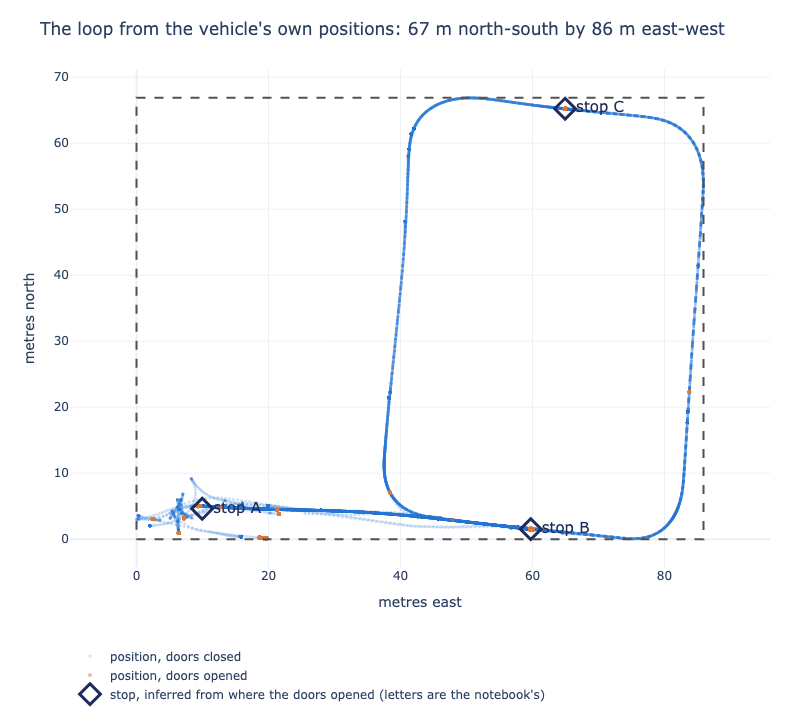

  route extent north-south, metres (Module 1's recipe)               deck 67        computed 67
  route extent east-west, metres                                     deck 86        computed 86
  vehicle file: computed here 48,290 rows, 22 columns, 1 vehicle; stated 53,155 rows, 22 columns, 2 vehicles (archive) — the slide counts the archive's bus file, both shuttles; the lab slice keeps the one that ran on both days
  door openings: 74; places where the doors opened: 6; with at least five openings (stops): 3
        east  north  openings
stop A   9.9    4.6        40
stop B  59.7    1.5        22
stop C  64.9   65.2         8


In [15]:
from scipy.cluster.hierarchy import fcluster, linkage

east, north = to_metres(bus["lat"], bus["lon"])
doors_open = (bus["door_state"] == "opened").to_numpy()
fig = go.Figure()
fig.add_scatter(x=east[~doors_open], y=north[~doors_open], mode="markers",
                marker=dict(color=BLUE, size=3, opacity=0.25), name="position, doors closed")
fig.add_scatter(x=east[doors_open], y=north[doors_open], mode="markers",
                marker=dict(color=ORANGE, size=4, opacity=0.5), name="position, doors opened")
width_m, height_m = float(east.max()), float(north.max())
fig.add_shape(type="rect", x0=0, y0=0, x1=width_m, y1=height_m,
              line=dict(color=GREY, dash="dash"))

# Stops, inferred: one door opening = one unbroken run of "opened" in time order.
opened_in_time = (in_time["door_state"] == "opened").to_numpy()
run = np.r_[0, np.cumsum(opened_in_time[1:] != opened_in_time[:-1])]
run_east, run_north = to_metres(in_time["lat"], in_time["lon"])
openings = (pd.DataFrame({"run": run, "east": run_east, "north": run_north})[opened_in_time]
              .groupby("run")[["east", "north"]].median())
place = fcluster(linkage(openings.to_numpy(), "single"), 10, "distance")
places = (openings.assign(place=place).groupby("place")
            .agg(east=("east", "mean"), north=("north", "mean"), openings=("east", "size")))
stops = (places[places["openings"] >= 5].sort_values("openings", ascending=False)
           .reset_index(drop=True))
stops.index = [f"stop {letter}" for letter in "ABCDEFG"[:len(stops)]]
fig.add_scatter(x=stops["east"], y=stops["north"], mode="markers+text", text=list(stops.index),
                textposition="middle right", textfont=dict(size=15, color=NAVY),
                marker=dict(color=NAVY, size=16, symbol="diamond-open", line=dict(width=3)),
                name="stop, inferred from where the doors opened (letters are the notebook's)")
fig.update_layout(title=f"The loop from the vehicle's own positions: "
                        f"{height_m:.0f} m north-south by {width_m:.0f} m east-west",
                  xaxis_title="metres east", yaxis_title="metres north",
                  yaxis_scaleanchor="x", legend=dict(orientation="h", y=-0.15))
show(fig, "route_map", width=800, height=720)
agrees("route extent north-south, metres (Module 1's recipe)", height_m, module1("extent_m")[0], 0)
agrees("route extent east-west, metres", width_m, module1("extent_m")[1], 0)
beside("vehicle file", f"{len(bus):,} rows, {bus.shape[1]} columns, {bus['vehicle_id'].nunique()} vehicle",
       f"{archive('bus_rows'):,} rows, {module1('columns')} columns, {module1('vehicles')} vehicles (archive)",
       "the slide counts the archive's bus file, both shuttles; the lab slice keeps the one that ran on both days")
print(f"  door openings: {len(openings)}; places where the doors opened: {len(places)}; "
      f"with at least five openings (stops): {len(stops)}")
print(stops.round(1).to_string())

**Goal.** Show why a time series is not a bag of independent draws.

**Why.** The slide contrasts independent draws with an ordered series. On this telemetry the difference is a number: consecutive speeds correlate at 0.9967 on 22 January (Module 1's measurement); the same values shuffled are measured below. A series that correlates with itself holds fewer independent observations than it has readings, which Block 1 quantifies as the effective sample size (Bayley & Hammersley, 1946).

**What the code does.** Takes ten minutes of 22 January's speed from 10:15 UTC in time order and the same values shuffled (seed 20200122), draws both, and plots each reading against the one before it. The autocorrelation is the Box–Jenkins estimator the course grades, one mean and one sum of squares (Box et al., 2015).

**So what.** Order carries information. A random split, a z-score over readings and a plain standard error all assume it does not.

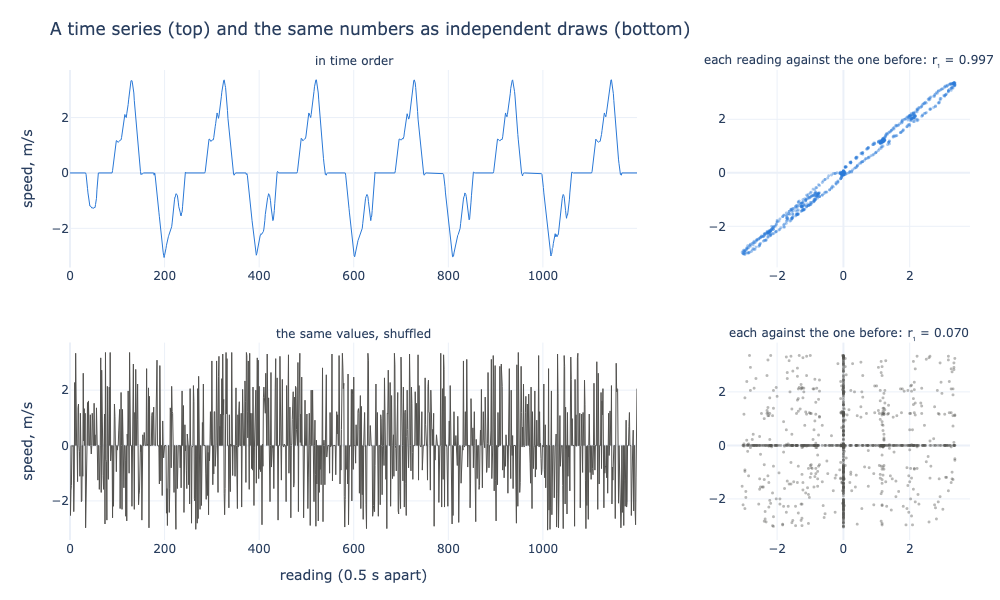

  lag-1 autocorrelation of speed, 22 January, in time order          deck 0.9967    computed 0.9967
  the ten minutes drawn: r1 = 0.9970 in order, 0.0705 shuffled


In [16]:
def lag_one(values):
    x = np.asarray(values, float)
    centred = x - x.mean()
    return float(np.sum(centred[1:] * centred[:-1]) / np.sum(centred ** 2))

slice_day_one = in_time[in_time["_t"].dt.date.astype(str) == "2020-01-22"]
stretch = slice_day_one[(slice_day_one["_t"] >= "2020-01-22 10:15:00+00:00")
                        & (slice_day_one["_t"] < "2020-01-22 10:25:00+00:00")]["speed"].to_numpy()
shuffled = np.random.default_rng(20200122).permutation(stretch)
fig = make_subplots(rows=2, cols=2, column_widths=[0.7, 0.3], vertical_spacing=0.16,
                    subplot_titles=("in time order",
                                    f"each reading against the one before: r₁ = {lag_one(stretch):.3f}",
                                    "the same values, shuffled",
                                    f"each against the one before: r₁ = {lag_one(shuffled):.3f}"))
for row, values, colour in ((1, stretch, BLUE), (2, shuffled, GREY)):
    fig.add_scatter(y=values, mode="lines", line=dict(color=colour, width=1),
                    showlegend=False, row=row, col=1)
    fig.add_scatter(x=values[:-1], y=values[1:], mode="markers",
                    marker=dict(color=colour, size=3, opacity=0.4), showlegend=False,
                    row=row, col=2)
fig.update_annotations(font_size=12)
fig.update_xaxes(title_text="reading (0.5 s apart)", row=2, col=1)
fig.update_yaxes(title_text="speed, m/s", row=1, col=1)
fig.update_yaxes(title_text="speed, m/s", row=2, col=1)
fig.update_layout(title="A time series (top) and the same numbers as independent draws (bottom)")
show(fig, "iid_vs_series", height=600)
agrees("lag-1 autocorrelation of speed, 22 January, in time order",
       lag_one(slice_day_one["speed"]), module1("speed_autocorrelation_lag1"), 4)
print(f"  the ten minutes drawn: r1 = {lag_one(stretch):.4f} in order, "
      f"{lag_one(shuffled):.4f} shuffled")

**Goal.** Put the two clocks on one axis.

**Why.** The alignment slides say the vehicle reports every 0.5 seconds and the phones every 0.993, so no reading in one file has a partner in the other. Drawing six seconds of both makes the grain choice visible.

**What the code does.** Measures both median intervals (per vehicle and per phone, within a day), then draws the vehicle's readings and one phone's readings between 09:00:00 and 09:00:06 UTC on 22 January, with the five-second tumbling windows behind them.

**So what.** The phone's ticks drift against the vehicle's by 0.007 s a reading; a window, not a timestamp, is what the two can share.

  vehicle interval, seconds                                          deck 0.5       computed 0.5
  phone interval, seconds (generated at the archive's rate)          deck 0.993     computed 0.993


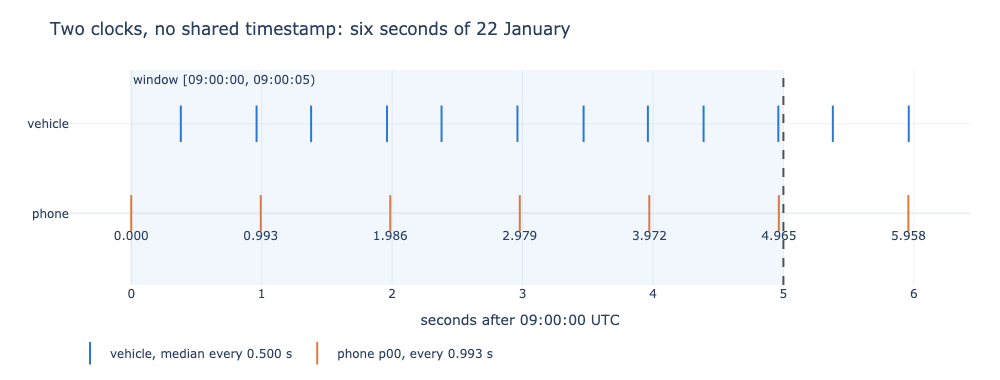

  phone ticks, seconds: 0.000, 0.993, 1.986, 2.979, 3.972, 4.965, 5.958
  the fifth phone tick on the slide's drawing: computed here 3.972 s; stated 2.973 s — the generated poster labels the fifth tick 2.973 s; four steps of 0.993 s are 3.972 s


In [17]:
vehicle_step = float(in_time.groupby(in_time["_t"].dt.date)["_t"].diff().dt.total_seconds().median())
phone_times = pd.to_datetime(phones["timestamp_utc"], utc=True)
phone_step = float(phones.assign(_t=phone_times).sort_values(["phone_id", "_t"])
                   .groupby("phone_id")["_t"].diff().dt.total_seconds().median())
agrees("vehicle interval, seconds", vehicle_step, archive("bus_interval_s"), 3)
agrees("phone interval, seconds (generated at the archive's rate)", phone_step,
       archive("phone_interval_s"), 3)

start = pd.Timestamp("2020-01-22 09:00:00", tz="UTC")
stop = start + pd.Timedelta(seconds=6)
v = in_time[(in_time["_t"] >= start) & (in_time["_t"] < stop)]["_t"]
p = phone_times[(phones["phone_id"] == "p00") & (phone_times >= start) & (phone_times < stop)]
seconds = lambda stamps: (stamps - start).dt.total_seconds()
fig = go.Figure()
fig.add_vrect(x0=0, x1=5, fillcolor="rgba(42,120,214,0.06)", line_width=0,
              annotation_text="window [09:00:00, 09:00:05)", annotation_position="top left")
fig.add_vline(x=5, line=dict(color=GREY, dash="dash"))
fig.add_scatter(x=seconds(v), y=np.ones(len(v)), mode="markers",
                marker=dict(symbol="line-ns-open", size=26, color=BLUE, line=dict(width=2)),
                name=f"vehicle, median every {vehicle_step:.3f} s")
fig.add_scatter(x=seconds(p), y=np.zeros(len(p)), mode="markers+text",
                marker=dict(symbol="line-ns-open", size=26, color=ORANGE, line=dict(width=2)),
                text=[f"{s:.3f}" for s in seconds(p)], textposition="bottom center",
                name=f"phone p00, every {phone_step:.3f} s")
fig.update_yaxes(tickvals=[0, 1], ticktext=["phone", "vehicle"], range=[-0.8, 1.6])
fig.update_layout(title="Two clocks, no shared timestamp: six seconds of 22 January",
                  xaxis_title="seconds after 09:00:00 UTC", legend=dict(orientation="h", y=-0.25))
show(fig, "two_clocks", height=380)
print("  phone ticks, seconds:", ", ".join(f"{s:.3f}" for s in seconds(p)))
beside("the fifth phone tick on the slide's drawing", f"{4 * phone_step:.3f} s", "2.973 s",
       "the generated poster labels the fifth tick 2.973 s; four steps of 0.993 s are 3.972 s")

**Goal.** Set the two sources side by side, and the labels they carry.

**Why.** The slide describes the archive: 53,155 vehicle rows, 40 phone columns from 16 volunteers, labels on 100 per cent of the first day and none of the second. The lab data differ in known ways, and the differences matter later (Module 5 starts from the missing second-day labels).

**What the code does.** Counts the same quantities on the slice and the two generated days, and prints the archive's recorded values beside them.

**So what.** The generator labels both days — it has to, to plant Lab 1's reversal — so "one day of labels" is a fact about the archive that the lab data do not reproduce.

In [18]:
day_two = load_phones(day="2020-01-23")
coverage = {day: round(float(frame["label2"].notna().mean()) * 100, 1)
            for day, frame in (("2020-01-22", phones), ("2020-01-23", day_two))}
beside("phone file", f"{phones.shape[1]} columns (generated), "
       f"{phones['phone_id'].nunique()} + {day_two['phone_id'].nunique()} phones on the two days",
       f"{archive('phone_columns')} columns, {archive('phones')} volunteers "
       f"({archive('phones_per_day')['2020-01-22']} + {archive('phones_per_day')['2020-01-23']}) (archive)",
       "the generator keeps the per-day phone counts and only the columns the labs use")
beside("label coverage by day, per cent", coverage, f"{archive('label_coverage_per_day')} (archive)",
       "the generator labels both days so that Lab 1's two-day comparison exists; in the "
       "archive only 22 January was labelled")
agrees("aboard share of labelled rows, first day, per cent",
       100 * (phones["label2"] == "IN").mean(), archive("aboard_share_of_labelled"), 1)

  phone file: computed here 18 columns (generated), 12 + 8 phones on the two days; stated 40 columns, 16 volunteers (12 + 8) (archive) — the generator keeps the per-day phone counts and only the columns the labs use
  label coverage by day, per cent: computed here {'2020-01-22': 100.0, '2020-01-23': 100.0}; stated {'2020-01-22': 100.0, '2020-01-23': 0.0} (archive) — the generator labels both days so that Lab 1's two-day comparison exists; in the archive only 22 January was labelled
  aboard share of labelled rows, first day, per cent                 deck 56.3      computed 56.3


---
# Block 1 — Know the distribution, then clean

**The question of this block:** what does the shape of a column allow you to do
to it, and how do two files on two clocks become one table without losing a row
nobody counted?

*Slide: "The distribution of a column decides which rule may be applied to it".*
The shape decides the outlier rule, the fill, the scaler and the model family. A
z-score assumes a roughly symmetric, light-tailed column; the interquartile range
does not. The one response to an outlier most often skipped is to investigate it.

**Goal.** Show two columns of the slice whose shape rules out the z-score.

**Why.** The overview slide shows a heavily skewed histogram with one value far to the right. The slice has one of its own: `mileage`, which Module 1 found reaching 65,535 — two to the sixteenth minus one, a 16-bit counter at its ceiling, not a long journey. `payload` is skewed without being broken.

**What the code does.** Draws both histograms (mileage on a logarithmic count axis, so the lone value shows) and marks the maximum.

**So what.** One reading of 65,535 among values from 0 to 126 is not an outlier to trim; it is a fault to investigate and record.

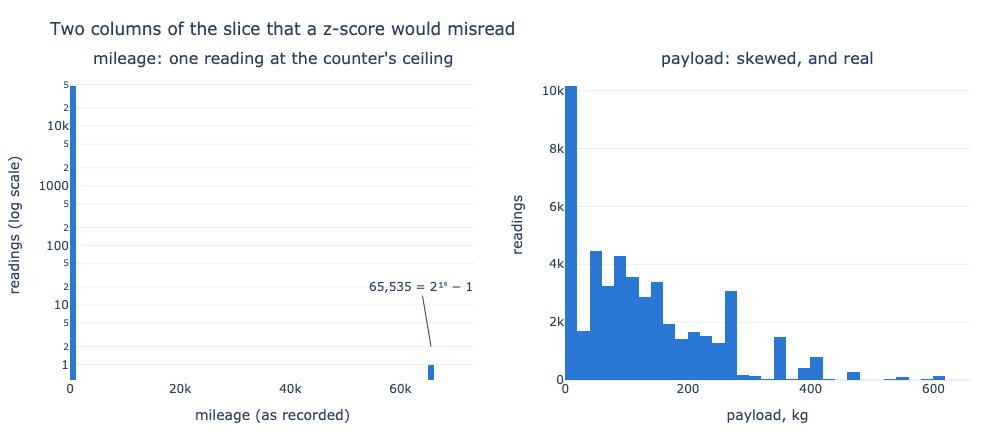

  mileage maximum                                                    deck 65535     computed 65535
  2 to the 16th minus 1                                              deck 65535     computed 65535
  readings at 65,535: 1; the next largest value: 126


In [19]:
fig = make_subplots(rows=1, cols=2, subplot_titles=(
    "mileage: one reading at the counter's ceiling", "payload: skewed, and real"))
fig.add_histogram(x=bus["mileage"], nbinsx=120, marker_color=BLUE, showlegend=False, row=1, col=1)
fig.add_histogram(x=bus["payload"], nbinsx=60, marker_color=BLUE, showlegend=False, row=1, col=2)
fig.update_yaxes(type="log", title_text="readings (log scale)", row=1, col=1)
fig.update_yaxes(title_text="readings", row=1, col=2)
fig.update_xaxes(title_text="mileage (as recorded)", row=1, col=1)
fig.update_xaxes(title_text="payload, kg", row=1, col=2)
fig.add_annotation(x=65535, y=0.3, text="65,535 = 2¹⁶ − 1", showarrow=True, ay=-60, row=1, col=1)
fig.update_layout(title="Two columns of the slice that a z-score would misread")
show(fig, "heavy_tails", height=440)
agrees("mileage maximum", bus["mileage"].max(), module1("mileage_max"), 0)
agrees("2 to the 16th minus 1", 2 ** 16 - 1, module1("mileage_max"), 0)
print(f"  readings at 65,535: {(bus['mileage'] == 65535).sum()}; the next largest value: "
      f"{bus.loc[bus['mileage'] < 65535, 'mileage'].max()}")

**Goal.** Count what the two outlier rules flag on four columns.

**Why.** The slide says signal strength is neither symmetric nor light-tailed, so the interquartile range is the right instrument. The two rules can be compared on the same columns.

**What the code does.** For payload, speed and mileage on the slice, and the heard `rssi1` readings of the generated phones, counts the rows beyond three standard deviations (the z-score rule) and beyond 1.5 interquartile ranges outside the middle half (Tukey's rule), beside each column's skewness, excess kurtosis (0 for the normal curve; a heavy tail makes it large) and interquartile range.

**So what.** The rules disagree by orders of magnitude, and the table says why each time. Tukey's 14,837 speed readings are not outliers: more than half the readings are at rest, both quartiles are 0, the interquartile range is 0, and every moving reading falls outside a band of width nought — the rule is undefined on this column, not strict. The generated `rssi1` is mildly skewed (0.56) and not heavy-tailed, and there the z-score flags more than Tukey does (8 against 4); the slide's sentence about signal strength describes the archive, which this notebook cannot open, and the generated readings do not reproduce it. Which rule is right is a statement about the shape, and it has to be measured first.

In [20]:
def outlier_counts(values):
    x = pd.Series(values).dropna().astype(float)
    z = (x - x.mean()) / x.std(ddof=0)
    q1, q3 = x.quantile([0.25, 0.75])
    spread = q3 - q1
    return {"rows": len(x), "skewness": round(float(stats.skew(x)), 2),
            "excess kurtosis": round(float(stats.kurtosis(x)), 2), "IQR": round(float(spread), 3),
            "beyond 3 sd (z-score)": int((z.abs() > 3).sum()),
            "beyond 1.5 IQR (Tukey)": int(((x < q1 - 1.5 * spread) | (x > q3 + 1.5 * spread)).sum())}

table = pd.DataFrame({"payload (slice)": outlier_counts(bus["payload"]),
                      "speed (slice)": outlier_counts(bus["speed"]),
                      "mileage (slice)": outlier_counts(bus["mileage"]),
                      "rssi1 heard (generated)": outlier_counts(phones["rssi1"])}).T
print(table.to_string())
print(f"  speed: {100 * float((bus['speed'] == 0).mean()):.1f} per cent of readings are exactly 0, so "
      f"both quartiles are 0; Tukey flags every reading that is not 0: "
      f"{int((bus['speed'] != 0).sum()):,}")
rssi1_row = table.loc["rssi1 heard (generated)"]
beside("rssi1 heard: shape, and what the two rules flag",
       f"skewness {rssi1_row['skewness']}, excess kurtosis {rssi1_row['excess kurtosis']}; "
       f"z-score flags {int(rssi1_row['beyond 3 sd (z-score)'])}, Tukey {int(rssi1_row['beyond 1.5 IQR (Tukey)'])} (generated)",
       "\"Signal strength here is neither [symmetric nor light-tailed], so the interquartile "
       "range is the correct instrument\" (slide 13)",
       "the slide describes the archive's signal strength, which this notebook does not open; "
       "the generator draws each heard reading from a log-distance law plus 2 dB of normal "
       "noise, which is mildly skewed and light-tailed, so on the lab data the rules nearly agree")

                            rows  skewness  excess kurtosis    IQR  beyond 3 sd (z-score)  beyond 1.5 IQR (Tukey)
payload (slice)          48290.0      1.13             1.25  145.0                  325.0                  1409.0
speed (slice)            48290.0      0.75             2.68    0.0                 1247.0                 14837.0
mileage (slice)          48290.0    219.07         48087.72    4.0                    1.0                   586.0
rssi1 heard (generated)   1216.0      0.56             0.00   13.4                    8.0                     4.0
  speed: 69.3 per cent of readings are exactly 0, so both quartiles are 0; Tukey flags every reading that is not 0: 14,837
  rssi1 heard: shape, and what the two rules flag: computed here skewness 0.56, excess kurtosis 0.0; z-score flags 8, Tukey 4 (generated); stated "Signal strength here is neither [symmetric nor light-tailed], so the interquartile range is the correct instrument" (slide 13) — the slide describes the archive

### A catalogue of distributions

*Slides: "Why do I need to know the underlying distribution of my data?" (four
slides: three tables and the list of reasons).* The tables name eighteen families
and what each describes. The slides' pictures are samples of 1,000 draws; they are
redrawn below from numpy with the parameters printed in each panel title, with the
exact density or mass function laid over each. The slides do not state their
parameters, so these panels are illustrative: the shapes, not the values, are the
point.

**Goal.** Draw the first six families: normal, log-normal, uniform, exponential, Poisson, binomial.

**Why.** Knowing the family tells you the outlier rule, the fill and the scaler before any of them is chosen. Among these six, only the normal and the uniform are symmetric.

**What the code does.** Defines `catalogue()`, which draws 1,000 values per family with the course seed, plots a density histogram, and lays the exact curve (continuous) or mass (discrete) from `scipy.stats` over it.

**So what.** The exact curve and the draws agree; that agreement is what "the data follow a normal distribution" should mean, and it can be checked.

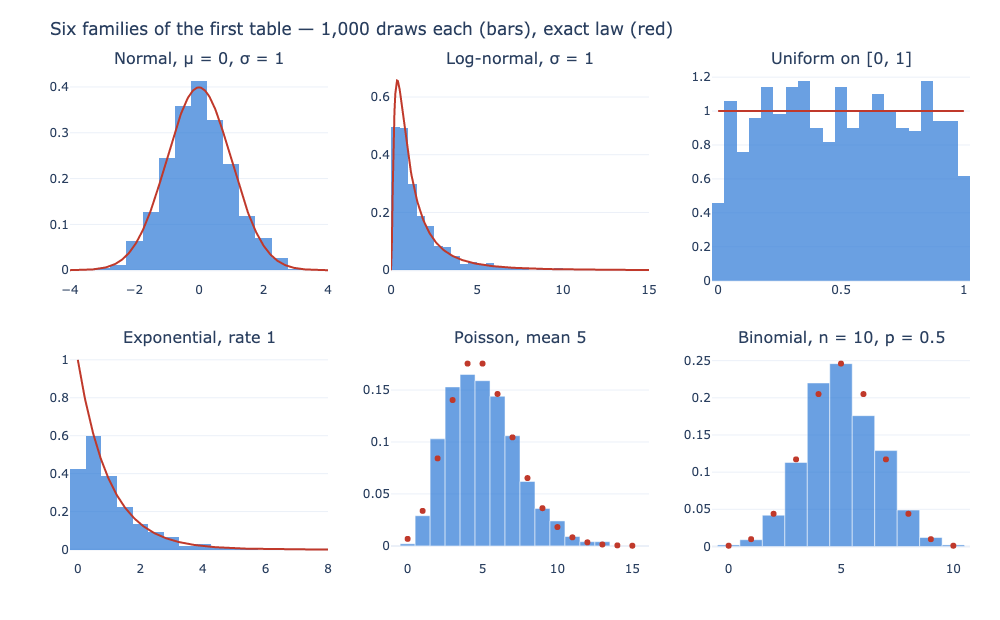

In [21]:
def catalogue(families, title, name):
    rng = np.random.default_rng(20200122)
    fig = make_subplots(rows=2, cols=3, subplot_titles=[f[0] for f in families],
                        vertical_spacing=0.14, horizontal_spacing=0.07)
    for number, (label, law, discrete, window) in enumerate(families):
        row, col = number // 3 + 1, number % 3 + 1
        draws = law.rvs(size=1000, random_state=rng)
        shown = draws[(draws >= window[0]) & (draws <= window[1])]
        if discrete:
            values, counts = np.unique(shown, return_counts=True)
            fig.add_bar(x=values, y=counts / len(draws), marker_color=BLUE, opacity=0.7,
                        showlegend=False, row=row, col=col)
            support = np.arange(int(window[0]), int(window[1]) + 1)
            fig.add_scatter(x=support, y=law.pmf(support), mode="markers",
                            marker=dict(color=RED, size=6), showlegend=False, row=row, col=col)
        else:
            fig.add_histogram(x=shown, histnorm="probability density", nbinsx=30,
                              marker_color=BLUE, opacity=0.7, showlegend=False, row=row, col=col)
            grid = np.linspace(window[0], window[1], 300)
            fig.add_scatter(x=grid, y=law.pdf(grid), mode="lines", line=dict(color=RED, width=2),
                            showlegend=False, row=row, col=col)
    fig.update_layout(title=title + " — 1,000 draws each (bars), exact law (red)")
    show(fig, name, height=620)

catalogue([
    ("Normal, μ = 0, σ = 1", stats.norm(0, 1), False, (-4, 4)),
    ("Log-normal, σ = 1", stats.lognorm(1), False, (0, 15)),
    ("Uniform on [0, 1]", stats.uniform(0, 1), False, (0, 1)),
    ("Exponential, rate 1", stats.expon(), False, (0, 8)),
    ("Poisson, mean 5", stats.poisson(5), True, (0, 15)),
    ("Binomial, n = 10, p = 0.5", stats.binom(10, 0.5), True, (0, 10)),
], "Six families of the first table", "distributions_one")

**Goal.** Draw the second six: Bernoulli, beta, gamma, Weibull, chi-square, Student's t.

**Why.** These are the families of proportions (beta), positive skewed waiting times (gamma, Weibull), and test statistics (chi-square, t).

**What the code does.** Calls `catalogue()` again.

**So what.** Four of the six are bounded or positive; a z-score rule on any of them flags only one tail.

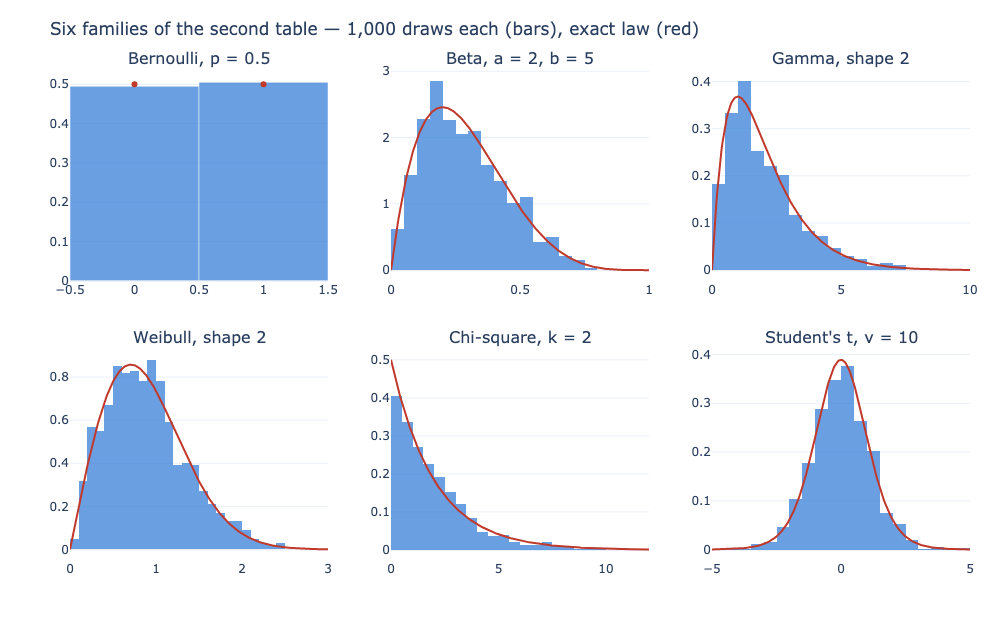

In [22]:
catalogue([
    ("Bernoulli, p = 0.5", stats.bernoulli(0.5), True, (0, 1)),
    ("Beta, a = 2, b = 5", stats.beta(2, 5), False, (0, 1)),
    ("Gamma, shape 2", stats.gamma(2), False, (0, 10)),
    ("Weibull, shape 2", stats.weibull_min(2), False, (0, 3)),
    ("Chi-square, k = 2", stats.chi2(2), False, (0, 12)),
    ("Student's t, ν = 10", stats.t(10), False, (-5, 5)),
], "Six families of the second table", "distributions_two")

**Goal.** Draw the last six: F, geometric, negative binomial, Cauchy, Pareto, Rayleigh.

**Why.** The Cauchy has no mean at all, so the central limit theorem never rescues its averages; the Pareto is the power law behind "a few values carry most of the total"; the Rayleigh is the magnitude of a two-dimensional normal error, which is how a position fix scatters.

**What the code does.** Calls `catalogue()` again; the Cauchy panel shows only the draws between −10 and 10, and the cell counts the ones outside.

**So what.** A family with an undefined mean is not a curiosity: any rule that averages it is unstable however much data arrives.

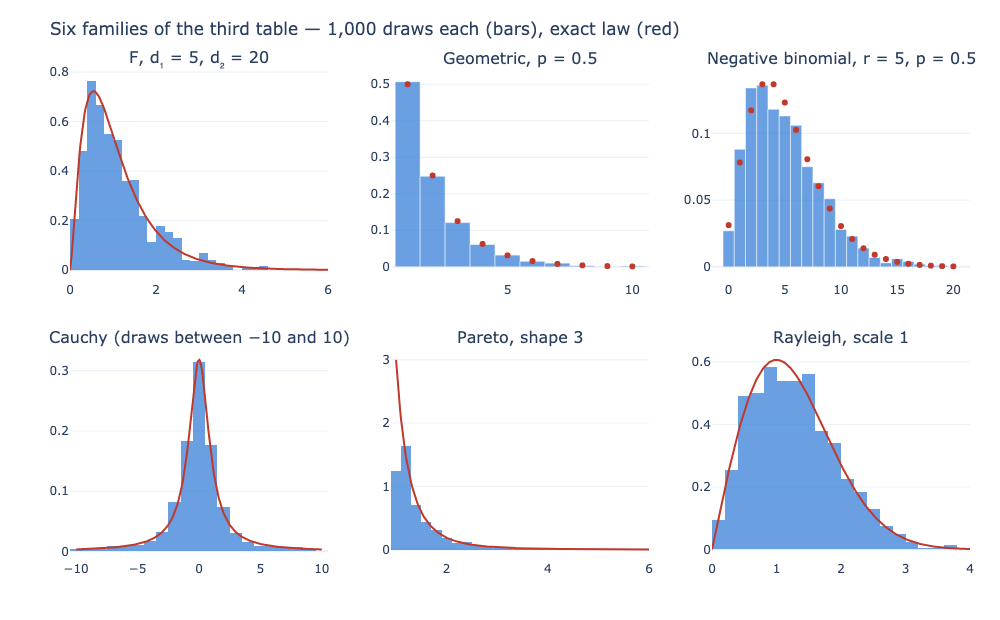

  Cauchy draws outside [-10, 10]: 74 of 1,000; largest magnitude 563


In [23]:
catalogue([
    ("F, d₁ = 5, d₂ = 20", stats.f(5, 20), False, (0, 6)),
    ("Geometric, p = 0.5", stats.geom(0.5), True, (1, 10)),
    ("Negative binomial, r = 5, p = 0.5", stats.nbinom(5, 0.5), True, (0, 20)),
    ("Cauchy (draws between −10 and 10)", stats.cauchy(), False, (-10, 10)),
    ("Pareto, shape 3", stats.pareto(3), False, (1, 6)),
    ("Rayleigh, scale 1", stats.rayleigh(), False, (0, 4)),
], "Six families of the third table", "distributions_three")
cauchy = stats.cauchy().rvs(size=1000, random_state=np.random.default_rng(20200122))
print(f"  Cauchy draws outside [-10, 10]: {int((np.abs(cauchy) > 10).sum())} of 1,000; "
      f"largest magnitude {np.abs(cauchy).max():,.0f}")

### The central limit theorem, and what it does not say

*Slides: "Definition — the central limit theorem, and what it does not say" and "Central limit theorem".*

**Goal.** Write the theorem as the definition slide states it.

**Why.** The standardised mean of n independent draws from one distribution with finite variance tends to the standard normal (Casella & Berger, 2002, § 5.5; Wasserman, 2004, § 5.4; Feller, 1971).

**What the code does.** Builds the standardised mean in sympy and states the limit; then checks the variance of a mean of n independent draws, σ²/n, by summing symbolically.

**So what.** The √n in the denominator is where independence enters: with correlated readings the variance of the mean is not σ²/n, and the theorem's n is the wrong n.

In [24]:
n = sp.Symbol("n", positive=True, integer=True)
mu, sigma = sp.symbols(r"\mu \sigma", positive=True)
xbar = sp.Symbol(r"\bar{x}")
formula(sp.Eq(sp.Symbol("Z_n"), (xbar - mu) / (sigma / sp.sqrt(n)), evaluate=False),
        r"\xrightarrow[n \longrightarrow \infty]{\;d\;}", sp.Function(r"\mathcal{N}")(0, 1))
formula(sp.Symbol(r"\text{independent draws, one distribution}"), sp.Lt(sigma**2, sp.oo, evaluate=False))
i = sp.Symbol("i", integer=True)
variance_of_mean = sp.Sum(sigma**2, (i, 1, n)).doit() / n**2      # independent: covariances vanish
print("Var(mean of n independent draws) =", sp.simplify(variance_of_mean))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Var(mean of n independent draws) = \sigma**2/n


**Goal.** Redo the slide's demonstration: three populations, and the means of samples of 5 and of 30.

**Why.** The slide's grid shows an exponential, a uniform and a normal population and the distributions of their sample means (Casella & Berger, 2002, § 5.5).

**What the code does.** Draws 10,000 values from each population (exponential with mean 2, uniform on [0, 10], normal with mean 5 and standard deviation 2, as read off the slide's axes), then 1,000 sample means at n = 5 and n = 30, with the course seed.

**So what.** At n = 30 all three are bell-shaped, the exponential included. The picture is the slide's; the parameters are read from its axes, so it is labelled illustrative.

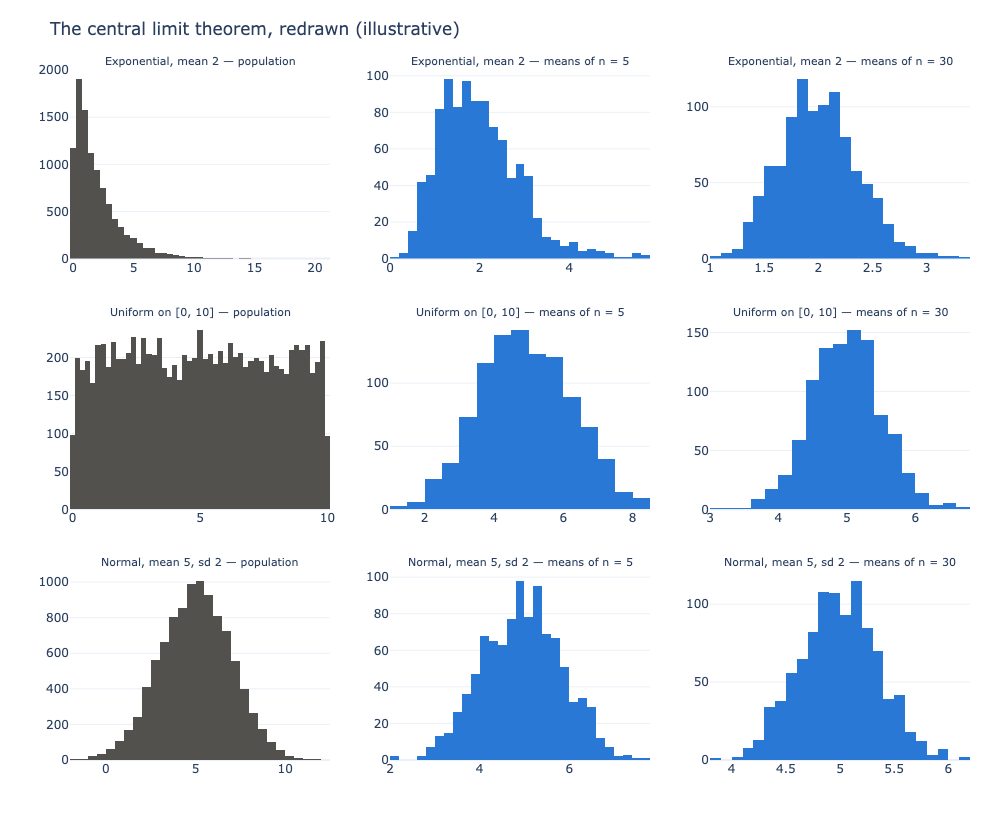

In [25]:
rng = np.random.default_rng(20200122)
populations = [("Exponential, mean 2", lambda size: rng.exponential(2.0, size)),
               ("Uniform on [0, 10]", lambda size: rng.uniform(0, 10, size)),
               ("Normal, mean 5, sd 2", lambda size: rng.normal(5, 2, size))]
titles = [f"{name} — {part}" for name, _ in populations
          for part in ("population", "means of n = 5", "means of n = 30")]
fig = make_subplots(rows=3, cols=3, subplot_titles=titles, vertical_spacing=0.09)
for row, (name, draw) in enumerate(populations, start=1):
    fig.add_histogram(x=draw(10_000), nbinsx=50, marker_color=GREY, showlegend=False, row=row, col=1)
    for col, size in ((2, 5), (3, 30)):
        fig.add_histogram(x=draw((1000, size)).mean(axis=1), nbinsx=30, marker_color=BLUE,
                          showlegend=False, row=row, col=col)
fig.update_annotations(font_size=11)
fig.update_layout(title="The central limit theorem, redrawn (illustrative)")
show(fig, "clt_grid", height=820)

**Goal.** Test the theorem's first condition on the slice.

**Why.** The definition slide says this archive breaks independence: consecutive readings correlate at 0.9967, so n must be replaced by the effective sample size (Bayley & Hammersley, 1946). Averaging consecutive readings is therefore not the averaging the theorem describes.

**What the code does.** Takes the payload readings of 22 January (skewed). Draws 2,000 means of 30 readings chosen independently at random, and 2,000 means of 30 *consecutive* readings (15 seconds), and compares their skewness. Then computes the slice's effective sample size n(1 − ρ)/(1 + ρ).

**So what.** Independent draws give a nearly symmetric mean; consecutive readings give a mean almost as skewed as the readings themselves. The theorem applies to window features only when the windows, not the readings, are the observations.

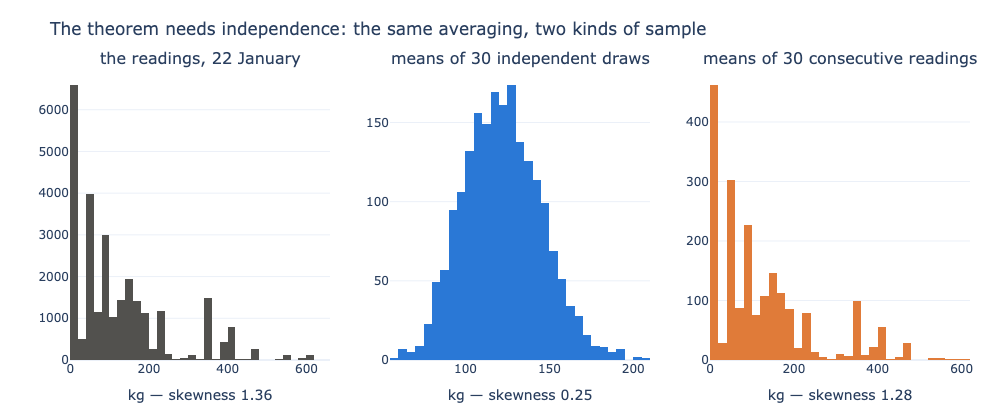

  the readings, 22 January             skewness  1.36
  means of 30 independent draws        skewness  0.25
  means of 30 consecutive readings     skewness  1.28
  effective sample size of the slice, n(1 − ρ)/(1 + ρ)               deck 73        computed 73


In [26]:
payload = slice_day_one["payload"].to_numpy(float)
rng = np.random.default_rng(20200122)
independent = rng.choice(payload, size=(2000, 30), replace=True).mean(axis=1)
starts = rng.integers(0, len(payload) - 30, 2000)
consecutive = np.array([payload[s:s + 30].mean() for s in starts])
panels = [("the readings, 22 January", payload, GREY),
          ("means of 30 independent draws", independent, BLUE),
          ("means of 30 consecutive readings", consecutive, ORANGE)]
fig = make_subplots(rows=1, cols=3, subplot_titles=[p[0] for p in panels])
for col, (label, values, colour) in enumerate(panels, start=1):
    fig.add_histogram(x=values, nbinsx=40, marker_color=colour, showlegend=False, row=1, col=col)
    fig.update_xaxes(title_text=f"kg — skewness {stats.skew(values):.2f}", row=1, col=col)
fig.update_layout(title="The theorem needs independence: the same averaging, two kinds of sample")
show(fig, "clt_on_slice", height=420)
for label, values, _ in panels:
    print(f"  {label:<36} skewness {stats.skew(values):5.2f}")
rho = lag_one(in_time["speed"])
agrees("effective sample size of the slice, n(1 − ρ)/(1 + ρ)",
       len(in_time) * (1 - rho) / (1 + rho), module1("slice_effective_sample_size"), 0)

### Properties of the normal distribution

*Slide: "Properties of normal distribution".*

**Goal.** Write the two formulas on the slide: the normal density and the z-score.

**Why.** The 68-95-99.7 rule is a property of this one curve; it is not a property of data.

**What the code does.** Writes both in sympy, checks that the density integrates to one, and computes the probability within one, two and three standard deviations exactly, as erf(k/√2).

**So what.** 68.27, 95.45 and 99.73 per cent — the rule's three numbers, derived rather than remembered.

In [27]:
x = sp.Symbol("x", real=True)
mu = sp.Symbol(r"\mu", real=True)
sigma = sp.Symbol(r"\sigma", positive=True)
density = sp.exp(-(x - mu)**2 / (2 * sigma**2)) / sp.sqrt(2 * sp.pi * sigma**2)
formula(sp.Eq(sp.Function("f")(x), density, evaluate=False))
print("integral over the real line:", sp.simplify(sp.integrate(density, (x, -sp.oo, sp.oo))))
within = {k: sp.erf(k / sp.sqrt(2)) for k in (1, 2, 3)}
for k, stated in zip(within, (68, 95, 99.7)):
    agrees(f"per cent within {k} standard deviation(s)", 100 * float(within[k]), stated, 0 if k < 3 else 1)

<IPython.core.display.Math object>

integral over the real line: 1
  per cent within 1 standard deviation(s)                            deck 68        computed 68
  per cent within 2 standard deviation(s)                            deck 95        computed 95
  per cent within 3 standard deviation(s)                            deck 99.7      computed 99.7


**Goal.** Write the z-score the slide pairs with the density.

**Why.** It is the distance from the mean in standard deviations — the quantity the z-score outlier rule of Block 1 thresholds, and a meaningful one only when the column is close to this curve.

**What the code does.** Writes Z = (X − μ)/σ in sympy.

**So what.** Under the normal curve |Z| > 3 happens 0.27 per cent of the time; the outlier counts above give 0.67 per cent on the slice's payload and 2.6 per cent on its speed — the rule's promise holds only for the shape it assumes.

In [28]:
X = sp.Symbol("X", real=True)
formula(sp.Eq(sp.Symbol("Z"), (X - mu) / sigma, evaluate=False))

<IPython.core.display.Math object>

**Goal.** Draw the normal curve with its three bands.

**Why.** The slide's picture is a generated drawing whose formula is garbled and whose axis is labelled μ − 3σ, μ − σ, μ, μ + σ, μ + 2σ — not symmetric. Redrawn from the closed form, it cannot be.

**What the code does.** Evaluates the standard normal density and shades ±1, ±2 and ±3 standard deviations, with the shares computed above.

**So what.** Symmetric, mean = median = mode, and tails that never reach the axis — each property visible, none asserted.

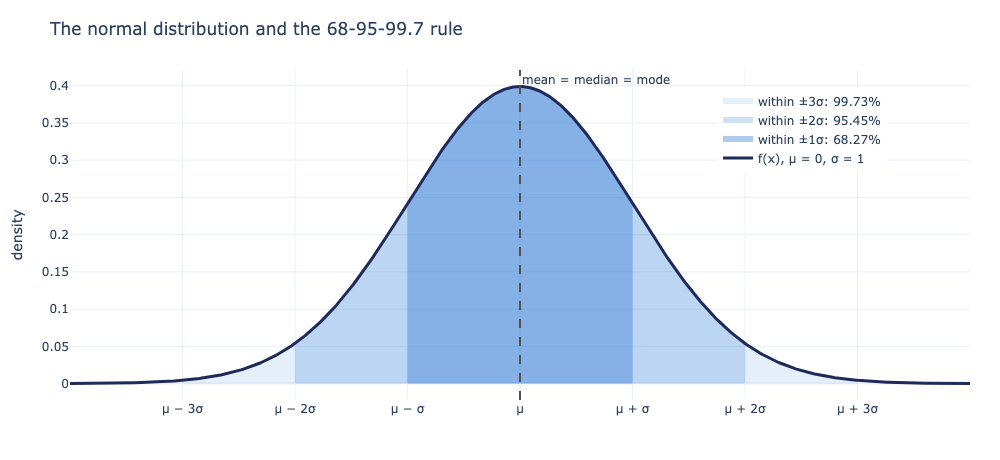

  axis labels on the slide's drawing: computed here μ − 3σ, μ − 2σ, μ − σ, μ, μ + σ, μ + 2σ, μ + 3σ; stated μ − 3σ, μ − σ, μ, μ + σ, μ + 2σ — the generated drawing omits μ − 2σ and μ + 3σ, and its density formula lacks the σ under the root and has a garbled exponent; the slide's own formula image is correct


In [29]:
grid = np.linspace(-4, 4, 801)
fig = go.Figure()
for k, shade in ((3, "rgba(42,120,214,0.12)"), (2, "rgba(42,120,214,0.22)"), (1, "rgba(42,120,214,0.38)")):
    inside = np.abs(grid) <= k
    fig.add_scatter(x=grid[inside], y=stats.norm.pdf(grid[inside]), fill="tozeroy", mode="none",
                    fillcolor=shade, name=f"within ±{k}σ: {100 * float(within[k]):.2f}%")
fig.add_scatter(x=grid, y=stats.norm.pdf(grid), mode="lines", line=dict(color=NAVY, width=3),
                name="f(x), μ = 0, σ = 1")
fig.add_vline(x=0, line=dict(color=GREY, dash="dash"), annotation_text="mean = median = mode")
fig.update_xaxes(tickvals=[-3, -2, -1, 0, 1, 2, 3],
                 ticktext=["μ − 3σ", "μ − 2σ", "μ − σ", "μ", "μ + σ", "μ + 2σ", "μ + 3σ"])
fig.update_layout(title="The normal distribution and the 68-95-99.7 rule",
                  yaxis_title="density", legend=dict(x=0.72, y=0.95))
show(fig, "normal_properties", height=460)
beside("axis labels on the slide's drawing", "μ − 3σ, μ − 2σ, μ − σ, μ, μ + σ, μ + 2σ, μ + 3σ",
       "μ − 3σ, μ − σ, μ, μ + σ, μ + 2σ",
       "the generated drawing omits μ − 2σ and μ + 3σ, and its density formula lacks the σ "
       "under the root and has a garbled exponent; the slide's own formula image is correct")

### Six faults, measured before any is repaired

*Slide: "Six faults occur in most files, and types must be repaired first".*

**Goal.** Measure the six faults the slide lists, on the slice and the generated phones.

**Why.** Measure all six before repairing any, and repair types first, because every other measurement depends on them: a time read as text cannot be floored to a window, and a number read as text has no range. (A rule of practice: the slide gives no source for it, and none is cited here.)

**What the code does.** Counts: missing values per column; duplicated rows and duplicated instants; the distinct spellings of text columns; the types pandas inferred (a time column read as text); outliers (the broken counter, negative speeds); and structural errors — columns that do not hold what their names claim.

**So what.** Nothing here is repaired. The table is the audit; every later decision can point at a line of it.

In [30]:
missing = {c: round(float(bus[c].isna().mean()) * 100, 2) for c in bus.columns if bus[c].isna().any()}
print("1 missing, per cent of rows:", missing)
print("2 duplicated rows:", int(bus.duplicated().sum()), "  duplicated (vehicle, instant):",
      int(bus.duplicated(["vehicle_id", "utc_time"]).sum()))
print("3 spellings: door_state", sorted(bus["door_state"].dropna().unique()),
      "  phone label", sorted(phones["label"].unique()))
print("4 types as read: utc_time", bus["utc_time"].dtype, "  timestamp", bus["timestamp"].dtype,
      "  mileage", bus["mileage"].dtype)
print("5 outliers: mileage at 65,535:", int((bus["mileage"] == 65535).sum()),
      "  speed below zero:", int((bus["speed"] < 0).sum()))
offset = (pd.to_datetime(bus["timestamp"]) - pd.to_datetime(bus["utc_time"])).dt.total_seconds() / 3600
constant = [c for c in bus.columns if bus[c].nunique(dropna=True) == 1]
print("6 structural: `timestamp` minus `utc_time`, hours:", [float(v) for v in sorted(offset.round(2).unique())],
      "  `emergency_stop` holds", sorted(bus["emergency_stop"].dropna().unique()),
      "  constant columns:", constant)
beside("rows with negative speed", int((bus["speed"] < 0).sum()),
       f"{module1('negative_speed_rows'):,} (archive, Module 1)",
       "Module 1 counted both vehicles in the archive's bus file; the slice holds one")

1 missing, per cent of rows: {'platform': 0.02, 'battery_level': 0.0, 'emergency_stop': 47.43}
2 duplicated rows: 0   duplicated (vehicle, instant): 0
3 spellings: door_state ['closed', 'moving', 'opened']   phone label ['Bus 1', 'Bus 2', 'Stop C']
4 types as read: utc_time object   timestamp object   mileage int64
5 outliers: mileage at 65,535: 1   speed below zero: 4429
6 structural: `timestamp` minus `utc_time`, hours: [1.0]   `emergency_stop` holds ['core_control', 'estop_button', 'lms_rl', 'lms_rr']   constant columns: ['vehicle_id', 'platform', 'state', 'ramp_state', 'tz']
  rows with negative speed: computed here 4429; stated 4,434 (archive, Module 1) — Module 1 counted both vehicles in the archive's bus file; the slice holds one


### The grain, and the ledger

*Slides: "The two sources share no timestamps, so a grain must be chosen" (its
figure, the two clocks, is drawn in the introduction), "Definition — a tumbling
window on the coordinated universal time grain", "Definition — the conservation
ledger" and "Definition — the upstream profile, and checking a frame against it".*

**Goal.** Write the tumbling window, and check that flooring a timestamp computes it.

**Why.** A tumbling window is one of a sequence of fixed-length intervals, closed on the left and open on the right, so every reading belongs to exactly one (Akidau et al., 2015, § 1.2).

**What the code does.** Writes w_j as a sympy interval, closed on the left and open on the right, and the index j = ⌊(t − t₀)/Δ⌋; checks symbolically that a reading at t lies in w_j for that j; then checks, on every vehicle reading, that pandas' `dt.floor("5s")` — what Lab 1's `align` uses — gives t₀ + jΔ.

**So what.** The formula on the slide and the line of code in the solution are the same function, reading for reading.

In [31]:
t, t0 = sp.symbols("t t_0", real=True)
Delta = sp.Symbol(r"\Delta", positive=True)
j = sp.Symbol("j", integer=True)
window_j = sp.Interval(t0 + j * Delta, t0 + (j + 1) * Delta, right_open=True)
index_of_t = sp.floor((t - t0) / Delta)
formula(sp.Eq(sp.Symbol("w_j"), window_j, evaluate=False), sp.Eq(j, index_of_t, evaluate=False),
        sp.Eq(Delta, sp.Symbol(r"5\ \mathrm{s}"), evaluate=False))
u = sp.Symbol("u", real=True)       # u = (t − t0)/Δ, so t = t0 + uΔ
inside = window_j.subs(j, sp.floor(u)).contains(t0 + u * Delta)
print("t0 + u·Δ lies in w_j with j = floor(u) (t0 = 0, Δ = 5, at 1,000 values of u):",
      all(bool(inside.subs({u: sp.Rational(k, 7), t0: 0, Delta: 5})) for k in range(-500, 500)))
stamps = pd.to_datetime(bus["utc_time"], utc=True)
midnight = stamps.dt.normalize()
index = np.floor((stamps - midnight).dt.total_seconds() / 5).astype(int)
by_formula = midnight + pd.to_timedelta(index * 5, unit="s")
print("readings where floor('5s') differs from t0 + j·Δ:", int((stamps.dt.floor("5s") != by_formula).sum()),
      "of", f"{len(stamps):,}")

<IPython.core.display.Math object>

t0 + u·Δ lies in w_j with j = floor(u) (t0 = 0, Δ = 5, at 1,000 values of u): True
readings where floor('5s') differs from t0 + j·Δ: 0 of 48,290


**Goal.** Write the ledger's identity.

**Why.** Every input row is used or dropped, never both, and every dropped row has a reason with a count. The identity holds by construction where counts are kept; it is bookkeeping, and needs no source. (The Lab 1 stub cites Wang and Strong (1996) for it; that paper defines data quality as fitness for use and does not state this identity.)

**What the code does.** Writes the two equations in sympy, with r running over the K reasons, and evaluates both on a planted ledger of three reasons.

**So what.** Lab 1's check adds the buckets up; a ledger that does not balance is the lesson.

In [32]:
used, dropped, received = sp.symbols(r"\mathrm{used} \mathrm{dropped} \mathrm{received}",
                                     nonnegative=True, integer=True)
r, K = sp.symbols("r K", positive=True, integer=True)
drop_reasons = sp.IndexedBase(r"\mathrm{drop\_reasons}")
formula(sp.Eq(used + dropped, received, evaluate=False),
        sp.Eq(sp.Sum(drop_reasons[r], (r, 1, K)), dropped, evaluate=False))
planted = {drop_reasons[1]: 6, drop_reasons[2]: 40, drop_reasons[3]: 0}
dropped_here = sp.Sum(drop_reasons[r], (r, 1, 3)).doit().subs(planted)
print("planted: 10,754 used, reasons 6 + 40 + 0 → dropped =", dropped_here,
      "; balances against 10,800 received:", sp.Eq(10_754 + dropped_here, 10_800))

<IPython.core.display.Math object>

planted: 10,754 used, reasons 6 + 40 + 0 → dropped = 46 ; balances against 10,800 received: True


**Goal.** Write what "checking a frame against the upstream profile" means, and run it.

**Why.** Module 1 declared the slice's columns — type, unit, range, tolerated absence, sampling step — and `check_against` runs that declaration. The order of the rules is part of the design: type before range. "Fit for use" is Wang and Strong's definition of data quality: judged by the consumer of the data, here the next step of the pipeline (Wang & Strong, 1996).

**What the code does.** Writes the definition in sympy — the number of breaches as the sum of the complaints of the five rules, ρ = 1 … 5 (presence, type, range, absence, step, in that order), and fitness for use as that number being nought — then runs `check_against` on the whole slice and on 22 January alone.

**So what.** The pooled frame satisfies the declaration; its first day does not. An examination made only on the pool would report nothing — the shape of the paradox that ends this block.

In [33]:
X, P = sp.symbols("X P")
rho = sp.Symbol(r"\rho", positive=True, integer=True)
breaches = sp.Abs(sp.Function(r"\mathrm{breaches}")(X, P))
complaints = sp.Function(r"n_{\mathrm{complaints}}")
formula(sp.Eq(breaches, sp.Sum(complaints(rho, X, P), (rho, 1, 5)), evaluate=False),
        sp.Equivalent(sp.Symbol(r"X\ \text{fit for use}"), sp.Eq(breaches, 0), evaluate=False))
profile = load_module1_profile()
print("both days:", check_against(bus, profile) or "no complaints")
day_22 = bus[pd.to_datetime(bus["utc_time"], utc=True).dt.date.astype(str) == "2020-01-22"]
print("22 January alone:", check_against(day_22, profile))

<IPython.core.display.Math object>

both days: no complaints
22 January alone: ['emergency_stop: absent on 0.5220 of rows, above the declared 0.48426.']


### Simpson's paradox

*Slides: "Definition — Simpson's paradox" and "The aboard share rises on each shuttle and falls across the pooled days".* The definition slide's cartoon is not redrawn (copyrighted characters); the paradox is drawn from the planted data instead.

**Goal.** Write the reversal as the slide does, and verify it on the generator's two-by-two-by-two table.

**Why.** An association can point one way inside every group and the other way pooled, because pooling also compares the sizes of the groups (Simpson, 1951; Blyth, 1972). Which number to report depends on what changed the mix (Pearl, 2014); road-safety examples are in Elvik (2025).

**What the code does.** Writes the slide's two inequalities as sympy relations, P(Y | D = d, G = g) being a symbol for each share; then reads the counts from `simpson_table()` — the generator's own function — substitutes them as exact fractions, with D = 1 the first day (22 January) and D = 0 the second, and lets sympy decide each relation.

**So what.** Every inequality holds exactly as the slide writes it: the pooled share is higher on the first day, and each shuttle's share is lower.

In [34]:
g = sp.Symbol("g")
def share_symbol(day, group=None):
    return sp.Symbol(rf"P(Y \mid D{{=}}{day}" + (rf", G{{=}}{group})" if group is not None else ")"))
pooled_rises = sp.StrictGreaterThan(share_symbol(1), share_symbol(0), evaluate=False)
each_falls = sp.StrictLessThan(share_symbol(1, g), share_symbol(0, g), evaluate=False)
formula(pooled_rises, sp.Symbol(r"\text{while}"), each_falls, sp.Symbol(r"\text{for every } g"))
counts = simpson_table()
share = {(row.group, row.day): sp.Rational(int(row.aboard), int(row.readings))
         for row in counts.itertuples()}
d1, d0 = "2020-01-22", "2020-01-23"
print("pooled:", share[("pooled", d1)], ">", share[("pooled", d0)], "is",
      pooled_rises.subs({share_symbol(1): share[("pooled", d1)], share_symbol(0): share[("pooled", d0)]}))
for group in ("Bus 1", "Bus 2"):
    print(f"{group}:", share[(group, d1)], "<", share[(group, d0)], "is",
          each_falls.subs({share_symbol(1, g): share[(group, d1)], share_symbol(0, g): share[(group, d0)]}))

<IPython.core.display.Math object>

pooled: 169/300 > 41/80 is True
Bus 1: 361/900 < 9/20 is True
Bus 2: 29/45 < 7/10 is True


**Goal.** Draw the reversal with the deck's own figure code.

**Why.** The slide's figure comes from `slides/make_figs.py`; running its function verbatim is the surest way to reproduce it.

**What the code does.** Copies the palette and the constants from `make_figs.py`; `write()` is the one change — there it writes `figures/<name>.png`, here it applies the same layout and shows the figure. Then copies `figure_simpson()`, which imports `simpson_table` from `make_phones` — the generator defined above.

**So what.** Bus 1 from 40.1 to 45.0 per cent, Bus 2 from 64.4 to 70.0, pooled from 56.3 to 51.2: the slide's numbers, recomputed.

In [35]:
# Source: Module 2/slides/make_figs.py — BLUE, ORANGE, GREY, RED, TEMPLATE, BEACON, DAY_ONE, DAY_TWO, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


# AGENT_SPEC standard 6: reference or first day blue, current or second day
# orange, neutral grey, and red only for what fails.
BLUE, ORANGE, GREY, RED = "#2A78D6", "#E07B39", "#52514E", "#C0392B"


TEMPLATE = "plotly_white"


BEACON = "rssi1"          # the vehicle beacon: the one the labs work on


DAY_ONE, DAY_TWO = "2020-01-22", "2020-01-23"

**Goal.** Replace `make_figs.py`'s `write()` with one that shows the figure.

**Why.** The script writes PNG and HTML files under `slides/figures/`; the notebook must not write there.

**What the code does.** Applies the script's own layout (template, size, margins) and displays the image.

**So what.** The figures below are the deck's, drawn by the deck's code, in place.

In [36]:
def write(fig, name, width=1000, height=560):
    """make_figs.py's write(), shown in place instead of written to figures/."""
    fig.update_layout(template=TEMPLATE, width=width, height=height,
                      margin=dict(l=70, r=30, t=70, b=70))
    display(Image(fig.to_image(format="png", width=width, height=height, scale=1)))

**Goal.** Copy the figure function.

**Why.** It is the code that drew the slide.

**What the code does.** `figure_simpson()` from `make_figs.py`, verbatim: it measures the table from the generator, draws it, and returns the table and the movements in points.

**So what.** The next cell calls it.

In [37]:
# Source: Module 2/slides/make_figs.py — figure_simpson, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def figure_simpson():
    """The reversal, drawn: each shuttle beside the pool, both days — generated.

    Returns the two-by-two-by-two table and the movement in percentage points,
    both measured from the generator rather than typed, so that the slide cannot
    disagree with the frame Lab 1 grades.
    """
    from make_phones import simpson_table

    measured = simpson_table()
    groups = ["Bus 1", "Bus 2", "pooled"]
    fig = go.Figure()
    for day, colour in ((DAY_ONE, BLUE), (DAY_TWO, ORANGE)):
        rows = measured[measured["day"] == day].set_index("group")
        fig.add_bar(name=day, x=groups, y=[float(rows.loc[g, "share"]) for g in groups],
                    marker_color=colour,
                    text=[f"{rows.loc[g, 'share']:.1f}" for g in groups],
                    textposition="outside")
    fig.update_layout(barmode="group",
                      title="Up on each shuttle, down when pooled — Simpson's paradox")
    fig.update_yaxes(title_text="aboard share (per cent of readings)", range=[0, 100])
    fig.update_xaxes(title_text="shuttle ridden (generated phones, both days)")
    write(fig, "simpson")

    table, points = {}, {}
    for group in groups:
        rows = measured[measured["group"] == group].set_index("day")
        table[group] = {day: {"readings": int(rows.loc[day, "readings"]),
                              "aboard": int(rows.loc[day, "aboard"]),
                              "share": float(rows.loc[day, "share"])}
                        for day in (DAY_ONE, DAY_TWO)}
        share = {day: table[group][day]["aboard"] / table[group][day]["readings"]
                 for day in (DAY_ONE, DAY_TWO)}
        points[group] = round((share[DAY_TWO] - share[DAY_ONE]) * 100, 1)
    return table, points

**Goal.** Draw the slide's figure and check its six shares and three movements.

**Why.** The slide quotes 40.1 → 45, 64.4 → 70, 56.3 → 51.2, and −5.1 against +4.9 and +5.6 points.

**What the code does.** Calls `figure_simpson()` and compares every number with the slide.

**So what.** All nine agree.

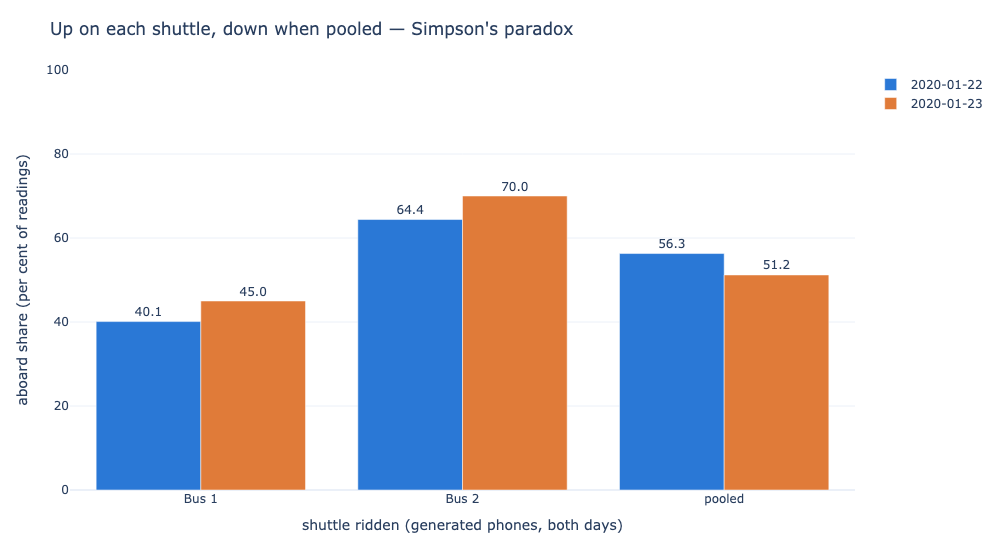

  Bus 1, 22 January, per cent aboard                                 deck 40.1      computed 40.1
  Bus 1, 23 January, per cent aboard                                 deck 45        computed 45.0
  Bus 2, 22 January, per cent aboard                                 deck 64.4      computed 64.4
  Bus 2, 23 January, per cent aboard                                 deck 70        computed 70.0
  pooled, 22 January, per cent aboard                                deck 56.3      computed 56.3
  pooled, 23 January, per cent aboard                                deck 51.2      computed 51.2
  pooled, change in points                                           deck -5.1      computed -5.1
  Bus 1, change in points                                            deck 4.9       computed 4.9
  Bus 2, change in points                                            deck 5.6       computed 5.6


In [38]:
table, points = figure_simpson()
for group, before, after in (("Bus 1", 40.1, 45), ("Bus 2", 64.4, 70), ("pooled", 56.3, 51.2)):
    agrees(f"{group}, 22 January, per cent aboard", table[group]["2020-01-22"]["share"], before, 1)
    agrees(f"{group}, 23 January, per cent aboard", table[group]["2020-01-23"]["share"], after, 1)
for group, stated in (("pooled", -5.1), ("Bus 1", 4.9), ("Bus 2", 5.6)):
    agrees(f"{group}, change in points", points[group], stated, 1)

## Laboratory 1 — Audit and align

*Slide: "Lab 1 — Audit and align".* Two functions, twenty-five minutes. The check
adds the ledger's buckets up, confirms which clock was used, runs Module 1's profile
on three frames whose answers differ, and grades the reversal and its name.

**The exercise, exactly as `Module 2/exercises/labs/01_audit_and_align.py` states it.**

> Lab 1 — Audit and align.
>
> Why this lab exists: the vehicle and the phones arrive on two different clocks at
> two different rates, and every number the rest of the course produces is computed
> from the table you make by putting them together. You prove here that you can
> choose a grain, join on the right clock, account for every input row, and tell
> the difference between a comparison of two days and a comparison of two fleets.
> Where it sits: Block one — "Bronze to silver — what changes, and what must not",
> and the definition slides "Definition — a tumbling window on the coordinated
> universal time grain", "Definition — the conservation ledger" and
> "Definition — Simpson's paradox".
> What the check grades: the ledger balances exactly and its reasons sum to the
> dropped count, on the shipped pair and on a day where the vehicle stops half way
> through; every window starts on the five-second grid in coordinated universal
> time inside the span the phones cover, one row per phone per window; the aligned
> table is consistent with the machine-readable profile Module 1 produced for the
> same slice, which ships here as data/module1_profile.json, and the ledger records
> what that profile says about the frame you were handed — graded on three frames
> whose answers differ, so neither an empty list nor a remembered complaint will
> do; and on the planted two-day
> frame the pooled difference, every per-shuttle difference, the reversal and its
> name are right — and on two frames that do not reverse, the verdict says so.
> Needs: pandas, numpy, plotly, and the loaders in lab_support.
>
> Twenty-five minutes.
>
> Two sources, two clocks, two rates. The vehicle reports about twice a second;
> the phones about once. Neither lines up with the other, and the moment you put
> them in one table you have made a decision about time whether you meant to or
> not.
>
> What you write: align(bus, phones, grain_seconds) and
> pooled_versus_by_group(frame, outcome, group, day).
>
> The job: put both sources on one grain -- tumbling windows of `grain_seconds`
> -- and account for every input row. Not "most" rows. Every one. Then compare the
> two days, once pooled and once inside each shuttle, and say what you find.
>
> Three traps, all of them in the real archive as well as here:
>
>   the wrong clock    Both frames carry a column named `timestamp` and a column
>                      holding coordinated universal time. The one named
>                      `timestamp` is local time, one hour ahead in January. Use
>                      it and your two sources are silently an hour apart, which
>                      looks like data rather than like an error.
>
>   the silent drop    A window with no vehicle reading, or a phone row outside
>                      the vehicle's operating hours, has nowhere to go. Dropping
>                      it quietly is how a table comes to describe a day that did
>                      not happen. Count it, and say why.
>
>   the grain itself   Five seconds is a choice. It is not the only one, and the
>                      ledger has to record which you made, because every number
>                      computed downstream depends on it.
>
> The table Module 1 handed over comes with a description of itself. It is in
> data/module1_profile.json, schema `aau-ce3/data-profile/1`, and it is not prose:
> per column a declared type, unit, range and tolerated absence, plus the time
> column and the rate the source is expected to report at. It is what Module 1's
> `declare_profile()` wrote, byte for byte.
>
> So do not read it -- run it. `load_module1_profile()` and `check_against(frame,
> profile)` are both in lab_support, the second copied unchanged from Module 1,
> and `align` calls them **before it joins anything** and puts the answer in the
> ledger under `profile_breaches`. An empty list is a result: it says the frame
> arrived as promised. Try the same call on one day of the slice instead of both
> and watch it stop being empty -- the pooled frame satisfies a declaration that
> its own first day does not, which is the paradox in the other half of this lab
> wearing a validation layer's clothes.
>
> The check also insists that you aligned the whole table Module 1
> profiled, that your grain is not finer than the interval the vehicle actually
> reports at, and that the negative speeds Module 1's declared range admits are
> still there. They
> are a property of the instrument, and the previous module wrote them down so
> that this one would not quietly tidy them away.
>
> Return (aligned, ledger):
>
>     aligned   one row per (phone_id, window_start), with the phone's readings
>               in that window and the vehicle's mean speed and mean payload in
>               the same window. Window start is a timestamp in coordinated
>               universal time.
>
>     ledger    a dict recording, at minimum:
>                 grain_seconds          the choice you were given
>                 bus_rows_in            rows of `bus` you received
>                 phone_rows_in          rows of `phones` you received
>                 windows_out            rows in `aligned`
>                 phone_rows_used        phone rows that landed in an output row
>                 phone_rows_dropped     phone rows that did not
>                 drop_reasons           {reason: count}, summing to phone_rows_dropped
>                 profile_breaches       what Module 1's profile says about `bus`,
>                                        as `check_against` returns it: the list of
>                                        complaints, empty when the frame satisfies
>                                        the declaration it arrived with
>
> The check asserts conservation: phone_rows_used + phone_rows_dropped must equal
> phone_rows_in, exactly. A ledger that does not balance is the whole lesson.
> `drop_reasons` may be empty on the shipped pair -- nothing was lost, so there is
> nothing to explain -- and may not be on the interrupted day.
>
> The second function is the one that changes how you read every two-day table
> after today. Two shuttles ran on 22 January and one on 23 January, so a pooled
> comparison of the days is partly a comparison of fleets. Report both.

```python
def align(bus, phones, grain_seconds: int = 5):
    """Put two sources on one grain, and account for every row.
    
    Definition graded by the check:
        w_j = [t_0 + j·Δ, t_0 + (j+1)·Δ), Δ = 5 s, t_0 = 00:00:00 in coordinated
        universal time, from utc_time
        (Akidau et al., 2015). Δ is `grain_seconds`; flooring a timestamp to the
        grain computes j. Slide: "Definition — a tumbling window on the
        coordinated universal time grain".
        used + dropped = received, with Σ_reason drop_reasons[reason] = dropped
        (Wang & Strong, 1996). Every phone row you were handed is either used or
        dropped with a reason; nothing is both and nothing is neither. Slide:
        "Definition — the conservation ledger".
        breaches(X, P) = the complaints P makes about X, over presence, type,
        range, tolerated absence and sampling step, in that order; X arrives fit
        for use exactly when breaches(X, P) is empty
        (Wang & Strong, 1996; Module 1's `declare_profile` writes P). P is the
        profile Module 1 handed over, `load_module1_profile()`; run
        `check_against(bus, P)` before you align anything and put the answer in
        the ledger, because a complaint that is not recorded on arrival is a
        complaint that will be argued about later. Slide: "Definition — the
        upstream profile, and checking a frame against it".
    Needs: pandas, len, load_module1_profile, check_against
    
    Returns:
        (aligned, ledger) -- see the module docstring for both shapes."""
```

```python
def pooled_versus_by_group(frame, outcome: str, group: str, day: str) -> dict:
    """Compare the two days pooled, and inside each group, and say whether they disagree.
    
    Definition graded by the check:
        P(Y|D=1) > P(Y|D=0) while P(Y|D=1,G=g) < P(Y|D=0,G=g) for every group g
        (Simpson, 1951; the name is Blyth's, 1972; the causal reading is Pearl's,
        2014). Here Y is `outcome` (aboard), D is `day` and G is `group` (the
        shuttle ridden). The reversal needs every group to move, and to move
        against the pool. Slide: "Definition — Simpson's paradox".
    Needs: pandas, numpy
    
    Returns a dict with:
        days      the two values of `day`, sorted, earlier first
        pooled    the later day's share of `outcome` minus the earlier day's,
                  over the whole frame. A share, so 0.05 is five points.
        by_group  the same difference inside each value of `group`
        shares    {group or "pooled": {day: share}}, for a figure
        reversal  True when every group moves against the pooled direction
        name      what that is called, when it is one, else None"""
```

**The stub's slide titles, against the deck.** The stub places the lab under "Bronze
to silver — what changes, and what must not"; no slide has that title. Block one opens
with "Know the distribution, then clean", and the bronze-and-silver rule is the slide
"Silver is derived and rebuildable, and bronze must never be modified", at the start
of Block two. The four definition slides it names carry exactly those titles. The
stub also cites Wang and Strong (1996) twice: for the profile ("fit for use" is their
definition of data quality) it fits; for the conservation ledger it does not — the
paper states no such identity, which is bookkeeping. The closing section checks every
title the stubs quote against the deck.

### The solution

**Goal.** Define the two functions as the Lab 1 solution writes them.

**Why.** `align` makes the three decisions explicitly — which clock, which grain (Akidau et al., 2015), what happens to the leftovers — keeps the books, and records Module 1's verdict on the frame; `pooled_versus_by_group` reports both comparisons and names the reversal (Simpson, 1951; Blyth, 1972; Pearl, 2014).

**What the code does.** Copies `LAB`, `SIMPSON`, `align` and `pooled_versus_by_group` from `solutions/lab_01.py`, with their docstrings.

**So what.** Two functions; the next cells run them as the stub and the solution do.

In [39]:
# Source: Module 2/exercises/solutions/lab_01.py — LAB, SIMPSON, align, pooled_versus_by_group, verbatim
# References: (Akidau et al., 2015; Simpson, 1951; Blyth, 1972; Pearl, 2014)

import sys
import pathlib
import numpy as np
import pandas as pd
import plotly.graph_objects as go


LAB = 1


SIMPSON = "Simpson's paradox"


def align(bus, phones, grain_seconds: int = 5):
    """Put two sources on one grain, and account for every row.

    The three decisions, made explicitly rather than by accident:

    1. **Which clock.** Both frames carry a column named `timestamp` that is
       local time and a column that is coordinated universal time. In January
       Copenhagen is one hour ahead, so using the friendly-looking name puts the
       two sources an hour apart -- and nothing complains, because both columns
       parse and both look like times. Always join on the coordinated column.

    2. **The grain.** Five seconds is a choice, not a fact. The vehicle reports
       twice a second and the phones once, so any common grain throws some
       resolution away; a coarser one throws away more and matches more. The
       ledger records which was used, because every downstream number depends
       on it. Tumbling windows w_j = [t_0 + j·Δ, t_0 + (j+1)·Δ), Δ the grain,
       t_0 midnight in coordinated universal time -- which is what flooring a
       timestamp to the grain computes.

    3. **What happens to the leftovers.** A phone row in a window with no
       vehicle reading has nowhere to go. Dropping it silently is how a table
       comes to describe a day that did not happen, so it is counted and given
       a reason. The check adds the buckets up and insists they balance:
       used + dropped = received, and the reasons sum to dropped.
    """
    grain = f"{grain_seconds}s"

    # Before anything is joined: what does the module upstream say about the
    # frame that just arrived? Module 1 declared this table's columns, their
    # ranges, the absence each one tolerates and the rate it reports at, and
    # `check_against` is Module 1's own function applied to what we were handed.
    #
    # Recording the answer is the point, not passing it. An empty list is a
    # measurement too: it says the frame arrived as promised, and it is the
    # sentence that makes the non-empty case worth anything. Note what happens
    # on the whole slice against one day of it -- the pooled frame satisfies the
    # declaration and the first day alone does not, which is the same shape as
    # the paradox in the other half of this lab.
    breaches = check_against(bus, load_module1_profile())

    bus = bus.copy()
    bus["_t"] = pd.to_datetime(bus["utc_time"], utc=True)
    bus["window"] = bus["_t"].dt.floor(grain)
    per_window_bus = bus.groupby("window").agg(
        bus_speed=("speed", "mean"),
        bus_payload=("payload", "mean"),
        bus_readings=("speed", "size"),
    )

    phones = phones.copy()
    phones["_t"] = pd.to_datetime(phones["timestamp_utc"], utc=True, errors="coerce")

    # Reason one: a row whose clock will not parse cannot be placed in time.
    unparseable = int(phones["_t"].isna().sum())
    phones = phones.dropna(subset=["_t"])
    phones["window"] = phones["_t"].dt.floor(grain)

    per_window_phone = phones.groupby(["phone_id", "window"]).agg(
        phone_readings=("speed", "size"),
        phone_speed=("speed", "mean"),
        rssi1=("rssi1", "mean"),
        rssi2=("rssi2", "mean"),
        aboard=("label2", lambda values: (values == "IN").mean()),
    ).reset_index()

    aligned = per_window_phone.merge(
        per_window_bus, left_on="window", right_index=True, how="inner")

    # Reason two: a window with no vehicle reading at all. The inner join above
    # removed those rows, so they are counted here rather than lost.
    kept_windows = set(zip(aligned["phone_id"], aligned["window"]))
    used = int(per_window_phone.apply(
        lambda row: (row["phone_id"], row["window"]) in kept_windows, axis=1)
        .mul(per_window_phone["phone_readings"]).sum())

    dropped_no_vehicle = int(per_window_phone["phone_readings"].sum() - used)

    ledger = {
        "grain_seconds": grain_seconds,
        "bus_rows_in": int(len(bus)),
        "phone_rows_in": int(len(phones) + unparseable),
        "windows_out": int(len(aligned)),
        "phone_rows_used": used,
        "phone_rows_dropped": dropped_no_vehicle + unparseable,
        "drop_reasons": {
            "timestamp would not parse": unparseable,
            "no vehicle reading in the window": dropped_no_vehicle,
        },
        "profile_breaches": breaches,
    }
    return aligned.reset_index(drop=True), ledger


def pooled_versus_by_group(frame, outcome: str, group: str, day: str) -> dict:
    """The two-day comparison, pooled and inside each group -- and whether they disagree.

    Before you compare two days you have to know what each day is made of. The
    archive's two days are not the same fleet: two shuttles ran on 22 January
    and one on 23 January, so a pooled comparison of the days is partly a
    comparison of shuttles. In the generated phones the same thing is planted on
    purpose: the second day has fewer volunteers and most of them rode the
    shuttle whose riders spend the smaller share of their time aboard.

    So the aboard share *rises* on each shuttle and *falls* pooled. Both numbers
    are correct; they answer different questions. When the sign inside every
    group is the opposite of the pooled sign, that is Simpson's paradox
    (Simpson, 1951; the name is Blyth's, 1972), and the honest report says which
    comparison you made -- Pearl (2014) is the reading on which one to trust,
    and the answer depends on what caused the mix to change.

    Returns a dict with `days` (the two day values, sorted), `pooled` (the
    later day's share minus the earlier day's, pooled), `by_group` (the same
    difference inside each group), `shares` (the shares themselves, for a
    figure), `reversal` (True when every group moves against the pool) and
    `name` (Simpson's paradox when it is one, else None). Differences are in
    shares, so 0.05 is five percentage points.
    """
    days = sorted(pd.unique(frame[day]))
    assert len(days) == 2, f"expected two values of {day!r}, found {len(days)}"
    earlier, later = days
    aboard = frame[outcome].astype(bool)

    def share(rows) -> float:
        return float(aboard[rows].mean()) if rows.any() else float("nan")

    on_day = {d: frame[day] == d for d in days}
    shares = {"pooled": {d: share(on_day[d]) for d in days}}
    for g in sorted(pd.unique(frame[group])):
        shares[g] = {d: share(on_day[d] & (frame[group] == g)) for d in days}

    pooled = shares["pooled"][later] - shares["pooled"][earlier]
    by_group = {g: shares[g][later] - shares[g][earlier]
                for g in shares if g != "pooled"}

    # A reversal needs every group to move, and to move against the pool. A
    # group that did not move, or was absent on one day, settles nothing.
    moves = [d for d in by_group.values() if not np.isnan(d)]
    reversal = bool(
        pooled != 0 and len(moves) == len(by_group) and moves
        and all(d != 0 and np.sign(d) == -np.sign(pooled) for d in moves))

    return {"days": (earlier, later), "pooled": pooled, "by_group": by_group,
            "shares": shares, "reversal": reversal,
            "name": SIMPSON if reversal else None}

**Goal.** Register the solved Lab 1 under the name the other labs import it by.

**Why.** The Lab 4 solution does `from lab_01 import align`.

**What the code does.** Puts a module named `lab_01` holding the two functions into `sys.modules`.

**So what.** The import in Lab 4 will find the function above, not the file.

In [40]:
as_module("lab_01", align=align, pooled_versus_by_group=pooled_versus_by_group, SIMPSON=SIMPSON)

**Goal.** Run the stub's own demonstration against the solved functions.

**Why.** It is what a student sees when the file is complete.

**What the code does.** The lines below are the stub's `__main__` block, verbatim.

**So what.** An aligned table, the ledger, Module 1's verdict on the vehicle frame, and the reversal.

In [41]:
# Source: Module 2/exercises/labs/01_audit_and_align.py — demonstration step 0, verbatim

say = narrator(LAB)
aligned, ledger = align(load_bus(), load_phones(), 5)
say.info("aligned: %s rows", f"{len(aligned):,}")
say.info("what Module 1's profile says about the vehicle frame we were handed: %s",
         ledger["profile_breaches"] or "nothing — it satisfies the declaration")
show_table(pd.DataFrame({"count": ledger})
           .drop(index=["drop_reasons", "profile_breaches"])
           .rename_axis("ledger"), "the ledger", logger=say)
verdict = pooled_versus_by_group(load_simpson(), "aboard", "bus", "day")
say.info("pooled %+.3f, by group %s, reversal %s, named %r", verdict["pooled"],
         verdict["by_group"], verdict["reversal"], verdict["name"])

 12.53s  lab 1  aligned: 2,148 rows
 12.54s  lab 1  what Module 1's profile says about the vehicle frame we were handed: nothing — it satisfies the declaration
 12.54s  lab 1  --- the ledger (6 rows) ---
 12.54s  lab 1                          count
 12.54s  lab 1      ledger                   
 12.54s  lab 1      grain_seconds           5
 12.54s  lab 1      bus_rows_in         48290
 12.54s  lab 1      phone_rows_in       10800
 12.54s  lab 1      windows_out          2148
 12.54s  lab 1      phone_rows_used     10800
 12.54s  lab 1      phone_rows_dropped      0
 12.56s  lab 1  pooled -0.051, by group {'Bus 1': 0.048888888888888926, 'Bus 2': 0.05555555555555547}, reversal True, named "Simpson's paradox"


**Goal.** Ask the ledger the archive's question about unparseable timestamps.

**Why.** The archive's phone file loses 6 rows when a reader infers one timestamp format, and none when told the formats are mixed (the slide saying so is hidden; the ledger's slide names the reason). The generated phones are clean, so the ledger's reason "timestamp would not parse" counts 0 here.

**What the code does.** Runs `align` on the generated day, then on a copy with six timestamps made unreadable, and prints the archive's recorded counts beside.

**So what.** The reason and its count appear in the ledger either way; that is what makes "six unparseable rows" a recorded decision rather than a silent loss.

In [42]:
_, ledger = align(bus, phones, 5)
broken = phones.copy()
broken["timestamp_utc"] = broken["timestamp_utc"].dt.strftime("%Y-%m-%d %H:%M:%S.%f+00:00")
broken.loc[broken.index[-6:], "timestamp_utc"] = "not a time"
_, broken_ledger = align(bus, broken, 5)
print("generated day:", ledger["drop_reasons"])
print("six timestamps broken:", broken_ledger["drop_reasons"],
      "— balances:", broken_ledger["phone_rows_used"] + broken_ledger["phone_rows_dropped"]
      == broken_ledger["phone_rows_in"])
beside("unparseable phone timestamps", ledger["drop_reasons"]["timestamp would not parse"],
       f"{archive('unparseable_timestamps')} when told the formats are mixed, "
       f"{archive('unparseable_if_one_format_assumed')} when one format is inferred (archive)",
       "the generated timestamps are all well formed; the archive's six are a property "
       "of how its file is read")

generated day: {'timestamp would not parse': 0, 'no vehicle reading in the window': 0}
six timestamps broken: {'timestamp would not parse': 6, 'no vehicle reading in the window': 0} — balances: True
  unparseable phone timestamps: computed here 0; stated 0 when told the formats are mixed, 6 when one format is inferred (archive) — the generated timestamps are all well formed; the archive's six are a property of how its file is read


### The solution's demonstration, step by step

What `python3 solutions/lab_01.py` prints, run here one paragraph of its `__main__`
block at a time, each verbatim. It adds what the stub's demonstration does not: an
interrupted vehicle day, where the ledger has something to account for; the profile
run on one day against both; and the reversal's figure.

**Goal.** Start the demonstration's narrator.

**Why.** Every line the solution prints goes through one logger, so that the terminal and this notebook show the same story in the same words.

**What the code does.** Creates `say`, the narrator for Lab 1, and prints the lab's one-line summary.

**So what.** Each line below begins with the seconds since this cell ran — the one part of the output that changes from run to run.

In [43]:
# Source: Module 2/exercises/solutions/lab_01.py — demonstration, paragraph 1 of 7, verbatim

say = narrator(LAB)
say.info("Lab 1 — one grain, a ledger that balances, and a two-day comparison "
         "that reverses when it is pooled")

 13.35s  lab 1  Lab 1 — one grain, a ledger that balances, and a two-day comparison that reverses when it is pooled


**Goal.** Align the shipped pair on the five-second grid and read the ledger.

**Why.** This is the lab's first deliverable at work on the real slice and the first generated day: one clock (`utc_time`), one grain (5 s, because neither 0.5 s nor 0.993 s divides the other), and the books kept.

**What the code does.** Loads both files, calls `align(bus, phones, 5)`, prints the table's size, Module 1's verdict on the vehicle frame, the ledger as a table, the drop reasons, and the conservation identity used + dropped = received.

**So what.** On the shipped pair nothing is dropped and the identity holds trivially; the next paragraph gives the ledger something to count.

In [44]:
# Source: Module 2/exercises/solutions/lab_01.py — demonstration, paragraph 2 of 7, verbatim

bus, phones = load_bus(), load_phones()
say.info("vehicle telemetry: %s rows (archive slice, shuttle VJRD1A10224000055); "
         "phones: %s rows (generated, seed 20200122, first day)", f"{len(bus):,}",
         f"{len(phones):,}")
say.info("grain 5 s on utc_time, because the vehicle reports twice a second and "
         "the phones once — neither rate divides the other")
aligned, ledger = align(bus, phones, 5)
say.info("aligned table: %s rows, one per phone per 5-second window; "
         "%s of %s phone rows landed", f"{len(aligned):,}",
         f"{ledger['phone_rows_used']:,}", f"{ledger['phone_rows_in']:,}")
say.info("Module 1's profile, run over the vehicle frame before anything was "
         "joined: %s", ledger["profile_breaches"] or "no complaints — the frame "
         "arrived as the declaration promised")
show_table(pd.DataFrame({"count": ledger})
           .drop(index=["drop_reasons", "profile_breaches"])
           .rename_axis("ledger"), "the ledger", logger=say)
say.info("drop reasons: %s — every dropped row has one", ledger["drop_reasons"])
say.info("conservation: %s used + %s dropped = %s received: %s",
         ledger["phone_rows_used"], ledger["phone_rows_dropped"],
         ledger["phone_rows_in"],
         ledger["phone_rows_used"] + ledger["phone_rows_dropped"] == ledger["phone_rows_in"])

 13.64s  lab 1  vehicle telemetry: 48,290 rows (archive slice, shuttle VJRD1A10224000055); phones: 10,800 rows (generated, seed 20200122, first day)
 13.64s  lab 1  grain 5 s on utc_time, because the vehicle reports twice a second and the phones once — neither rate divides the other
 13.99s  lab 1  aligned table: 2,148 rows, one per phone per 5-second window; 10,800 of 10,800 phone rows landed
 13.99s  lab 1  Module 1's profile, run over the vehicle frame before anything was joined: no complaints — the frame arrived as the declaration promised
 13.99s  lab 1  --- the ledger (6 rows) ---
 13.99s  lab 1                          count
 13.99s  lab 1      ledger                   
 13.99s  lab 1      grain_seconds           5
 13.99s  lab 1      bus_rows_in         48290
 13.99s  lab 1      phone_rows_in       10800
 13.99s  lab 1      windows_out          2148
 14.00s  lab 1      phone_rows_used     10800
 14.00s  lab 1      phone_rows_dropped      0
 14.00s  lab 1  drop reasons: {'timest

**Goal.** Cut the vehicle day in half and align again.

**Why.** A ledger that only ever balances on complete data proves nothing; this is the day the check also uses.

**What the code does.** Keeps the vehicle readings before the midpoint of the phones' span, aligns, and prints how many phone rows were dropped and why.

**So what.** Every phone row after the vehicle stopped is dropped with a reason, and used + dropped still equals received.

In [45]:
# Source: Module 2/exercises/solutions/lab_01.py — demonstration, paragraph 3 of 7, verbatim

# A day where the vehicle stops half way through, so that the ledger has
# something to account for -- the same day the check uses.
utc = pd.to_datetime(phones["timestamp_utc"], utc=True)
midpoint = utc.min() + (utc.max() - utc.min()) / 2
interrupted = bus[pd.to_datetime(bus["utc_time"], utc=True) < midpoint]
_, short = align(interrupted, phones, 5)
say.info("vehicle stopping at %s: %s phone rows dropped, reasons %s — the books "
         "still balance: %s", midpoint.strftime("%H:%M:%S"),
         f"{short['phone_rows_dropped']:,}", short["drop_reasons"],
         short["phone_rows_used"] + short["phone_rows_dropped"] == short["phone_rows_in"])

 14.30s  lab 1  vehicle stopping at 09:07:26: 5,352 phone rows dropped, reasons {'timestamp would not parse': 0, 'no vehicle reading in the window': 5352} — the books still balance: True


**Goal.** Run Module 1's profile on one day of the vehicle frame instead of both.

**Why.** The profile is an examination; an examination made only on the pooled frame can miss what one day breaks.

**What the code does.** Keeps 22 January's vehicle readings, aligns them, and prints the profile's verdict on both days beside its verdict on the one day.

**So what.** No complaints on the pool, complaints on 22 January alone: the module's paradox in a validation layer.

In [46]:
# Source: Module 2/exercises/solutions/lab_01.py — demonstration, paragraph 4 of 7, verbatim

# The same declaration, on one day of the frame instead of both. It is the
# module's own paradox in a validation layer: the aggregate check passes and
# the per-group check fails, so an examination made only on the pool would
# have reported nothing wrong.
day_one = bus[pd.to_datetime(bus["utc_time"], utc=True).dt.date.astype(str)
              == "2020-01-22"]
_, per_day = align(day_one, phones, 5)
say.info("profile over both days: %s; over 22 January alone: %s — an examination "
         "made on the pool only would have found nothing",
         ledger["profile_breaches"] or "no complaints", per_day["profile_breaches"])

 14.67s  lab 1  profile over both days: no complaints; over 22 January alone: ['emergency_stop: absent on 0.5220 of rows, above the declared 0.48426.'] — an examination made on the pool only would have found nothing


**Goal.** Compare the two generated days pooled and per shuttle.

**Why.** This is the second deliverable: `pooled_versus_by_group` must report both comparisons and name the reversal when every group moves against the pool (Simpson, 1951; Blyth, 1972).

**What the code does.** Loads the two-day Simpson frame, calls `pooled_versus_by_group(simpson, "aboard", "bus", "day")`, and prints the shares in per cent, the pooled difference, each shuttle's difference, and the verdict.

**So what.** The pooled share falls from the first day to the second while each shuttle's rises; the function says so, and names it.

In [47]:
# Source: Module 2/exercises/solutions/lab_01.py — demonstration, paragraph 5 of 7, verbatim

simpson = load_simpson()
say.info("both generated days: %s rows, %s phones on %s and %s on %s",
         f"{len(simpson):,}",
         simpson.loc[simpson['day'] == '2020-01-22', 'phone_id'].nunique(), "2020-01-22",
         simpson.loc[simpson['day'] == '2020-01-23', 'phone_id'].nunique(), "2020-01-23")
verdict = pooled_versus_by_group(simpson, "aboard", "bus", "day")
table = pd.DataFrame(verdict["shares"]).T.mul(100).round(1)
table.columns = [f"{d} (per cent aboard)" for d in table.columns]
show_table(table, "aboard share by day, pooled and per shuttle", logger=say)
say.info("pooled, later day minus earlier: %+.1f points; per shuttle: %s points",
         verdict["pooled"] * 100,
         {g: f"{d * 100:+.1f}" for g, d in verdict["by_group"].items()})
say.info("every shuttle moves against the pool: reversal=%s, named %r — the pooled "
         "line compares fleets, not days", verdict["reversal"], verdict["name"])

 14.69s  lab 1  both generated days: 18,000 rows, 12 phones on 2020-01-22 and 8 on 2020-01-23
 14.70s  lab 1  --- aboard share by day, pooled and per shuttle (3 rows) ---
 14.70s  lab 1              2020-01-22 (per cent aboard)  2020-01-23 (per cent aboard)
 14.70s  lab 1      pooled                          56.3                          51.2
 14.70s  lab 1      Bus 1                           40.1                            45
 14.70s  lab 1      Bus 2                           64.4                            70
 14.70s  lab 1  pooled, later day minus earlier: -5.1 points; per shuttle: {'Bus 1': '+4.9', 'Bus 2': '+5.6'} points
 14.71s  lab 1  every shuttle moves against the pool: reversal=True, named "Simpson's paradox" — the pooled line compares fleets, not days


**Goal.** Draw the reversal.

**Why.** The slide's figure, drawn by the lab from the verdict it just returned.

**What the code does.** Grouped bars of the aboard share, per shuttle and pooled, one colour per day; `save_figure` shows it here.

**So what.** Up on each shuttle, down when pooled, in one picture.

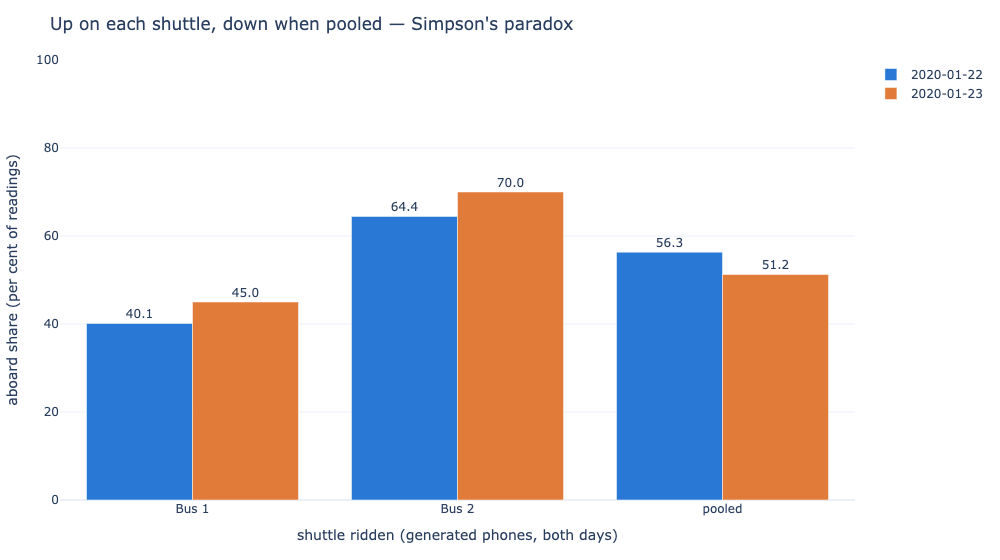

 14.78s  lab 1  figure -> shown here (lab_01_simpson)


In [48]:
# Source: Module 2/exercises/solutions/lab_01.py — demonstration, paragraph 6 of 7, verbatim

earlier, later = verdict["days"]
groups = [g for g in verdict["shares"] if g != "pooled"] + ["pooled"]
fig = go.Figure()
for d, colour in ((earlier, "#2A78D6"), (later, "#E07B39")):
    fig.add_bar(name=d, x=groups, y=[verdict["shares"][g][d] * 100 for g in groups],
                marker_color=colour,
                text=[f"{verdict['shares'][g][d] * 100:.1f}" for g in groups],
                textposition="outside")
fig.update_layout(barmode="group", yaxis_title="aboard share (per cent of readings)",
                  xaxis_title="shuttle ridden (generated phones, both days)",
                  yaxis_range=[0, 100],
                  title="Up on each shuttle, down when pooled — Simpson's paradox")
save_figure(fig, "simpson", LAB, logger=say)

**Goal.** Print what the check grades.

**Why.** The demonstration ends by telling the student what `verify/check_01.py` will ask.

**What the code does.** One narrated line.

**So what.** The ledger is graded on two days, the grid on its grain, and the reversal on a planted frame, not on the shipped one.

In [49]:
# Source: Module 2/exercises/solutions/lab_01.py — demonstration, paragraph 7 of 7, verbatim

say.info("what the check grades: used + dropped = received with the reasons summing to "
         "dropped, on the shipped pair and on the interrupted day; windows on the "
         "5-second UTC grid inside the phones' span; and on the planted frame the "
         "pooled difference, every group difference, reversal=True and the name")

 14.79s  lab 1  what the check grades: used + dropped = received with the reasons summing to dropped, on the shipped pair and on the interrupted day; windows on the 5-second UTC grid inside the phones' span; and on the planted frame the pooled difference, every group difference, reversal=True and the name


---
# Block 2 — Missingness is a mechanism

**The question of this block:** why is a reading absent — and once you fill it,
what did you invent, and what did you flatten?

*Slide: "Silver is derived and rebuildable, and bronze must never be modified".*
The original data (bronze) never change; every cleaned table (silver) is derived,
disposable and rebuildable, and every decision taken on the way is recorded. The
working copy this notebook runs in is that rule applied to the notebook itself.

### The three missing-data mechanisms

*Slide: "Definition — the three missing-data mechanisms".*

**Goal.** Write the three mechanisms as conditional probabilities.

**Why.** Whether a gap can be filled honestly depends on what the absence depends on: nothing (MCAR), values you can see (MAR), or the missing value itself (MNAR) (Rubin, 1976, Definitions 1 and 2; Little & Rubin, 2019; van Buuren, 2018, § 1.2).

**What the code does.** Writes the three statements as sympy relations, with M the absence indicator, Y_obs what is seen and Y_mis what is not: MCAR and MAR are equalities, and MNAR is the case where the dependence on Y_mis does not drop out.

**So what.** Signal strength falls with distance and a beacon is heard only when it is near, so a reading is absent because it was weak: the third case.

In [50]:
P = sp.Function("P")
given_both = P(sp.Symbol(r"M \mid Y_{obs}, Y_{mis}"))
given_seen = P(sp.Symbol(r"M \mid Y_{obs}"))
formula(sp.Symbol(r"\text{MCAR:}"), sp.Eq(given_both, P(sp.Symbol("M")), evaluate=False))
formula(sp.Symbol(r"\text{MAR:}"), sp.Eq(given_both, given_seen, evaluate=False))
formula(sp.Symbol(r"\text{MNAR:}"), sp.Ne(given_both, given_seen, evaluate=False))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Apply each mechanism to the same true signal and see what a mean fill does.

**Why.** The slide's picture is a generated poster of the three cases. The generator holds the true signal strength of every reading, heard or not, so the three mechanisms can be imposed on one column and their consequences measured (van Buuren, 2018, § 1.3.3).

**What the code does.** Takes beacon 1's true signal on the first generated day and three masks of about the real one's size (88.7 per cent absent). MCAR: a random mask. MAR needs an observed column that carries the signal, and the generated phones have none — their speed and their other beacons are drawn independently of beacon 1's distance — so the cell makes one, labelled illustrative: the distance to the beacon as a satellite fix would report it, the true distance plus 5 metres of normal error (a stated choice; the lab data carry no fix error). The MAR mask drops a reading with a probability that depends on that observed distance only, rising with its rank from about 0.79 for the nearest reading to about 0.99 for the farthest, so that every tenth of the distance keeps some readings. MNAR: the generator's own mask, where the weak readings are the absent ones. For each mask the cell computes two fills' bias on the absent rows: the mean of the kept readings, and the mean of the kept readings *in the same tenth of the observed distance* — conditioning on what is seen (van Buuren, 2018, § 1.2).

**So what.** Under MCAR both fills are unbiased. Under MAR the mean fill is too strong, because the kept readings are the near ones, and conditioning on the observed distance repairs it: within a tenth of the distance the kept and the absent readings are alike. Under MNAR the mean fill is more than ten decibels too strong, and conditioning shrinks the error without removing it, because within a tenth of the distance the absent readings are still the weaker ones. The mechanism, not the method, decides — and the archive is the third case.

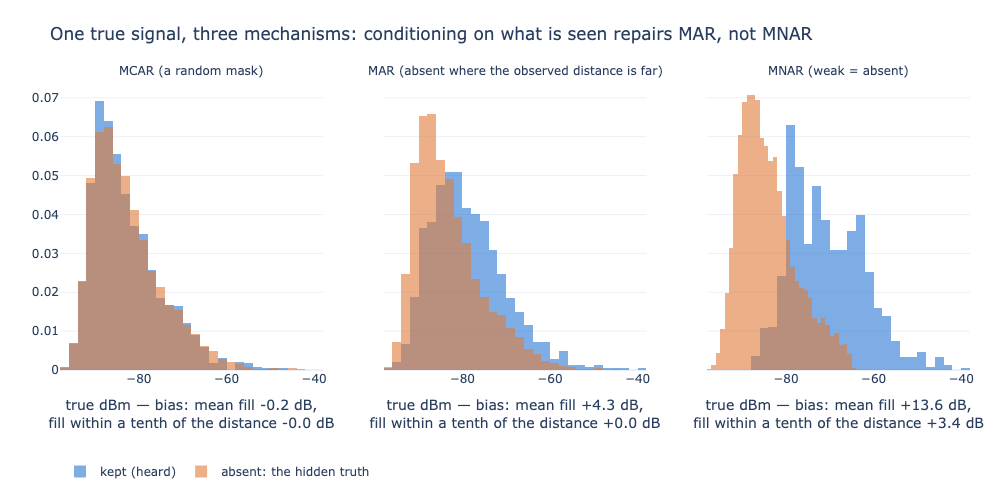

                                                 absent share  mean fill, dB  conditional fill, dB  fewest kept rows in a tenth
MCAR (a random mask)                                    0.892          -0.22                 -0.02                        102.0
MAR (absent where the observed distance is far)         0.884           4.30                  0.02                         26.0
MNAR (weak = absent)                                    0.887          13.58                  3.41                          2.0
  correlation of the observed distance's logarithm with the true signal: -0.893
  absence of the vehicle beacon (rssi1), archive: computed here 57.0 %; stated "the vehicle beacon is silent on 57% to 86% of rows" (the slide's poster) — the range 57 to 86.3 per cent spans all five beacons; the vehicle beacon alone is silent on 57.0 per cent


In [51]:
signal_true = truth["rssi1_true"].to_numpy(float)
real_mask = phones["rssi1"].isna().to_numpy()
rate = real_mask.mean()
rng = np.random.default_rng(20200122)
# Illustrative: an observed distance, as a satellite fix with 5 m of error would give it.
seen_distance = np.clip(truth["rssi1_distance_true"].to_numpy(float) + rng.normal(0, 5.0, len(truth)), 0.5, None)
far_rank = stats.rankdata(seen_distance) / len(seen_distance)            # 0 near … 1 far
p_absent = rate - 0.1 + 0.2 * far_rank                                   # 0.79 … 0.99
masks = {"MCAR (a random mask)": rng.random(len(truth)) < rate,
         "MAR (absent where the observed distance is far)": rng.random(len(truth)) < p_absent,
         "MNAR (weak = absent)": real_mask}
tenth = np.minimum((far_rank * 10).astype(int), 9)                       # tenths of the observed distance

def fill_biases(mask):
    mean_fill = float(signal_true[~mask].mean() - signal_true[mask].mean())
    kept_by_tenth = pd.Series(signal_true[~mask]).groupby(tenth[~mask]).mean()
    conditional = pd.Series(tenth[mask]).map(kept_by_tenth).to_numpy()
    return mean_fill, float(np.mean(conditional - signal_true[mask])), int(pd.Series(~mask).groupby(tenth).sum().min())

fig = make_subplots(rows=1, cols=3, subplot_titles=list(masks), shared_yaxes=True)
rows_out = {}
for col, (label, mask) in enumerate(masks.items(), start=1):
    for rows, name, colour in ((~mask, "kept (heard)", BLUE), (mask, "absent: the hidden truth", ORANGE)):
        fig.add_histogram(x=signal_true[rows], histnorm="probability density", nbinsx=40,
                          marker_color=colour, opacity=0.6, name=name, showlegend=col == 1,
                          row=1, col=col)
    mean_fill, conditional, fewest = fill_biases(mask)
    fig.update_xaxes(title_text=f"true dBm — bias: mean fill {mean_fill:+.1f} dB,<br>"
                                f"fill within a tenth of the distance {conditional:+.1f} dB", row=1, col=col)
    rows_out[label] = {"absent share": round(float(mask.mean()), 3), "mean fill, dB": round(mean_fill, 2),
                       "conditional fill, dB": round(conditional, 2), "fewest kept rows in a tenth": fewest}
fig.update_annotations(font_size=12)
fig.update_layout(barmode="overlay", legend=dict(orientation="h", y=-0.3), margin=dict(l=60, r=30, t=80, b=130),
                  title="One true signal, three mechanisms: conditioning on what is seen repairs MAR, not MNAR")
show(fig, "three_mechanisms", height=500)
print(pd.DataFrame(rows_out).T.to_string())
print(f"  correlation of the observed distance's logarithm with the true signal: "
      f"{np.corrcoef(np.log10(seen_distance), signal_true)[0, 1]:.3f}")
beside("absence of the vehicle beacon (rssi1), archive", f"{archive('beacon_absent_share')['rssi1']} %",
       "\"the vehicle beacon is silent on 57% to 86% of rows\" (the slide's poster)",
       "the range 57 to 86.3 per cent spans all five beacons; the vehicle beacon alone is "
       "silent on 57.0 per cent")

**Goal.** Draw the geometry behind an absent reading.

**Why.** The slide's diagram places a phone, a vehicle and a beacon on a map: the phone's distance to the vehicle by satellite positioning (d_GPS) and its distance to a beacon (d_BLE). A reading exists only if the phone is in range, the packet arrives, and the signal registers; out of range is informative, a lost packet is not (Servizi et al., 2023).

**What the code does.** Draws the loop from the slice; stop A, the stop inferred on the route map where the doors opened most often; the vehicle's reported position at the first reading on the loop's north edge on 23 January; and a phone placed 10 metres from the stop (an illustrative position — the lab data have no phone positions), with both distances. The slide's diagram draws the phone between two shuttles. The lab slice holds one shuttle, so a second vehicle position cannot be drawn from data; the second end of the picture is a stop instead, which is the comparison that matters in Block 2 — aboard against waiting nearby.

**So what.** Every distance on this map is tens of metres at most: the scale at which proximity has to separate aboard from waiting.

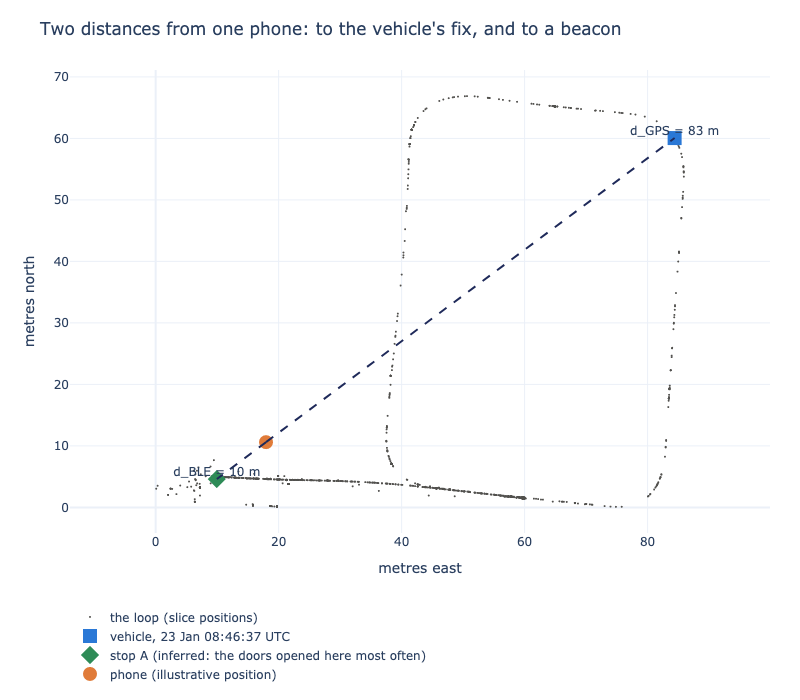

  d_GPS = 82.8 m, d_BLE = 10.0 m


In [52]:
east, north = to_metres(bus["lat"], bus["lon"])
positions = np.column_stack(to_metres(in_time["lat"], in_time["lon"]))
on_north_edge = np.where((positions[:, 1] > 60) & (in_time["_t"].dt.date.astype(str) == "2020-01-23"))[0]
vehicle = positions[on_north_edge[0]]
stop = stops.loc["stop A", ["east", "north"]].to_numpy(float)
phone = stop + np.array([8.0, 6.0])                     # illustrative: 10 m from the stop
d_gps, d_ble = np.linalg.norm(phone - vehicle), np.linalg.norm(phone - stop)
fig = go.Figure()
fig.add_scatter(x=east[::20], y=north[::20], mode="markers", marker=dict(color=GREY, size=2),
                name="the loop (slice positions)")
moment = in_time["_t"].iloc[on_north_edge[0]]
for point, label, colour, symbol in ((vehicle, f"vehicle, {moment:%d %b %H:%M:%S} UTC", BLUE, "square"),
                                     (stop, "stop A (inferred: the doors opened here most often)", GREEN, "diamond"),
                                     (phone, "phone (illustrative position)", ORANGE, "circle")):
    fig.add_scatter(x=[point[0]], y=[point[1]], mode="markers", name=label,
                    marker=dict(color=colour, size=14, symbol=symbol))
for end, label in ((vehicle, f"d_GPS = {d_gps:.0f} m"), (stop, f"d_BLE = {d_ble:.0f} m")):
    fig.add_scatter(x=[phone[0], end[0]], y=[phone[1], end[1]], mode="lines+text",
                    line=dict(color=NAVY, dash="dash"), text=["", label],
                    textposition="top center", showlegend=False)
fig.update_layout(title="Two distances from one phone: to the vehicle's fix, and to a beacon",
                  xaxis_title="metres east", yaxis_title="metres north", yaxis_scaleanchor="x",
                  legend=dict(orientation="h", y=-0.15))
show(fig, "phone_bus_geometry", width=800, height=700)
print(f"  d_GPS = {d_gps:.1f} m, d_BLE = {d_ble:.1f} m")

### How much is absent, and how it is written down

*Slides: "Most beacons carry no reading on most rows, and absence is encoded twice" and "The vehicle beacon is heard more often when the passenger is not aboard".*

**Goal.** Draw each beacon's share of absent readings with the deck's own function, fed the lab data.

**Why.** The slide measures the archive: 57 to 86.3 per cent of rows carry no reading. The generator was calibrated to be heard at the archive's rate *within each aboard state*, which reproduces the association with the label rather than the marginal shares, so the lab data's shares differ.

**What the code does.** Copies `figure_absence()` from `make_figs.py` verbatim and calls it with the generated day's shares in place of the archive's; prints the archive's beside. Then checks, on the generated rows, that the empty signal strength and the proximity of −1 mark the same rows.

**So what.** Most readings are absent in both worlds; the exact shares are the archive's, and are labelled so.

In [53]:
# Source: Module 2/slides/make_figs.py — figure_absence, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def figure_absence(facts) -> None:
    """How much of each beacon is absent — archive aggregates, one series."""
    shares = facts["beacon_absent_share"]["value"]
    names = list(shares)
    fig = go.Figure(go.Bar(x=names, y=[shares[n] for n in names], marker_color=BLUE,
                           text=[f"{shares[n]:.1f}" for n in names],
                           textposition="outside", showlegend=False))
    fig.update_yaxes(title_text="rows with no reading (per cent)", range=[0, 100])
    fig.update_xaxes(title_text="beacon (received signal strength column)")
    fig.update_layout(title="A beacon reading is absent more often than present")
    write(fig, "beacon_absence")

**Goal.** Draw the absence per beacon on the generated day, and print the archive's shares beside.

**Why.** The slide's chart is the archive's; the lab data can only show their own.

**What the code does.** Calls figure_absence() with the generated shares in the shape measured.json uses, then prints the archive's recorded shares and checks the double encoding on the generated rows.

**So what.** Absent more often than present on every beacon, in both worlds.

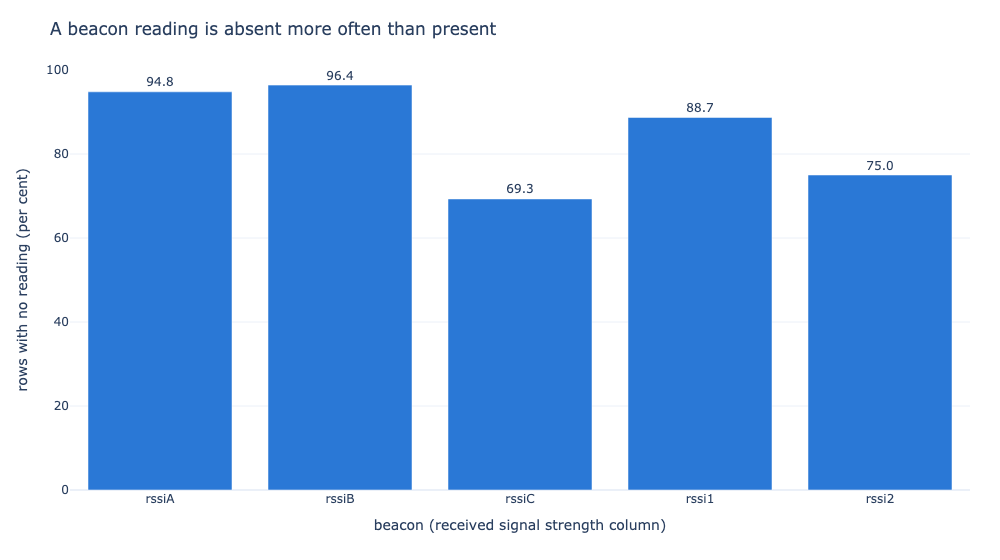

  absent per cent, per beacon: computed here {'rssiA': 94.8, 'rssiB': 96.4, 'rssiC': 69.3, 'rssi1': 88.7, 'rssi2': 75.0}; stated {'rssiA': 86.3, 'rssiB': 73.2, 'rssiC': 70.7, 'rssi1': 57.0, 'rssi2': 83.8} (archive) — the generator matches the archive's heard rates per aboard state, not its marginal shares
  range across the five beacons, per cent: computed here 69.3 to 96.4; stated 57 to 86.3 (archive) — as above
  absence encoded twice, and the two agree on every generated row: True (archive: True)


In [54]:
generated_absence = {b: round(float(phones[b].isna().mean()) * 100, 1)
                     for b in ["rssiA", "rssiB", "rssiC", "rssi1", "rssi2"]}
figure_absence({"beacon_absent_share": {"value": generated_absence}})
beside("absent per cent, per beacon", generated_absence, f"{archive('beacon_absent_share')} (archive)",
       "the generator matches the archive's heard rates per aboard state, not its marginal shares")
beside("range across the five beacons, per cent",
       f"{min(generated_absence.values())} to {max(generated_absence.values())}",
       "57 to 86.3 (archive)", "as above")
encoded_twice = all((phones[r].isna() == (phones[p] == -1)).all() for r, p in PROXIMITY.items())
print(f"  absence encoded twice, and the two agree on every generated row: {encoded_twice} "
      f"(archive: {archive('absence_encoded_twice')})")

**Goal.** Test the natural inference — an unheard vehicle beacon means not aboard — on the labelled rows.

**Why.** The slide measured it on the archive and refuted it: the vehicle beacon is heard on 8.8 per cent of aboard rows and 14.4 per cent of not-aboard rows, and "heard" agrees with "aboard" less often than the base rate of 56.3 per cent. The generator was calibrated to those rates, so the lab data can repeat the test.

**What the code does.** For each beacon on the first generated day: the share heard when aboard, when not aboard, and the agreement of "heard" with "aboard"; against the base rate.

**So what.** Answering "aboard" every time beats every beacon. A real mechanism does not make a useful feature; measure before relying on the physics.

In [55]:
labelled = phones[phones["label2"].notna()]
aboard = labelled["label2"] == "IN"
rows = {}
for b in ["rssiA", "rssiB", "rssiC", "rssi1", "rssi2"]:
    heard = labelled[b].notna()
    rows[b] = {"heard when aboard %": round(100 * heard[aboard].mean(), 1),
               "heard when not aboard %": round(100 * heard[~aboard].mean(), 1),
               "agreement with aboard %": round(100 * (heard == aboard).mean(), 1)}
table = pd.DataFrame(rows).T
print(table.to_string())
base_rate = 100 * aboard.mean()
agrees("base rate: per cent of labelled rows aboard", base_rate, archive("aboard_share_of_labelled"), 1)
agrees("vehicle beacon heard when aboard, per cent", table.loc["rssi1", "heard when aboard %"], 8.8, 1)
agrees("vehicle beacon heard when not aboard, per cent", table.loc["rssi1", "heard when not aboard %"], 14.4, 1)
print(f"  every beacon's agreement is below the base rate: "
      f"{bool((table['agreement with aboard %'] < base_rate).all())}")
beside("agreement range across beacons, per cent",
       f"{table['agreement with aboard %'].min()} to {table['agreement with aboard %'].max()}",
       "42.4 to 47.5 (archive)", "generated rows reproduce the archive's rates to within a "
       "tenth of a point, not exactly")
beside("labelled rows", f"{len(labelled):,}", f"{archive('labelled_rows'):,} (archive)",
       "the generator's first day has 12 phones x 900 readings")

       heard when aboard %  heard when not aboard %  agreement with aboard %
rssiA                  4.1                      6.6                     43.1
rssiB                  3.1                      4.2                     43.6
rssiC                 30.4                     31.2                     47.1
rssi1                  8.8                     14.4                     42.3
rssi2                 25.5                     24.4                     47.4
  base rate: per cent of labelled rows aboard                        deck 56.3      computed 56.3
  vehicle beacon heard when aboard, per cent                         deck 8.8       computed 8.8
  vehicle beacon heard when not aboard, per cent                     deck 14.4      computed 14.4
  every beacon's agreement is below the base rate: True
  agreement range across beacons, per cent: computed here 42.3 to 47.4; stated 42.4 to 47.5 (archive) — generated rows reproduce the archive's rates to within a tenth of a point, not exactl

### The absent readings are the weak ones

*Slide: "The absent readings are the weak ones, which are the distant ones".*

**Goal.** Draw the true signal of the heard and the absent readings.

**Why.** The archive never recorded the absent readings; the generator knows them. The two distributions barely overlap: this is what MNAR looks like (Little & Rubin, 2019).

**What the code does.** Copies `figure_mechanism()` from `make_figs.py` verbatim and calls it with the truth-kept first day.

**So what.** Any fill made from the visible readings averages the near ones only.

In [56]:
# Source: Module 2/slides/make_figs.py — figure_mechanism, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def figure_mechanism(truth) -> None:
    """Why the absence is not random — generated, because it needs the hidden truth."""
    values = truth[f"{BEACON}_true"]
    heard = truth[BEACON].notna()
    edges = np.linspace(float(values.min()), float(values.max()), 46)
    step = float(edges[1] - edges[0])

    fig = go.Figure()
    for mask, name, colour in ((heard, "heard, and recorded", BLUE),
                               (~heard, "not heard, so absent", ORANGE)):
        fig.add_histogram(x=values[mask], name=name, marker_color=colour,
                          xbins=dict(start=float(edges[0]), end=float(edges[-1]),
                                     size=step))
    fig.update_layout(barmode="overlay",
                      title="The absent readings are the weak ones — that is a mechanism")
    fig.update_traces(opacity=0.75)
    fig.update_xaxes(title_text="true signal strength (decibel-milliwatts)")
    fig.update_yaxes(title_text="readings (count)")
    write(fig, "mechanism")

**Goal.** Draw the true signal of the heard and the absent readings.

**Why.** The slide's figure is generated data, so it can be redrawn exactly.

**What the code does.** Calls figure_mechanism() with the truth-kept first day and prints both means.

**So what.** The absent readings are 13.6 decibels weaker on average — which is exactly the bias of filling them with the mean of the heard ones.

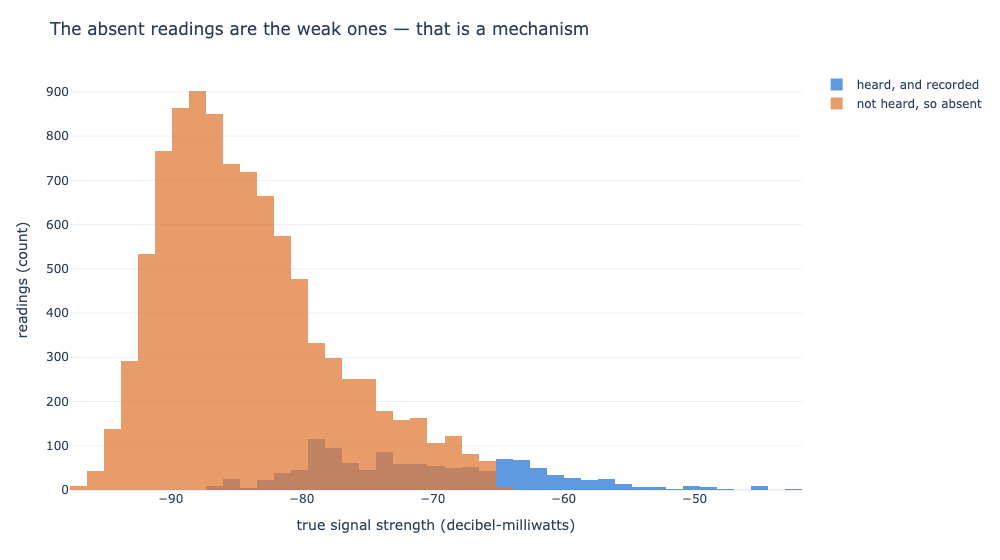

  true signal, heard readings: mean -70.6 dBm; absent readings: mean -84.2 dBm


In [57]:
figure_mechanism(truth)
heard = truth["rssi1"].notna()
print(f"  true signal, heard readings: mean {truth.loc[heard, 'rssi1_true'].mean():.1f} dBm; "
      f"absent readings: mean {truth.loc[~heard, 'rssi1_true'].mean():.1f} dBm")

### Imputation bias, the mask, and the masked moving average

*Slides: "Definition — imputation bias", "A fill must be recorded, because a filled value and a measured value look alike" and "Definition — the absence mask and the masked exponential moving average".*

**Goal.** Write the bias of a fill.

**Why.** The bias is the mean amount by which the invented values sit above the truth, over the rows the method actually filled; positive means too strong — the phone placed nearer the beacon than it was (Little & Rubin, 2019; van Buuren, 2018).

**What the code does.** Writes the definition in sympy, with F the set of filled rows.

**So what.** "Drop" fills nothing, so it scores zero by construction, not by merit.

In [58]:
j, size_F = sp.Symbol("j", integer=True), sp.Symbol("|F|", positive=True, integer=True)
t = sp.IndexedBase("t")
fill, truth_t = sp.Function(r"\mathrm{fill}"), sp.Function(r"\mathrm{truth}")
bias = sp.Sum(fill(t[j]) - truth_t(t[j]), (j, 1, size_F)) / size_F
row = sp.Symbol("t")
filled_rows = sp.ConditionSet(row, sp.And(sp.Eq(sp.Function("m")(row), 1),
                                          sp.Symbol(r"\text{the method filled } t")), sp.Naturals)
formula(sp.Eq(sp.Symbol(r"\mathrm{bias}"), bias, evaluate=False), sp.Symbol(r"\text{(dB)}"))
formula(sp.Eq(sp.Symbol("F"), filled_rows, evaluate=False),
        sp.Symbol(r"\text{its rows numbered } j = 1, \dots, |F| \text{ in the sum}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Write the mask and the masked moving average.

**Why.** The mask is the only record of which values are invented; the archive writes the same absence twice (an empty signal and a proximity of −1), so the mask must recognise both (van Buuren, 2018, § 1.3.7). The masked average smooths only the heard readings and carries its last value across a gap. The study behind the archive filled BLE gaps with an exponentially weighted moving average and told the classifier where it could not (Servizi et al., 2023, Appendix B), and the scalable detector kept imputation and masking (Servizi et al., 2026, Table 1). One difference must be said: Appendix B describes its average as taken over a time window "where points close to the center window have a higher weight" — a centred window, which looks at readings after the gap as well as before — while the slide, the lab and the solution use the causal recursion below, which looks only backwards. The lab files attribute that recursion to Servizi et al. (2023) in their docstrings, which are quoted verbatim here and not changed; the attribution is to the method's family (an exponentially weighted average with a mask), not to this exact form.

**What the code does.** Writes m_t as a sympy Piecewise and the recursion s_t with α = 0.3, and unrolls the recursion three steps to show the weights it gives to past readings.

**So what.** Three choices are printed beside the recursion — α = 0.3 stated not tuned, the plain recursion, one series per phone — and each is visible in the code below. The unrolled weights decay backwards in time only: a causal filter, usable at prediction time, unlike a centred window.

In [59]:
alpha = sp.Symbol(r"\alpha", positive=True)
s, step = sp.Function("s"), sp.Symbol("t", integer=True)
x_t = sp.IndexedBase("x")
rssi_null, prox_t = sp.Symbol(r"\mathrm{rssi}_t\ \text{is empty}"), sp.Symbol(r"\mathrm{prox}_t")
absence_mask = sp.Piecewise((1, sp.Or(rssi_null, sp.Eq(prox_t, -1))), (0, True))
recursion = sp.Eq(s(step), alpha * x_t[step] + (1 - alpha) * s(step - 1), evaluate=False)
formula(sp.Eq(sp.Symbol("m_t"), absence_mask, evaluate=False), recursion,
        sp.Symbol(r"\text{over the heard readings only}"), sp.Eq(alpha, sp.Rational(3, 10), evaluate=False))
unrolled = recursion.rhs
for back in (1, 2):
    unrolled = unrolled.subs(s(step - back), alpha * x_t[step - back] + (1 - alpha) * s(step - back - 1))
weighted = sum(alpha * (1 - alpha)**back * x_t[step - back] for back in range(3)) + (1 - alpha)**3 * s(step - 3)
formula(sp.Eq(s(step), weighted, evaluate=False))
print("the recursion unrolled three times equals the weighted sum:", sp.expand(unrolled - weighted) == 0)
print("weights on x_t, x_{t-1}, x_{t-2} at α = 0.3:",
      [sp.expand(unrolled).coeff(x_t[step - back]).subs(alpha, sp.Rational(3, 10)) for back in range(3)])

<IPython.core.display.Math object>

<IPython.core.display.Math object>

the recursion unrolled three times equals the weighted sum: True
weights on x_t, x_{t-1}, x_{t-2} at α = 0.3: [3/10, 21/100, 147/1000]


**Goal.** Define Lab 2's functions as the solution writes them.

**Why.** They are the three deliverables of Laboratory 2 and the functions the deck's imputation figures are computed with; the deck imports them rather than reimplementing them.

**What the code does.** Copies the constants, the two helpers `_missing` and `_ema_masked`, and `impute_with_mask`, `imputation_bias` and `fills_are_biased_which_way` from `solutions/lab_02.py`.

**So what.** The next cells check the recursion against the slide's formula and then draw the slides' figures with these functions.

In [60]:
# Source: Module 2/exercises/solutions/lab_02.py — LAB, BEACONS, PROXIMITY, SENTINEL, SMOOTHING, _missing, _ema_masked, impute_with_mask, imputation_bias, fills_are_biased_which_way, verbatim
# References: (Rubin, 1976; Little & Rubin, 2019; van Buuren, 2018; Servizi et al., 2023)

import sys
import pathlib
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots


LAB = 2


BEACONS = ["rssiA", "rssiB", "rssiC", "rssi1", "rssi2"]


PROXIMITY = {"rssiA": "proxA", "rssiB": "proxB", "rssiC": "proxC",
             "rssi1": "prox1", "rssi2": "prox2"}


SENTINEL = -1


SMOOTHING = 0.3   # alpha, the weight of the newest heard reading -- a stated choice


def _missing(frame, beacon: str) -> pd.Series:
    """Absent, however it was written down: m_t = 1 when rssi is null or prox is −1.

    The archive encodes the same absence twice: the signal strength is empty and
    the proximity column holds -1, on exactly the same rows, for every beacon.
    Recognise only the empty one and every mean you take over the proximity
    column averages in -1 as though a phone had been at proximity band minus
    one, which is not a place.
    """
    absent = frame[beacon].isna()
    proximity = PROXIMITY[beacon]
    if proximity in frame.columns:
        absent = absent | (frame[proximity] == SENTINEL)
    return absent


def _ema_masked(values: pd.Series, series_id) -> pd.Series:
    """s_t = α·x_t + (1−α)·s_{t−1} over the heard readings, carried across gaps.

    One series per phone, in the frame's row order (time order): a gap in one
    volunteer's trace is filled from that volunteer's last heard readings, not
    from whoever happened to report in the row above. `adjust=False` is the
    plain recursion the slide states; `ignore_na=True` skips the gaps rather
    than letting them dilute the weights, and at a gap the mean is simply the
    last state, which is what "carried forward" means (Servizi et al., 2023).
    """
    def recursion(x: pd.Series) -> pd.Series:
        return x.ewm(alpha=SMOOTHING, adjust=False, ignore_na=True).mean()

    if series_id is None:
        return recursion(values)
    return values.groupby(series_id, sort=False).transform(recursion)


def impute_with_mask(frame, method: str = "ema_masked"):
    """Fill the absent readings, and keep the record that you did.

    The mask is the part people leave out, and it is the part that matters. A
    filled value and a measured value look identical in a table; only the mask
    distinguishes them, and every model downstream needs to know which is which.
    Without it you cannot even tell afterwards how much of your data you made up.
    """
    filled_frame = frame.copy()
    series_id = frame["phone_id"] if "phone_id" in frame.columns else None

    for beacon in BEACONS:
        absent = _missing(frame, beacon)
        values = frame[beacon].where(~absent)

        if method == "drop":
            filled = values                       # leave the gaps as gaps
        elif method == "mean":
            filled = values.fillna(values.mean())  # x̄ over the heard readings
        elif method == "ema_masked":
            # It does not pretend the phone was near the beacon; it holds the
            # last thing it knew about that phone. Heard rows keep their value.
            filled = values.fillna(_ema_masked(values, series_id))
        else:
            raise ValueError(f"unknown method {method!r}")

        filled_frame[f"{beacon}_filled"] = filled
        filled_frame[f"{beacon}_missing"] = absent

    return filled_frame


def imputation_bias(filled, truth, missing) -> float:
    """Mean of (fill − truth) over the rows that were filled, in decibels.

    Positive means the fills sit above what was really there -- "too strong".
    The mean runs over the rows the mask marks absent *and* the method actually
    filled: "drop" fills nothing, so its bias is nought by construction, which
    is exactly what the figure shows for it. A method is judged only on what it
    invented.
    """
    filled = pd.Series(filled, dtype="float64").reset_index(drop=True)
    truth = pd.Series(truth, dtype="float64").reset_index(drop=True)
    missing = pd.Series(missing).astype(bool).reset_index(drop=True)
    touched = missing & filled.notna() & truth.notna()
    if not touched.any():
        return 0.0
    return float((filled[touched] - truth[touched]).mean())


def fills_are_biased_which_way() -> str:
    """Too strong — and the mechanism settles it before any code runs.

    Rubin's (1976) three cases, in one line each. Missing completely at random:
    the chance of a gap does not depend on any value, seen or unseen. Missing at
    random: it depends only on values you can see. Missing not at random: it
    depends on the very value that is missing. Signal strength falls with
    distance and a beacon is heard only when it is near, so a reading is absent
    *because* it was weak -- the third case, and the one where every fill made
    from what you can see is made from the near readings.

    Any fill built from what you have — a mean, a moving average, the last value
    carried forward — is therefore made of near evidence and used to stand in for
    a far measurement. It comes out too strong. Measured here, the flat mean
    invents readings well over ten decibels stronger than they really were; the
    masked moving average does nearly as much damage, just under ten.

    The more useful surprise is how close the two methods are. The masked moving
    average is barely better than the flat mean, because it too is carrying
    forward a near reading. No imputation recovers information that was never
    recorded; the choice of method changes the damage by a little, and the mask
    is what lets anyone downstream know the damage exists at all.

    That is why "drop" sits at zero on the figure. It invents nothing — and it
    throws away every row where the absence was itself the measurement.
    """
    return "too strong"

**Goal.** Check that the solution's masked average is the slide's recursion.

**Why.** The check grades the recursion on a planted two-phone gap; the same test can be written symbolically.

**What the code does.** Plants two phones: A hears −60, misses two readings, hears −70, misses one; B hears −80, misses one, hears −75. Absence is written both ways (empty signal, proximity −1). The slide's recursion, evaluated with sympy at α = 0.3, predicts each filled value; `impute_with_mask(…, "ema_masked")` must return them.

**So what.** A's last gap is filled with 0.3·(−70) + 0.7·(−60) = −63: the formula and the code agree to the last digit, and B's gap is filled from B alone.

In [61]:
planted = pd.DataFrame({"phone_id": ["A", "B", "A", "A", "B", "A", "B", "A"],
                        "value": [-60, -80, None, None, None, -70, -75, None]})
for b in BEACONS:
    planted[b] = planted["value"]
    planted[PROXIMITY[b]] = np.where(planted["value"].isna(), SENTINEL, 2)
filled = impute_with_mask(planted, "ema_masked")

a = sp.Rational(3, 10)
expected = []
state = {}
for phone, value in zip(planted["phone_id"], planted["value"]):
    if pd.notna(value):
        state[phone] = sp.Integer(int(value)) if phone not in state else a * int(value) + (1 - a) * state[phone]
        expected.append(float(value))                  # heard rows keep their own value
    else:
        expected.append(float(state[phone]))           # a gap takes the last state
planted["filled by the code"] = filled["rssi1_filled"]
planted["the slide's recursion"] = expected
planted["mask"] = filled["rssi1_missing"]
print(planted[["phone_id", "value", "mask", "filled by the code", "the slide's recursion"]].to_string())
assert np.allclose(planted["filled by the code"], planted["the slide's recursion"])
print("formula and code agree on every row")

  phone_id  value   mask  filled by the code  the slide's recursion
0        A  -60.0  False               -60.0                  -60.0
1        B  -80.0  False               -80.0                  -80.0
2        A    NaN   True               -60.0                  -60.0
3        A    NaN   True               -60.0                  -60.0
4        B    NaN   True               -80.0                  -80.0
5        A  -70.0  False               -70.0                  -70.0
6        B  -75.0  False               -75.0                  -75.0
7        A    NaN   True               -63.0                  -63.0
formula and code agree on every row


**Goal.** Register Lab 2 under the name the deck's figure code imports it by.

**Why.** `make_figs.py` computes the imputation figures with `from lab_02 import impute_with_mask, imputation_bias`.

**What the code does.** Puts a module named `lab_02` holding the functions above into `sys.modules`.

**So what.** The deck's code, run below, uses the functions on this page.

In [62]:
as_module("lab_02", impute_with_mask=impute_with_mask, imputation_bias=imputation_bias,
          fills_are_biased_which_way=fills_are_biased_which_way)

### What each fill invents

*Slides: "Every imputation places the absent readings nearer the beacon than they were" and "Definition — what a fill (imputation) does to the spread".*

**Goal.** Compute the three fills with the functions the lab is graded on, the deck's way.

**Why.** The slide's numbers — 13.6 decibels for the mean, 9 for the masked average — are computed by `make_figs.py`'s `imputation()`, which calls Lab 2's functions.

**What the code does.** Copies `imputation()` and `figure_imputation_by_distance()` verbatim.

**So what.** The next cell calls them.

In [63]:
# Source: Module 2/slides/make_figs.py — imputation, figure_imputation_by_distance, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def imputation(truth, student_view):
    """The three fills and their biases, from the functions the lab is graded on.

    Imported rather than reimplemented: a second copy of the recursion here is a
    second chance for the slide and the lab to disagree about what was measured.
    """
    from lab_02 import impute_with_mask, imputation_bias

    filled, biases = {}, {}
    for method in ("drop", "mean", "ema_masked"):
        result = impute_with_mask(student_view, method)
        filled[method] = result
        biases[method] = round(float(imputation_bias(
            result[f"{BEACON}_filled"], truth[f"{BEACON}_true"],
            result[f"{BEACON}_missing"])), 1)
    return filled, biases


def figure_imputation_by_distance(truth, student_view, filled, biases) -> None:
    """Where each fill puts the phone, against where it really was — generated.

    The instructor's figure: signal strength against the true distance to the
    beacon, the heard readings as points, the hidden truth of the absent ones
    beside them, and the fills drawn on top. The second panel is the bias of each
    fill in decibels, so that the picture and the number sit together.
    """
    one = truth["phone_id"] == truth["phone_id"].iloc[0]
    distance = truth.loc[one, f"{BEACON}_distance_true"]
    absent = student_view[BEACON].isna() | (student_view["prox1"] == -1)
    heard = ~absent[one]

    fig = make_subplots(cols=2, rows=1, column_widths=[0.68, 0.32],
                        subplot_titles=("one volunteer, beacon one, first day",
                                        "bias on the filled rows, whole day"))
    fig.add_scatter(x=distance[heard], y=truth.loc[one & heard, BEACON], mode="markers",
                    name="heard, and recorded", marker=dict(color=BLUE, size=6),
                    row=1, col=1)
    fig.add_scatter(x=distance[~heard], y=truth.loc[one & ~heard, f"{BEACON}_true"],
                    mode="markers", name="not heard: the hidden truth",
                    marker=dict(color=GREY, size=4, opacity=0.5), row=1, col=1)
    fig.add_scatter(x=distance[~heard],
                    y=filled["ema_masked"].loc[one & ~heard, f"{BEACON}_filled"],
                    mode="markers", name="masked moving average, carried forward",
                    marker=dict(color=ORANGE, size=6, symbol="diamond"), row=1, col=1)
    mean_of_heard = float(student_view[BEACON].where(~absent).mean())
    fig.add_scatter(x=[float(distance.min()), float(distance.max())],
                    y=[mean_of_heard, mean_of_heard], mode="lines",
                    name="mean of the heard readings", line=dict(color=RED, width=2),
                    row=1, col=1)
    fig.add_bar(x=["drop", "mean", "masked"],
                y=[biases["drop"], biases["mean"], biases["ema_masked"]],
                marker_color=[GREY, RED, ORANGE],
                text=[f"{biases[m]:+.1f}" for m in ("drop", "mean", "ema_masked")],
                textposition="outside", showlegend=False, row=1, col=2)
    fig.update_xaxes(title_text="true distance to the beacon (metres)", row=1, col=1)
    fig.update_yaxes(title_text="signal strength (decibel-milliwatts)", row=1, col=1)
    fig.update_xaxes(title_text="how the gaps were filled", row=1, col=2)
    fig.update_yaxes(title_text="fill − truth (decibels)", row=1, col=2)
    fig.update_layout(title="Every fill is made of near readings and stands in for far ones",
                      legend=dict(orientation="h", y=-0.22))
    write(fig, "imputation_by_distance", width=1100, height=620)

**Goal.** Draw the slide's figure: one volunteer against the true distance, and the bias.

**Why.** The left panel shows where each fill puts the phone against where it really was; the right panel is each method's bias over the whole day.

**What the code does.** Calls `imputation(truth, phones)` and `figure_imputation_by_distance(...)`.

**So what.** Mean-filling invents 13.6 decibels on 88.7 per cent of the rows; the masked average 9.0 — better, and still wrong, because it carries a near reading forward.

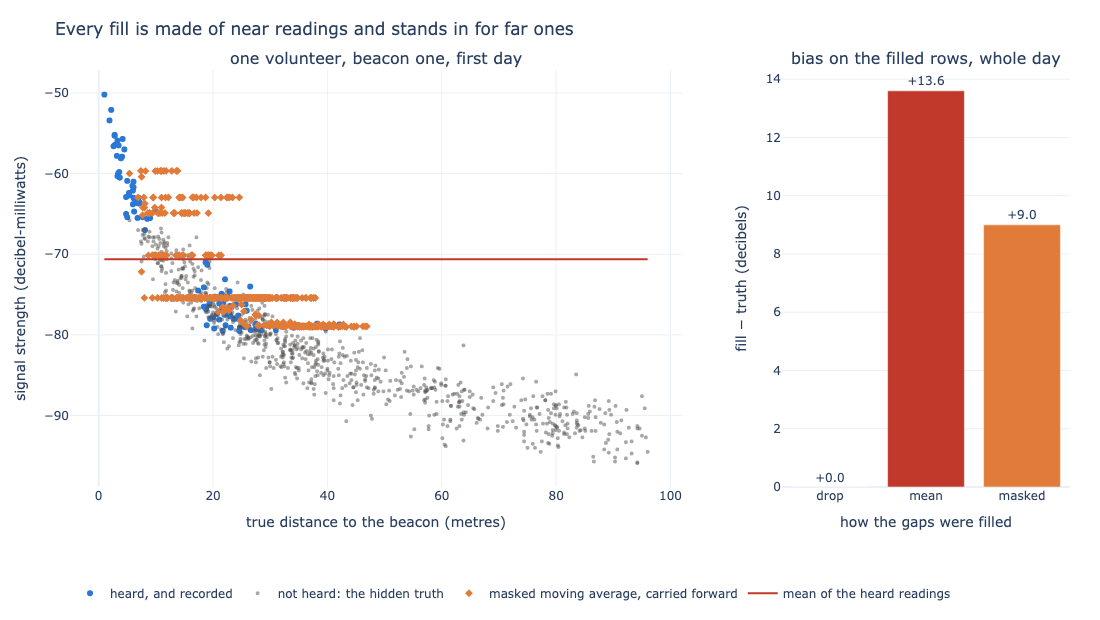

  mean fill, bias in decibels                                        deck 13.6      computed 13.6
  masked moving average, bias in decibels                            deck 9.0       computed 9.0
  drop, bias in decibels                                             deck 0.0       computed 0.0
  share of beacon 1's rows filled, per cent                          deck 88.7      computed 88.7
  the fills come out: too strong


In [64]:
filled_by_method, biases = imputation(truth, phones)
figure_imputation_by_distance(truth, phones, filled_by_method, biases)
agrees("mean fill, bias in decibels", biases["mean"], 13.6, 1)
agrees("masked moving average, bias in decibels", biases["ema_masked"], 9.0, 1)
agrees("drop, bias in decibels", biases["drop"], 0.0, 1)
agrees("share of beacon 1's rows filled, per cent",
       100 * filled_by_method["mean"]["rssi1_missing"].mean(), 88.7, 1)
print("  the fills come out:", fills_are_biased_which_way())

**Goal.** Derive what a single constant fill leaves of the spread.

**Why.** The slide states that filling a share f of the rows with one constant leaves √(1 − f) of the standard deviation, when the kept readings are a fair sample. Little and Rubin give the sample-variance version, a factor (n_obs − 1)/(n − 1) (Little & Rubin, 2019, § 4.2.1); multiple imputation restores the lost variation (Rubin, 1987).

**What the code does.** Writes the population variance of a column whose n·f filled rows sit at the kept mean m: the kept rows contribute n(1 − f)·v, the filled rows nothing. sympy simplifies the ratio of standard deviations, then evaluates it at f = 0.887.

**So what.** √(1 − f) = 0.34 at 88.7 per cent filled: the dotted line on the next figure.

In [65]:
f, n, v = sp.symbols("f n v", positive=True)
variance_filled = (n * (1 - f) * v + n * f * 0) / n          # the filled rows sit on the mean
ratio = sp.sqrt(sp.simplify(variance_filled / v))
sd = sp.Function(r"\mathrm{sd}")
formula(sp.Eq(sp.Symbol(r"\text{spread kept}"), sd(sp.Symbol(r"\text{filled}")) / sd(sp.Symbol(r"\text{truth}")),
              evaluate=False),
        sp.Eq(sp.Symbol(r"\text{constant fill}"), ratio, evaluate=False))
share_filled = float(filled_by_method["mean"]["rssi1_missing"].mean())
agrees("√(1 − f) at the filled share", float(ratio.subs(f, share_filled)), 0.34, 2)

<IPython.core.display.Math object>

  √(1 − f) at the filled share                                       deck 0.34      computed 0.34


**Goal.** Draw bias and spread side by side, with the deck's code.

**Why.** Bias is half the story: a fill can be unbiased and still flatten the column. The slide reports what each fill kept of the standard deviation.

**What the code does.** Copies `spreads_after_filling()` and `figure_spread()` from `make_figs.py` verbatim, and calls them.

**So what.** Mean-filling keeps 0.36 of the spread, the masked average 0.87; dropping *raises* it to 1.07, because the rows that survive are not a random sample. The gap between 0.36 and the 0.34 a fair sample would give is the mechanism, seen from the spread.

In [66]:
# Source: Module 2/slides/make_figs.py — spreads_after_filling, figure_spread, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def spreads_after_filling(truth, filled) -> dict:
    """What each fill did to the spread, as a ratio against the truth.

    The bias says how far the invented values sit from what was there. This says
    how much of the variation survived. Both are needed: a fill can be unbiased
    and still flatten the column it filled.
    """
    honest = float(truth[f"{BEACON}_true"].std(ddof=0))
    ratios = {}
    for method, frame in filled.items():
        ratios[method] = round(
            float(frame[f"{BEACON}_filled"].std(ddof=0)) / honest, 2)
    share = float(filled["mean"][f"{BEACON}_missing"].mean())
    return ratios, round(share * 100, 1), round((1 - share) ** 0.5, 2)


def figure_spread(ratios, biases, predicted) -> None:
    """Bias against spread, side by side — generated.

    The left panel is the module's existing measurement; the right is the one it
    never made. Drawing them together is the argument: the method with no bias
    at all has changed the population, and the method that looks least wrong on
    the left has kept a third of the variation.
    """
    names = ["drop (nothing filled)", "mean", "masked moving average"]
    keys = ["drop", "mean", "ema_masked"]
    fig = make_subplots(cols=2, rows=1,
                        subplot_titles=("what the fill invents",
                                        "what the fill leaves standing"))
    fig.add_bar(x=names, y=[biases[k] for k in keys], marker_color=[GREY, RED, ORANGE],
                text=[f"{biases[k]:+.1f}" for k in keys], textposition="outside",
                showlegend=False, row=1, col=1)
    fig.add_bar(x=names, y=[ratios[k] for k in keys], marker_color=[GREY, RED, ORANGE],
                text=[f"{ratios[k]:.2f}" for k in keys], textposition="outside",
                showlegend=False, row=1, col=2)
    fig.add_hline(y=0, line_color=GREY, line_width=1, row=1, col=1)
    fig.add_hline(y=1, line_color=BLUE, line_width=1, line_dash="dash", row=1, col=2)
    fig.add_hline(y=predicted, line_color=RED, line_width=1, line_dash="dot",
                  row=1, col=2)
    fig.update_yaxes(title_text="fill − truth (decibels)", row=1, col=1)
    fig.update_yaxes(title_text="spread kept, against the truth", range=[0, 1.35],
                     row=1, col=2)
    fig.update_layout(title="Bias is half the story: what each fill left of the spread")
    write(fig, "imputation_spread")

**Goal.** Draw the slide's bias-and-spread figure and check its numbers.

**Why.** The slide quotes 0.36, 0.87 and 1.07 of the spread kept, the 0.34 a fair sample would give, and 88.7 per cent filled.

**What the code does.** Calls spreads_after_filling() and figure_spread(), compares every number with the slide, and squares the ratios to show the variance kept.

**So what.** All five agree; the word "variance" on the slide is the one slip, recorded below.

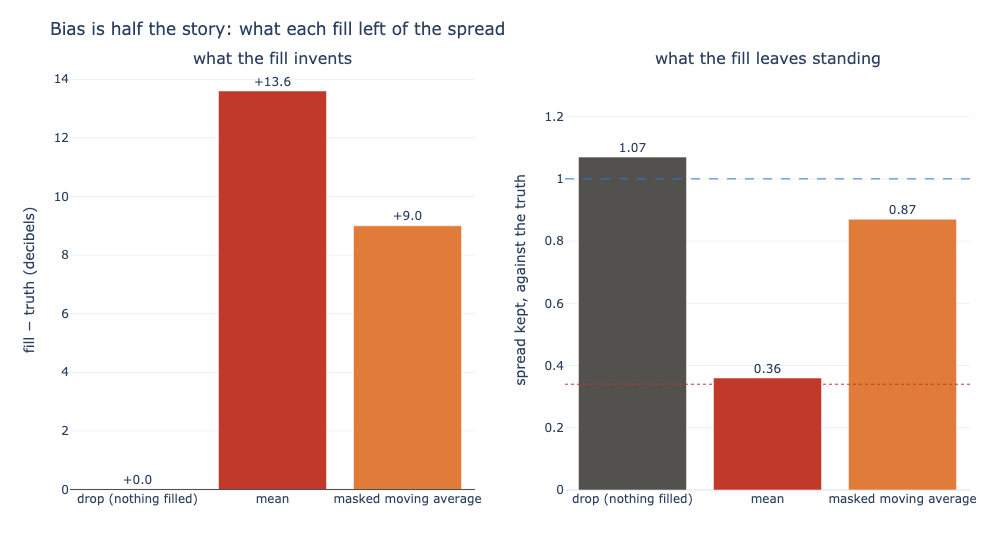

  spread kept, mean fill                                             deck 0.36      computed 0.36
  spread kept, masked moving average                                 deck 0.87      computed 0.87
  spread kept, drop                                                  deck 1.07      computed 1.07
  spread kept if the absence were completely at random               deck 0.34      computed 0.34
  filled share, per cent                                             deck 88.7      computed 88.7
  masked moving average: share of the variance kept: computed here 0.76; stated "preserves 87% of the original variance" — 0.87 is a ratio of standard deviations; the variance kept is its square. The same slide's "36% of the original variation" and the misconceptions poster's "destroys 64% of variation" are standard deviations too (variance kept: 0.13)


In [67]:
ratios, filled_share, predicted = spreads_after_filling(truth, filled_by_method)
figure_spread(ratios, biases, predicted)
agrees("spread kept, mean fill", ratios["mean"], 0.36, 2)
agrees("spread kept, masked moving average", ratios["ema_masked"], 0.87, 2)
agrees("spread kept, drop", ratios["drop"], 1.07, 2)
agrees("spread kept if the absence were completely at random", predicted, 0.34, 2)
agrees("filled share, per cent", filled_share, 88.7, 1)
beside("masked moving average: share of the variance kept", f"{ratios['ema_masked'] ** 2:.2f}",
       "\"preserves 87% of the original variance\"",
       "0.87 is a ratio of standard deviations; the variance kept is its square. The same "
       "slide's \"36% of the original variation\" and the misconceptions poster's \"destroys "
       "64% of variation\" are standard deviations too (variance kept: "
       f"{ratios['mean'] ** 2:.2f})")

### The readings that do arrive, and the displacement budget

*Slides: "The readings that do arrive carry an error that can be written down" and
the deck's appendix, "Appendix — The displacement budget, term by term".*

Absence is one fault; the readings that arrive are also wrong by an amount that can
be accounted for. Signal strength is disturbed by a body between phone and beacon,
by which pocket holds the phone, by the angles and by the mounting height. A
position is wrong by the satellite fix's error plus the distance moved since the
last fix.

**Goal.** Write the budget, and compare it with the quadrature sum the appendix mentions.

**Why.** The appendix states Δd = ΔGPS + ΔSpeed·ΔT: the fix's error plus how far the phone could have moved unobserved, added as magnitudes — a worst case. Independent errors combine in quadrature instead. The appendix says the budget is the author's own derivation, with no source beyond the arithmetic.

**What the code does.** Writes both totals in sympy and proves the linear sum is never smaller (the difference of squares is 2·ΔGPS·ΔSpeed·ΔT ≥ 0). Then evaluates the movement term with lab numbers: the shuttle's top speed on the slice times the phone's reporting interval.

**So what.** Between two phone readings the shuttle can move about 3.5 metres; the satellite error is not in the lab data and stays a symbol.

In [68]:
d_gps, d_speed, d_t = sp.symbols(r"\Delta_{GPS} \Delta_{Speed} \Delta_T", nonnegative=True)
worst = d_gps + d_speed * d_t
quadrature = sp.sqrt(d_gps**2 + (d_speed * d_t)**2)
formula(sp.Eq(sp.Symbol(r"\Delta d"), worst, evaluate=False),
        sp.Eq(sp.Symbol(r"\Delta d_{\perp}"), quadrature, evaluate=False))
print("worst² − quadrature² =", sp.expand(worst**2 - quadrature**2), "  (never negative)")
top_speed = float(bus["speed"].abs().max())
interval = float(archive("phone_interval_s"))
print(f"movement term with the slice's top speed {top_speed:.3f} m/s and the phone interval "
      f"{interval} s: {top_speed * interval:.2f} m")

<IPython.core.display.Math object>

worst² − quadrature² = 2*\Delta_T*\Delta_{GPS}*\Delta_{Speed}   (never negative)
movement term with the slice's top speed 3.555 m/s and the phone interval 0.993 s: 3.53 m


## Laboratory 2 — Missingness is a mechanism

*Slide: "Lab 2 — Missingness is a mechanism".* Three functions, twenty-five
minutes. The check holds the true values you cannot see: your mask must recognise
both encodings of absence, your bias must reproduce its arithmetic, and your
direction must follow from the mechanism.

**The exercise, exactly as `Module 2/exercises/labs/02_the_mechanism.py` states it.**

> Lab 2 — Missingness is a mechanism.
>
> Why this lab exists: more than half of the beacon readings in this archive are
> absent, and the absence is caused by the very thing the reading would have told
> you — distance. You prove here that you can name the mechanism, fill a gap
> without destroying the record that you filled it, and measure in decibels how
> much each fill invented.
> Where it sits: Block two — "The mask, and why it must survive", and the
> definition slides "Definition — the three missing-data mechanisms",
> "Definition — the absence mask and the masked exponential moving average" and
> "Definition — imputation bias".
> What the check grades: for all five beacons and all three methods the mask marks
> exactly the rows where the signal strength is empty or the proximity column holds
> −1; "drop" leaves those rows empty, "mean" fills them with the mean of the
> readings that were heard, and "ema_masked" reproduces the stated recursion on a
> planted two-phone gap; imputation_bias() equals the mean of fill − truth over the
> filled rows on three planted triples and on the day; and
> fills_are_biased_which_way() names the direction the bias runs, which the
> imputation_bias() above measures.
> Needs: pandas, numpy, plotly, and the loader in lab_support.
>
> Twenty-five minutes.
>
> A beacon reading is absent on most rows. Before you fill anything in, one
> question decides everything that follows: *why* is it absent?
>
>   If a packet was lost in transit, the absence tells you nothing, and filling
>   it with a plausible value costs little.
>
>   If the beacon was out of range, the absence tells you where the phone was.
>   Filling it with the average signal strength does not recover information --
>   it invents a phone standing next to a beacon it could not hear, and it does
>   so on the majority of your rows.
>
> The second is what happens here, and in the archive: signal strength falls with
> distance, so the readings that are missing are exactly the far ones. That is
> missing not at random, and it is the case where imputation lies.
>
> There is a second trap, and it is in the real file too. The same absence is
> encoded twice: `rssiA` is empty and `proxA` is -1, on exactly the same rows. A
> mean taken over `proxA` without recognising the sentinel averages in -1 as
> though it were a real proximity band.
>
> What you write: impute_with_mask(frame, method), imputation_bias(filled, truth,
> missing), and fills_are_biased_which_way().
>
> impute_with_mask returns a copy of `frame` with two new columns per beacon:
>
>     <beacon>_filled     the values after imputation
>     <beacon>_missing    True where the original was absent, before you filled it
>
> The mask is not decoration. It is the only record that the value is a guess,
> and every model downstream needs it. Lose it and nobody can tell a measurement
> from an invention.
>
> Three methods to support:
>
>     "drop"        do not fill; leave the absent values absent. The mask still
>                   has to be right.
>     "mean"        fill with the mean of the readings that are present.
>     "ema_masked"  the exponential moving average of the readings that were
>                   heard, carried forward across the gaps, with the mask kept
>                   (Servizi et al., 2023 -- the method this study used).
>
> Then measure what each one invented, against the true values the check holds,
> and say which way the fills are wrong before you look.

```python
def impute_with_mask(frame, method: str = "ema_masked"):
    """Fill the absent beacon readings, and keep a record that you did.
    
    Definition graded by the check:
        m_t = 1 when rssi_t is null or prox_t = −1, else 0
        (van Buuren, 2018). The same absence is written down twice in this
        archive and a mask that recognises one encoding and not the other is
        wrong on every row where they differ.
        s_t = α·x_t + (1−α)·s_{t−1} over the heard readings only, α = 0.3,
        carried forward across a gap
        (Servizi et al., 2023). α = SMOOTHING = 0.3, stated rather than tuned;
        s_t is the plain recursion, not the adjusted one; one series per phone,
        so a gap in one volunteer's trace is filled from that volunteer's own
        last heard readings and from nobody else's. Slide: "Definition — the
        absence mask and the masked exponential moving average".
    Needs: pandas
    
    Args:
        frame:  phone traces, with beacon columns absent and proximity columns
                carrying the sentinel on the same rows.
        method: "drop", "mean" or "ema_masked".
    
    Returns:
        A copy with <beacon>_filled and <beacon>_missing for each beacon."""
```

```python
def imputation_bias(filled, truth, missing) -> float:
    """How far the values you invented sit from what was really there, in decibels.
    
    Definition graded by the check:
        bias = (1/|F|) Σ_{t ∈ F} (fill_t − truth_t), F the rows the method
        filled, in decibels
        (Little & Rubin, 2019; van Buuren, 2018). Positive means the fills sit
        above the truth -- "too strong". F is the set of rows the mask marks
        absent *and* the method actually filled, so "drop" invents nothing and
        scores nought by construction. Slide: "Definition — imputation bias".
    Needs: pandas, float
    
    Args:
        filled:   the column after imputation.
        truth:    the values that were really there, which only the check has.
        missing:  the mask, True where the original reading was absent.
    
    Returns:
        The mean of (fill − truth) over the filled rows, in decibels; 0.0 when
        the method filled nothing."""
```

```python
def fills_are_biased_which_way() -> str:
    """Do the filled values come out too strong, or too weak?
    
    Definition graded by the check:
        MCAR: P(M | Y_obs, Y_mis) = P(M); MAR: P(M | Y_obs, Y_mis) = P(M |
        Y_obs); MNAR: neither
        (Rubin, 1976; Little & Rubin, 2019). M is the indicator that a reading is
        absent, Y_obs what you can see and Y_mis what you cannot. Signal strength
        falls with distance and a beacon is heard only when it is near, so the
        absence depends on the missing value itself: the third case. Slide:
        "Definition — the three missing-data mechanisms".
    Needs: nothing but the mechanism -- return "too strong" or "too weak"
    
    Reason from the mechanism rather than from habit: the missing readings are
    the far ones. What does filling them with the average of the near ones do to
    the distribution?"""
```

**The stub's slide titles, against the deck.** The stub places the lab under "The
mask, and why it must survive"; no slide has that title. The slide that makes the
point is "A fill must be recorded, because a filled value and a measured value look
alike". The three definition slides it names carry exactly those titles. The stub
attributes the masked moving average to Servizi et al. (2023); as noted where the
recursion is written above, that paper's Appendix B describes a centre-weighted
window average, and the lab's causal recursion is a member of the same family rather
than the paper's exact method.

### The solution

The five functions were defined above, where the deck introduces the mask and the recursion. First, the lab file's own demonstration.

**Goal.** Run the stub's own demonstration against the solved functions.

**Why.** It is what a student sees when the file is complete.

**What the code does.** The stub's `__main__` block, verbatim.

**So what.** For beacon 1: the masked rows and the bias of each method, and the direction.

In [69]:
# Source: Module 2/exercises/labs/02_the_mechanism.py — demonstration step 0, verbatim

say = narrator(LAB)
phones = load_phones()
truth = load_phones(with_truth=True)
rows = {}
for name in ("drop", "mean", "ema_masked"):
    filled = impute_with_mask(phones, name)
    rows[name] = {"masked rows": int(filled["rssi1_missing"].sum()),
                  "bias (decibels)": imputation_bias(
                      filled["rssi1_filled"], truth["rssi1_true"],
                      filled["rssi1_missing"])}
show_table(pd.DataFrame(rows).T.rename_axis("method"), "rssi1", logger=say)
say.info("the fills come out: %s", fills_are_biased_which_way())

 16.38s  lab 2  --- rssi1 (3 rows) ---
 16.38s  lab 2                  masked rows  bias (decibels)
 16.39s  lab 2      method                                  
 16.39s  lab 2      drop               9584                0
 16.39s  lab 2      mean               9584            13.58
 16.39s  lab 2      ema_masked         9584             9.04
 16.39s  lab 2  the fills come out: too strong


### The solution's demonstration, step by step

What `python3 solutions/lab_02.py` prints, one paragraph of its `__main__` block at a
time, each verbatim. It measures what each fill invented against the hidden truth and
draws the lab's version of the slide's figure.

**Goal.** Start the demonstration's narrator.

**Why.** One logger carries every line the solution prints, in the terminal and here.

**What the code does.** Creates `say` for Lab 2 and prints the lab's one-line summary.

**So what.** The seconds at the start of each line are the only output that differs between runs.

In [70]:
# Source: Module 2/exercises/solutions/lab_02.py — demonstration, paragraph 1 of 5, verbatim

say = narrator(LAB)
say.info("Lab 2 — three fills against a known mechanism, and what each one invents")

 16.39s  lab 2  Lab 2 — three fills against a known mechanism, and what each one invents


**Goal.** Load the student's view and the truth, and measure the absence.

**Why.** The bias of a fill can only be measured against values nobody recorded; the generator kept them in a second frame.

**What the code does.** Loads the first generated day twice — as the student sees it, and with its hidden columns — then builds the mask with `_missing` and prints its share, checking that the empty signal and the proximity of −1 mark the same rows.

**So what.** Beacon 1 is absent on 88.7 per cent of the rows, and the two encodings agree on every one.

In [71]:
# Source: Module 2/exercises/solutions/lab_02.py — demonstration, paragraph 2 of 5, verbatim

student_view = load_phones()
truth = load_phones(with_truth=True)
say.info("phones: %s rows, generated (seed 20200122); the truth frame keeps the "
         "signal every reading would have had and the distance to each beacon",
         f"{len(student_view):,}")
absent = _missing(student_view, "rssi1")
say.info("rssi1 absent on %.1f per cent of rows, both encodings agreeing on every "
         "row: %s", absent.mean() * 100,
         bool((student_view["rssi1"].isna() == (student_view["prox1"] == SENTINEL)).all()))

 16.41s  lab 2  phones: 10,800 rows, generated (seed 20200122); the truth frame keeps the signal every reading would have had and the distance to each beacon
 16.41s  lab 2  rssi1 absent on 88.7 per cent of rows, both encodings agreeing on every row: True


**Goal.** Fill three ways and score each against the truth.

**Why.** These are the lab's three deliverables in one loop: `impute_with_mask`, `imputation_bias`, and the direction `fills_are_biased_which_way` names.

**What the code does.** For drop, mean and the masked moving average: fills beacon 1, computes the mean of fill − truth over the filled rows, prints each, tabulates the three, and prints the named direction.

**So what.** +0.0, +13.6 and +9.0 decibels: dropping invents nothing by construction; both fills are too strong, because the readings you can see are the near ones.

In [72]:
# Source: Module 2/exercises/solutions/lab_02.py — demonstration, paragraph 3 of 5, verbatim

biases, filled_by_method = {}, {}
for method in ("drop", "mean", "ema_masked"):
    result = impute_with_mask(student_view, method)
    filled_by_method[method] = result
    biases[method] = imputation_bias(result["rssi1_filled"], truth["rssi1_true"],
                                     result["rssi1_missing"])
    say.info("%-10s masked %s rows; bias = mean(fill − truth) on the filled rows: "
             "%+.1f dB", method, f"{int(result['rssi1_missing'].sum()):,}", biases[method])
show_table(pd.DataFrame({"bias_db": biases}).rename_axis("method"),
           "imputation bias on rssi1, decibels above the hidden truth", logger=say)
say.info("the fills come out %s, because the readings you can see are the near ones",
         fills_are_biased_which_way())

 16.43s  lab 2  drop       masked 9,584 rows; bias = mean(fill − truth) on the filled rows: +0.0 dB
 16.43s  lab 2  mean       masked 9,584 rows; bias = mean(fill − truth) on the filled rows: +13.6 dB
 16.46s  lab 2  ema_masked masked 9,584 rows; bias = mean(fill − truth) on the filled rows: +9.0 dB
 16.47s  lab 2  --- imputation bias on rssi1, decibels above the hidden truth (3 rows) ---
 16.47s  lab 2                  bias_db
 16.47s  lab 2      method             
 16.47s  lab 2      drop              0
 16.47s  lab 2      mean          13.58
 16.47s  lab 2      ema_masked     9.04
 16.47s  lab 2  the fills come out too strong, because the readings you can see are the near ones


**Goal.** Draw one volunteer against the true distance, and the three biases.

**Why.** The table says how wrong; the picture says why — the fills are made of near readings and stand in for far ones.

**What the code does.** For the first phone: the heard readings, the hidden truth of the absent ones, the masked average carried forward, and the mean of the heard readings, all against the true distance to beacon 1; beside it, the three biases as bars.

**So what.** Every fill sits above the grey cloud of the truth it replaces, and the further the phone was, the further above.

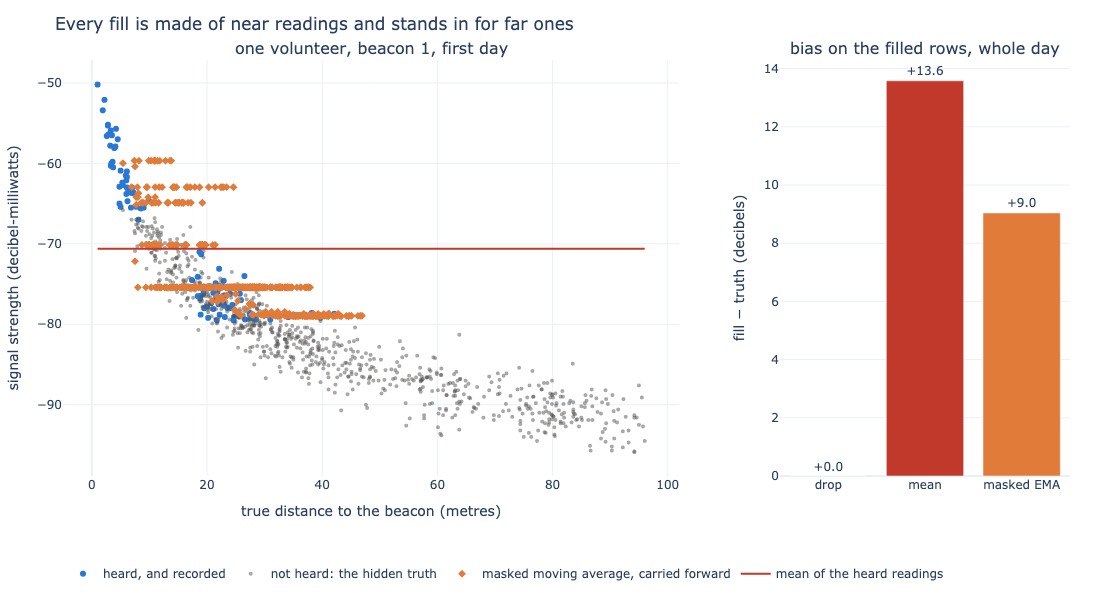

 16.84s  lab 2  figure -> shown here (lab_02_imputation_by_distance)


In [73]:
# Source: Module 2/exercises/solutions/lab_02.py — demonstration, paragraph 4 of 5, verbatim

# One volunteer, one beacon: where each fill puts the phone against where it was.
one = truth["phone_id"] == truth["phone_id"].iloc[0]
distance = truth.loc[one, "rssi1_distance_true"]
heard = ~absent[one]
fig = make_subplots(cols=2, rows=1, column_widths=[0.68, 0.32],
                    subplot_titles=("one volunteer, beacon 1, first day",
                                    "bias on the filled rows, whole day"))
fig.add_scatter(x=distance[heard], y=truth.loc[one & heard, "rssi1"], mode="markers",
                name="heard, and recorded", marker=dict(color="#2A78D6", size=6), row=1, col=1)
fig.add_scatter(x=distance[~heard], y=truth.loc[one & ~heard, "rssi1_true"], mode="markers",
                name="not heard: the hidden truth",
                marker=dict(color="#52514E", size=4, opacity=0.5), row=1, col=1)
fig.add_scatter(x=distance[~heard],
                y=filled_by_method["ema_masked"].loc[one & ~heard, "rssi1_filled"],
                mode="markers", name="masked moving average, carried forward",
                marker=dict(color="#E07B39", size=6, symbol="diamond"), row=1, col=1)
mean_of_heard = float(student_view["rssi1"].where(~absent).mean())
fig.add_scatter(x=[float(distance.min()), float(distance.max())],
                y=[mean_of_heard, mean_of_heard], mode="lines",
                name="mean of the heard readings", line=dict(color="#C0392B", width=2),
                row=1, col=1)
fig.add_bar(x=["drop", "mean", "masked EMA"],
            y=[biases["drop"], biases["mean"], biases["ema_masked"]],
            marker_color=["#52514E", "#C0392B", "#E07B39"],
            text=[f"{b:+.1f}" for b in (biases["drop"], biases["mean"], biases["ema_masked"])],
            textposition="outside", showlegend=False, row=1, col=2)
fig.update_xaxes(title_text="true distance to the beacon (metres)", row=1, col=1)
fig.update_yaxes(title_text="signal strength (decibel-milliwatts)", row=1, col=1)
fig.update_yaxes(title_text="fill − truth (decibels)", row=1, col=2)
fig.update_layout(title="Every fill is made of near readings and stands in for far ones",
                  legend=dict(orientation="h", y=-0.2))
save_figure(fig, "imputation_by_distance", LAB, logger=say, width=1100, height=600)

**Goal.** Print what the check grades.

**Why.** The demonstration ends by telling the student what `verify/check_02.py` will ask.

**What the code does.** One narrated line.

**So what.** The mask is graded on both encodings, the recursion on a planted gap, the bias on planted triples and on the day, and the direction against the truth.

In [74]:
# Source: Module 2/exercises/solutions/lab_02.py — demonstration, paragraph 5 of 5, verbatim

say.info("what the check grades: the mask marks exactly the rows where rssi is null or "
         "prox is −1; drop leaves gaps, mean fills with the mean of the heard readings, "
         "the masked average reproduces s_t = α·x_t + (1−α)·s_{t−1} with α = 0.3 on a "
         "planted gap; imputation_bias() equals the mean of fill − truth on the filled "
         "rows; and the direction is 'too strong'")

 16.85s  lab 2  what the check grades: the mask marks exactly the rows where rssi is null or prox is −1; drop leaves gaps, mean fills with the mean of the heard readings, the masked average reproduces s_t = α·x_t + (1−α)·s_{t−1} with α = 0.3 on a planted gap; imputation_bias() equals the mean of fill − truth on the filled rows; and the direction is 'too strong'


---
# Block 3 — Features, and the transform that is part of the model

**The question of this block:** which constants does a pipeline learn, and which
column already knows the answer?

*Slide: "A feature encodes a claim about the problem, and the model inherits it".*
Each feature encodes a belief — speed averaged over five seconds asserts that the
average matters more than the instant — so features are written down and reviewed,
not accumulated. The slide names one cheap feature: whether the vehicle beacon was
heard at all, a boolean made from an absence. Block 2 already measured it: heard on
8.8 per cent of aboard rows and 14.4 per cent of not-aboard rows, below the base
rate. It is cheap, and it carries almost nothing here.

### Encoding categories

*Slides: "Encoding categorical variables" and "Target encoding writes the target into a feature, and usually leaks".*

**Goal.** One-hot encode the phones' `label` column.

**Why.** A model needs numbers. Label encoding (1, 2, 3) invents an order; one-hot gives each category its own column and states none (McKinney, 2022, § 7.2).

**What the code does.** Takes two rows of each of the three labels the generated phones carry and encodes them with `pandas.get_dummies`, drawing the result as a table.

**So what.** Three categories become three columns of 0 and 1; exactly one is 1 in each row.

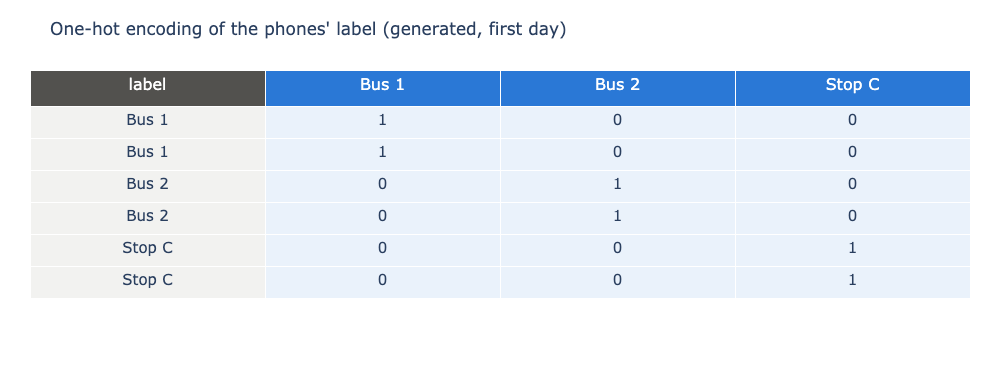

  one 1 per row: True


In [75]:
sample = pd.concat([phones[phones["label"] == value].head(2) for value in sorted(phones["label"].unique())])
encoded = pd.get_dummies(sample["label"]).astype(int)
columns = ["label"] + list(encoded.columns)
cells = [list(sample["label"])] + [list(encoded[c]) for c in encoded.columns]
fig = go.Figure(go.Table(
    header=dict(values=columns, fill_color=[GREY] + [BLUE] * len(encoded.columns),
                font=dict(color="white", size=16), height=36),
    cells=dict(values=cells, font=dict(size=15), height=32,
               fill_color=[["#F2F2F0"] * len(sample)] + [["#EAF2FB"] * len(sample)] * len(encoded.columns))))
fig.update_layout(title="One-hot encoding of the phones' label (generated, first day)",
                  margin=dict(l=30, r=30, t=70, b=20))
show(fig, "one_hot", height=380)
print("  one 1 per row:", bool((encoded.sum(axis=1) == 1).all()))

**Goal.** Measure the leak in target encoding computed over the whole table.

**Why.** Target encoding replaces a category with the average target for that category (Micci-Barreca, 2001). Computed over all rows, it tells every test row about its own label (Kaufman et al., 2012; Kapoor & Narayanan, 2023).

**What the code does.** Sorts the first generated day by time and splits it 70/30. Encodes `phone_id` by each phone's aboard share, once over all rows and once over the training rows only, and scores each encoding as a probability on the test rows (the Brier score, lower is better).

**So what.** The whole-table encoding scores better on the test rows because it has read them. Computed inside the training fold, the encoding is honest; the same holds for any scaler.

In [76]:
ordered = phones.sort_values("timestamp_utc").reset_index(drop=True)
cut = int(len(ordered) * 0.7)
is_aboard = (ordered["label2"] == "IN").astype(float)
everywhere = is_aboard.groupby(ordered["phone_id"]).mean()
training_only = is_aboard[:cut].groupby(ordered["phone_id"][:cut]).mean()
test_phone, test_truth = ordered["phone_id"][cut:], is_aboard[cut:]
brier = {name: float(((test_phone.map(encoding) - test_truth) ** 2).mean())
         for name, encoding in (("computed over all rows (leaks)", everywhere),
                                ("computed on the training rows only", training_only))}
for name, score in brier.items():
    print(f"  target encoding {name:<36} Brier score on the test rows {score:.4f}")

  target encoding computed over all rows (leaks)       Brier score on the test rows 0.2596
  target encoding computed on the training rows only   Brier score on the test rows 0.4240


### Scaling

*Slides: "Scaling and normalization" and "Scaling changes the result for some model families and not for others".*

**Goal.** Put three differently shaped columns of the slice through three scalers.

**Why.** Min-max maps onto [0, 1] and one extreme value moves the whole range; standard scaling subtracts the mean and divides by the standard deviation; robust scaling uses the median and the interquartile range and survives heavy tails. Distances and gradients care; trees do not.

**What the code does.** Takes speed while moving (skewed), payload (skewed) and inside temperature (bimodal) from the slice, applies no scaling, min-max, standard (ddof = 0) and robust scaling, and draws each column's density (a Gaussian kernel estimate on 3,000 readings drawn with the course seed). Unscaled, the three live on axes of metres per second, kilograms and degrees, so the top row gives each its own panel and its own unit; the bottom row overlays the three after each scaler, on one shared, unitless axis. Speed is taken while moving because over all readings its interquartile range is zero — more than half the readings are at rest — and robust scaling would divide by zero; the cell prints that too.

**So what.** Only the scaled panels are comparable across columns; which scaler is right depends on the shape, which is why the distribution is measured first — including whether the scaler is defined at all.

  speed over all readings: quartiles 0.000 and 0.000 m/s, so its IQR is 0.000


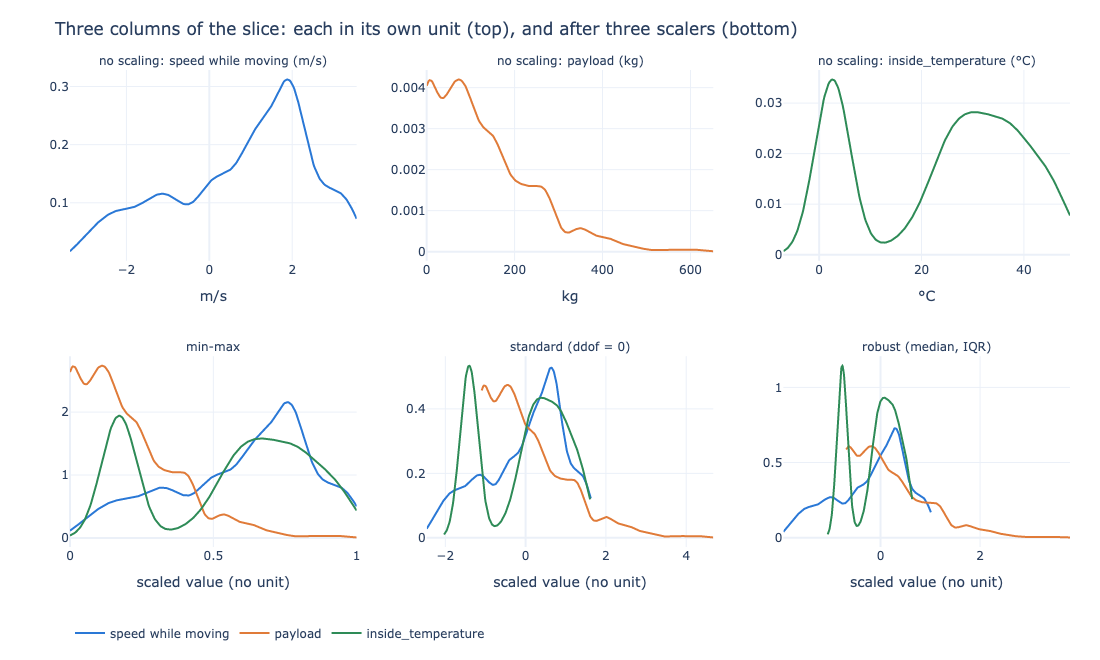

  speed while moving   range    -3.36 to     3.56 m/s
  payload              range     0.00 to   652.00 kg
  inside_temperature   range    -7.00 to    49.00 °C


In [77]:
all_speed = bus["speed"].astype(float)
print(f"  speed over all readings: quartiles {all_speed.quantile(0.25):.3f} and "
      f"{all_speed.quantile(0.75):.3f} m/s, so its IQR is {all_speed.quantile(0.75) - all_speed.quantile(0.25):.3f}")
frame = pd.DataFrame({"speed while moving": all_speed.where(all_speed != 0),
                      "payload": bus["payload"].astype(float),
                      "inside_temperature": bus["inside_temperature"].astype(float)})
columns = {"speed while moving": BLUE, "payload": ORANGE, "inside_temperature": GREEN}
units = {"speed while moving": "m/s", "payload": "kg", "inside_temperature": "°C"}
scalers = {
    "min-max": lambda x: (x - x.min()) / (x.max() - x.min()),
    "standard (ddof = 0)": lambda x: (x - x.mean()) / x.std(ddof=0),
    "robust (median, IQR)": lambda x: (x - x.median()) / (x.quantile(0.75) - x.quantile(0.25)),
}

def density(values):
    sample = np.random.default_rng(20200122).choice(values, size=min(3000, len(values)), replace=False)
    grid = np.linspace(values.min(), values.max(), 300)
    return grid, stats.gaussian_kde(sample)(grid)

fig = make_subplots(rows=2, cols=3, vertical_spacing=0.2, horizontal_spacing=0.07,
                    subplot_titles=[f"no scaling: {c} ({units[c]})" for c in columns] + list(scalers))
for col, (column, colour) in enumerate(columns.items(), start=1):
    grid, curve = density(frame[column].dropna().to_numpy())
    fig.add_scatter(x=grid, y=curve, mode="lines", line=dict(color=colour, width=2), name=column,
                    row=1, col=col)
    fig.update_xaxes(title_text=units[column], row=1, col=col)
for col, (label, scale) in enumerate(scalers.items(), start=1):
    for column, colour in columns.items():
        grid, curve = density(scale(frame[column].dropna()).to_numpy())
        fig.add_scatter(x=grid, y=curve, mode="lines", line=dict(color=colour, width=2),
                        showlegend=False, row=2, col=col)
    fig.update_xaxes(title_text="scaled value (no unit)", row=2, col=col)
fig.update_annotations(font_size=12)
fig.update_layout(title="Three columns of the slice: each in its own unit (top), and after three scalers (bottom)",
                  legend=dict(orientation="h", y=-0.15))
show(fig, "scaling", width=1100, height=660)
for column in columns:
    values = frame[column].dropna()
    print(f"  {column:<20} range {values.min():8.2f} to {values.max():8.2f} {units[column]}")

### Window features, and what the first two hide

*Slide: "Feature extraction in timeseries" (mean, standard deviation, minimum, maximum, slope, higher moments).*

**Goal.** Find windows of the slice with the same mean and standard deviation and different movement.

**Why.** The slide's animation is the "Datasaurus": point clouds with identical summary statistics and different shapes. The same happens in a speed series: two numbers cannot tell accelerating from braking.

**What the code does.** Cuts the slice's speed (time order) into windows of 60 readings (30 seconds, no gap inside), starting every 10 readings, and keeps those whose mean lies within 0.05 m/s of 2.1 m/s and whose standard deviation lies within 0.05 m/s of 0.9 m/s — a pair many windows of the slice share. Among them it picks four: the steepest rise first, then each time the window whose curve is furthest from every window already chosen (the nearest one's Euclidean distance, maximised), never two within two minutes of each other — so that no two drawn windows overlap or repeat one stretch of driving. Draws them and prints all six window features.

**So what.** Mean and spread agree to within 0.05 m/s, and the four curves are a pull-away from rest, a burst of speed that fades, a slowdown and recovery, and a burst that ends at a stop — whose fitted slope, −0.001, is as flat as a steady cruise. Two numbers cannot tell these apart, and the slope alone misses the last one; that is why the course's windows carry six features, not two.

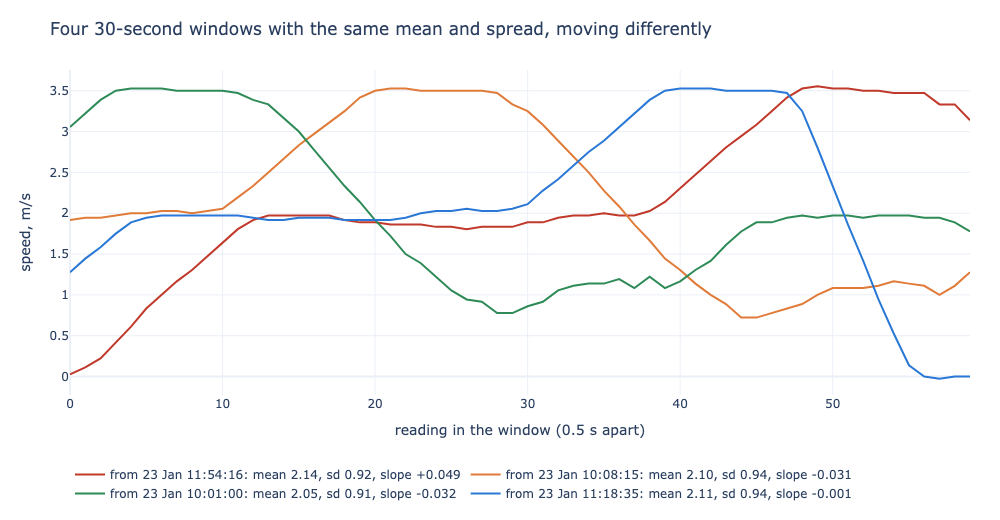

    start (UTC)  mean    sd    min   max  slope  skewness
23 Jan 11:54:16 2.144 0.916  0.027 3.555  0.049    -0.166
23 Jan 10:08:15 2.104 0.942  0.722 3.527 -0.031     0.165
23 Jan 10:01:00 2.053 0.911  0.777 3.527 -0.032     0.433
23 Jan 11:18:35 2.111 0.939 -0.027 3.527 -0.001    -0.429
  windows sharing that mean and spread: 38; smallest distance between two drawn curves: 10.3 m/s


In [78]:
speed_in_time = in_time["speed"].to_numpy(float)
width = 60
starts = np.arange(0, len(speed_in_time) - width, 10)
unbroken = np.array([(in_time["_t"].iloc[s + width - 1] - in_time["_t"].iloc[s]).total_seconds() < 31
                     for s in starts])
windows = np.array([speed_in_time[s:s + width] for s in starts])
means, sds = windows.mean(axis=1), windows.std(axis=1)
slopes = np.array([np.polyfit(np.arange(width), w, 1)[0] for w in windows])
close = np.where(unbroken & (np.abs(means - 2.1) < 0.05) & (np.abs(sds - 0.9) < 0.05))[0]
chosen = [close[np.argmax(slopes[close])]]                  # the steepest rise first
while len(chosen) < 4:                                      # then the most different curve each time
    apart = [k for k in close if all(abs(starts[k] - starts[c]) >= 240 for c in chosen)]
    chosen.append(max(apart, key=lambda k: min(np.linalg.norm(windows[k] - windows[c]) for c in chosen)))
fig = go.Figure()
for colour, k in zip((RED, ORANGE, GREEN, BLUE), chosen):
    fig.add_scatter(y=windows[k], mode="lines", line=dict(color=colour, width=2),
                    name=f"from {in_time['_t'].iloc[starts[k]]:%d %b %H:%M:%S}: mean {means[k]:.2f}, "
                         f"sd {sds[k]:.2f}, slope {slopes[k]:+.3f}")
fig.update_layout(title="Four 30-second windows with the same mean and spread, moving differently",
                  xaxis_title="reading in the window (0.5 s apart)", yaxis_title="speed, m/s",
                  legend=dict(orientation="h", y=-0.2))
show(fig, "same_summary_windows", height=520)
summary = pd.DataFrame([{"start (UTC)": f"{in_time['_t'].iloc[starts[k]]:%d %b %H:%M:%S}",
                         "mean": means[k], "sd": sds[k], "min": windows[k].min(),
                         "max": windows[k].max(), "slope": slopes[k],
                         "skewness": stats.skew(windows[k])} for k in chosen]).round(3)
print(summary.to_string(index=False))
print(f"  windows sharing that mean and spread: {len(close)}; smallest distance between two drawn "
      f"curves: {min(np.linalg.norm(windows[a] - windows[b]) for a in chosen for b in chosen if a < b):.1f} m/s")

### The transform is part of the model

*Slides: "Preprocessing constants are parameters and must be fitted on training rows only" and "Definition — the fitted transform, and applying it".*

**Goal.** Write the fitted transform and its application.

**Why.** A median that fills a gap and a mean and standard deviation that scale a column are learned constants; they are fitted on the training rows, stored, and applied unchanged to everything afterwards (Kuhn & Johnson, 2019, ch. 8). Recomputing them on the test rows is leakage (Huyen, 2022, ch. 4, "Data Leakage").

**What the code does.** Writes θ and apply(X, θ) in sympy, with σ the population standard deviation (ddof = 0) and 1 for a column that does not vary.

**So what.** Nothing in apply() is measured from the frame in hand.

In [79]:
x_ij, med, mu_j, sigma_j = sp.symbols(r"x_{ij} \mathrm{median}_j \mu_j \sigma_j")
n, i = sp.symbols("n i", positive=True, integer=True)
theta = sp.Symbol(r"\theta")
formula(sp.Eq(theta, sp.Function(r"\mathrm{fit}")(sp.Symbol(r"X_{train}")), evaluate=False),
        sp.Eq(theta, sp.Tuple(med, mu_j, sigma_j, sp.Symbol(r"\text{column order}")), evaluate=False))
formula(sp.Eq(sigma_j, sp.sqrt(sp.Sum((sp.Indexed("x", i) - mu_j)**2, (i, 1, n)) / n), evaluate=False),
        sp.Eq(sp.Symbol(r"\mathrm{apply}(X, \theta)_{ij}"),
              (sp.Function(r"\mathrm{fill}")(x_ij, med) - mu_j) / sigma_j, evaluate=False))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define Lab 3's functions as the solution writes them.

**Why.** They are the four deliverables of Laboratory 3 — the fit, the application, the leak detector and the verdict — with the purity statistic both of the last two share (Kuhn & Johnson, 2019, ch. 8; Kaufman et al., 2012; Kapoor & Narayanan, 2023).

**What the code does.** Copies the constants (the three verdict thresholds are in the solution, and on the definition slide, but deliberately not in the stub), the helpers and the four functions from `solutions/lab_03.py`.

**So what.** The next cells check the fit against the formula, then use the detector.

In [80]:
# Source: Module 2/exercises/solutions/lab_03.py — LAB, TARGET, AGREEMENT, MAX_LEAK_VALUES, DDOF, MEMORISED_GAP, MASK_MISSING_SHARE, PURITY_FLOOR, CALLS, _numeric_columns, fit_preprocessing, apply_preprocessing, column_purity, find_leaks, _said, keep_or_drop, verbatim
# References: (Kuhn & Johnson, 2019, ch. 8; Kaufman et al., 2012; Kapoor & Narayanan, 2023)

import sys
import pathlib
import numpy as np
import pandas as pd
import plotly.graph_objects as go


LAB = 3


TARGET = "label2"


AGREEMENT = 0.99      # the leak threshold: agreement or purity of at least 99 per cent


MAX_LEAK_VALUES = 10  # the purity test only means anything over at most this many values


DDOF = 0              # population standard deviation, stated once and used everywhere


# The three choices in the verdict. They are printed here, on the definition
# slide and in the check's own header, and nowhere else -- not in the stub,
# because a rule a student copies out of the file they are filling in has been
# transcribed rather than understood.
MEMORISED_GAP = 0.25       # in sample minus out of sample, above which it is memory


MASK_MISSING_SHARE = 0.20  # absent on this share of the rows or more: keep the mask too


PURITY_FLOOR = 0.60        # at or below this, and complete, it carries nothing


CALLS = ("keep", "keep with the mask", "drop")


def _numeric_columns(frame) -> list:
    return [c for c in frame.select_dtypes("number").columns]


def fit_preprocessing(train) -> dict:
    """Learn the constants from the training rows, and store them.

    The point that students consistently miss: a median used to fill a gap is
    not housekeeping, it is a **learned parameter**. It was estimated from data,
    it varies with the sample, and it has to travel with the model to be applied
    to anything the model is later asked about.

    Estimate it again on the test set and you have leaked -- not dramatically,
    but really. The test set is supposed to stand in for data the model has never
    seen; a median computed over it is a summary of that data used to prepare the
    model's input. The model is then a little better on the test set than it can
    ever be in service, and the gap is invisible because everything ran.

    The standard deviation is the population one, ddof = 0: sigma = sqrt(mean of
    (x − mu)²) over the training rows. It is a choice, and it is printed here so
    that the check, the slide and this file grade the same number. A column that
    does not vary gets sigma = 1, so that scaling it does not divide by nought.

    The median, mean and standard deviation are each taken over the training
    values actually present, before any fill -- pandas skips a NaN in a mean or
    a std by default, and that default is the estimate this function grades.
    Filling the gaps with a constant first and then taking the mean or the
    standard deviation of the filled column is a different, and wrong, order:
    the fill's own constant would leak into the very numbers meant to describe
    the column before it was touched.
    """
    numeric = _numeric_columns(train)
    return {
        "medians": {c: float(train[c].median()) for c in numeric},
        "means": {c: float(train[c].mean()) for c in numeric},
        "stds": {c: float(train[c].std(ddof=DDOF)) or 1.0 for c in numeric},
        "columns": list(numeric),
    }


def apply_preprocessing(frame, fitted: dict):
    """Apply the stored constants and nothing else.

    Note what this function never does: look at `frame` to decide anything. It
    fills with the stored median, scales by the stored mean and standard
    deviation, and returns the stored column order. Given the same `fitted` it
    produces the same output for training rows, test rows, and a single request
    arriving at a service in six months -- which is what Module 3 will need.
    """
    output = pd.DataFrame(index=frame.index)
    for column in fitted["columns"]:
        values = frame[column] if column in frame.columns else np.nan
        values = pd.Series(values, index=frame.index, dtype="float64")
        values = values.fillna(fitted["medians"][column])
        output[column] = (values - fitted["means"][column]) / fitted["stds"][column]
    return output[fitted["columns"]]


def column_purity(series, positive) -> float:
    """Σ_v max_y n(v, y) / n — one statistic, used by the detector and the verdict.

    The share of rows that a rule which answers with the commonest target value
    seen at each value of the column would get right. It is written once, here,
    because `find_leaks` measures it to raise a suspicion and `keep_or_drop` is
    handed it to settle one, and a course in which those were two slightly
    different numbers would be teaching the wrong lesson twice.

    Read it with its ceiling or not at all: a value that sees exactly one row is
    pure whatever the target does, so purity rises towards one with the number
    of distinct values for reasons that have nothing to do with the target.
    """
    known = series.notna()
    if known.sum() == 0:
        return float("nan")
    table = pd.crosstab(series[known], positive[known])
    if table.empty:
        return float("nan")
    return float(table.max(axis=1).sum() / table.to_numpy().sum())


def find_leaks(frame, target: str = TARGET) -> list:
    """Columns that agree with the target almost perfectly, by value or by presence.

    `bus_id` is the one to find, and it is worth saying exactly why it is so
    dangerous: it is not correlated with the target, it *is* the target. It is
    filled in when and only when the passenger is aboard. In the archive that is
    7,723 rows aboard all carrying it and 6,000 rows not aboard all lacking it,
    with no exceptions in either direction.

    A model given this column achieves near-perfect accuracy, ships, and then
    meets live data where the field is populated by the same process that
    produces the label -- which is to say, not until after the answer is already
    known. The score was never real.

    `label` is filled in by that same process and belongs to the same family:
    the archive's hand-recorded annotation, at finer grain than the target but
    filled in exactly when the target is, whereas `aboard_truth` never reaches
    this frame at all -- it is stripped before students ever see it.

    Presence is checked as well as value, because that is the form the leak
    actually takes here. A column can be almost entirely empty and still give
    the game away by *where* it is empty. Both tests use the same 99 per cent
    rule: presence agreeing (or disagreeing) with the target on at least 99 per
    cent of labelled rows, or a value purity -- the sum over values of the larger
    class count, divided by the rows -- of at least 99 per cent.

    The ceiling on the distinct values is part of the definition rather than an
    implementation detail, and it is the part students leave out. Purity is one
    by construction for any column whose values are all distinct: each value
    then sees exactly one row, so the larger class count for that value is one,
    the sum is the number of rows, and the ratio is one whatever the target
    does. Leave the ceiling out and the detector reports every row identifier,
    every timestamp and every free-text field in the file as a perfect leak --
    and a detector that reports everything is one nobody reads. MAX_LEAK_VALUES
    is that ceiling, and it is a choice, printed here, on the slide and in the
    check.
    """
    labels = frame[target]
    known = labels.notna()
    if known.sum() == 0:
        return []
    positive = (labels[known] == "IN")

    leaks = []
    for column in frame.columns:
        if column in (target, "aboard_truth"):
            continue
        series = frame.loc[known, column]

        # Leak by presence: is the column filled in exactly when the target is?
        present = series.notna()
        if present.nunique() > 1:
            agreement = max((present == positive).mean(), (present != positive).mean())
            if agreement >= AGREEMENT:
                leaks.append(column)
                continue

        # Leak by value: does a single value split the target almost perfectly?
        # The cardinality ceiling is the guard described above: without it a
        # column of distinct values is pure by construction and always "leaks".
        if series.nunique(dropna=True) <= MAX_LEAK_VALUES and series.notna().any():
            if column_purity(series, positive) >= AGREEMENT:
                leaks.append(column)

    return sorted(set(leaks))


def _said(value) -> str:
    """One evidence value, written so that the check can find it again.

    Four significant figures, because the check matches every number in the
    reason against the evidence to within half a per cent: round harder and a
    true sentence is rejected for a rounding error.
    """
    if isinstance(value, bool):
        return "yes" if value else "no"
    if isinstance(value, int):
        return f"{value}"
    return f"{float(value):.4g}"


def keep_or_drop(evidence: dict) -> tuple:
    """The call on one candidate feature, and the reason for it.

    Three calls, five questions, and the first question that answers decides.
    The order is the whole of the method, and it is the part students get wrong:
    they start with "is it any good?", which is the fourth question at best.

    1. **Is it knowable at the moment of prediction?** If not, drop it, however
       good it looks -- and it will look wonderful, because a column filled in
       by the same process that produces the target agrees with the target
       perfectly. `bus_id` here is pure and has no in-sample gap at all: the
       model trained on it is not overfitting, it is reading the answer. There
       is no threshold to argue about in this question, and that is why it is
       first.

    2. **Does it leak by value?** Purity of AGREEMENT or more, over at most
       MAX_LEAK_VALUES distinct values -- the same rule, with the same two
       constants, that find_leaks uses, so the detector and the verdict cannot
       disagree about what a column's purity means. `stationary` is caught here
       and nowhere else: it is knowable, it is complete and it generalises, and
       it is still the target inverted.

       **The ceiling is half the rule, and this is where it earns its place.**
       Purity is one by construction for a column whose values are all distinct,
       and all but one for a column that is nearly all distinct, because a value
       that sees one row is pure whatever the target does. So a high purity over
       a wide column is arithmetic, not evidence, and this question must not
       fire on it. `phone_speed` -- Lab 4's own window mean, 1,415 distinct
       values over 1,500 training windows, purity 0.9933 -- is the strongest
       honest feature in the hand-off table, and a rule without the ceiling
       throws it away.

    3. **Does the fit survive the split?** A feature that scores MEMORISED_GAP
       or more better on the rows it was fitted on than on the rows it was not
       has been memorised rather than learned. This is what condemns a row
       counter, and it has to be, because question two cannot: one value per
       row, a perfect in-sample fit, and nothing out of sample.

    4. **Is it absent often enough that the fill invents?** At or above
       MASK_MISSING_SHARE of the rows, keep it *with its mask*. Lab 2 measured
       what the fill invents -- nine decibels for the masked moving average,
       nearly fourteen for the mean -- and the mask is the only honest record of
       which rows carry an invention. Dropping the mask and keeping the value is
       the common error, and it is the one that cannot be detected downstream.

    5. **Does it beat the base rate?** A purity of PURITY_FLOOR or less on a
       column that is complete carries nothing, and a column carrying nothing
       costs time, columns and trust. Note the "and complete": a mostly absent
       column whose *values* say nothing may still be worth keeping, because its
       *absence* says something. That is the whole of Lab 2 in one clause, and
       it is why question four comes before question five.

    Otherwise keep it as it is.

    The reason is not decoration. A call is one of three strings, so on its own
    it is very nearly a coin flip; the reason is what makes it an argument, and
    the check refuses any number in it that is not one of the numbers handed
    over. Quote what you measured, name what you compared it against.
    """
    missing = float(evidence["missing_share"])
    bias = float(evidence["imputation_bias_db"])
    purity = float(evidence["purity"])
    values = int(evidence["cardinality"])
    knowable = bool(evidence["knowable_at_decision_time"])
    gap = float(evidence["in_sample_minus_out_of_sample"])

    if not knowable:
        return "drop", (
            f"knowable at decision time is no, so the call is settled before anything "
            f"else is weighed: a purity of {_said(purity)} and an in sample minus out "
            f"of sample gap of {_said(gap)} describe a column that will not exist when "
            f"the model has to answer.")

    if purity >= AGREEMENT and values <= MAX_LEAK_VALUES:
        return "drop", (
            f"purity is {_said(purity)} over {_said(values)} distinct values, so this "
            f"is not the arithmetic that makes a wide column look pure — a rule with "
            f"that few branches reads the target off this column almost exactly, and "
            f"an in sample minus out of sample gap of {_said(gap)} says it will keep "
            f"doing so right up to the day the column is not there.")

    if gap >= MEMORISED_GAP:
        return "drop", (
            f"in sample minus out of sample is {_said(gap)}, and with {_said(values)} "
            f"distinct values the model has somewhere to put every single row; a purity "
            f"of {_said(purity)} on a column that wide is arithmetic rather than "
            f"evidence, and it does not survive the split.")

    if missing >= MASK_MISSING_SHARE:
        return "keep with the mask", (
            f"missing share is {_said(missing)}, so most of this column would be "
            f"invented by the fill, and the imputation bias, in db, is {_said(bias)} "
            f"decibels of signal that was never recorded; the value is worth keeping at "
            f"a purity of {_said(purity)} only if the mask that says which rows were "
            f"invented travels beside it.")

    if purity <= PURITY_FLOOR:
        return "drop", (
            f"purity is {_said(purity)}, no better than answering with the majority, "
            f"and missing share is {_said(missing)}, so there is no absence for a mask "
            f"to carry either; the column costs a column and buys nothing.")

    return "keep", (
        f"purity is {_said(purity)} but it is spread over {_said(values)} distinct "
        f"values, which is why that number is arithmetic and not a confession; missing "
        f"share is {_said(missing)}, so nothing is invented, and in sample minus out of "
        f"sample is {_said(gap)}, so what it buys survives the split.")

**Goal.** Check that the code applies the slide's formula with the stored constants and nothing else.

**Why.** The check moves the test set by 1,000 and requires the output to move with it; the formula says exactly how far.

**What the code does.** Fits on the first 70 per cent of the generated day (time order), applies to the rest, and compares every value with (fill(x, median) − μ)/σ computed from the stored numbers. Then moves the test rows by 1,000 and checks that the scaled speed moves by exactly 1,000/σ.

**So what.** The code is the formula; the moved test set proves no constant was recomputed.

In [81]:
train_rows, test_rows = ordered.iloc[:cut], ordered.iloc[cut:]
fitted = fit_preprocessing(train_rows)
applied = apply_preprocessing(test_rows, fitted)
by_formula = pd.DataFrame({c: (test_rows[c].astype(float).fillna(fitted["medians"][c]) - fitted["means"][c])
                              / fitted["stds"][c] for c in fitted["columns"]})
print("largest difference between code and formula:", float((applied - by_formula).abs().max().max()))
moved = test_rows.copy()
moved[fitted["columns"]] = moved[fitted["columns"]] + 1000
shift = float((apply_preprocessing(moved, fitted)["speed"] - applied["speed"]).mean())
print(f"scaled speed moved by {shift:.3f}; 1000 / σ(speed) = {1000 / fitted['stds']['speed']:.3f}")
print("training rows' speed σ with ddof = 0:", round(fitted["stds"]["speed"], 4),
      "  pandas' default ddof = 1 would give:", round(float(train_rows["speed"].std()), 4))

largest difference between code and formula: 0.0
scaled speed moved by 1034.543; 1000 / σ(speed) = 1034.543
training rows' speed σ with ddof = 0: 0.9666   pandas' default ddof = 1 would give: 0.9667


### Target leakage, and the column that is the target

*Slides: "Definition — target leakage, and the rule that catches it here", "Leakage is detected by scoring each feature and by asking when it becomes known" and "BusID is not correlated with the target, it is the target under another name".*

**Goal.** Write the leak rule, and prove why it needs its ceiling.

**Why.** A column leaks when it agrees with the target almost perfectly by presence, or by value over few distinct values. Purity is one by construction for a column whose values are all distinct, so without the ceiling every identifier leaks (Kaufman et al., 2012; Kapoor & Narayanan, 2023).

**What the code does.** Writes the rule, agreement and purity in sympy, with the threshold and the ceiling taken from the solution's own constants (`AGREEMENT`, `MAX_LEAK_VALUES`); then computes `column_purity` for a row counter (every value distinct) against a random target, and for the same target against a coin with two values, and evaluates the rule on both.

**So what.** The row counter scores 1.0 against a target it knows nothing about; the ceiling of ten distinct values is what stops the rule from reporting it.

In [82]:
agreement_c, purity_c, values_c = sp.symbols(r"\mathrm{agreement}(c) \mathrm{purity}(c) |\mathrm{values}(c)|",
                                             nonnegative=True)
rule = sp.Or(sp.Ge(agreement_c, AGREEMENT),
             sp.And(sp.Ge(purity_c, AGREEMENT), sp.Le(values_c, MAX_LEAK_VALUES)))
same = sp.Symbol(r"\overline{1[c\ \mathrm{present}] = 1[Y{=}\mathrm{IN}]}")
differ = sp.Symbol(r"\overline{1[c\ \mathrm{present}] \ne 1[Y{=}\mathrm{IN}]}")
v, n_rows, V = sp.Symbol("v", integer=True), sp.Symbol("n", positive=True), sp.Symbol("V", integer=True)
formula(sp.Equivalent(sp.Symbol(r"c\ \text{leaks}"), rule, evaluate=False))
formula(sp.Eq(agreement_c, sp.Max(same, differ), evaluate=False),
        sp.Eq(purity_c, sp.Sum(sp.Function(r"\max_{y}\, n")(v), (v, 1, V)) / n_rows, evaluate=False))
rng = np.random.default_rng(20200122)
random_target = pd.Series(rng.random(1000) < 0.5)
counter_purity = column_purity(pd.Series(np.arange(1000)), random_target)
coin_purity = column_purity(pd.Series(rng.integers(0, 2, 1000)), random_target)
print("purity of a row counter against a random target:", counter_purity,
      "— the rule says it leaks:", rule.subs({agreement_c: 0, purity_c: counter_purity, values_c: 1000}))
print("purity of a random coin against the same target:", round(coin_purity, 3),
      "— the rule says it leaks:", rule.subs({agreement_c: 0, purity_c: coin_purity, values_c: 2}))
agrees("the leak threshold", AGREEMENT, 0.99, 2)
agrees("the ceiling on distinct values", MAX_LEAK_VALUES, 10, 0)

<IPython.core.display.Math object>

<IPython.core.display.Math object>

purity of a row counter against a random target: 1.0 — the rule says it leaks: False
purity of a random coin against the same target: 0.522 — the rule says it leaks: False
  the leak threshold                                                 deck 0.99      computed 0.99
  the ceiling on distinct values                                     deck 10        computed 10


**Goal.** Cross-tabulate `bus_id` against the target, with the deck's figure function.

**Why.** In the archive `BusID` is filled exactly when the passenger is aboard: 7,723 rows aboard all carry it and 6,000 not aboard all lack it. The generator reproduces the leak as `bus_id`.

**What the code does.** Copies `figure_leak()` from `make_figs.py` verbatim and feeds it the generated day's four counts; runs `find_leaks` on the day; prints the archive's counts beside.

**So what.** Two zeros off the diagonal in both worlds. `find_leaks` names `bus_id`, `label` (the hand-written label the target was derived from) and `stationary` (the target inverted), and neither the timestamps nor the phone speed.

In [83]:
# Source: Module 2/slides/make_figs.py — figure_leak, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def figure_leak(facts) -> None:
    """The cross-tabulation, from the archive. Four counts, so a table not a chart."""
    table = facts["busid_against_label"]["value"]
    cells = np.array([[table["present_and_aboard"], table["present_and_not_aboard"]],
                      [table["absent_and_aboard"], table["absent_and_not_aboard"]]])
    fig = go.Figure(go.Heatmap(
        z=cells, x=["aboard", "not aboard"], y=["BusID present", "BusID absent"],
        text=[[f"{v:,}" for v in row] for row in cells], texttemplate="%{text}",
        textfont=dict(size=24), colorscale=[[0, "#FCFCFB"], [1, BLUE]], showscale=False))
    fig.update_yaxes(autorange="reversed", title_text="")
    fig.update_xaxes(title_text="hand-recorded label (rows)")
    fig.update_layout(title="BusID is not a clue about the target. It is the target.")
    write(fig, "leak")

**Goal.** Draw the cross-tabulation for the generated day and ask the detector.

**Why.** The slide's counts are the archive's; the generated day reproduces the leak, with its own counts.

**What the code does.** Counts the four cells, calls figure_leak() with them, runs find_leaks() on the day, and prints the archive's counts and absent share beside.

**So what.** Two zeros off the diagonal in both worlds.

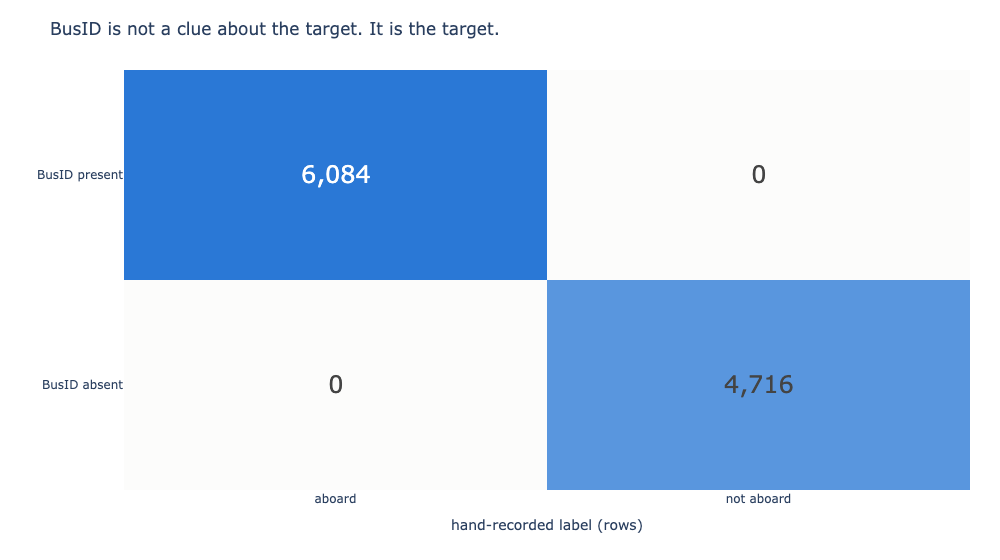

  find_leaks on the generated day: ['bus_id', 'label', 'stationary']
  bus_id against the target: computed here {'present_and_aboard': 6084, 'present_and_not_aboard': 0, 'absent_and_aboard': 0, 'absent_and_not_aboard': 4716}; stated {'present_and_aboard': 7723, 'present_and_not_aboard': 0, 'absent_and_aboard': 0, 'absent_and_not_aboard': 6000} (archive) — the generated day has 10,800 rows; the archive's labelled day 13,723
  bus_id absent, per cent: computed here 43.67; stated 84.74 (archive) — the archive's share is over both days, and its second day is unlabelled and carries no BusID; the generated first day is 56.3 per cent aboard


In [84]:
present, inside = phones["bus_id"].notna(), phones["label2"] == "IN"
generated_table = {"present_and_aboard": int((present & inside).sum()),
                   "present_and_not_aboard": int((present & ~inside).sum()),
                   "absent_and_aboard": int((~present & inside).sum()),
                   "absent_and_not_aboard": int((~present & ~inside).sum())}
figure_leak({"busid_against_label": {"value": generated_table}})
print("  find_leaks on the generated day:", find_leaks(phones, TARGET))
beside("bus_id against the target", generated_table, f"{archive('busid_against_label')} (archive)",
       "the generated day has 10,800 rows; the archive's labelled day 13,723")
beside("bus_id absent, per cent", round(100 * float(phones["bus_id"].isna().mean()), 2),
       f"{archive('busid_absent_share')} (archive)",
       "the archive's share is over both days, and its second day is unlabelled and carries "
       "no BusID; the generated first day is 56.3 per cent aboard")

**Goal.** Check that the verdict's five thresholds are the definition slide's.

**Why.** Finding a suspect is not deciding what to do with it. The verdict asks, in order: knowable at prediction time? pure to 99 per cent over ten values or fewer? a quarter better in sample than out? absent on a fifth of the rows? purity 60 per cent or less with nothing to mask? — and the first question that answers decides.

**What the code does.** Writes the verdict as a sympy Piecewise over the evidence E, in the order the solution asks its questions and with the solution's constants; evaluates it on forty-eight planted evidences (every combination of the quantities on either side of their thresholds) and compares each call with `keep_or_drop`'s; then compares the constants with the slide's words.

**So what.** The slide, the solution and the check grade one rule, and the formula on the page is that rule, case for case.

In [85]:
knowable, purity_e, values_e, gap_e, missing_e = sp.symbols(
    r"\mathrm{knowable} \mathrm{purity} |\mathrm{values}| \mathrm{gap} \mathrm{missing}")
drop, keep = sp.Symbol(r"\text{drop}"), sp.Symbol(r"\text{keep}")
keep_masked = sp.Symbol(r"\text{keep with the mask}")
verdict_rule = sp.Piecewise(
    (drop, sp.Not(knowable)),
    (drop, sp.And(sp.Ge(purity_e, AGREEMENT), sp.Le(values_e, MAX_LEAK_VALUES))),
    (drop, sp.Ge(gap_e, MEMORISED_GAP)),
    (keep_masked, sp.Ge(missing_e, MASK_MISSING_SHARE)),
    (drop, sp.Le(purity_e, PURITY_FLOOR)),
    (keep, True), evaluate=False)
formula(sp.Eq(sp.Function(r"\mathrm{verdict}")(sp.Symbol("E")), verdict_rule, evaluate=False))
names = {drop: "drop", keep: "keep", keep_masked: "keep with the mask"}
import itertools
disagreements, cases = 0, 0
for k_, p_, n_, g_, m_ in itertools.product((True, False), (0.995, 0.7, 0.5), (2, 1000),
                                            (0.3, 0.0), (0.5, 0.0)):
    evidence = {"missing_share": m_, "imputation_bias_db": 0.0, "purity": p_, "cardinality": n_,
                "knowable_at_decision_time": k_, "in_sample_minus_out_of_sample": g_}
    by_formula = names[verdict_rule.subs({knowable: k_, purity_e: p_, values_e: n_, gap_e: g_, missing_e: m_})]
    cases += 1
    disagreements += by_formula != keep_or_drop(evidence)[0]
print(f"planted evidences: {cases}; calls where the formula and keep_or_drop differ: {disagreements}")
for what, value, stated, places in (("purity threshold", AGREEMENT, 0.99, 2),
                                    ("ceiling on distinct values", MAX_LEAK_VALUES, 10, 0),
                                    ("in-sample advantage that condemns (a quarter)", MEMORISED_GAP, 0.25, 2),
                                    ("absent share that keeps the mask (a fifth)", MASK_MISSING_SHARE, 0.20, 2),
                                    ("purity floor (sixty per cent)", PURITY_FLOOR, 0.60, 2)):
    agrees(what, value, stated, places)
print("calls:", CALLS)

<IPython.core.display.Math object>

planted evidences: 48; calls where the formula and keep_or_drop differ: 0
  purity threshold                                                   deck 0.99      computed 0.99
  ceiling on distinct values                                         deck 10        computed 10
  in-sample advantage that condemns (a quarter)                      deck 0.25      computed 0.25
  absent share that keeps the mask (a fifth)                         deck 0.2       computed 0.2
  purity floor (sixty per cent)                                      deck 0.6       computed 0.6
calls: ('keep', 'keep with the mask', 'drop')


## Laboratory 3 — Fit, and find the leak

*Slide: "Lab 3 — Fit, and find the leak".* Four functions, twenty-five minutes.
The check moves the test set a thousand units, confirms that the stored constants
were used, confirms that you found the leak and left the innocent columns alone,
and grades the verdict on sixteen candidates.

**The exercise, exactly as `Module 2/exercises/labs/03_fit_and_leak.py` states it.**

> Lab 3 — Features, and the transform that is part of the model.
>
> Why this lab exists: a median that fills a gap and a standard deviation that
> scales a column are learned constants, and a column that is filled in only once
> the answer is known is not a feature. You prove here that you can fit a
> transform on the training rows alone, apply the stored constants to anything
> afterwards, and find the column in this archive that already knows the target.
> Where it sits: Block three — "The leak in this archive", and the definition
> slides "Definition — the fitted transform, and applying it" and
> "Definition — target leakage, and the rule that catches it here".
> What the check grades: every stored median, mean and standard deviation
> (ddof = 0) equals the training rows' and nothing else's; apply_preprocessing()
> returns the stored column order and moves with a test set moved by 1000, which
> proves it used the stored constants; find_leaks() names every column that meets
> the rule on the whole table, names neither a row identifier nor the strongest
> honest feature in it, and is asked again on a frame with one guilty column
> removed, where the answer is whatever the rule measures there; and
> keep_or_drop() returns the right call on eight candidate features whose right
> calls are not the same — four of them pure, or all but pure, and three of those
> four dropped and one kept — and on eight more where one quantity has been
> changed, with a reason built out of the evidence it was handed.
> Needs: pandas, numpy, plotly, scikit-learn (in the demonstration only), and the loader
>     in lab_support.
>
> Twenty-five minutes.
>
> Two ideas, and they are the same idea seen from two sides.
>
> **The fitted transform.** A median used to fill a gap, a mean and a standard
> deviation used to scale a column, the set of categories used to encode one --
> these are not data cleaning. They are *learned constants*, and they belong to
> the model as surely as its weights do. Learn them on the training rows only,
> store them, and apply the stored ones to everything afterwards. Recompute them
> on the test set and you have quietly told the model something about data it was
> supposed to be judged on.
>
> **Leakage.** A feature built from information that did not exist at the moment
> of prediction. Models trained with it score beautifully and fail in service, and
> a large share of the reproducibility problem in applied machine learning is this
> under other names (Kapoor & Narayanan, 2023).
>
> This lab has a real one. In the archive, `BusID` is filled in exactly when the
> passenger is aboard: 7,723 rows aboard all carry it, 6,000 rows not aboard all
> lack it, no exceptions. It is not a hint about the target -- it *is* the target,
> wearing a different name. The generated data reproduces it as `bus_id`, because
> this is the most useful thing in the whole file for teaching.
>
> What you write: fit_preprocessing(train), apply_preprocessing(frame, fitted),
> find_leaks(frame, target), and keep_or_drop(evidence).
>
>     fit_preprocessing(train) -> dict
>         Learn, from the training rows only:
>           medians   {column: value} for the numeric columns you will fill
>           means     {column: value} and stds {column: value} for scaling
>           columns   the column order, so that applying is deterministic
>         Return them in a dict. Anything not in that dict cannot be applied
>         later, which is the point. Each mean and standard deviation is taken
>         over the values actually present, before any fill -- fill the gaps
>         with a constant first, and that constant leaks into the very numbers
>         meant to describe the column before it was touched.
>
>     apply_preprocessing(frame, fitted) -> frame
>         Fill and scale using the stored constants and no others. Do not look at
>         `frame` to decide what to use. Return the columns in the stored order.
>
>     find_leaks(frame, target) -> list[str]
>         Return the names of columns that predict `target` almost perfectly on
>         their own -- by presence or by value, at the threshold and under the
>         ceiling on the slide. Sort the names alphabetically. The columns you
>         leave out are graded as hard as the ones you put in.
>
>     keep_or_drop(evidence) -> (call, reason)
>         Finding a suspect is not the same as deciding what to do about it. This
>         is the decision: one candidate feature, six quantities you measured
>         about it, and three possible calls -- keep it, keep it with its absence
>         mask, or drop it. Return the call and the reason, and let somebody who
>         was not in the room disagree with you on the evidence rather than on
>         your taste.

```python
def fit_preprocessing(train) -> dict:
    """Learn the constants from the training rows, and store them.
    
    Definition graded by the check:
        θ = fit(X_train) = (median_j, μ_j, σ_j, column order), σ_j = √( (1/n)
        Σ_i (x_ij − μ_j)² ), ddof = 0
        (Kuhn & Johnson, 2019, ch. 8). The standard deviation is the population
        one, ddof = 0, which is the course's stated choice; a column that does
        not vary gets 1.0 so that scaling it does not divide by nought. Slide:
        "Definition — the fitted transform, and applying it".
    Needs: pandas, list, float
    
    Returns:
        {"medians": {...}, "means": {...}, "stds": {...}, "columns": [...]}."""
```

```python
def apply_preprocessing(frame, fitted: dict):
    """Apply the stored constants. Do not recompute anything from `frame`.
    
    Definition graded by the check:
        apply(X, θ)_ij = (fill(x_ij, median_j) − μ_j) / σ_j, columns in the
        stored order
        (Kuhn & Johnson, 2019, ch. 8). Nothing here may be measured from `frame`:
        given the same `fitted`, training rows, test rows and a single request
        arriving at a service in six months all get the same treatment, which is
        what Module 3 will need. Slide: "Definition — the fitted transform, and
        applying it".
    Needs: pandas, DataFrame column selection by list
    
    Returns:
        A frame with the stored columns, in the stored order."""
```

```python
def find_leaks(frame, target: str = TARGET) -> list:
    """Columns that agree with the target almost perfectly, by value or by presence.
    
    Definition graded by the check:
        column c leaks when agreement(c) ≥ 0.99, or purity(c) ≥ 0.99 with
        |values(c)| ≤ 10, where agreement(c) = max( mean(1[c present] = 1[Y =
        IN]), mean(1[c present] ≠ 1[Y = IN]) ) and purity(c) = Σ_v max_y n(v, y)
        / n
        (Kaufman et al., 2012; Kapoor & Narayanan, 2023). n(v, y) is the number
        of labelled rows where the column holds v and the target holds y; the
        threshold 0.99 is AGREEMENT above and the ceiling on the distinct values
        is MAX_LEAK_VALUES. The ceiling is part of the rule, not a tidying-up:
        purity is one by construction for a column whose values are all
        distinct, so without it every identifier in the file is a perfect leak
        for a reason that has nothing to do with the target. Presence is tested
        as well as value, because that is the form the leak takes here, and both
        directions count: a column that disagrees perfectly gives the game away
        as completely as one that agrees perfectly. Slide: "Definition — target
        leakage, and the rule that catches it here".
    Needs: pandas, sorted, set
    
    Returns:
        The leaking column names, sorted."""
```

```python
def keep_or_drop(evidence: dict) -> tuple:
    """The call on one candidate feature, and the reason for it.
    
    Definition graded by the check:
        verdict: E → {keep, keep with the mask, drop}, a total function of the
        six measured quantities alone, with reason ⊆ E: every number in the
        reason is a value in E
        (Kaufman et al., 2012; Kapoor & Narayanan, 2023). E is `evidence`, whose
        six keys are listed below. The order in which they are asked, and the
        choice printed beside each, are on the slide "Definition — the verdict
        on a candidate feature" and nowhere in this file: a verdict you can copy
        off the page you are writing on is not a verdict.
    Needs: dict, float, str
    
    `evidence` holds one candidate feature's numbers, every one of them measured
    by you earlier in this module:
    
        missing_share                  rows with no value, as a share of the rows
        imputation_bias_db             the mean of (fill − truth) over the rows
                                       the fill touched, in decibels, as Lab 2
                                       measured it; nought when nothing is filled
        purity                         Σ_v max_y n(v, y) / n on the training
                                       rows: the share of rows a rule answering
                                       with the commonest target value seen at
                                       each value of this column would get
                                       right. The same statistic find_leaks
                                       measures, and it has the same ceiling on
                                       it for the same reason
        cardinality                    how many distinct values the column holds
        knowable_at_decision_time      True when the value already exists at the
                                       instant the model has to answer
        in_sample_minus_out_of_sample  the score on the rows it was fitted on,
                                       minus the score on the rows it was not
    
    Returns:
        (call, reason).
        `call` is exactly one of "keep", "keep with the mask", "drop".
        `reason` is a sentence somebody who was not in the room can disagree
        with. It names at least two of the six quantities and quotes their
        values, and every number in it has to be one of those values — a number
        that came from a slide, a paper or a memory is rejected, which is the
        habit this course exists to break."""
```

**The stub's slide titles, against the deck.** The stub places the lab under "The leak
in this archive"; no slide has that title. The slide that shows the leak is "BusID is
not correlated with the target, it is the target under another name". The three
definition slides it names carry exactly those titles.

### The solution

The functions were defined above, where the deck introduces the transform and the leak rule.

**Goal.** Register Lab 3 under the name the Lab 4 solution imports it by.

**Why.** Lab 4's hand-off does `from lab_03 import fit_preprocessing`.

**What the code does.** Puts a module named `lab_03` holding the four functions into `sys.modules`.

**So what.** The import in Lab 4 will find the functions above.

In [86]:
as_module("lab_03", fit_preprocessing=fit_preprocessing, apply_preprocessing=apply_preprocessing,
          find_leaks=find_leaks, keep_or_drop=keep_or_drop, column_purity=column_purity)

**Goal.** Run the stub's own demonstration against the solved functions.

**Why.** It is what a student sees when the file is complete.

**What the code does.** The stub's `__main__` block, verbatim.

**So what.** The stored constants, the applied shape, the leaks, and one verdict.

In [87]:
# Source: Module 2/exercises/labs/03_fit_and_leak.py — demonstration step 0, verbatim

say = narrator(LAB)
phones = load_phones()
cut = int(len(phones) * 0.7)
train, test = phones.iloc[:cut], phones.iloc[cut:]
fitted = fit_preprocessing(train)
show_table(pd.DataFrame({k: fitted[k] for k in ("medians", "means", "stds")}),
           "the stored constants", logger=say)
say.info("applied to the test rows: %s", apply_preprocessing(test, fitted).shape)
say.info("leaks: %s", find_leaks(phones, TARGET))
say.info("verdict on one candidate: %s", keep_or_drop({
    "missing_share": float(phones["rssi1"].isna().mean()),
    "imputation_bias_db": 9.0,
    "purity": 0.7893,
    "cardinality": int(phones["rssi1"].nunique(dropna=True)),
    "knowable_at_decision_time": True,
    "in_sample_minus_out_of_sample": 0.1214}))

 18.20s  lab 3  --- the stored constants (12 rows) ---
 18.21s  lab 3                  medians   means   stds
 18.21s  lab 3      speed         1.078   1.317 0.9669
 18.21s  lab 3      stationary        0  0.4065 0.4912
 18.21s  lab 3      rssiA         -68.5  -67.87  8.245
 18.21s  lab 3      proxA            -1 -0.8192 0.7343
 18.21s  lab 3      rssiB        -66.05   -66.3  9.253
 18.21s  lab 3      proxB            -1 -0.8898 0.5775
 18.21s  lab 3      rssiC         -75.8   -75.7  7.349
 18.21s  lab 3      proxC            -1 0.08705  1.653
 18.21s  lab 3      rssi1         -73.1  -71.76  8.178
 18.21s  lab 3      prox1            -1 -0.6194  1.082
 18.21s  lab 3      rssi2         -78.2  -75.92  7.899
 18.21s  lab 3      prox2            -1 0.01958  1.644
 18.22s  lab 3  applied to the test rows: (3241, 12)
 18.28s  lab 3  leaks: ['bus_id', 'label', 'stationary']
 18.28s  lab 3  verdict on one candidate: ('keep with the mask', 'missing share is 0.8874, so most of this column would 

### The solution's demonstration, step by step

What `python3 solutions/lab_03.py` prints, one paragraph of its `__main__` block at a
time, each verbatim, with two cells of the notebook's own between them: one counts
what the split by row does at the cut instant, the other recomputes the evidence
numbers the solution types in.

**Goal.** Import the two scikit-learn pieces the demonstration uses.

**Why.** The lab's functions need only pandas and numpy; the demonstration shows the leak's symptom with a model, so it imports one here and nowhere else.

**What the code does.** Imports `LogisticRegression` and `accuracy_score`.

**So what.** Nothing the check grades depends on scikit-learn.

In [88]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 1 of 12, verbatim

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

**Goal.** Start the demonstration's narrator.

**Why.** One logger carries every line the solution prints, in the terminal and here.

**What the code does.** Creates `say` for Lab 3 and prints the lab's one-line summary.

**So what.** The seconds at the start of each line are the only output that differs between runs.

In [89]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 2 of 12, verbatim

say = narrator(LAB)
say.info("Lab 3 — constants learned on the training rows only, and a column that "
         "already knows the answer")

 18.61s  lab 3  Lab 3 — constants learned on the training rows only, and a column that already knows the answer


**Goal.** Split the first generated day by time and fit the transform on the training rows.

**Why.** The first deliverable: medians, means and standard deviations are learned constants, estimated on the training rows only (Kuhn & Johnson, 2019, ch. 8).

**What the code does.** Sorts the day by `timestamp_utc`, cuts at `int(len(phones) * 0.7)`, fits `fit_preprocessing` on the rows before the cut, and shows the stored constants.

**So what.** Every constant in the table was computed from the training rows; the next cells apply them to the rest unchanged.

In [90]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 3 of 12, verbatim

phones = load_phones().sort_values("timestamp_utc").reset_index(drop=True)
say.info("phones: %s rows, generated (seed 20200122); split by time at 70 per cent, "
         "because consecutive readings are near-copies of each other", f"{len(phones):,}")
cut = int(len(phones) * 0.7)
train, test = phones.iloc[:cut].copy(), phones.iloc[cut:].copy()
fitted = fit_preprocessing(train)
say.info("fitted on %s training rows: %d medians, means and standard deviations "
         "(ddof = %d), column order fixed", f"{len(train):,}", len(fitted["columns"]), DDOF)
show_table(pd.DataFrame({k: fitted[k] for k in ("medians", "means", "stds")}),
           "the stored constants — the transform is part of the model", logger=say)

 18.63s  lab 3  phones: 10,800 rows, generated (seed 20200122); split by time at 70 per cent, because consecutive readings are near-copies of each other
 18.64s  lab 3  fitted on 7,559 training rows: 12 medians, means and standard deviations (ddof = 0), column order fixed
 18.64s  lab 3  --- the stored constants — the transform is part of the model (12 rows) ---
 18.64s  lab 3                  medians   means   stds
 18.64s  lab 3      speed         1.078   1.316 0.9666
 18.64s  lab 3      stationary        0  0.4065 0.4912
 18.64s  lab 3      rssiA         -68.5  -67.87  8.245
 18.64s  lab 3      proxA            -1 -0.8192 0.7343
 18.64s  lab 3      rssiB         -66.1  -66.33  9.256
 18.64s  lab 3      proxB            -1 -0.8901 0.5771
 18.64s  lab 3      rssiC         -75.8  -75.71   7.35
 18.64s  lab 3      proxC            -1 0.08665  1.652
 18.64s  lab 3      rssi1         -73.1  -71.75  8.181
 18.64s  lab 3      prox1            -1 -0.6199  1.081
 18.64s  lab 3      rssi2     

**Goal.** Count the rows of the cut instant on each side of the split.

**Why.** Twelve phones share every timestamp in the generated day, so a cut by row number lands on a boundary between instants only if the row number is a multiple of twelve. `int(10,800 × 0.7)` should be 7,560 = 630 × 12; floating point makes 0.7 × 10,800 slightly less than 7,560, and `int()` truncates it to 7,559.

**What the code does.** Prints the product and the cut, then counts the rows stamped with the first test instant in the training part and in the test part.

**So what.** Eleven readings of 09:10:24.597 train and one tests: the split is not train = {t < t_c}, test = {t ≥ t_c}. Here it costs little — the check and the fit barely notice one instant — but a model scored on a reading whose eleven simultaneous neighbours it was trained on is scored on a near-copy, which is the leak the split exists to prevent. The lab is not changed; Lab 4's `assemble` moves its cut to the start of a window for exactly this reason. The notebook's own target-encoding and transform checks earlier in this block copy the lab's cut, so that their numbers are the lab's; they carry the same straddled instant.

In [91]:
first_test_instant = phones["timestamp_utc"].iloc[cut]
print(f"0.7 × {len(phones):,} = {0.7 * len(phones)!r}; int() gives cut = {cut:,}")
print(f"rows stamped {first_test_instant:%H:%M:%S.%f}: in the training rows "
      f"{int((train['timestamp_utc'] == first_test_instant).sum())}, in the test rows "
      f"{int((test['timestamp_utc'] == first_test_instant).sum())}")

0.7 × 10,800 = 7559.999999999999; int() gives cut = 7,559
rows stamped 09:10:24.597000: in the training rows 11, in the test rows 1


**Goal.** Apply the stored constants to the test rows, and move the test rows by 1,000.

**Why.** The proof that `apply_preprocessing` measures nothing from the frame in hand is that its output moves exactly with a moved input.

**What the code does.** Applies the transform to the test rows; adds 1,000 to every stored column and applies it again; prints how far the scaled speed moved.

**So what.** It moves by 1,000/σ(speed) = 1,000/0.9666 = 1,034.5 — had the constants been recomputed on the moved frame, it would not have moved at all.

In [92]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 4 of 12, verbatim

applied = apply_preprocessing(test, fitted)
moved = test.copy()
for column in fitted["columns"]:
    moved[column] = moved[column] + 1000
shift = float((apply_preprocessing(moved, fitted)["speed"] - applied["speed"]).mean())
say.info("test set moved by 1000 units and re-applied with the stored constants: the "
         "scaled speed moved by %.1f — proof that nothing was recomputed from the "
         "frame in hand", shift)

 18.68s  lab 3  test set moved by 1000 units and re-applied with the stored constants: the scaled speed moved by 1034.5 — proof that nothing was recomputed from the frame in hand


**Goal.** Ask the leak detector, and cross-tabulate `bus_id` against the target.

**Why.** The third deliverable: `find_leaks` must name the columns that agree with the target by presence or by value (Kaufman et al., 2012).

**What the code does.** Runs `find_leaks(phones, TARGET)` and shows the two-by-two table of `bus_id` present or absent against aboard or not.

**So what.** `bus_id`, `label` and `stationary` are named; the table has two zeros off the diagonal.

In [93]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 5 of 12, verbatim

leaks = find_leaks(phones, TARGET)
say.info("leaks by the 99 per cent rule, presence or value: %s", leaks)
table = pd.crosstab(phones["bus_id"].notna().map({True: "bus_id present",
                                                  False: "bus_id absent"}),
                    phones[TARGET].map({"IN": "aboard", "OUT": "not aboard"}))
show_table(table, "bus_id presence against the target — two zeros", logger=say)

 18.74s  lab 3  leaks by the 99 per cent rule, presence or value: ['bus_id', 'label', 'stationary']
 18.75s  lab 3  --- bus_id presence against the target — two zeros (2 rows) ---
 18.75s  lab 3      label2          aboard  not aboard
 18.75s  lab 3      bus_id                            
 18.75s  lab 3      bus_id absent        0        4716
 18.75s  lab 3      bus_id present    6084           0


**Goal.** Define the scoring function for the symptom.

**Why.** A leak shows itself as a score too good to be true; a small model makes the symptom visible.

**What the code does.** `score(columns)` fits a logistic regression on the training rows of the chosen columns (absent values set to 0; `bus_id` as present or not) and returns its accuracy on the test rows.

**So what.** The next paragraph calls it with and without `bus_id`.

In [94]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 6 of 12, verbatim

def score(columns):
    features = phones[columns].copy()
    features["bus_id"] = (phones["bus_id"].notna().astype(int)
                          if "bus_id" in columns else 0)
    numeric = features.select_dtypes("number").fillna(0.0)
    labels = (phones[TARGET] == "IN").astype(int)
    model = LogisticRegression(max_iter=400, random_state=20200122).fit(
        numeric[:cut], labels[:cut])
    return accuracy_score(labels[cut:], model.predict(numeric[cut:]))

**Goal.** Score the model with the leak and without it.

**Why.** The contrast is the symptom a reviewer sees first.

**What the code does.** Scores speed, `rssi1` and `rssi2` alone, and the same three with `bus_id`.

**So what.** With `bus_id` the model is perfect on the later 30 per cent (1.000); without it, 0.710 — honest, and far from perfect. The perfect score is the symptom, not a result.

In [95]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 7 of 12, verbatim

honest = ["speed", "rssi1", "rssi2"]
leaking_score, honest_score = score(honest + ["bus_id"]), score(honest)
say.info("logistic regression on the later 30 per cent: with the leak %.3f, without it "
         "%.3f — the good score is the symptom", leaking_score, honest_score)

 18.81s  lab 3  logistic regression on the later 30 per cent: with the leak 1.000, without it 0.710 — the good score is the symptom


**Goal.** Draw the cross-tabulation.

**Why.** The lab's own version of the slide's figure.

**What the code does.** A heat map of the four counts; `save_figure` shows it here.

**So what.** Two empty cells: `bus_id` is the target under another name.

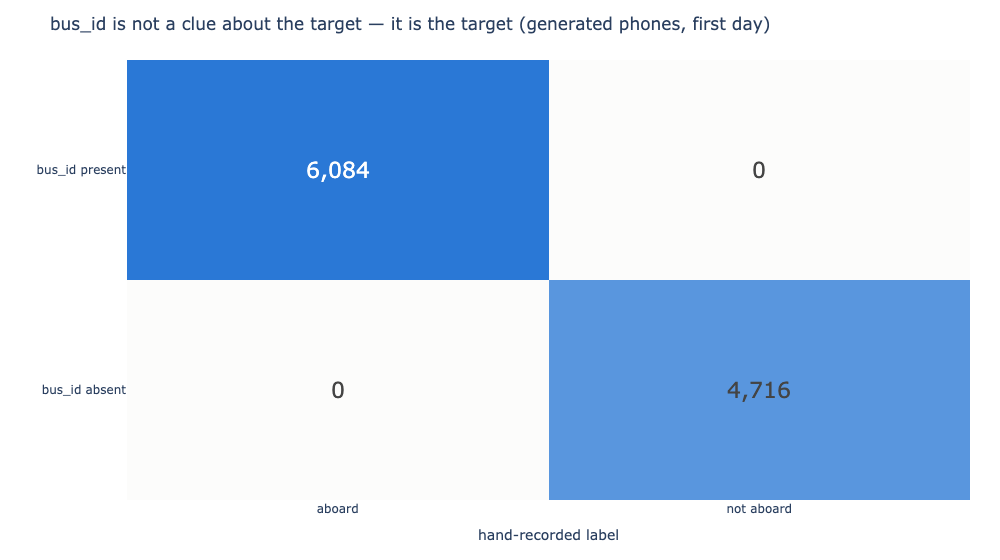

 18.88s  lab 3  figure -> shown here (lab_03_leak_table)


In [96]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 8 of 12, verbatim

cells = table.reindex(index=["bus_id present", "bus_id absent"],
                      columns=["aboard", "not aboard"]).fillna(0).astype(int)
fig = go.Figure(go.Heatmap(
    z=cells.to_numpy(), x=list(cells.columns), y=list(cells.index),
    text=[[f"{v:,}" for v in row] for row in cells.to_numpy()],
    texttemplate="%{text}", textfont=dict(size=22),
    colorscale=[[0, "#FCFCFB"], [1, "#2A78D6"]], showscale=False))
fig.update_layout(title="bus_id is not a clue about the target — it is the target "
                        "(generated phones, first day)",
                  xaxis_title="hand-recorded label", yaxis_title="", yaxis_autorange="reversed")
save_figure(fig, "leak_table", LAB, logger=say)

**Goal.** Prepare the training rows the verdict's evidence is measured on.

**Why.** A quantity that decides what enters the model must not be computed over the rows the model is judged on — the rule the medians followed above.

**What the code does.** Cuts at the same 70 per cent, keeps the training rows, their aboard indicator, and a row counter (`reading_id`) to serve as the identifier candidate.

**So what.** The next two paragraphs build the evidence from these rows.

In [97]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 9 of 12, verbatim

# The verdict, on the five columns the room will argue about. Every number
# handed over is measured here, on the training rows, or was measured by Lab
# 2; nothing is typed in from a slide, which is the rule the check enforces
# on the student's own reasons.
#
# `purity` is measured on the training rows only, for the same reason the
# medians above are: a quantity that decides what goes into the model must
# not have been computed over the rows the model is judged on.
edge = int(len(phones) * 0.7)
train_rows = phones.iloc[:edge]
aboard = (train_rows[TARGET] == "IN")
reading_id = pd.Series(np.arange(len(train_rows)), index=train_rows.index)

**Goal.** Define how one candidate's evidence is assembled.

**Why.** The verdict takes a dictionary of six quantities; building it in one place keeps the purity and the cardinality measured, not typed.

**What the code does.** `evidence_for` measures the purity against the training rows' target and the number of distinct values, and passes through the absent share, the fill bias, whether the column is knowable at prediction time, and the in-sample advantage.

**So what.** Four of the six quantities are arguments: the next paragraph says where each comes from.

In [98]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 10 of 12, verbatim

def evidence_for(series, missing_share, bias_db, knowable, gap):
    return {"missing_share": float(missing_share),
            "imputation_bias_db": float(bias_db),
            "purity": round(column_purity(series, aboard), 4),
            "cardinality": int(series.nunique(dropna=True)),
            "knowable_at_decision_time": knowable,
            "in_sample_minus_out_of_sample": gap}

**Goal.** Give the verdict on five candidates.

**Why.** The fourth deliverable: `keep_or_drop` must reach three different calls on columns that are all pure, or all but pure, and say why in numbers.

**What the code does.** Builds the evidence for `bus_id`, `stationary`, `reading_id`, `phone_speed` and `rssi1`, calls `keep_or_drop` on each, and shows the calls and the reasons.

**So what.** `bus_id`, `stationary` and the row counter are dropped, for three different reasons; `phone_speed` is above the purity threshold and kept, because its purity is spread over 1,415 values; `rssi1` is kept with its mask. Note what is typed rather than measured in this paragraph: `phone_speed`'s whole evidence (purity 0.9933, 1,415 values, gap 0.0575) and the gaps of `reading_id` (0.5069) and `rssi1` (0.1214) are numbers, not calls. The next cell recomputes them.

In [99]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 11 of 12, verbatim

candidates = {
    # Pure, and filled in by the process that writes the target.
    "bus_id": evidence_for(train_rows["bus_id"], phones["bus_id"].isna().mean(),
                           0.0, False, 0.0),
    # Pure over two values, and knowable: the leak the first question misses.
    "stationary": evidence_for(train_rows["stationary"], 0.0, 0.0, True, 0.0),
    # Pure over one value per row: the ceiling stops the leak rule, and the
    # split condemns it instead.
    "reading_id": evidence_for(reading_id, 0.0, 0.0, True, 0.5069),
    # The trap: purity above the leak threshold for an arithmetic reason.
    "phone_speed": {"missing_share": 0.0, "imputation_bias_db": 0.0,
                    "purity": 0.9933, "cardinality": 1415,
                    "knowable_at_decision_time": True,
                    "in_sample_minus_out_of_sample": 0.0575},
    # Mostly absent, and worth keeping for where it is absent.
    "rssi1": evidence_for(train_rows["rssi1"], phones["rssi1"].isna().mean(),
                          9.0, True, 0.1214),
}
verdicts = {name: keep_or_drop(evidence) for name, evidence in candidates.items()}
show_table(pd.DataFrame({name: {"call": call, "reason": reason}
                         for name, (call, reason) in verdicts.items()}).T
           .rename_axis("candidate feature"),
           "the verdict on five candidates — three different calls", logger=say)
say.info("three columns here are pure to four decimal places and the calls are "
         "drop, drop and drop; phone_speed is at %.4f, above the same threshold, "
         "and the call is keep — the difference is how many distinct values the "
         "purity is spread over (%d over 1,500 training windows), which is why "
         "the ceiling is in the rule",
         candidates["phone_speed"]["purity"], candidates["phone_speed"]["cardinality"])
say.info("bus_id is pure and has no in-sample gap at all, and it is the one that "
         "goes first: it is not knowable at the instant the model has to answer, "
         "and that question is asked before any measurement is weighed")

 19.03s  lab 3  --- the verdict on five candidates — three different calls (5 rows) ---
 19.03s  lab 3                                       call                                                                                                                                                                                                                                                                                                       reason
 19.03s  lab 3      candidate feature                                                                                                                                                                                                                                                                                                                                 
 19.03s  lab 3      bus_id                           drop                                                                                     knowable at decision time is no, so the call is sett

**Goal.** Recompute the evidence numbers the solution types in.

**Why.** "Compute, don't assert": a verdict built on typed numbers is only as good as their provenance. The solution does not say how they were measured, so the notebook states a recipe and checks that it reproduces them.

**What the code does.** `phone_speed` is Lab 4's window mean of the phone's speed. Aligns the day (Lab 1), keeps the hand-off's 1,500 training windows (before the window the 70 per cent row falls in), and measures purity and distinct values against "most of the window's readings aboard" (and, for comparison, "any reading aboard"). The gap is taken as an unpruned decision tree's accuracy on its training rows minus its accuracy on the test rows (scikit-learn, seed 20200122): on `reading_id` against the later row numbers, on `rssi1` with its gaps left empty (the tree handles them), and on `phone_speed` across the hand-off's split. Every recomputed number is printed beside the typed one.

**So what.** All five typed numbers are reproduced to four decimals by this recipe, so the verdicts rest on measurements — the recipe is the notebook's reconstruction, not something the solution states. The window target matters: with "any reading aboard" the purity is 0.9940, and the call is the same.

In [100]:
from sklearn.tree import DecisionTreeClassifier


def memorisation_gap(train_x, train_y, test_x, test_y):
    """An unpruned tree's accuracy on its own rows minus its accuracy on unseen rows."""
    tree = DecisionTreeClassifier(random_state=20200122).fit(train_x, train_y)
    return round(float(tree.score(train_x, train_y) - tree.score(test_x, test_y)), 4)


labels = (phones[TARGET] == "IN").astype(int).to_numpy()
windows_table = align(bus, load_phones(), 5)[0].sort_values(["window", "phone_id"]).reset_index(drop=True)
window_cut = windows_table["window"].iloc[int(len(windows_table) * 0.7)]
train_windows = windows_table[windows_table["window"] < window_cut]
test_windows = windows_table[windows_table["window"] >= window_cut]
majority = lambda frame: (frame["aboard"] >= 0.5).astype(int)
recomputed = {
    ("phone_speed", "purity"): (0.9933, round(column_purity(train_windows["phone_speed"],
                                                           majority(train_windows).astype(bool)), 4)),
    ("phone_speed", "cardinality"): (1415, int(train_windows["phone_speed"].nunique())),
    ("phone_speed", "gap"): (0.0575, memorisation_gap(train_windows[["phone_speed"]].to_numpy(), majority(train_windows),
                                                      test_windows[["phone_speed"]].to_numpy(), majority(test_windows))),
    ("reading_id", "gap"): (0.5069, memorisation_gap(np.arange(edge).reshape(-1, 1), labels[:edge],
                                                     np.arange(edge, len(phones)).reshape(-1, 1), labels[edge:])),
    ("rssi1", "gap"): (0.1214, memorisation_gap(phones[["rssi1"]].to_numpy()[:edge], labels[:edge],
                                                phones[["rssi1"]].to_numpy()[edge:], labels[edge:])),
}
check = pd.DataFrame([{"candidate": c, "quantity": q, "typed in the solution": typed, "recomputed": mine,
                       "agree": abs(float(typed) - float(mine)) < 5e-5} for (c, q), (typed, mine) in recomputed.items()])
print(f"training windows: {len(train_windows):,}; test windows: {len(test_windows):,}")
print(check.to_string(index=False))
print("phone_speed purity against \"any reading aboard\":",
      round(column_purity(train_windows["phone_speed"], train_windows["aboard"] > 0), 4))
assert check["agree"].all(), "a typed evidence number is not reproduced"

training windows: 1,500; test windows: 648
  candidate    quantity  typed in the solution  recomputed  agree
phone_speed      purity                 0.9933      0.9933   True
phone_speed cardinality              1415.0000   1415.0000   True
phone_speed         gap                 0.0575      0.0575   True
 reading_id         gap                 0.5069      0.5069   True
      rssi1         gap                 0.1214      0.1214   True
phone_speed purity against "any reading aboard": 0.994


**Goal.** Print what the check grades.

**Why.** The demonstration ends by telling the student what `verify/check_03.py` will ask.

**What the code does.** One narrated line.

**So what.** The constants, the moved test set, the leaks with their negative controls, and the verdict on eight candidates and on eight one-quantity changes.

In [101]:
# Source: Module 2/exercises/solutions/lab_03.py — demonstration, paragraph 12 of 12, verbatim

say.info("what the check grades: every stored median, mean and standard deviation "
         "(ddof = 0) equals the training rows' and nothing else's; apply_preprocessing "
         "moves with a moved frame and keeps the stored column order; find_leaks names "
         "bus_id and stationary, names neither a row counter nor the strongest honest "
         "feature in the frame, and still names stationary once bus_id is removed; and "
         "keep_or_drop returns the right call on eight candidates whose right calls "
         "differ — four of them pure or all but pure, three dropped and one kept — "
         "and on eight one-quantity changes, with a reason built out of the evidence")

 19.66s  lab 3  what the check grades: every stored median, mean and standard deviation (ddof = 0) equals the training rows' and nothing else's; apply_preprocessing moves with a moved frame and keeps the stored column order; find_leaks names bus_id and stationary, names neither a row counter nor the strongest honest feature in the frame, and still names stationary once bus_id is removed; and keep_or_drop returns the right call on eight candidates whose right calls differ — four of them pure or all but pure, three dropped and one kept — and on eight one-quantity changes, with a reason built out of the evidence


---
# Block 4 — The series, and what it costs

**The question of this block:** what can a window of readings say that one
reading cannot, what does a split that respects time cost, and what does a join
cost as its tolerance widens?

### Stationarity

*Slides: "Stationary vs non-stationary time series" (three slides) and "Most time-series methods assume stationarity without stating the assumption".*

**Goal.** Redraw the slides' two series and their forecasts: a stationary AR(1) and a series with a trend and two seasonal cycles.

**Why.** A stationary series has a mean, a variance and an autocorrelation that do not depend on when it is observed; its forecast returns to the mean with a band that stops growing (Box et al., 2015). A trending, seasonal series carries its pattern forward.

**What the code does.** Simulates 50 steps of x_t = 0.7·x_{t−1} + ε_t (σ = 0.6), and of a random walk with drift 0.08 a step (σ = 0.25) plus cycles of 12 and 7 steps (course seed), and draws each 20-step forecast with its 50, 80 and 95 per cent bands in closed form: for the AR(1), mean φʰ·x_T and standard deviation σ√((1 − φ²ʰ)/(1 − φ²)); for the walk, mean x_T + 0.08·h plus the cycles, and standard deviation σ√h. A third panel applies two of the slide's repairs to the non-stationary series — subtract the seasonal profile (known here, because the series is simulated), then difference — and draws what is left. The slides' animation does not state its parameters, so these are illustrative.

**So what.** The AR(1) band widens towards the series' own spread and stops; the walk's band keeps widening with the square root of the horizon, around a forecast that carries the trend and the cycles on for ever. After the two repairs the series is a constant (the drift) plus noise — stationary, and modellable. A model fitted on a drifting mean extrapolates the drift; the logarithm, the slide's third repair, is for a variance that grows with the level, which this simulation does not have.

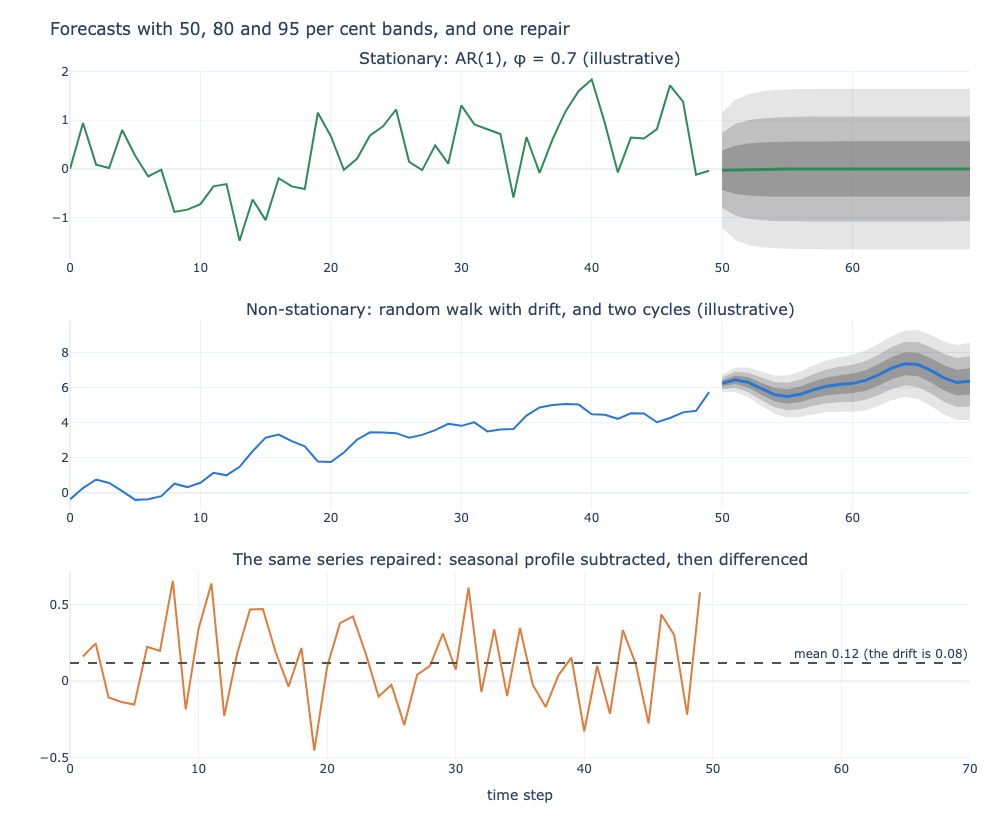

  95% band half-width at 1 and 20 steps ahead: AR(1) 1.18 and 1.65 (limit 1.65); walk 0.49 and 2.19
  repaired series: mean 0.153 in its first half, 0.087 in its second; standard deviation 0.277 and 0.262


In [102]:
rng = np.random.default_rng(20200122)
steps, horizon, phi, noise = 50, 20, 0.7, 0.6
ar = np.zeros(steps)
for k in range(1, steps):
    ar[k] = phi * ar[k - 1] + rng.normal(0, noise)
ahead = np.arange(1, horizon + 1)
ar_mean = ar[-1] * phi ** ahead
ar_sd = noise * np.sqrt((1 - phi ** (2 * ahead)) / (1 - phi ** 2))
clock = np.arange(steps + horizon)
drift, walk_noise = 0.08, 0.25
cycles = 0.5 * np.sin(2 * np.pi * clock / 12) + 0.3 * np.sin(2 * np.pi * clock / 7)
level = np.cumsum(drift + rng.normal(0, walk_noise, steps))           # random walk with drift
trending = level + cycles[:steps]
walk_mean = level[-1] + drift * ahead + cycles[steps:]
walk_sd = walk_noise * np.sqrt(ahead)
repaired = np.diff(trending - cycles[:steps])                          # deseasonalise, then difference
fig = make_subplots(rows=3, cols=1, vertical_spacing=0.09, subplot_titles=(
    "Stationary: AR(1), φ = 0.7 (illustrative)",
    "Non-stationary: random walk with drift, and two cycles (illustrative)",
    "The same series repaired: seasonal profile subtracted, then differenced"))
future = np.arange(steps, steps + horizon)
for row, series, centre, spread, colour in ((1, ar, ar_mean, ar_sd, GREEN),
                                            (2, trending, walk_mean, walk_sd, BLUE)):
    fig.add_scatter(x=np.arange(steps), y=series, mode="lines", line=dict(color=colour),
                    showlegend=False, row=row, col=1)
    for z, alpha in ((1.96, 0.15), (1.2816, 0.25), (0.6745, 0.35)):
        fig.add_scatter(x=np.r_[future, future[::-1]], y=np.r_[centre + z * spread, (centre - z * spread)[::-1]],
                        fill="toself", mode="none", fillcolor=f"rgba(80,80,80,{alpha})",
                        showlegend=False, row=row, col=1)
    fig.add_scatter(x=future, y=centre, mode="lines", line=dict(color=colour, width=3),
                    showlegend=False, row=row, col=1)
fig.add_scatter(x=np.arange(1, steps), y=repaired, mode="lines", line=dict(color=ORANGE),
                showlegend=False, row=3, col=1)
fig.add_hline(y=float(repaired.mean()), line=dict(color=GREY, dash="dash"), row=3, col=1,
              annotation_text=f"mean {repaired.mean():.2f} (the drift is {drift})")
fig.update_xaxes(title_text="time step", range=[0, steps + horizon], row=3, col=1)
fig.update_layout(title="Forecasts with 50, 80 and 95 per cent bands, and one repair")
show(fig, "stationarity_synthetic", height=820)
print(f"  95% band half-width at 1 and 20 steps ahead: AR(1) {1.96 * ar_sd[0]:.2f} and {1.96 * ar_sd[-1]:.2f} "
      f"(limit {1.96 * noise / np.sqrt(1 - phi ** 2):.2f}); walk {1.96 * walk_sd[0]:.2f} and {1.96 * walk_sd[-1]:.2f}")
half = len(repaired) // 2
print(f"  repaired series: mean {repaired[:half].mean():.3f} in its first half, {repaired[half:].mean():.3f} "
      f"in its second; standard deviation {repaired[:half].std():.3f} and {repaired[half:].std():.3f}")

**Goal.** Look for the same properties in the slice.

**Why.** The repairs the deck lists — difference a trend away, subtract a seasonal profile, take a logarithm to steady a growing variance — only make sense after the series is tested (Box et al., 2015).

**What the code does.** Averages the slice per minute (gaps removed, so the two days sit end to end). Draws the outside temperature, its first difference, and the speed's 15-minute rolling mean and standard deviation on 22 January; prints the temperature of each day's first and last half hour.

**So what.** The temperature climbs through each day and resets overnight — a trend with a daily cycle — while its first difference hovers at zero apart from the jump between the days. The speed's mean and spread change with the service pattern. Neither column is stationary as recorded.

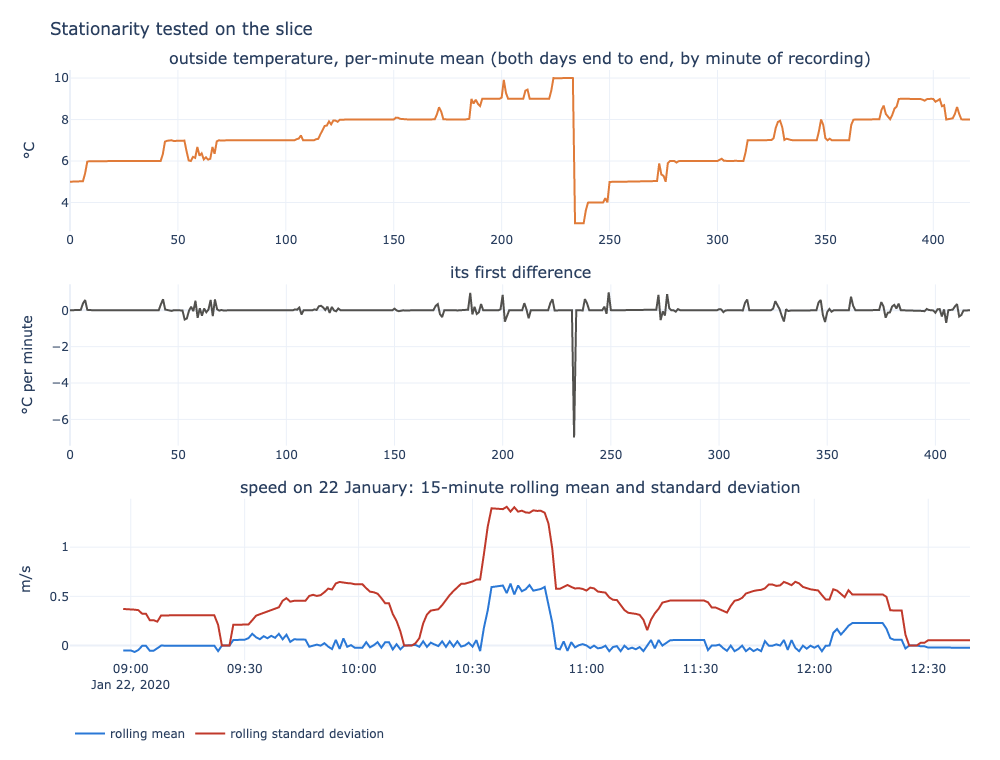

  2020-01-22: outside temperature 5.7 °C in the first half hour, 9.4 °C in the last
  2020-01-23: outside temperature 4.3 °C in the first half hour, 8.6 °C in the last


In [103]:
per_minute = in_time.set_index("_t")[["outside_temperature", "speed"]].resample("1min").mean().dropna()
first = per_minute[per_minute.index.date.astype(str) == "2020-01-22"]
fig = make_subplots(rows=3, cols=1, vertical_spacing=0.09, subplot_titles=(
    "outside temperature, per-minute mean (both days end to end, by minute of recording)",
    "its first difference",
    "speed on 22 January: 15-minute rolling mean and standard deviation"))
fig.add_scatter(x=np.arange(len(per_minute)), y=per_minute["outside_temperature"], mode="lines",
                line=dict(color=ORANGE), showlegend=False, row=1, col=1)
fig.add_scatter(x=np.arange(len(per_minute) - 1), y=per_minute["outside_temperature"].diff().dropna(),
                mode="lines", line=dict(color=GREY), showlegend=False, row=2, col=1)
fig.add_scatter(x=first.index, y=first["speed"].rolling(15).mean(), mode="lines",
                line=dict(color=BLUE), name="rolling mean", row=3, col=1)
fig.add_scatter(x=first.index, y=first["speed"].rolling(15).std(ddof=0), mode="lines",
                line=dict(color=RED), name="rolling standard deviation", row=3, col=1)
fig.update_yaxes(title_text="°C", row=1, col=1)
fig.update_yaxes(title_text="°C per minute", row=2, col=1)
fig.update_yaxes(title_text="m/s", row=3, col=1)
fig.update_layout(title="Stationarity tested on the slice", legend=dict(orientation="h", y=-0.1))
show(fig, "stationarity_on_slice", height=760)
for day, part in per_minute.groupby(per_minute.index.date.astype(str)):
    print(f"  {day}: outside temperature {part['outside_temperature'].head(30).mean():.1f} °C in the "
          f"first half hour, {part['outside_temperature'].tail(30).mean():.1f} °C in the last")

### Six features from a window

*Slides: "A window of readings yields six cheap features that one reading cannot" and "Definition — six window features"; the lag-k autocorrelation's definition slide is hidden, and the stub states it in full.*

**Goal.** Write the six features, including the slope and the lag-1 autocorrelation.

**Why.** Mean and standard deviation give position and spread; minimum, maximum and slope give shape; the autocorrelation gives structure (Kuhn & Johnson, 2019, ch. 5; Nielsen, 2019). The autocorrelation is the Box–Jenkins estimator — one mean, one sum of squares — which is not what `pandas.Series.autocorr` computes (Box et al., 2015, § 2.1.4).

**What the code does.** Writes the slope and r_k in sympy.

**So what.** Both are one line of arithmetic; the next cells check the code against them.

In [104]:
i, w, k, t = sp.symbols("i w k t", positive=True, integer=True)
x = sp.IndexedBase("x")
ibar, xbar = sp.Symbol(r"\bar{i}"), sp.Symbol(r"\bar{x}")
slope = sp.Sum((i - ibar) * (x[i] - xbar), (i, 1, w)) / sp.Sum((i - ibar)**2, (i, 1, w))
r_k = sp.Sum((x[t] - xbar) * (x[t - k] - xbar), (t, k + 1, w)) / sp.Sum((x[t] - xbar)**2, (t, 1, w))
formula(sp.Eq(xbar, sp.Sum(x[i], (i, 1, w)) / w, evaluate=False),
        sp.Eq(sp.Symbol(r"\sigma"), sp.sqrt(sp.Sum((x[i] - xbar)**2, (i, 1, w)) / w), evaluate=False),
        sp.Symbol(r"\text{(ddof = 0)}"),
        sp.Eq(sp.Symbol(r"x_{\min}"), sp.Function(r"\min_{i}")(x[i]), evaluate=False),
        sp.Eq(sp.Symbol(r"x_{\max}"), sp.Function(r"\max_{i}")(x[i]), evaluate=False))
formula(sp.Eq(sp.Symbol("b"), slope, evaluate=False), sp.Eq(sp.Symbol("r_k"), r_k, evaluate=False))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define the first two of Lab 4's functions as the solution writes them.

**Why.** `window_features` is the first deliverable of Laboratory 4; it uses exactly the last `width` values, because a window that reaches further back is a small leak.

**What the code does.** Copies the constants, `sample_autocorrelation` and `window_features` from `solutions/lab_04.py`.

**So what.** The remaining two functions are defined where the deck introduces the split and the join.

In [105]:
# Source: Module 2/exercises/solutions/lab_04.py — LAB, TOLERANCES, DDOF, TRAIN_FRACTION, TARGET_COLUMN, HANDOFF_SCHEMA, sample_autocorrelation, window_features, verbatim
# References: (Box et al., 2015, § 2.1.4; Kuhn & Johnson, 2019, ch. 5)

import sys
import pathlib
import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go


LAB = 4


TOLERANCES = (1, 2, 5, 10, 30)


DDOF = 0                   # population standard deviation, the same choice as Lab 3


TRAIN_FRACTION = 0.7       # the share of rows that train, stated once


TARGET_COLUMN = "aboard"   # what the next three modules are asked to predict


HANDOFF_SCHEMA = "1.0"     # the version Module 3 refuses to read anything but


def sample_autocorrelation(values, lag: int = 1) -> float:
    """r_k = Σ_{t=k+1}^{n} (x_t − x̄)(x_{t−k} − x̄) / Σ_{t=1}^{n} (x_t − x̄)².

    The Box–Jenkins sample autocorrelation (Box, Jenkins, Reinsel & Ljung, 2015,
    section 2.1.4): one mean over the whole window, and the whole window's sum of
    squares in the denominator. This is the estimator Module 1 defined and it is
    not what `pandas.Series.autocorr` computes -- that one is the Pearson
    correlation between the series and its shifted copy, with two means and two
    variances, so the two disagree on every finite window. The course uses one
    definition so that Module 1's 0.997 and this lab's number are the same
    quantity. Pairs where either member is absent are skipped where they stand;
    the mean and the denominator use the values that are present.
    """
    x = np.asarray(values, dtype=float)
    present = ~np.isnan(x)
    if present.sum() < lag + 2:
        return float("nan")
    centred = x - np.nanmean(x)
    later, earlier = centred[lag:], centred[:-lag]
    both = ~np.isnan(later) & ~np.isnan(earlier)
    denominator = float(np.nansum(centred ** 2))
    if denominator == 0.0:
        return float("nan")
    return float(np.sum(later[both] * earlier[both]) / denominator)


def window_features(series, width: int) -> dict:
    """Six numbers describing the last `width` readings.

    The slope is the one worth dwelling on. Mean and standard deviation say
    where a signal sits and how much it moves; only the gradient says which way
    it is going, and "decelerating" is usually the operationally interesting
    state. Fitting a straight line against position is the cheapest way to get
    it, and it costs one call.

    Note the strictness about `width`: exactly the last `width` values and no
    more. A window that quietly reaches further back on the first few rows is a
    small leak of the same family as Lab 3 -- information from outside the
    window entering a feature that claims to summarise it. The standard
    deviation is the population one (ddof = 0), stated so that the check and
    this file grade the same number.
    """
    values = pd.Series(series).astype(float).tail(width).reset_index(drop=True)
    positions = np.arange(len(values), dtype=float)

    present = values.notna()
    if present.sum() >= 2:
        slope = float(np.polyfit(positions[present], values[present], 1)[0])
    else:
        slope = float("nan")

    return {
        "mean": float(values.mean()),
        "std": float(values.std(ddof=DDOF)),
        "minimum": float(values.min()),
        "maximum": float(values.max()),
        "slope": slope,
        "autocorrelation_1": sample_autocorrelation(values, 1),
    }

**Goal.** Check the code against the formulas.

**Why.** The hidden definition slide says the estimator returns exactly two fifths on the window 1, 2, 3, 4, 5; the slope formula is the least-squares gradient.

**What the code does.** Evaluates r_1 on 1…5 with sympy (an exact fraction) and with `sample_autocorrelation`; evaluates the slope formula with sympy on a planted window and compares it with `window_features`, which uses `numpy.polyfit`.

**So what.** Two fifths both ways, and pandas' estimator gives 1.0 on the same window — the difference the stub warns about.

In [106]:
planted = [1, 2, 3, 4, 5]
exact = r_k.subs({k: 1, w: 5}).doit().subs({x[m]: v for m, v in enumerate(planted, start=1)})
exact = sp.nsimplify(exact.subs(xbar, sp.Rational(sum(planted), len(planted))))
print("r_1 of 1..5 by the formula:", exact, "  by the code:", sample_autocorrelation(planted, 1),
      "  by pandas:", pd.Series(planted).autocorr(1))
agrees("r_1 of the window 1, 2, 3, 4, 5", sample_autocorrelation(planted, 1), 0.4, 10)
window = [3.0, 1.0, 4.0, 1.0, 5.0, 9.0, 2.0, 6.0]
values = {x[m]: v for m, v in enumerate(window, start=1)}
by_formula = slope.subs(w, len(window)).doit().subs(values).subs(
    {ibar: sp.Rational(len(window) + 1, 2), xbar: sp.Rational(int(sum(window)), len(window))})
print("slope of", window, "by the formula:", float(by_formula), "  by the code:",
      window_features(pd.Series(window), len(window))["slope"])

r_1 of 1..5 by the formula: 2/5   by the code: 0.4   by pandas: 1.0
  r_1 of the window 1, 2, 3, 4, 5                                    deck 0.4       computed 0.4
slope of [3.0, 1.0, 4.0, 1.0, 5.0, 9.0, 2.0, 6.0] by the formula: 0.5357142857142857   by the code: 0.5357142857142856


**Goal.** Draw one window of the slice's speed and its six features.

**Why.** The slide's picture is a generated drawing of a sine-like signal; the slice has a real one. It also says the autocorrelation is "measured here at 0.9967" — that is the whole day's lag-1 value, not a window's.

**What the code does.** Takes 22 January from 10:15 UTC, marks the window of the last 60 readings (30 seconds) ending at the 180th reading, computes `window_features`, and draws the mean, the ±1 standard deviation band, the extremes and the fitted slope. Then computes r_1 over every 30-second window of the moving day.

**So what.** Six numbers describe the window instant by instant; the slope turns braking into a number an operator can act on.

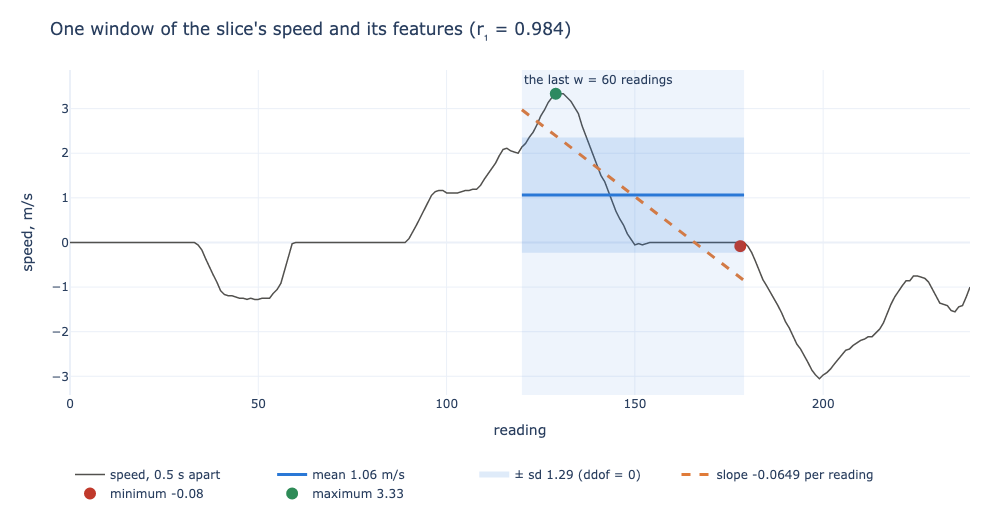

{'mean': 1.0609, 'std': 1.2925, 'minimum': -0.083, 'maximum': 3.333, 'slope': -0.0649, 'autocorrelation_1': 0.9844}
  lag-1 autocorrelation of a 30-second window: computed here median 0.954 over 142 windows of the moving day; stated 0.9967 (the drawing: "measured here at 0.9967") — 0.9967 is the whole day's lag-1 value (Module 1); within a short window the mean and the sum of squares are the window's own, and r₁ is lower


In [107]:
stretch = slice_day_one[slice_day_one["_t"] >= pd.Timestamp("2020-01-22 10:15:00", tz="UTC")].head(240)
series = stretch["speed"].reset_index(drop=True)
end, width = 180, 60
feats = window_features(series.iloc[:end], width)
position = np.arange(end - width, end)
fig = go.Figure()
fig.add_scatter(y=series, mode="lines", line=dict(color=GREY, width=1.5), name="speed, 0.5 s apart")
fig.add_vrect(x0=end - width, x1=end - 1, fillcolor="rgba(42,120,214,0.08)", line_width=0,
              annotation_text=f"the last w = {width} readings", annotation_position="top left")
fig.add_scatter(x=position, y=np.full(width, feats["mean"]), mode="lines", line=dict(color=BLUE, width=3),
                name=f"mean {feats['mean']:.2f} m/s")
fig.add_scatter(x=np.r_[position, position[::-1]],
                y=np.r_[np.full(width, feats["mean"] + feats["std"]), np.full(width, feats["mean"] - feats["std"])],
                fill="toself", mode="none", fillcolor="rgba(42,120,214,0.15)",
                name=f"± sd {feats['std']:.2f} (ddof = 0)")
centre = (width - 1) / 2
fig.add_scatter(x=position, y=feats["mean"] + feats["slope"] * (np.arange(width) - centre), mode="lines",
                line=dict(color=ORANGE, width=3, dash="dash"), name=f"slope {feats['slope']:+.4f} per reading")
inside = series.iloc[end - width:end]
for value, label, colour in ((feats["minimum"], "minimum", RED), (feats["maximum"], "maximum", GREEN)):
    at = int(inside[inside == value].index[0])
    fig.add_scatter(x=[at], y=[value], mode="markers", marker=dict(size=12, color=colour),
                    name=f"{label} {value:.2f}")
fig.update_layout(title=f"One window of the slice's speed and its features (r₁ = {feats['autocorrelation_1']:.3f})",
                  xaxis_title="reading", yaxis_title="speed, m/s", legend=dict(orientation="h", y=-0.2))
show(fig, "window_anatomy", height=520)
print({key: round(value, 4) for key, value in feats.items()})
moving = slice_day_one[slice_day_one["speed"].abs() > 0]["speed"].to_numpy()
window_r1 = [sample_autocorrelation(moving[s:s + width], 1) for s in range(0, len(moving) - width, width)]
beside("lag-1 autocorrelation of a 30-second window", f"median {np.nanmedian(window_r1):.3f} over "
       f"{len(window_r1)} windows of the moving day", "0.9967 (the drawing: \"measured here at 0.9967\")",
       "0.9967 is the whole day's lag-1 value (Module 1); within a short window the mean and the "
       "sum of squares are the window's own, and r₁ is lower")

**Goal.** Compute the slide's other window features on a real window: peaks, amplitude, peak-to-peak, and the points beyond one standard deviation.

**Why.** The slide lists these features over a time interval and illustrates amplitude with a textbook sine (Nielsen, 2019).

**What the code does.** Takes five minutes of 22 January's speed, finds peaks with `scipy.signal.find_peaks` (prominence 0.5 m/s, a stated choice), and computes amplitude (half the range), peak-to-peak, the peaks above mean + 1 sd, and the readings outside ±1 sd.

**So what.** Each is one line of code and one more column; each must still be justified like any other feature.

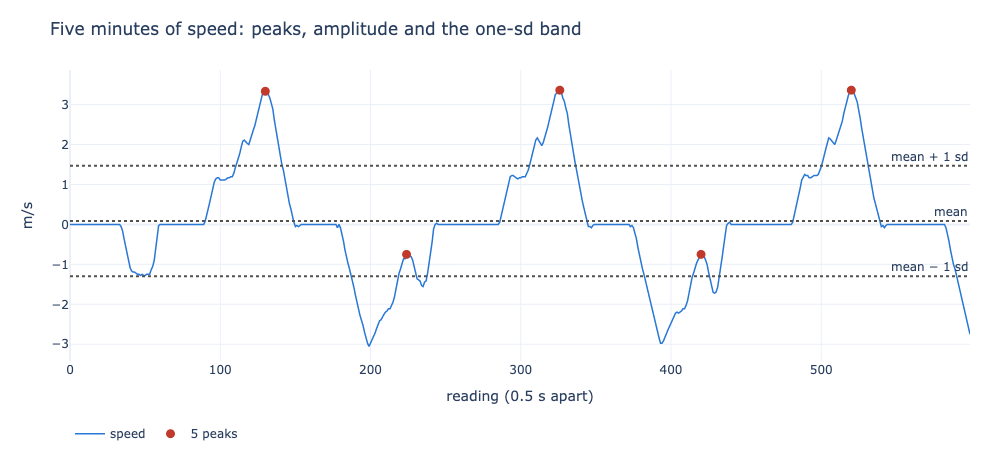

  peaks: 5; above mean + 1 sd: 3; readings outside ±1 sd: 179 of 600; amplitude 3.21 m/s; peak-to-peak 6.42 m/s


In [108]:
five = slice_day_one[slice_day_one["_t"] >= pd.Timestamp("2020-01-22 10:15:00", tz="UTC")].head(600)["speed"].to_numpy()
peaks, _ = signal.find_peaks(five, prominence=0.5)
mean, sd = five.mean(), five.std()
fig = go.Figure()
fig.add_scatter(y=five, mode="lines", line=dict(color=BLUE, width=1.5), name="speed")
fig.add_scatter(x=peaks, y=five[peaks], mode="markers", marker=dict(color=RED, size=9), name=f"{len(peaks)} peaks")
for level, label in ((mean + sd, "mean + 1 sd"), (mean, "mean"), (mean - sd, "mean − 1 sd")):
    fig.add_hline(y=level, line=dict(color=GREY, dash="dot"), annotation_text=label)
fig.update_layout(title="Five minutes of speed: peaks, amplitude and the one-sd band",
                  xaxis_title="reading (0.5 s apart)", yaxis_title="m/s", legend=dict(orientation="h", y=-0.2))
show(fig, "peaks_amplitude", height=460)
print(f"  peaks: {len(peaks)}; above mean + 1 sd: {int((five[peaks] > mean + sd).sum())}; "
      f"readings outside ±1 sd: {int((np.abs(five - mean) > sd).sum())} of {len(five)}; "
      f"amplitude {(five.max() - five.min()) / 2:.2f} m/s; peak-to-peak {five.max() - five.min():.2f} m/s")

### Feature engineering from columns, from time, and from position

*Slides: "Feature engineering basics" (three slides).*

The next three figures use one-minute windows of the slice, which the next cell builds.

**Goal.** Summarise the slice per minute.

**Why.** Combining columns, extracting date parts and correlating features all need one row per unit; a minute is long enough to average and short enough to keep the day's structure.

**What the code does.** Groups the slice by minute (UTC), keeps minutes with at least 100 readings, and computes `window_features` on the speed plus mean payload, inside and outside temperature, battery level, the share driven manually, and the mean of the per-reading product payload × speed.

**So what.** A table of one row per minute, used by the next five figures.

In [109]:
rows = []
for minute, part in in_time.groupby(in_time["_t"].dt.floor("1min")):
    if len(part) < 100:
        continue
    feats = window_features(part["speed"], len(part))
    rows.append({"minute": minute, "day": str(minute.date()), **{f"speed_{k}": v for k, v in feats.items()},
                 "payload": part["payload"].mean(), "inside_temperature": part["inside_temperature"].mean(),
                 "outside_temperature": part["outside_temperature"].mean(),
                 "battery_level": part["battery_level"].mean(), "manual_share": (part["mode"] == "manual").mean(),
                 "mean_of_product": (part["payload"] * part["speed"]).mean()})
minutes = pd.DataFrame(rows)
print(f"{len(minutes)} one-minute windows; columns: {', '.join(minutes.columns[2:])}")

390 one-minute windows; columns: speed_mean, speed_std, speed_minimum, speed_maximum, speed_slope, speed_autocorrelation_1, payload, inside_temperature, outside_temperature, battery_level, manual_share, mean_of_product


**Goal.** Combine two columns into one feature, and see what it adds.

**Why.** The slide's example multiplies two columns (distance to a fire station and a complexity index). The slice's analogue: payload times speed, how much load is moving. Domain knowledge chooses the combination; no algorithm will.

**What the code does.** Plots the per-minute product of the means against each factor, and against the mean of the per-reading product.

**So what.** The product follows speed closely and payload hardly at all (correlations printed), so it carries a claim the two factors do not state separately. The product of two means and the mean of the product are different definitions; here they track each other, but the feature has to say which it is.

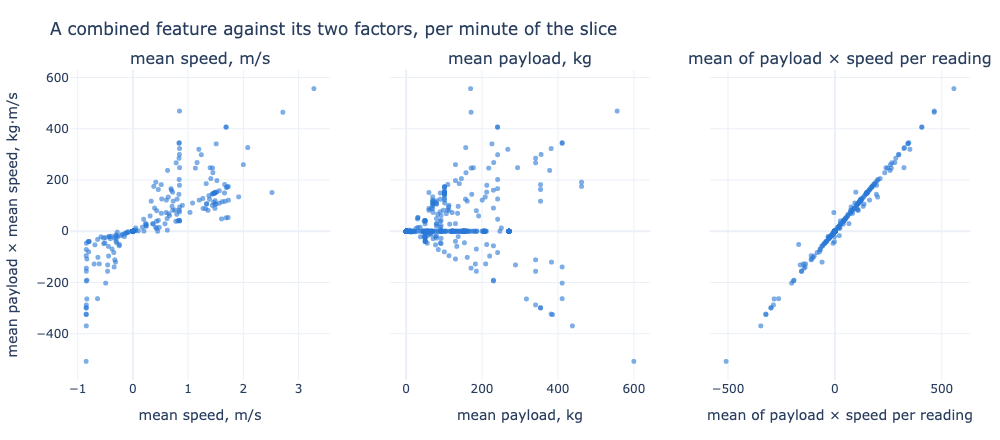

payload_x_speed    1.000
speed_mean         0.817
payload            0.033
mean_of_product    0.994


In [110]:
minutes["payload_x_speed"] = minutes["payload"] * minutes["speed_mean"]
pairs = [("speed_mean", "mean speed, m/s"), ("payload", "mean payload, kg"),
         ("mean_of_product", "mean of payload × speed per reading")]
fig = make_subplots(rows=1, cols=3, subplot_titles=[p[1] for p in pairs], shared_yaxes=True)
for col, (column, label) in enumerate(pairs, start=1):
    fig.add_scatter(x=minutes[column], y=minutes["payload_x_speed"], mode="markers",
                    marker=dict(color=BLUE, size=5, opacity=0.6), showlegend=False, row=1, col=col)
    fig.update_xaxes(title_text=label, row=1, col=col)
fig.update_yaxes(title_text="mean payload × mean speed, kg·m/s", row=1, col=1)
fig.update_layout(title="A combined feature against its two factors, per minute of the slice")
show(fig, "combined_feature", height=440)
corr = minutes[["payload_x_speed", "speed_mean", "payload", "mean_of_product"]].corr().round(3)
print(corr.loc["payload_x_speed"].to_string())

**Goal.** Extract a date part: the hour of the day, in local time.

**Why.** The slide shows time-of-day, day-of-week, time-of-month and time-of-year bins. The slice spans two days, so only the hour is informative here, and it must be extracted in local time — computed from `utc_time`, never read from `timestamp` (McKinney, 2022, ch. 11).

**What the code does.** Converts `utc_time` to Europe/Copenhagen, extracts the hour, and counts readings per hour and day.

**So what.** Both days ran from the 9 o'clock to the 13 o'clock hour, local time, and the second day stopped early in the last of them; a model given the hour learns the timetable, which is what the feature asserts.

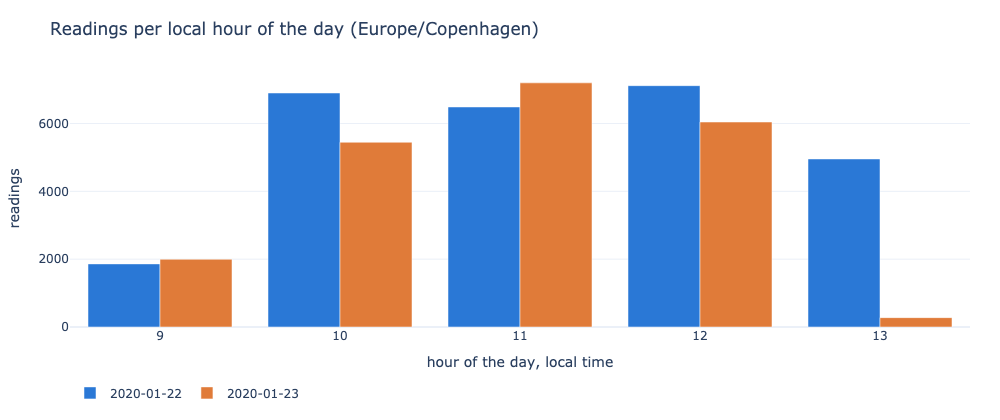

utc_time  2020-01-22  2020-01-23
utc_time                        
9               1861        1997
10              6901        5448
11              6489        7200
12              7117        6045
13              4956         276


In [111]:
local = pd.to_datetime(bus["utc_time"], utc=True).dt.tz_convert("Europe/Copenhagen")
per_hour = pd.crosstab(local.dt.hour, local.dt.date.astype(str))
fig = go.Figure()
for day, colour in zip(per_hour.columns, (BLUE, ORANGE)):
    fig.add_bar(x=per_hour.index, y=per_hour[day], name=day, marker_color=colour)
fig.update_layout(barmode="group", title="Readings per local hour of the day (Europe/Copenhagen)",
                  xaxis_title="hour of the day, local time", yaxis_title="readings",
                  legend=dict(orientation="h", y=-0.2))
show(fig, "date_parts", height=420)
print(per_hour.to_string())

**Goal.** Write the four motion channels derived from positions.

**Why.** The slide shows the channels a GPS-based mode detector stacks — speed, acceleration, jerk and bearing rate — each a difference quotient of the one before (Dabiri, 2018).

**What the code does.** Writes them in sympy, with d(P₁, P₂) the distance between consecutive fixes (the slide uses Vincenty's formula; below the haversine formula on a sphere, which differs by far less than a metre over these distances).

**So what.** Four channels from two columns and a clock: position is a rich source of features.

In [112]:
dt = sp.Symbol(r"\Delta t", positive=True)
S1, S2, A1, A2 = sp.symbols("S_{P_1} S_{P_2} A_{P_1} A_{P_2}")
formula(sp.Eq(S1, sp.Function("d")(sp.Symbol("P_1"), sp.Symbol("P_2")) / dt, evaluate=False),
        sp.Eq(A1, (S2 - S1) / dt, evaluate=False),
        sp.Eq(sp.Symbol("J_{P_1}"), (A2 - A1) / dt, evaluate=False),
        sp.Eq(sp.Symbol("BR_{P_1}"), sp.Abs(sp.Symbol(r"\mathrm{Bearing}_{P_2}") - sp.Symbol(r"\mathrm{Bearing}_{P_1}")), evaluate=False))

<IPython.core.display.Math object>

**Goal.** Derive the four channels from the slice's positions, and compare the derived speed with the speed the vehicle reports.

**Why.** Deriving a channel from positions is only as good as the positions; the vehicle reports its own speed and heading, so the derivation can be checked.

**What the code does.** Takes two minutes of 22 January from 10:15 UTC, every fourth reading (about two seconds apart), computes haversine distances, speed, acceleration, jerk and the bearing rate, and draws them with the reported speed.

**So what.** The derived speed follows the reported magnitude; each further difference is noisier. The bearing is undefined when the vehicle stands or reverses, so the bearing rate spikes at every stop — a channel needs a rule for rest before it is a feature.

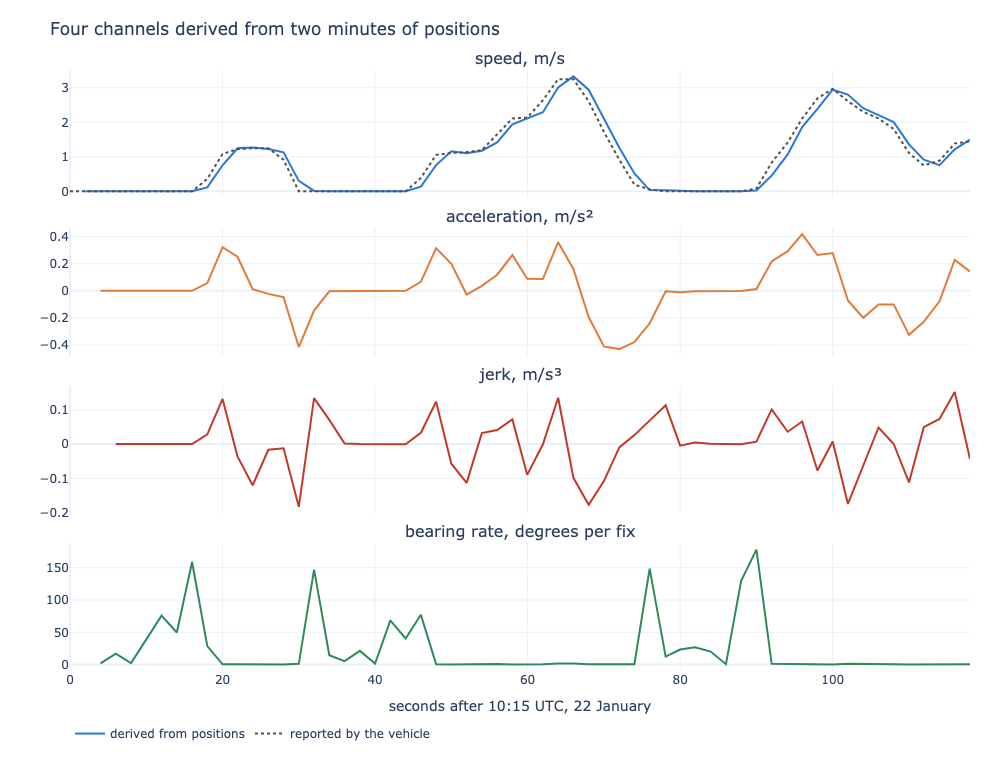

  derived against reported speed: correlation 0.984, median absolute difference 0.049 m/s


In [113]:
track = slice_day_one[slice_day_one["_t"] >= pd.Timestamp("2020-01-22 10:15:00", tz="UTC")].head(240).iloc[::4]
lat, lon = np.radians(track["lat"].to_numpy()), np.radians(track["lon"].to_numpy())
seconds = (track["_t"] - track["_t"].iloc[0]).dt.total_seconds().to_numpy()
R = 6_371_000.0                                             # mean Earth radius, metres
h = np.sin(np.diff(lat) / 2) ** 2 + np.cos(lat[:-1]) * np.cos(lat[1:]) * np.sin(np.diff(lon) / 2) ** 2
distance = 2 * R * np.arcsin(np.sqrt(h))
dt_s = np.diff(seconds)
speed_ch = distance / dt_s
accel = np.diff(speed_ch) / dt_s[1:]
jerk = np.diff(accel) / dt_s[2:]
bearing = np.degrees(np.arctan2(np.sin(np.diff(lon)) * np.cos(lat[1:]),
                                np.cos(lat[:-1]) * np.sin(lat[1:]) - np.sin(lat[:-1]) * np.cos(lat[1:]) * np.cos(np.diff(lon))))
bearing_rate = np.abs((np.diff(bearing) + 180) % 360 - 180)
fig = make_subplots(rows=4, cols=1, shared_xaxes=True, vertical_spacing=0.05,
                    subplot_titles=("speed, m/s", "acceleration, m/s²", "jerk, m/s³", "bearing rate, degrees per fix"))
fig.add_scatter(x=seconds[1:], y=speed_ch, mode="lines", line=dict(color=BLUE), name="derived from positions", row=1, col=1)
fig.add_scatter(x=seconds, y=track["speed"].abs(), mode="lines", line=dict(color=GREY, dash="dot"),
                name="reported by the vehicle", row=1, col=1)
fig.add_scatter(x=seconds[2:], y=accel, mode="lines", line=dict(color=ORANGE), showlegend=False, row=2, col=1)
fig.add_scatter(x=seconds[3:], y=jerk, mode="lines", line=dict(color=RED), showlegend=False, row=3, col=1)
fig.add_scatter(x=seconds[2:], y=bearing_rate, mode="lines", line=dict(color=GREEN), showlegend=False, row=4, col=1)
fig.update_xaxes(title_text="seconds after 10:15 UTC, 22 January", row=4, col=1)
fig.update_layout(title="Four channels derived from two minutes of positions",
                  legend=dict(orientation="h", y=-0.08))
show(fig, "gps_channels", height=760)
reported = track["speed"].abs().to_numpy()[1:]
print(f"  derived against reported speed: correlation {np.corrcoef(speed_ch, reported)[0, 1]:.3f}, "
      f"median absolute difference {np.median(np.abs(speed_ch - reported)):.3f} m/s")

### Selection and reduction

*Slides: "Feature selection vs dimensionality reduction" (two slides) and "Selection keeps columns and reduction replaces them, and they trade differently".*

**Goal.** Compare the Pearson and Spearman correlations of the slice's minute features.

**Why.** A correlation filter needs its own choice: Pearson measures straight-line agreement, Spearman agreement in rank, which survives a curved relationship.

**What the code does.** Computes both matrices over the minute table's ten features and draws them side by side.

**So what.** Where the two disagree, the relationship is monotone but not straight — and a filter built on the wrong one keeps or drops the wrong column.

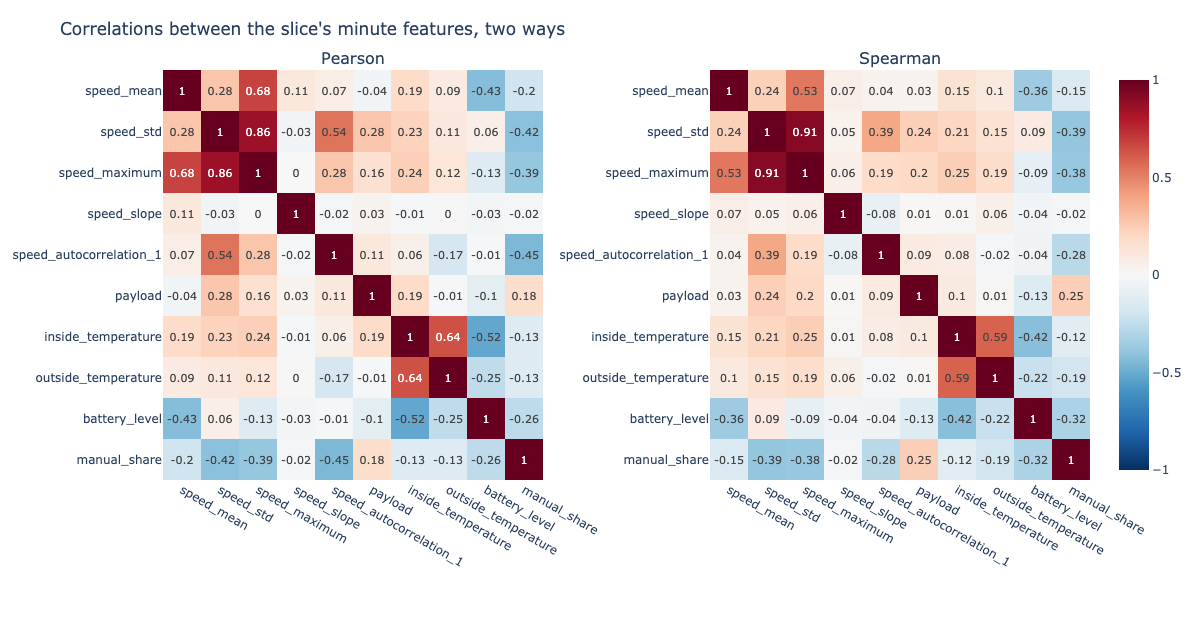

  largest Pearson-Spearman disagreement: speed_autocorrelation_1 vs manual_share: Pearson -0.45, Spearman -0.28


In [114]:
feature_columns = ["speed_mean", "speed_std", "speed_maximum", "speed_slope", "speed_autocorrelation_1",
                   "payload", "inside_temperature", "outside_temperature", "battery_level", "manual_share"]
pearson = minutes[feature_columns].corr(method="pearson")
spearman = minutes[feature_columns].corr(method="spearman")
fig = make_subplots(rows=1, cols=2, subplot_titles=("Pearson", "Spearman"), horizontal_spacing=0.18)
for col, matrix in ((1, pearson), (2, spearman)):
    fig.add_heatmap(z=matrix.to_numpy(), x=feature_columns, y=feature_columns, zmin=-1, zmax=1,
                    colorscale="RdBu_r", text=matrix.round(2).to_numpy(), texttemplate="%{text}",
                    showscale=col == 2, row=1, col=col)
fig.update_yaxes(autorange="reversed")
fig.update_layout(title="Correlations between the slice's minute features, two ways",
                  margin=dict(l=160, r=30, t=70, b=160))
show(fig, "correlation_matrices", width=1200, height=640)
gap = (spearman - pearson).abs()
np.fill_diagonal(gap.values, 0)
worst = gap.stack().idxmax()
print(f"  largest Pearson-Spearman disagreement: {worst[0]} vs {worst[1]}: "
      f"Pearson {pearson.loc[worst]:.2f}, Spearman {spearman.loc[worst]:.2f}")

**Goal.** Reduce the minute features with principal component analysis.

**Why.** Reduction replaces columns with combinations of them: compact, and no longer explainable to a colleague.

**What the code does.** Keeps the minutes where all ten features are defined, standardises them (ddof = 0), takes the singular value decomposition, plots every minute on the first two components coloured by day, and draws each feature's loading as an arrow.

**So what.** Two components carry about half the variance (the title prints the shares); each is a mixture of speed, temperature and battery that no one can read off a dashboard.

  minutes with every feature defined: 189 of 390 (a minute at rest has no autocorrelation: its sum of squares is zero)


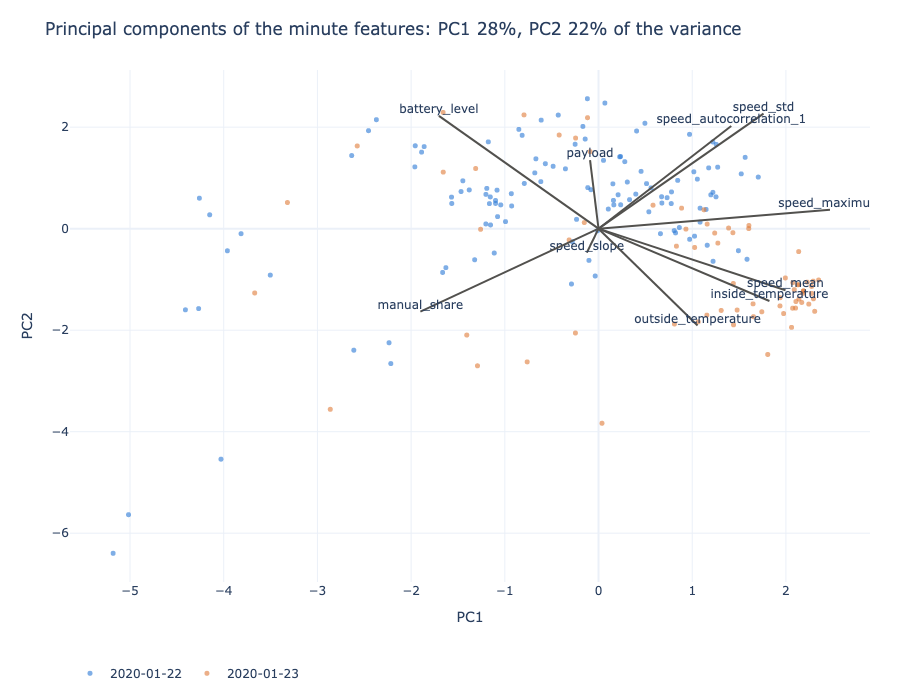

In [115]:
complete = minutes.dropna(subset=feature_columns).reset_index(drop=True)
print(f"  minutes with every feature defined: {len(complete)} of {len(minutes)} "
      "(a minute at rest has no autocorrelation: its sum of squares is zero)")
standard = (complete[feature_columns] - complete[feature_columns].mean()) / complete[feature_columns].std(ddof=0)
u, singular, vt = np.linalg.svd(standard.to_numpy(), full_matrices=False)
explained = singular ** 2 / np.sum(singular ** 2)
scores = standard.to_numpy() @ vt[:2].T
fig = go.Figure()
for day, colour in (("2020-01-22", BLUE), ("2020-01-23", ORANGE)):
    chosen = (complete["day"] == day).to_numpy()
    fig.add_scatter(x=scores[chosen, 0], y=scores[chosen, 1], mode="markers",
                    marker=dict(color=colour, size=5, opacity=0.6), name=day)
scale = np.abs(scores).max() * 0.8
for column, (a, b) in zip(feature_columns, vt[:2].T):
    fig.add_scatter(x=[0, a * scale], y=[0, b * scale], mode="lines+text", text=["", column],
                    textposition="top center", line=dict(color=GREY), showlegend=False)
fig.update_layout(title=f"Principal components of the minute features: PC1 {explained[0]:.0%}, "
                        f"PC2 {explained[1]:.0%} of the variance",
                  xaxis_title="PC1", yaxis_title="PC2", legend=dict(orientation="h", y=-0.15))
show(fig, "pca", width=900, height=700)

**Goal.** Set selection and reduction side by side on the same ten features.

**Why.** Selection keeps a subset — here, drop one of each pair correlated beyond 0.9 in absolute Spearman correlation, a stated threshold. Reduction builds new columns — here, principal components. The trade is interpretability against compactness.

**What the code does.** Runs the correlation filter (keeping the earlier column of each pair) and counts the principal components needed for 90 per cent of the variance.

**So what.** On these weakly correlated features neither buys much compactness: the filter drops one column, and seven components are needed for 90 per cent. Selection keeps named columns a transport authority can justify; reduction explains none of them.

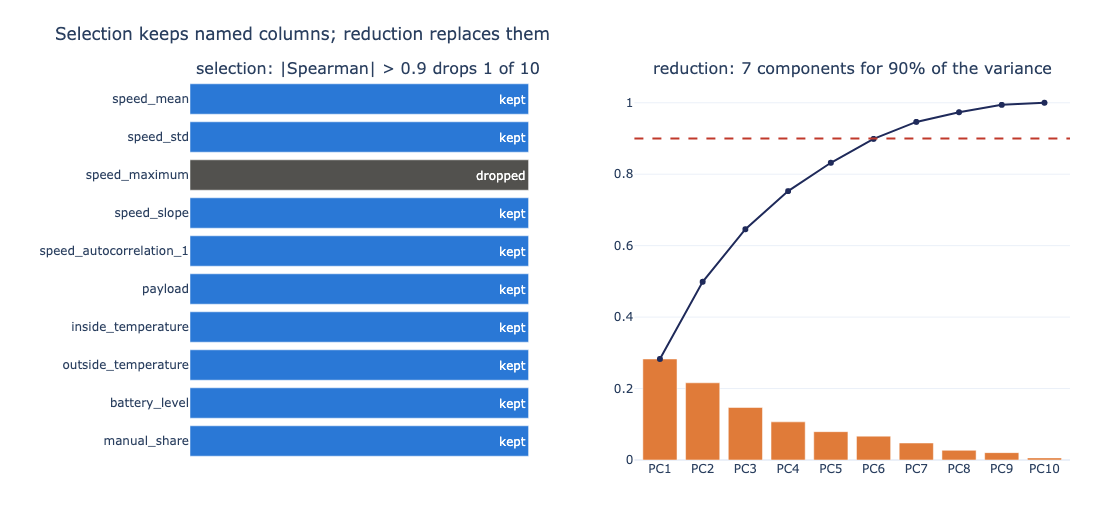

  kept: ['speed_mean', 'speed_std', 'speed_slope', 'speed_autocorrelation_1', 'payload', 'inside_temperature', 'outside_temperature', 'battery_level', 'manual_share']
  dropped: ['speed_maximum']


In [116]:
absolute = spearman.abs()
dropped = []
for position, first in enumerate(feature_columns):
    for second in feature_columns[position + 1:]:
        if first not in dropped and second not in dropped and absolute.loc[first, second] > 0.9:
            dropped.append(second)
kept = [c for c in feature_columns if c not in dropped]
needed = int(np.searchsorted(np.cumsum(explained), 0.90) + 1)
fig = make_subplots(rows=1, cols=2, column_widths=[0.45, 0.55], subplot_titles=(
    f"selection: |Spearman| > 0.9 drops {len(dropped)} of {len(feature_columns)}",
    f"reduction: {needed} components for 90% of the variance"))
fig.add_bar(y=feature_columns, x=[1] * len(feature_columns), orientation="h", showlegend=False,
            marker_color=[GREY if c in dropped else BLUE for c in feature_columns],
            text=["dropped" if c in dropped else "kept" for c in feature_columns], textposition="inside",
            row=1, col=1)
fig.add_bar(x=[f"PC{m}" for m in range(1, len(explained) + 1)], y=explained, marker_color=ORANGE,
            showlegend=False, row=1, col=2)
fig.add_scatter(x=[f"PC{m}" for m in range(1, len(explained) + 1)], y=np.cumsum(explained),
                mode="lines+markers", line=dict(color=NAVY), showlegend=False, row=1, col=2)
fig.add_hline(y=0.9, line=dict(color=RED, dash="dash"), row=1, col=2)
fig.update_xaxes(visible=False, row=1, col=1)
fig.update_yaxes(autorange="reversed", row=1, col=1)
fig.update_layout(title="Selection keeps named columns; reduction replaces them",
                  margin=dict(l=190, r=30, t=80, b=60))
show(fig, "selection_vs_reduction", width=1100, height=520)
print("  kept:", kept)
print("  dropped:", dropped)

### A second description: the spectrum

*Slides: "A spectrum is worth computing where the structure is concentrated in few rhythms", "Definition — the discrete Fourier transform of a window", "Adding independent errors multiplies their spectra, and leaves the normal curve", and "Feature extraction in timeseries" (three slides on the transform).*

**Goal.** Write the transform and its inverse, and check numpy's against them.

**Why.** The transform rewrites N readings as N amplitudes, one per rhythm that fits a whole number of times into the window; the inverse gives the readings back, and energy is the same under both descriptions (Cooley & Tukey, 1965; Oppenheim & Schafer, 2010, ch. 8).

**What the code does.** Writes X_k and x_n in sympy; builds the transform as an N × N matrix for N = 4, applies it to 1, 2, 3, 4 and compares with `numpy.fft.fft`; checks the inverse and Parseval's identity.

**So what.** The formula on the slide is exactly what `numpy.fft` computes; no information is created or lost.

In [117]:
n_, k_, N_ = sp.symbols("n k N", integer=True, nonnegative=True)
xs, Xs = sp.IndexedBase("x"), sp.IndexedBase("X")
formula(sp.Eq(Xs[k_], sp.Sum(xs[n_] * sp.exp(-2 * sp.pi * sp.I * k_ * n_ / N_), (n_, 0, N_ - 1)), evaluate=False),
        sp.Eq(xs[n_], sp.Sum(Xs[k_] * sp.exp(2 * sp.pi * sp.I * k_ * n_ / N_), (k_, 0, N_ - 1)) / N_, evaluate=False))
size = 4
matrix = sp.Matrix(size, size, lambda a, b: sp.exp(-2 * sp.pi * sp.I * a * b / size))
sequence = sp.Matrix([1, 2, 3, 4])
spectrum = sp.simplify(matrix * sequence)
print("by the formula:", list(spectrum), "  numpy.fft:", np.fft.fft([1, 2, 3, 4]).round(10).tolist())
print("inverse returns the readings:", list(sp.simplify(matrix.H * spectrum / size)))
print("Parseval: sum |x|² =", sum(v**2 for v in sequence), "  (1/N) sum |X|² =",
      sp.simplify(sum(sp.Abs(v)**2 for v in spectrum) / size))

<IPython.core.display.Math object>

by the formula: [10, -2 + 2*I, -2, -2 - 2*I]   numpy.fft: [(10+0j), (-2+2j), (-2+0j), (-2-2j)]
inverse returns the readings: [1, 2, 3, 4]
Parseval: sum |x|² = 30   (1/N) sum |X|² = 30


**Goal.** State the two limits the sampling rate sets, with the slice's numbers.

**Why.** The finest resolvable rhythm is the sampling rate divided by the window length; nothing above half the sampling rate is observable (Shannon, 1949, Theorem 1). Cutting a window out of a longer signal spreads each rhythm over its neighbours (spectral leakage), which has nothing to do with target leakage (Harris, 1978).

**What the code does.** Writes both limits in sympy and evaluates them at the vehicle's rate, 2 readings a second, for a five-minute window.

**So what.** One cycle per second is the ceiling, as the slide says: a fixed loop driven at walking pace has no rhythm up there worth a spectrum.

In [118]:
fs, N = sp.symbols("f_s N", positive=True)
formula(sp.Eq(sp.Symbol(r"\Delta f"), fs / N, evaluate=False), sp.Eq(sp.Symbol(r"f_{max}"), fs / 2, evaluate=False))
rate = 1 / float(archive("bus_interval_s"))
agrees("highest observable frequency at the vehicle's rate, cycles per second", rate / 2, 1, 2)
print(f"resolution of a five-minute window ({int(300 * rate)} readings): {rate / (300 * rate):.4f} Hz, "
      "one cycle per 300 seconds")

<IPython.core.display.Math object>

  highest observable frequency at the vehicle's rate, cycles per second deck 1         computed 1.0
resolution of a five-minute window (600 readings): 0.0033 Hz, one cycle per 300 seconds


**Goal.** Draw the theorem of Block 1 in frequency, with the deck's own code.

**Why.** Adding independent errors combines their densities; in frequency that combination is a multiplication, so n additions raise one function to the n-th power, and everything away from zero frequency is crushed (Feller, 1971). The normal curve is the shape that survives.

**What the code does.** Copies `figure_convolution()` from `make_figs.py` verbatim and calls it. It uses no data.

**So what.** Four additions already look normal, which is why the theorem helps at small n.

In [119]:
# Source: Module 2/slides/make_figs.py — figure_convolution, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def figure_convolution() -> None:
    """The bell arriving, and the same thing seen in frequency — generated.

    No data at all: this is the theorem, drawn. Left, the density of a sum of one
    to four independent uniform errors, each standardised, against the normal
    curve. Right, the modulus of the same sums' characteristic functions — the
    Fourier transform of those densities — where adding is multiplying, and every
    frequency but the neighbourhood of nought is crushed towards it.
    """
    step = 0.002
    box = np.ones(int(round(1 / step)))
    density, grid = [box], [np.arange(len(box)) * step]
    for _ in range(3):
        density.append(np.convolve(density[-1], box) * step)
        grid.append(np.arange(len(density[-1])) * step)

    fig = make_subplots(cols=2, rows=1, column_widths=[0.55, 0.45],
                        subplot_titles=("the density of a sum of n errors, standardised",
                                        "the same sums in frequency: |φ(t)|"))
    shades = [GREY, ORANGE, "#B9752F", BLUE]
    t = np.linspace(-6, 6, 800)
    for n in (1, 2, 3, 4):
        mean, sigma = n / 2, (n / 12) ** 0.5
        # Padded with a nought at each end so the n = 1 box is drawn as a box
        # rather than as a line floating above the axis.
        support = np.concatenate(([grid[n - 1][0]], grid[n - 1], [grid[n - 1][-1]]))
        curve = np.concatenate(([0.0], density[n - 1], [0.0]))
        fig.add_scatter(x=(support - mean) / sigma, y=curve * sigma,
                        mode="lines", name=f"n = {n}",
                        line=dict(color=shades[n - 1], width=2), row=1, col=1)
        # The standardised sum's transform is the single error's, evaluated at
        # t / (sigma * sqrt(n)) and raised to the n-th power: adding is multiplying.
        scaled = t / (2 * sigma)
        phi = np.where(np.abs(scaled) < 1e-12, 1.0,
                       np.sin(scaled) / np.where(scaled == 0, 1, scaled)) ** n
        fig.add_scatter(x=t, y=np.abs(phi), mode="lines", name=f"n = {n}",
                        line=dict(color=shades[n - 1], width=2), showlegend=False,
                        row=1, col=2)
    normal = np.linspace(-4, 4, 400)
    fig.add_scatter(x=normal, y=np.exp(-normal ** 2 / 2) / (2 * np.pi) ** 0.5,
                    mode="lines", name="the normal curve",
                    line=dict(color=RED, width=2, dash="dash"), row=1, col=1)
    fig.add_scatter(x=t, y=np.exp(-t ** 2 / 2), mode="lines", name="e^(−t²/2)",
                    line=dict(color=RED, width=2, dash="dash"), showlegend=False,
                    row=1, col=2)
    fig.update_xaxes(title_text="standard deviations from the mean", range=[-4, 4],
                     row=1, col=1)
    fig.update_yaxes(title_text="density", row=1, col=1)
    fig.update_xaxes(title_text="frequency t", row=1, col=2)
    fig.update_yaxes(title_text="modulus", range=[0, 1.05], row=1, col=2)
    fig.update_layout(title="Four additions, and the shape that survives them")
    write(fig, "convolution")

**Goal.** Draw the slide's figure.

**Why.** It is the deck's own code, with no data.

**What the code does.** Calls figure_convolution().

**So what.** Four additions, and the modulus of the transform crushed everywhere but near zero.

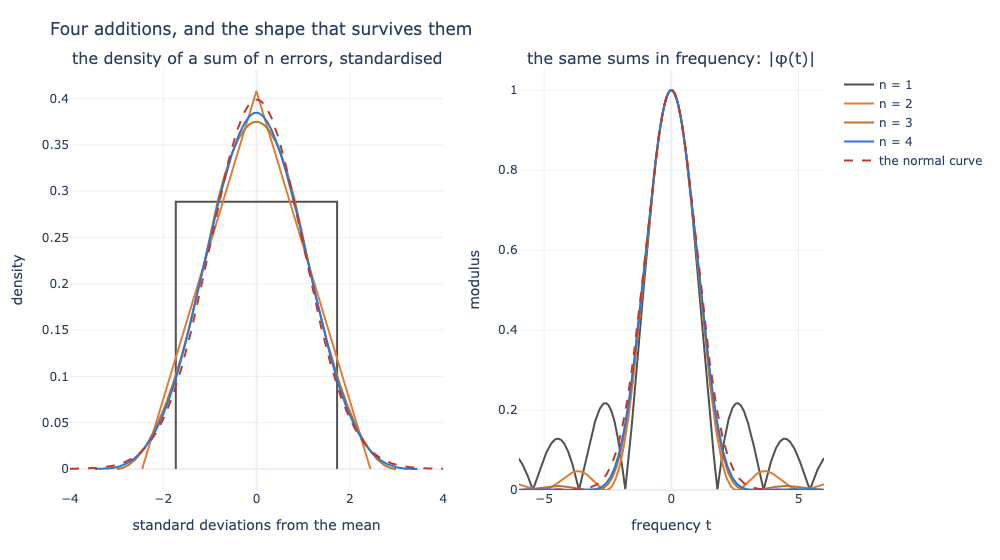

In [120]:
figure_convolution()

**Goal.** Build a square wave from sines: the time and frequency descriptions of one signal.

**Why.** The slide's illustration decomposes a square wave into sinusoids and shows their amplitudes along a frequency axis (Oppenheim & Schafer, 2010, ch. 8).

**What the code does.** Sums the square wave's Fourier series, (4/π) Σ sin((2k − 1)t)/(2k − 1), with 1, 3 and 15 terms, and draws the amplitudes 4/(π(2k − 1)) as a spectrum.

**So what.** Few terms already give the shape; the ripple at the jumps never disappears (Gibbs), which is spectral leakage's cousin: a sharp edge needs every rhythm.

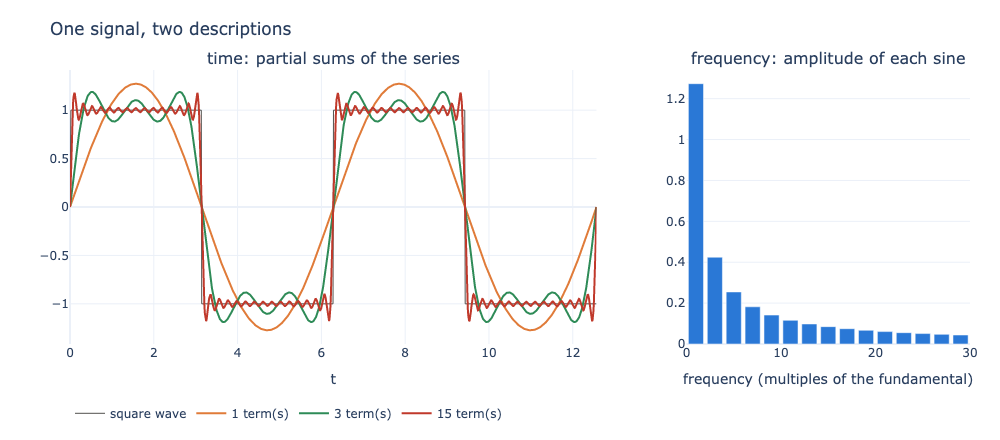

In [121]:
t_grid = np.linspace(0, 4 * np.pi, 1200)
square = np.sign(np.sin(t_grid))
fig = make_subplots(rows=1, cols=2, column_widths=[0.65, 0.35],
                    subplot_titles=("time: partial sums of the series", "frequency: amplitude of each sine"))
fig.add_scatter(x=t_grid, y=square, mode="lines", line=dict(color=GREY, width=1), name="square wave", row=1, col=1)
for terms, colour in ((1, ORANGE), (3, GREEN), (15, RED)):
    partial = sum(4 / np.pi * np.sin((2 * m - 1) * t_grid) / (2 * m - 1) for m in range(1, terms + 1))
    fig.add_scatter(x=t_grid, y=partial, mode="lines", line=dict(color=colour, width=2),
                    name=f"{terms} term(s)", row=1, col=1)
harmonics = np.arange(1, 16)
fig.add_bar(x=2 * harmonics - 1, y=4 / (np.pi * (2 * harmonics - 1)), marker_color=BLUE,
            showlegend=False, row=1, col=2)
fig.update_xaxes(title_text="t", row=1, col=1)
fig.update_xaxes(title_text="frequency (multiples of the fundamental)", row=1, col=2)
fig.update_layout(title="One signal, two descriptions", legend=dict(orientation="h", y=-0.2))
show(fig, "square_wave", height=440)

**Goal.** Rebuild one lap of the shuttle's route from its Fourier terms.

**Why.** The slide's animation draws a shape with rotating circles (epicycles): each circle is one term of the transform of a closed curve. The route is a closed curve, so its own lap can be drawn the same way.

**What the code does.** Takes the first lap of the loop on 23 January — the day the shuttle drove the loop; on 22 January it mostly shuttled along the southern road — from the first moving reading on the loop's north edge until the vehicle is back within 2 m of it after at least 150 m; resamples it to 256 points equally spaced along the path, writes each point as east + i·north, applies `numpy.fft.fft`, and rebuilds the lap from the 3, 5, 11 and 21 lowest-frequency terms; the circles of the first four rotating terms are drawn, chained from the lap's centroid, at the lap's start.

**So what.** A handful of terms already gives the loop's shape; the corners need more, as the square wave's jumps did.

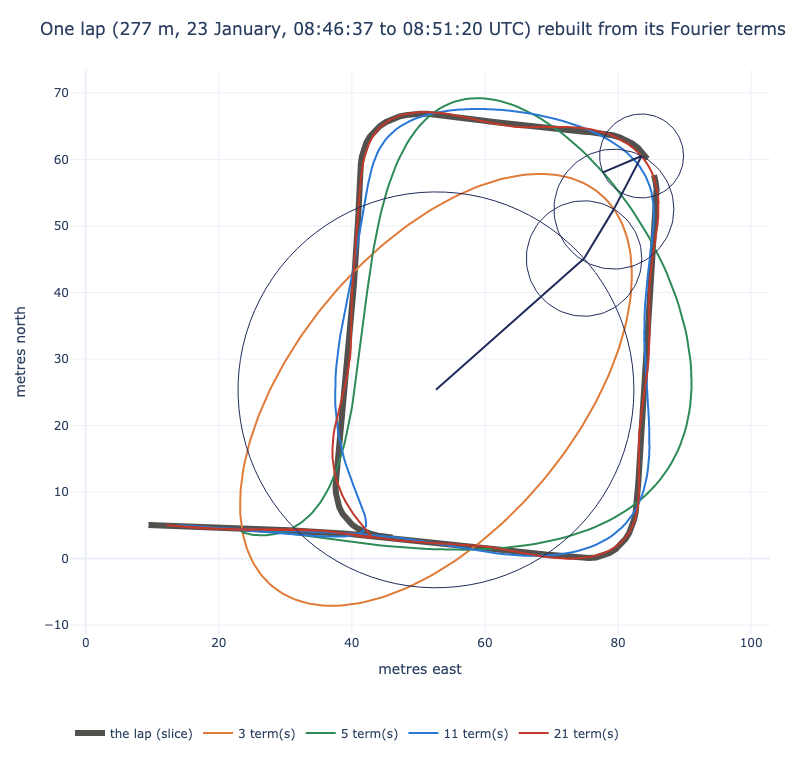

In [122]:
lap_day = in_time[in_time["_t"].dt.date.astype(str) == "2020-01-23"].reset_index(drop=True)
east_all, north_all = to_metres(lap_day["lat"], lap_day["lon"])
path = np.r_[0, np.cumsum(np.hypot(np.diff(east_all), np.diff(north_all)))]
begin = int(np.where((north_all > 60) & (lap_day["speed"].abs().to_numpy() > 0.5))[0][0])
after = np.arange(begin, len(lap_day))
back = after[(path[after] - path[begin] > 150)
             & (np.hypot(east_all[after] - east_all[begin], north_all[after] - north_all[begin]) < 2.0)]
finish = int(back[0])
arc = path[begin:finish + 1] - path[begin]
even = np.linspace(0, arc[-1], 256, endpoint=False)
z = np.interp(even, arc, east_all[begin:finish + 1]) + 1j * np.interp(even, arc, north_all[begin:finish + 1])
Z = np.fft.fft(z) / len(z)
frequencies = np.fft.fftfreq(len(z), d=1 / len(z)).astype(int)

def rebuild(terms):
    keep = np.argsort(np.abs(frequencies))[:terms]
    phase = np.exp(2j * np.pi * np.outer(np.arange(len(z)), frequencies[keep]) / len(z))
    return phase @ Z[keep]

fig = go.Figure()
fig.add_scatter(x=z.real, y=z.imag, mode="lines", line=dict(color=GREY, width=6), name="the lap (slice)")
for terms, colour in ((3, ORANGE), (5, GREEN), (11, BLUE), (21, RED)):
    curve = rebuild(terms)
    fig.add_scatter(x=np.r_[curve.real, curve.real[0]], y=np.r_[curve.imag, curve.imag[0]],
                    mode="lines", line=dict(color=colour, width=2), name=f"{terms} term(s)")
order = np.argsort(np.abs(frequencies))[1:5]          # the four rotating terms after the centre
centre = Z[0]                                         # the lap's centroid: the fixed pivot
for term in order:
    radius = abs(Z[term])
    angle = np.linspace(0, 2 * np.pi, 100)
    fig.add_scatter(x=centre.real + radius * np.cos(angle), y=centre.imag + radius * np.sin(angle),
                    mode="lines", line=dict(color=NAVY, width=1), showlegend=False)
    tip = centre + Z[term]
    fig.add_scatter(x=[centre.real, tip.real], y=[centre.imag, tip.imag], mode="lines",
                    line=dict(color=NAVY, width=2), showlegend=False)
    centre = tip
fig.update_layout(title=f"One lap ({arc[-1]:.0f} m, 23 January, {lap_day['_t'][begin]:%H:%M:%S} to "
                        f"{lap_day['_t'][finish]:%H:%M:%S} UTC) rebuilt from its Fourier terms",
                  xaxis_title="metres east", yaxis_title="metres north", yaxis_scaleanchor="x",
                  legend=dict(orientation="h", y=-0.15))
show(fig, "route_epicycles", width=800, height=760)

**Goal.** Compute the spectrum of the shuttle's speed, window by window, over a day.

**Why.** The slide shows a waterfall of spectra from an acoustic sensor, where the structure is in rhythm. The slice's speed can be put through the same machinery to see whether it has any.

**What the code does.** Puts 22 January's speed on a regular 0.5-second grid (mean per half-second, short gaps interpolated), cuts it into five-minute windows with at least 90 per cent of their readings (skipping windows at rest, whose spectrum is empty), and computes each window's periodogram with `scipy.signal.periodogram` (a Hann window against spectral leakage); draws them as a spectrogram.

**So what.** The power sits below a few hundredths of a cycle per second — the rhythm of stops and laps — and nothing lives near the one-cycle-per-second ceiling. The deck's verdict, measured: this series does not need a spectrum.

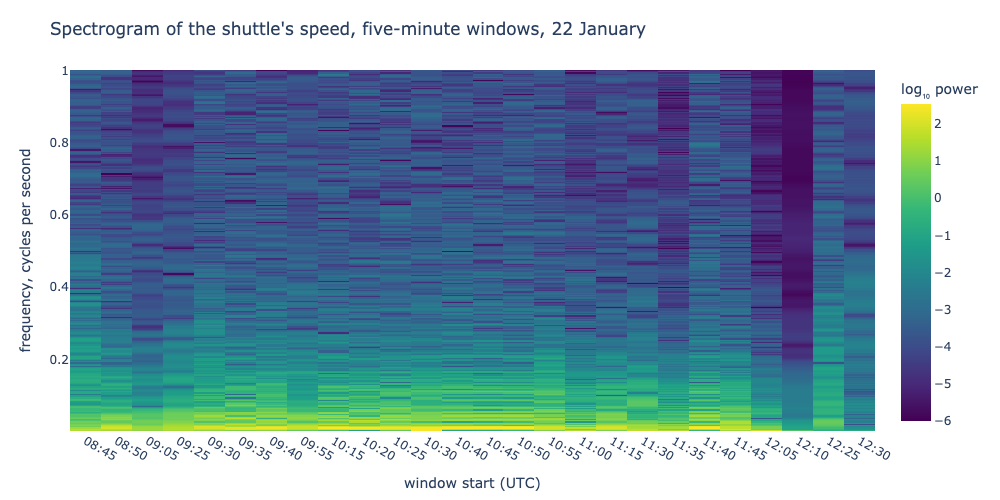

  26 windows; share of the power at or below 0.05 Hz: 0.955


In [123]:
grid = slice_day_one.set_index("_t")["speed"].resample("500ms").mean()
rows, starts = [], []
for start, part in grid.groupby(grid.index.floor("5min")):
    if part.notna().mean() >= 0.9 and len(part) == 600 and part.std() > 0.01:
        frequencies, power = signal.periodogram(part.interpolate(limit_direction="both").to_numpy(),
                                                fs=2.0, window="hann", detrend="constant")
        rows.append(power)
        starts.append(start)
spectra = np.array(rows)
fig = go.Figure(go.Heatmap(z=np.log10(spectra.T[1:] + 1e-6), x=[s.strftime("%H:%M") for s in starts],
                           y=frequencies[1:], colorscale="Viridis",
                           colorbar=dict(title="log₁₀ power")))
fig.update_layout(title="Spectrogram of the shuttle's speed, five-minute windows, 22 January",
                  xaxis_title="window start (UTC)", yaxis_title="frequency, cycles per second")
show(fig, "speed_spectrogram", height=500)
share_low = spectra[:, (frequencies > 0) & (frequencies <= 0.05)].sum() / spectra[:, frequencies > 0].sum()
print(f"  {len(starts)} windows; share of the power at or below 0.05 Hz: {share_low:.3f}")

### The split that keeps time, and the price of a join

*Slides: "Definition — a split by time, never at random for timeseries", "Definition — a nearest match within a tolerance (fuzzy time-based join)" and "Widening the tolerance thirtyfold buys few rows and costs accuracy on all of them".*

**Goal.** Write the split by time, and define it as the solution does.

**Why.** Consecutive readings correlate at 0.9967, so a random split scores the model on near-copies of its training rows (Roberts et al., 2017; Bergmeir & Benítez, 2012; Huyen, 2022, ch. 4, "Data Leakage"). Sorting is part of the operation.

**What the code does.** Writes the two sets as sympy condition sets on the time t, with t_c the time of the first test row: the row ⌊fn⌋ + 1 in sorted order, t↑ denoting the sorted times. Then writes the condition under which a cut *by row* gives those sets: the last training row must be strictly earlier than the first test row.

**So what.** A cut by row is the definition's split only when no instant straddles it. The next cells show that on the lab data one does.

In [124]:
t_, t_c = sp.Symbol("t", real=True), sp.Symbol("t_c", real=True)
f_, n_rows = sp.Symbol("f", positive=True), sp.Symbol("n", positive=True, integer=True)
sorted_t = sp.IndexedBase(r"t^{\uparrow}")
formula(sp.Eq(sp.Symbol(r"\mathrm{train}"), sp.ConditionSet(t_, sp.Lt(t_, t_c), sp.Reals), evaluate=False),
        sp.Eq(sp.Symbol(r"\mathrm{test}"), sp.ConditionSet(t_, sp.Ge(t_, t_c), sp.Reals), evaluate=False),
        sp.Eq(t_c, sorted_t[sp.floor(f_ * n_rows) + 1], evaluate=False))
formula(sp.Symbol(r"\text{a cut by row gives these sets only if}"),
        sp.StrictLessThan(sorted_t[sp.floor(f_ * n_rows)], sorted_t[sp.floor(f_ * n_rows) + 1], evaluate=False))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define split_by_time as the Lab 4 solution writes it.

**Why.** It is the second deliverable of Laboratory 4.

**What the code does.** Copies split_by_time from solutions/lab_04.py: sort by timestamp_utc, then cut at row `int(len × fraction)`.

**So what.** The next cell tests it against the definition.

In [125]:
# Source: Module 2/exercises/solutions/lab_04.py — split_by_time, verbatim
# References: (Roberts et al., 2017; Bergmeir & Benítez, 2012)

import sys
import pathlib
import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go


def split_by_time(frame, train_fraction: float = 0.7):
    """Sort by time, then cut. Never shuffle.

    Module 1 measured the reason rather than asserting it: consecutive readings
    on this telemetry correlate at about 0.997. A random split therefore puts a
    reading in the training set and its own neighbour -- very nearly the same
    number -- in the test set, and the model is scored on a paraphrase of what it
    was taught (Roberts et al., 2017; Bergmeir & Benítez, 2012).

    A time split costs you something real: the test set is a different part of
    the day, possibly a different vehicle state, and scores are lower. Those
    lower scores are the honest ones. The cut is at ⌊fraction × rows⌋ after
    sorting by timestamp_utc, so the last training time is at or before the
    first test time and no row is in both.
    """
    ordered = frame.sort_values("timestamp_utc").reset_index(drop=True)
    cut = int(len(ordered) * train_fraction)
    return ordered.iloc[:cut].copy(), ordered.iloc[cut:].copy()

**Goal.** Test `split_by_time` against the definition on the first generated day.

**Why.** Twelve phones report at every instant of the generated day, so every timestamp is shared by twelve rows, and a cut by row can fall between two rows with the same time. The definition says train = {t < t_c}; the lab's check asks only that the last training time be at or before the first test time, which a straddled instant satisfies.

**What the code does.** Splits the shuffled day with `split_by_time(…, 0.7)` as the solution's demonstration does; prints the last training time and the first test time; counts the rows stamped t_c on each side; and evaluates the row-cut condition written above with sympy on the actual times.

**So what.** 7,559 rows train, ending at 09:10:24.597, and 3,241 test, starting at 09:10:24.597: eleven readings of the instant t_c are in the training set and one in the test set. The lab's check passes (≤ holds) and the definition does not (< fails). The cause is one line of arithmetic: 0.7 × 10,800 is 7,559.999… in floating point, so `int()` gives 7,559 instead of the 7,560 = 630 × 12 that would have fallen between instants. The lab is delivered and is not changed; the fix, where it matters, is the one `assemble` makes below — cut at an instant, not at a row.

In [126]:
shuffled_day = phones.sample(frac=1.0, random_state=20200122).reset_index(drop=True)
train_part, test_part = split_by_time(shuffled_day, 0.7)
last_train, first_test = train_part["timestamp_utc"].max(), test_part["timestamp_utc"].min()
print(f"train {len(train_part):,} rows, last time {last_train:%H:%M:%S.%f}; "
      f"test {len(test_part):,} rows, first time {first_test:%H:%M:%S.%f}")
print(f"rows stamped t_c = {first_test:%H:%M:%S.%f}: {int((train_part['timestamp_utc'] == first_test).sum())} "
      f"in train, {int((test_part['timestamp_utc'] == first_test).sum())} in test")
print("phones reporting at every instant:", sorted(phones.groupby("timestamp_utc").size().unique()))
row_cut_condition = sp.StrictLessThan(sorted_t[sp.floor(f_ * n_rows)], sorted_t[sp.floor(f_ * n_rows) + 1])
stamps_sorted = np.sort(phones["timestamp_utc"].astype("int64").to_numpy())
row_cut = int(len(stamps_sorted) * 0.7)                        # the lab's own arithmetic
print(f"0.7 × {len(phones):,} = {0.7 * len(phones)!r} → cut after row {row_cut:,}; "
      f"t↑[{row_cut}] < t↑[{row_cut + 1}]:",
      row_cut_condition.subs({sorted_t[sp.floor(f_ * n_rows)]: int(stamps_sorted[row_cut - 1]),
                              sorted_t[sp.floor(f_ * n_rows) + 1]: int(stamps_sorted[row_cut])}))
print("the lab's check, last training time ≤ first test time:", bool(last_train <= first_test),
      "  the definition, last training time < t_c:", bool(last_train < first_test))
beside("split by time on the first generated day",
       f"last training time = first test time = {first_test:%H:%M:%S.%f}; "
       f"{int((train_part['timestamp_utc'] == first_test).sum())} rows of that instant train, "
       f"{int((test_part['timestamp_utc'] == first_test).sum())} test",
       "train = rows before the cut instant, test = rows after it (slide 81)",
       "split_by_time cuts at row int(0.7 × 10,800) = 7,559 (floating point), inside a group of "
       "twelve simultaneous rows; the lab's check tests ≤, so it passes. Lab 3's demonstration "
       "cuts the same way")

train 7,559 rows, last time 09:10:24.597000; test 3,241 rows, first time 09:10:24.597000
rows stamped t_c = 09:10:24.597000: 11 in train, 1 in test
phones reporting at every instant: [np.int64(12)]
0.7 × 10,800 = 7559.999999999999 → cut after row 7,559; t↑[7559] < t↑[7560]: False
the lab's check, last training time ≤ first test time: True   the definition, last training time < t_c: False
  split by time on the first generated day: computed here last training time = first test time = 09:10:24.597000; 11 rows of that instant train, 1 test; stated train = rows before the cut instant, test = rows after it (slide 81) — split_by_time cuts at row int(0.7 × 10,800) = 7,559 (floating point), inside a group of twelve simultaneous rows; the lab's check tests ≤, so it passes. Lab 3's demonstration cuts the same way


**Goal.** Write the nearest match within a tolerance, and define the function that measures it.

**Why.** Each phone row is paired with the vehicle reading nearest in time, if within τ seconds; widening τ buys matches and spends accuracy. The matched share must never fall as τ grows. The Lab 4 stub cites McKinney (2022) for this definition; the book's § 8.2 covers joins on equal keys (`pandas.merge`), not the nearest-in-time join the lab uses (`pandas.merge_asof`, documented by pandas itself), so no source is cited for it here.

**What the code does.** Writes the match as a sympy Piecewise and the share as a sum of indicators over the n_p phone rows; copies `join_growth` from `solutions/lab_04.py` (built on `pandas.merge_asof`).

**So what.** The next figures measure the trade: the rows it buys, and the accuracy it spends.

In [127]:
t_b, tau = sp.Symbol("t_b", real=True), sp.Symbol(r"\tau", positive=True)
p_ = sp.Symbol("p", positive=True, integer=True)
t_phone = sp.IndexedBase("t")
gap_p = sp.Abs(t_b - t_phone[p_])
nearest = sp.Function(r"\min_b")(gap_p)
match_rule = sp.Piecewise((sp.Function(r"\operatorname*{arg\,min}_b")(gap_p), sp.Le(nearest, tau)),
                     (sp.Symbol(r"\text{none}"), True))
n_p = sp.Symbol("n_p", positive=True, integer=True)
matched_share = sp.Sum(sp.Piecewise((1, sp.Le(nearest, tau)), (0, True)), (p_, 1, n_p)) / n_p
formula(sp.Eq(sp.Function(r"\mathrm{match}")(p_), match_rule, evaluate=False))
formula(sp.Eq(sp.Symbol(r"\text{matched share}"), matched_share, evaluate=False))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define join_growth as the Lab 4 solution writes it.

**Why.** It is the third deliverable of Laboratory 4.

**What the code does.** Copies join_growth from solutions/lab_04.py: both clocks forced to one resolution, then pandas.merge_asof with direction "nearest" at each tolerance.

**So what.** The next cells measure the trade with it.

In [128]:
# Source: Module 2/exercises/solutions/lab_04.py — join_growth, verbatim

import sys
import pathlib
import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go


def join_growth(phones, bus, tolerances=TOLERANCES) -> dict:
    """What each tolerance buys, measured rather than chosen.

    Widening the tolerance always buys matches and always spends accuracy: the
    vehicle reading you matched is further away in time, so the speed you
    attached to a phone row is less and less the speed at that moment.

    Nearest match within a tolerance: each phone row is paired with the vehicle
    reading closest to it in time, if that reading is within τ seconds, and the
    matched share is the fraction of phone rows that found one. On the archive
    this runs from 95.3 per cent matched at one second to 97.4 at thirty: 2.1
    percentage points for thirty times the tolerance, which is a bad trade, and
    the only way to know that is to measure it.
    """
    # merge_asof refuses to join two time columns of different resolution, and
    # pandas infers the resolution from the text it parsed: the vehicle file has
    # milliseconds and lands on microseconds, the phones on nanoseconds. Force
    # both to the same unit before joining -- a small nuisance, and a real one.
    stamp = "datetime64[ns, UTC]"

    left = phones.copy()
    left["_t"] = pd.to_datetime(left["timestamp_utc"], utc=True, errors="coerce").astype(stamp)
    left = left.dropna(subset=["_t"]).sort_values("_t")

    right = bus.copy()
    right["_t"] = pd.to_datetime(right["utc_time"], utc=True).astype(stamp)
    right = right[["_t", "speed"]].rename(columns={"speed": "bus_speed"}).sort_values("_t")

    growth = {}
    for seconds in tolerances:
        merged = pd.merge_asof(
            left[["_t"]], right, on="_t", direction="nearest",
            tolerance=pd.Timedelta(seconds=seconds))
        growth[seconds] = round(float(merged["bus_speed"].notna().mean()) * 100, 1)
    return growth

**Goal.** Measure what widening the tolerance buys, and draw it with the deck's function.

**Why.** The slide measures the archive: 95.3 per cent of labelled phone rows matched at one second, 97.4 at thirty — 2.1 points for thirty times the tolerance. Against the shipped vehicle, which reports twice a second, every generated phone row matches at one second, so the lab's own recipe thins the vehicle to one reading every 30 seconds to have a trade to measure.

**What the code does.** Runs `join_growth` against the shipped vehicle and against the thinned one; copies `figure_join_cost()` from `make_figs.py` verbatim and feeds it the thinned rates; prints the archive's beside.

**So what.** The share never falls as the tolerance widens. The archive's trade (2.1 points) and the lab's (from under 10 to 100 per cent) differ because the lab's vehicle is thinned on purpose; the method is the one on the slide. The thinned curve shows the opposite of the slide's "buys few rows", and says nothing about accuracy; the cell after it measures both.

In [129]:
# Source: Module 2/slides/make_figs.py — figure_join_cost, verbatim

import json
import sys
from pathlib import Path
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def figure_join_cost(facts) -> dict:
    """What widening the tolerance buys — archive aggregates.

    The title used to say "four points" and the measured rates say 95.3 at one
    second and 97.4 at thirty, which is 2.1. So the gain is subtracted from the
    measurements here and returned for the slide, and neither the caption nor the
    bullet can drift away from the data again.
    """
    rates = facts["join_match_rate"]["value"]
    seconds = sorted(int(k) for k in rates)
    shares = [rates[str(s)] for s in seconds]
    widest, narrowest = seconds[-1], seconds[0]
    gain = round(shares[-1] - shares[0], 1)

    fig = go.Figure(go.Scatter(x=seconds, y=shares, mode="lines+markers+text",
                               line=dict(color=BLUE), marker=dict(size=10),
                               text=[f"{y}" for y in shares], textposition="top center",
                               showlegend=False))
    fig.update_xaxes(type="log", tickvals=seconds, ticktext=[str(s) for s in seconds],
                     title_text="how far in time a match may reach (seconds)")
    fig.update_yaxes(title_text="labelled phone rows matched (per cent)",
                     range=[min(shares) - 1.5, 100])
    fig.update_layout(title=f"{widest // narrowest} times the tolerance buys "
                            f"{gain} percentage points")
    write(fig, "join_cost")
    return {"points": gain, "widest_seconds": widest, "narrowest_seconds": narrowest,
            "tolerance_multiple": widest // narrowest}

**Goal.** Measure the join both ways and draw the thinned vehicle's trade.

**Why.** The shipped vehicle gives a flat curve; the thinned one gives a trade to see.

**What the code does.** Runs join_growth() twice, feeds figure_join_cost() the thinned shares, checks that the share never falls, and prints the archive's shares beside.

**So what.** The method is the slide's; the numbers are the lab data's.

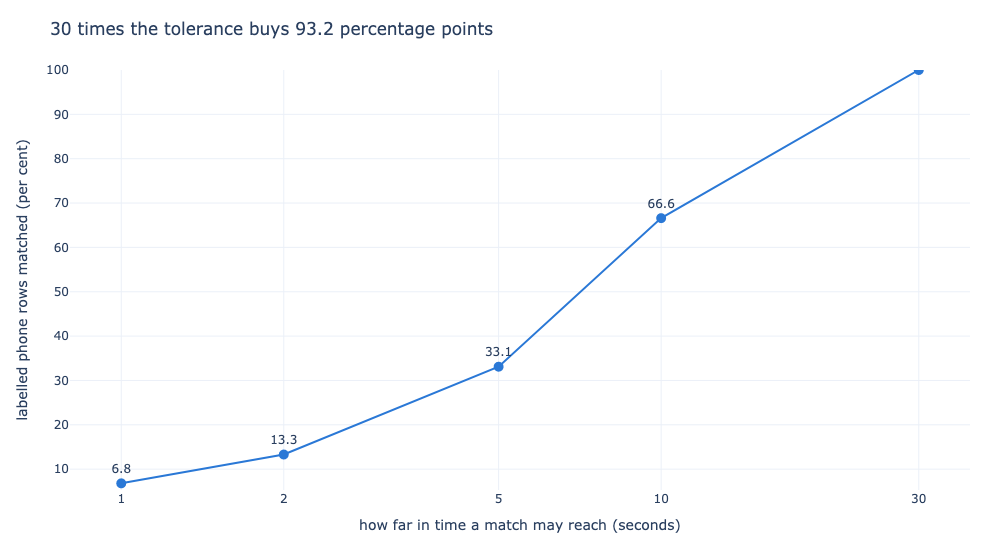

  shipped vehicle, per cent matched: {1: 100.0, 2: 100.0, 5: 100.0, 10: 100.0, 30: 100.0}
  vehicle thinned to one reading per 30 s: {1: 6.8, 2: 13.3, 5: 33.1, 10: 66.6, 30: 100.0}
  never falls as the tolerance widens: True
  matched share from 1 s to 30 s, per cent: computed here 6.8 to 100.0 (thinned vehicle); stated 95.3 to 97.4 (archive) — the archive's phones and vehicle were recorded independently; the lab's vehicle is thinned to make a trade measurable
  points bought by thirty times the tolerance: computed here 93.2; stated 2.1 (archive) — as above


In [130]:
dense = join_growth(phones, bus, TOLERANCES)
thinned = join_growth(phones, in_time.iloc[::60].drop(columns="_t"), TOLERANCES)
gain = figure_join_cost({"join_match_rate": {"value": {str(s): thinned[s] for s in TOLERANCES}}})
print("  shipped vehicle, per cent matched:", dense)
print("  vehicle thinned to one reading per 30 s:", thinned)
print("  never falls as the tolerance widens:",
      all(a <= b for a, b in zip(list(thinned.values()), list(thinned.values())[1:])))
beside("matched share from 1 s to 30 s, per cent", f"{thinned[1]} to {thinned[30]} (thinned vehicle)",
       f"{archive('join_match_rate')['1']} to {archive('join_match_rate')['30']} (archive)",
       "the archive's phones and vehicle were recorded independently; the lab's vehicle is thinned "
       "to make a trade measurable")
beside("points bought by thirty times the tolerance", gain["points"],
       f"{archive('join_match_gain')['points']} (archive)", "as above")

**Goal.** Measure what widening the tolerance costs in accuracy, and find a curve on the lab data that saturates as the archive's does.

**Why.** The slide's claim has two halves: thirty times the tolerance buys few rows, and it costs accuracy. The thinned vehicle cannot show the first half — thinning it evenly puts every phone row within 15 seconds of a kept reading, so the share climbs to 100 per cent — and the share alone cannot show the second. Two measurements can. On the thinned vehicle, the shipped vehicle still knows the speed at every phone instant, so the error of each attached speed can be measured. And the shipped vehicle file has real outages — gaps of tens of seconds to a quarter of an hour when it did not report — so a clock ticking at the phones' rate through each service day, matched against the unthinned vehicle, shows how a real stream's share grows with the tolerance.

**What the code does.** For the thinned vehicle and each tolerance: the share of phone rows matched, the mean and largest |t_bus − t_phone| over the matched rows, and the mean |attached speed − speed at the phone's instant|, the latter read from the shipped vehicle (every phone instant has a shipped reading within half a second). It checks the shares against `join_growth`'s, and whether a row matched at 1 s keeps the same partner at 30 s. For the service-day clock (every 0.993 s from each day's first to its last vehicle reading): the share matched and |t_bus − t_phone|. Finally the price of a partner Δ seconds away: the mean |v(t + Δ) − v(t)| of the shipped vehicle's own speed, over every reading that has a partner Δ seconds later.

**So what.** Both halves of the slide hold on the lab data once they are measured. Against the real outages the curve saturates as the archive's does: about 91 per cent of the clock matches at 1 second and under 94 at 30 — under three points for thirty times the tolerance. And a partner up to 30 seconds away carries a speed that differs from the moment described by 0.75 m/s on average, against 0.06 at 1 second. One precision on the slide's wording: a nearest match never changes the partner of a row that was already matched, so widening does not make those rows worse; what it spends is the guarantee — at 30 seconds, any matched row may be 30 seconds off, and the table no longer says which.

thinned vehicle, one reading per 30 s:
               matched %  mean |Δt| (s)  largest |Δt| (s)  mean speed error (m/s)
tolerance (s)                                                                    
1                    6.8           0.51              1.00                   0.005
2                   13.3           1.00              1.99                   0.013
5                   33.1           2.50              4.99                   0.047
10                  66.6           5.02              9.99                   0.085
30                 100.0           7.53             14.97                   0.113
  rows matched at 1 s whose partner is the same at 30 s: 732 of 732

service-day clock, 26,793 instants against the shipped vehicle; the vehicle's gaps longer than 1 s: 20, longer than 30 s: 12, longest 876 s:
               matched %  mean |Δt| (s)  matched rows more than 1 s off (%)
tolerance (s)                                                              
1                   90.8 

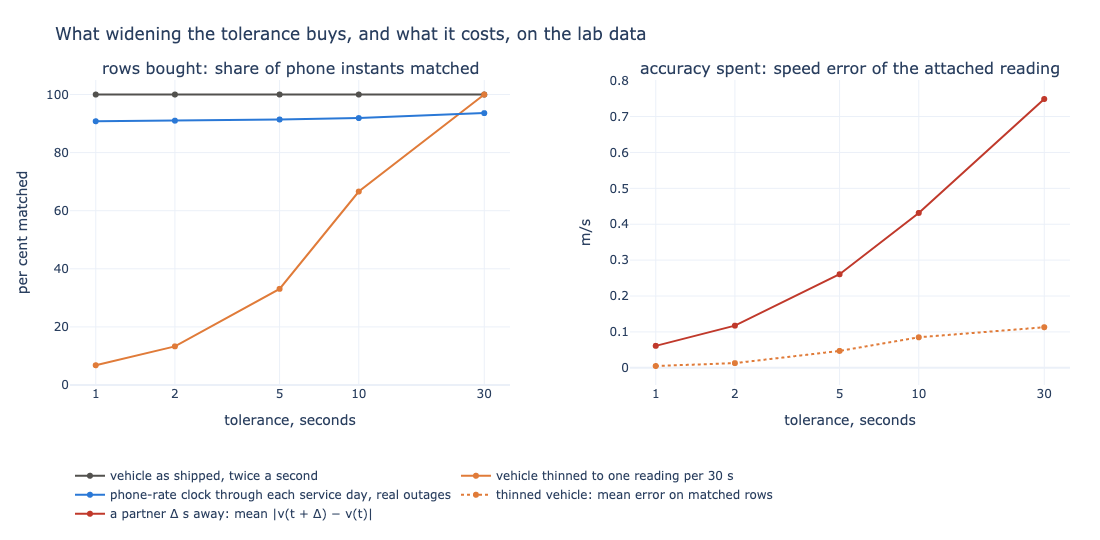

  matched share from 1 s to 30 s against a stream with real outages, per cent: computed here 90.8 to 93.6 (phone-rate clock, shipped vehicle); stated 95.3 to 97.4 (archive) — the clock is synthetic (the phones' rate, both service days); the outages are the vehicle's own


In [131]:
stamp = "datetime64[ns, UTC]"
vehicle_rows = (in_time[["_t", "speed"]].assign(_t=lambda frame: frame["_t"].astype(stamp))
                  .assign(vehicle_time=lambda frame: frame["_t"]))


def nearest_vehicle(instants, vehicle, tolerance_s):
    """Each instant's nearest vehicle reading within the tolerance (pandas.merge_asof)."""
    left = pd.DataFrame({"_t": pd.to_datetime(pd.Series(instants), utc=True).astype(stamp)}).sort_values("_t")
    return pd.merge_asof(left, vehicle.sort_values("_t"), on="_t", direction="nearest",
                         tolerance=pd.Timedelta(seconds=tolerance_s)).reset_index(drop=True)


at_the_moment = nearest_vehicle(phones["timestamp_utc"], vehicle_rows, 0.5)["speed"]
assert at_the_moment.notna().all()
thinned_rows = vehicle_rows.iloc[::60]
cost, partners = [], {}
for tolerance in TOLERANCES:
    matched = nearest_vehicle(phones["timestamp_utc"], thinned_rows, tolerance)
    found = matched["speed"].notna()
    apart = (matched["vehicle_time"] - matched["_t"]).dt.total_seconds().abs()
    partners[tolerance] = matched["vehicle_time"]
    cost.append({"tolerance (s)": tolerance, "matched %": round(100 * float(found.mean()), 1),
                 "mean |Δt| (s)": round(float(apart[found].mean()), 2),
                 "largest |Δt| (s)": round(float(apart[found].max()), 2),
                 "mean speed error (m/s)": round(float((matched["speed"] - at_the_moment)[found].abs().mean()), 3)})
cost = pd.DataFrame(cost).set_index("tolerance (s)")
assert cost["matched %"].to_dict() == {s: thinned[s] for s in TOLERANCES}, "differs from join_growth"
kept = partners[1].notna()
print("thinned vehicle, one reading per 30 s:")
print(cost.to_string())
print(f"  rows matched at 1 s whose partner is the same at 30 s: "
      f"{int((partners[1][kept] == partners[30][kept]).sum())} of {int(kept.sum())}")

service_clock = pd.DatetimeIndex(np.concatenate([
    pd.date_range(part["_t"].min(), part["_t"].max(), freq="993ms").tz_convert("UTC").tz_localize(None).values
    for _, part in in_time.groupby(in_time["_t"].dt.date)])).tz_localize("UTC")
outages = in_time.groupby(in_time["_t"].dt.date)["_t"].diff().dt.total_seconds()
real = []
for tolerance in TOLERANCES:
    matched = nearest_vehicle(service_clock, vehicle_rows, tolerance)
    found = matched["speed"].notna()
    apart = (matched["vehicle_time"] - matched["_t"]).dt.total_seconds().abs()
    real.append({"tolerance (s)": tolerance, "matched %": round(100 * float(found.mean()), 1),
                 "mean |Δt| (s)": round(float(apart[found].mean()), 3),
                 "matched rows more than 1 s off (%)": round(100 * float((apart[found] > 1).mean()), 2)})
real = pd.DataFrame(real).set_index("tolerance (s)")
print(f"\nservice-day clock, {len(service_clock):,} instants against the shipped vehicle; the vehicle's gaps "
      f"longer than 1 s: {int((outages > 1).sum())}, longer than 30 s: {int((outages > 30).sum())}, "
      f"longest {outages.max():.0f} s:")
print(real.to_string())

price = {}
later = vehicle_rows[["_t", "speed"]].rename(columns={"speed": "speed_later"})
for delta in TOLERANCES:
    ahead = vehicle_rows[["_t", "speed"]].assign(_t=lambda frame: frame["_t"] + pd.Timedelta(seconds=delta))
    paired = pd.merge_asof(ahead.sort_values("_t"), later.sort_values("_t"), on="_t", direction="nearest",
                           tolerance=pd.Timedelta(milliseconds=250)).dropna()
    price[delta] = float((paired["speed_later"] - paired["speed"]).abs().mean())
print("\nmean |v(t + Δ) − v(t)| of the vehicle's own speed, m/s:",
      {delta: round(value, 3) for delta, value in price.items()})

fig = make_subplots(rows=1, cols=2, horizontal_spacing=0.12, subplot_titles=(
    "rows bought: share of phone instants matched", "accuracy spent: speed error of the attached reading"))
for label, shares, colour in (("vehicle as shipped, twice a second", dense, GREY),
                              ("vehicle thinned to one reading per 30 s", thinned, ORANGE),
                              ("phone-rate clock through each service day, real outages", real["matched %"].to_dict(), BLUE)):
    fig.add_scatter(x=list(TOLERANCES), y=[shares[s] for s in TOLERANCES], mode="lines+markers",
                    line=dict(color=colour), name=label, row=1, col=1)
fig.add_scatter(x=list(TOLERANCES), y=cost["mean speed error (m/s)"], mode="lines+markers",
                line=dict(color=ORANGE, dash="dot"), name="thinned vehicle: mean error on matched rows",
                row=1, col=2)
fig.add_scatter(x=list(TOLERANCES), y=[price[s] for s in TOLERANCES], mode="lines+markers",
                line=dict(color=RED), name="a partner Δ s away: mean |v(t + Δ) − v(t)|", row=1, col=2)
fig.update_xaxes(type="log", tickvals=list(TOLERANCES), title_text="tolerance, seconds")
fig.update_yaxes(title_text="per cent matched", range=[0, 105], row=1, col=1)
fig.update_yaxes(title_text="m/s", row=1, col=2)
fig.update_layout(title="What widening the tolerance buys, and what it costs, on the lab data",
                  legend=dict(orientation="h", y=-0.25), margin=dict(l=70, r=30, t=80, b=150))
show(fig, "join_accuracy", width=1100, height=540)
beside("matched share from 1 s to 30 s against a stream with real outages, per cent",
       f"{real.loc[1, 'matched %']} to {real.loc[30, 'matched %']} (phone-rate clock, shipped vehicle)",
       f"{archive('join_match_rate')['1']} to {archive('join_match_rate')['30']} (archive)",
       "the clock is synthetic (the phones' rate, both service days); the outages are the vehicle's own")

### The table this module hands on

*Slides: "Definition — the table this module hands to the next steps" and "Build dataset".* The pipeline slide's point — fit the transform and the model as one object, so that a live request is prepared as the training rows were — is the hand-off's manifest.

**Goal.** Write the hand-off's clauses.

**Why.** One row per phone per window; a mask beside every filled column and no other; the split recorded as an instant at the start of a window, so no window straddles it; the transform and the ledger stored unchanged (Huyen, 2022; Kuhn & Johnson, 2019, ch. 8).

**What the code does.** Writes the clauses in sympy — the key's count equal to the row count, the mask as a Piecewise, the cut instant as the window of row ⌊fn⌋ + 1 in (window, phone) order, and train and test as condition sets on the window; copies `assemble` from `solutions/lab_04.py`.

**So what.** The next cell builds the table and checks each clause.

In [132]:
n_rows, f_ = sp.Symbol("n", positive=True, integer=True), sp.Symbol("f", positive=True)
w_, t_c = sp.Symbol("w", real=True), sp.Symbol("t_c", real=True)
ordered_windows = sp.IndexedBase(r"\mathrm{window}")
formula(sp.Eq(sp.Symbol(r"|\{(\mathrm{phone\_id}, \mathrm{window})\}|"), n_rows, evaluate=False),
        sp.Eq(sp.Symbol(r"\mathrm{mask}_c"),
              sp.Piecewise((1, sp.Symbol(r"x_c\ \text{absent}")), (0, True)), evaluate=False),
        sp.Symbol(r"\text{beside every filled } c"))
formula(sp.Eq(t_c, ordered_windows[sp.floor(f_ * n_rows) + 1], evaluate=False),
        sp.Eq(sp.Symbol(r"\mathrm{train}"), sp.ConditionSet(w_, sp.Lt(w_, t_c), sp.Reals), evaluate=False),
        sp.Eq(sp.Symbol(r"\mathrm{test}"), sp.ConditionSet(w_, sp.Ge(w_, t_c), sp.Reals), evaluate=False))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

**Goal.** Define assemble as the Lab 4 solution writes it.

**Why.** It is the fourth deliverable of Laboratory 4, and the object Modules 3, 4 and 5 open.

**What the code does.** Copies assemble from solutions/lab_04.py: fill and scale with the stored constants, a mask beside what was filled, the cut moved to the start of a window, and the manifest.

**So what.** The next cell builds the hand-off with it.

In [133]:
# Source: Module 2/exercises/solutions/lab_04.py — assemble, verbatim
# References: (Huyen, 2022; Kuhn & Johnson, 2019, ch. 8)

import sys
import pathlib
import json
import numpy as np
import pandas as pd
import plotly.graph_objects as go


def assemble(aligned, fitted: dict, ledger: dict, target: str = TARGET_COLUMN,
                  train_fraction: float = TRAIN_FRACTION):
    """The table this module hands to Module 3, and the manifest that describes it.

    Three things go wrong here, every year, and all three are invisible.

    **The mask is dropped on the way out.** A filled value and a measured value
    look identical in a table; the mask is the only thing that tells them apart,
    and the moment it is left behind the difference is unrecoverable. So the mask
    is written immediately beside the value it belongs to -- not in a separate
    frame, not in a comment -- and only for the columns something was actually
    filled in. A mask of all noughts on a complete column is a column of noise
    that costs memory and buys nothing, so it is not written, and the manifest
    says which masks exist.

    **The split point is remembered as a row number.** Rows are reordered,
    filtered and appended; instants are not. The cut here is the *window* the
    ⌊f·n⌋-th row sits in, so that every row sharing that instant lands on the
    same side of the split. Recorded as text, because a manifest has to survive
    the trip through a file, and a timestamp object does not.

    **The transform travels separately from the table, or not at all.** Then
    Module 3's service prepares a live request differently from the way the
    training rows were prepared, and every number it produces is a little wrong
    in a way nothing detects. It is stored here, unchanged, in the same object.

    The ledger goes in for the same reason all three do: the first question
    anybody asks about a result months later is what was done to the data, and
    the honest answer has to be in the file rather than in somebody's memory.
    """
    table = aligned.sort_values(["window", "phone_id"]).reset_index(drop=True)

    out = pd.DataFrame({"phone_id": table["phone_id"], "window": table["window"]})
    mask_columns = []
    for column in fitted["columns"]:
        values = pd.Series(table[column] if column in table.columns else np.nan,
                           index=table.index, dtype="float64")
        absent = values.isna()
        filled = values.fillna(fitted["medians"][column])
        out[column] = (filled - fitted["means"][column]) / fitted["stds"][column]
        # The mask beside the value, and only where the fill actually did
        # something. `any()` is a measurement, not a convention: it is what makes
        # this a decision about this table rather than a habit.
        if bool(absent.any()):
            name = f"{column}_missing"
            out[name] = absent.astype(int)
            mask_columns.append(name)
    out[target] = table[target].to_numpy()

    # The split point is an instant. Take the window the cut row sits in, so that
    # no window has some of its rows training and the rest testing.
    cut = int(len(out) * train_fraction)
    windows = pd.Series(out["window"])
    split_point = windows.iloc[min(cut, len(out) - 1)]
    trains = windows < split_point
    out["split"] = np.where(trains, "train", "test")

    manifest = {
        "schema_version": HANDOFF_SCHEMA,
        "rows": int(len(out)),
        "columns": int(out.shape[1]),
        "key": ["phone_id", "window"],
        "feature_columns": list(fitted["columns"]),
        "mask_columns": mask_columns,
        "target": target,
        "split_point": str(split_point),
        "train_fraction": float(train_fraction),
        "train_rows": int(trains.sum()),
        "test_rows": int((~trains).sum()),
        "transform": fitted,
        "ledger": ledger,
    }
    return out, manifest

**Goal.** Build the hand-off from the three labs' functions and draw its split.

**Why.** The slide's picture is a generated drawing of the cut; the manifest records the real one.

**What the code does.** Aligns the generated day with the slice (Lab 1); finds the cut instant as `assemble` will — the window of row ⌊0.7 n⌋ + 1 in (window, phone) order — and fits the transform (Lab 3) on the rows before it, the rows `assemble` will label train; assembles the table (Lab 4), checks that its split point is that instant, and draws the rows per window with the split point. Checks that no window has rows on both sides and that a mask exists exactly for the columns with gaps. Then fits the transform the way the Lab 4 solution's demonstration does — on the first `int(0.7 n)` rows in window order, before `assemble` has moved the cut back to the start of a window — and measures how much that changes the stored constants and the table.

**So what.** The split point is an instant, recorded as text; the counts beside it add up. The solution's own demonstration fits θ on 1,503 rows while `assemble` trains on 1,500, so three rows that end up in the test set help set the constants — against the slides' rule that the constants are fitted on training rows only. The effect is measurable and small: no constant moves by more than a thousandth of its unit, and no scaled value by more than a hundredth. This notebook's own table is fitted on the 1,500 training rows; the lab is not changed.

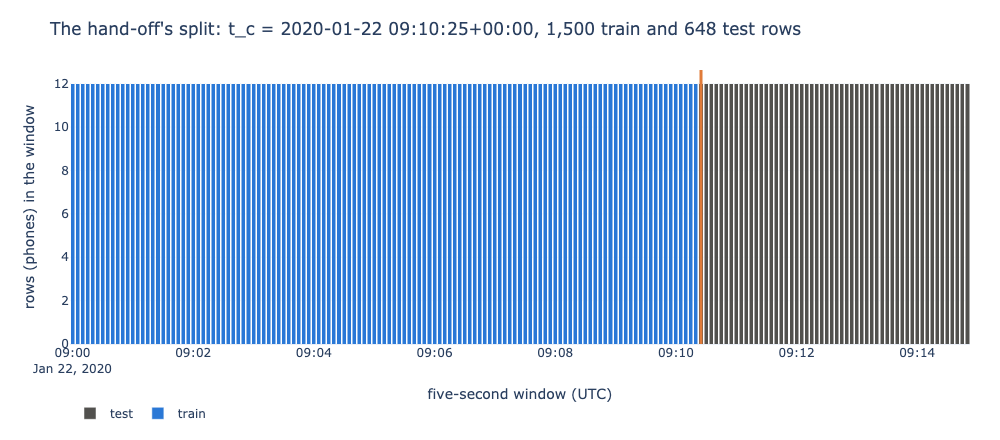

  rows 2,148, columns 10, key ['phone_id', 'window']
  windows straddling the split: 0
  masks written: ['rssi1_missing', 'rssi2_missing']; columns with gaps: ['rssi1_missing', 'rssi2_missing']
  train + test = rows: True

  the solution fits θ on 1,503 rows; assemble() trains on 1,500; rows of the cut window among the fitted: 3
  θ(solution's rows) − θ(training rows):
              medians     means      stds
phone_speed +0.000700 +0.000225 +0.000131
rssi1       +0.000000 -0.000000 +0.000000
rssi2       +0.000000 +0.000000 +0.000000
bus_speed   +0.000000 -0.000001 -0.000580
  largest change in a constant: 0.00070; in a scaled value of the table: 0.0050
  rows the hand-off transform θ is fitted on: computed here 1,500 (this notebook: the training rows); stated 1,503 (the Lab 4 solution's demonstration) — the solution fits on the first int(0.7 n) rows before assemble() moves the cut back to the start of a window, so 3 test rows inform θ; no constant moves by more than 0.0007 and no scal

In [134]:
aligned, ledger = align(bus, phones, 5)
stored_columns = ["phone_speed", "rssi1", "rssi2", "bus_speed"]
by_window = aligned.sort_values(["window", "phone_id"]).reset_index(drop=True)
cut_instant = by_window["window"].iloc[int(len(by_window) * TRAIN_FRACTION)]
training = by_window[by_window["window"] < cut_instant]              # the rows assemble() will call train
fitted = fit_preprocessing(training[stored_columns])
handoff, manifest = assemble(aligned, fitted, ledger, TARGET_COLUMN, TRAIN_FRACTION)
assert str(cut_instant) == manifest["split_point"] and len(training) == manifest["train_rows"]
per_window = handoff.groupby(["window", "split"]).size().unstack(fill_value=0)
fig = go.Figure()
for split, colour in (("train", BLUE), ("test", GREY)):
    if split in per_window:
        fig.add_bar(x=per_window.index, y=per_window[split], marker_color=colour, name=split)
fig.add_vline(x=pd.Timestamp(manifest["split_point"]), line=dict(color=ORANGE, width=3))
fig.update_layout(barmode="stack", title=f"The hand-off's split: t_c = {manifest['split_point']}, "
                                         f"{manifest['train_rows']:,} train and {manifest['test_rows']:,} test rows",
                  xaxis_title="five-second window (UTC)", yaxis_title="rows (phones) in the window",
                  legend=dict(orientation="h", y=-0.2))
show(fig, "split_timeline", height=440)
straddling = int((handoff.groupby("window")["split"].nunique() > 1).sum())
with_gaps = sorted(c + "_missing" for c in stored_columns if aligned[c].isna().any())
print(f"  rows {manifest['rows']:,}, columns {manifest['columns']}, key {manifest['key']}")
print(f"  windows straddling the split: {straddling}")
print(f"  masks written: {manifest['mask_columns']}; columns with gaps: {with_gaps}")
print(f"  train + test = rows: {manifest['train_rows'] + manifest['test_rows'] == manifest['rows']}")

# The Lab 4 solution's demonstration fits on the first int(0.7 n) rows in window order.
solution_rows = aligned.sort_values("window").iloc[:int(len(aligned) * TRAIN_FRACTION)]
solution_fitted = fit_preprocessing(solution_rows[stored_columns])
solution_table, _ = assemble(aligned, solution_fitted, ledger, TARGET_COLUMN, TRAIN_FRACTION)
print(f"\n  the solution fits θ on {len(solution_rows):,} rows; assemble() trains on "
      f"{manifest['train_rows']:,}; rows of the cut window among the fitted: "
      f"{int((solution_rows['window'] >= cut_instant).sum())}")
moved = pd.DataFrame({part: {c: solution_fitted[part][c] - fitted[part][c] for c in stored_columns}
                      for part in ("medians", "means", "stds")})
print("  θ(solution's rows) − θ(training rows):")
print(moved.to_string(float_format=lambda value: f"{value:+.6f}"))
largest_constant = float(moved.abs().max().max())
largest_scaled = float((solution_table[stored_columns] - handoff[stored_columns]).abs().max().max())
print(f"  largest change in a constant: {largest_constant:.5f}; in a scaled value of the table: {largest_scaled:.4f}")
beside("rows the hand-off transform θ is fitted on", f"{len(training):,} (this notebook: the training rows)",
       f"{len(solution_rows):,} (the Lab 4 solution's demonstration)",
       f"the solution fits on the first int(0.7 n) rows before assemble() moves the cut back to the start "
       f"of a window, so {int((solution_rows['window'] >= cut_instant).sum())} test rows inform θ; no constant "
       f"moves by more than {largest_constant:.4f} and no scaled value by more than {largest_scaled:.3f}")

## Laboratory 4 — Windows, splits and what they cost

*Slide: "Lab 4 — Windows, splits and what they cost".* Four functions,
twenty-five minutes. The check compares your features with a reference, refuses a
split whose halves overlap in time, requires the matched share to rise with the
tolerance, and grades the hand-off's three clauses.

**The exercise, exactly as `Module 2/exercises/labs/04_windows_and_cost.py` states it.**

> Lab 4 — The series, and what it costs.
>
> Why this lab exists: a single reading of speed says almost nothing, and the two
> cheapest ways to flatter a model are a window that reaches past its own edge and
> a split that puts a reading's own neighbour in the test set. You prove here that
> you can summarise a window honestly, split a table so that no test row precedes
> a training row, and price a join instead of guessing at a tolerance.
> Where it sits: Block four — "What the join costs", and the definition slides
> "Definition — the six window features", "Definition — lag-k sample
> autocorrelation", "Definition — a split by time, never at random" and
> "Definition — a nearest match within a tolerance".
> What the check grades: the six features against its own arithmetic over exactly
> the last `width` values, on the shipped speeds and on a planted window whose
> answers are arithmetic; a split of a shuffled table whose last training time is
> at or before the first test time, at the asked fraction and losing nothing;
> matched shares that never fall as the tolerance widens and that agree with a
> reference join within 0.2 percentage points against a vehicle thinned to one
> reading every thirty seconds; and the hand-off table itself — one row per phone
> per window, a mask beside every filled value and beside no other, the split
> point recorded as an instant with no window straddling it, and the fitted
> transform and the ledger stored unchanged.
> Needs: pandas, numpy, plotly, and the loaders in lab_support.
>
> Twenty-five minutes.
>
> A single reading of speed says almost nothing. A window of readings says how
> fast, how variable, which way it is heading, and whether anything unusual
> happened -- and those are the features a model can actually use.
>
> Then two costs, both measured rather than assumed: what a time-ordered split
> costs you in training rows, and what a join costs you as the tolerance widens.
>
> What you write: window_features(series, width), split_by_time(frame, fraction),
> join_growth(phones, bus, tolerances), and
> assemble(aligned, fitted, ledger, target, train_fraction).
>
>     window_features(series, width) -> dict
>         Over the last `width` values of `series`, return mean, std, minimum,
>         maximum, slope and autocorrelation_1. Use only the last `width` values.
>         A window that quietly reaches further back is a small leak of exactly
>         the kind Lab 3 was about.
>
>     split_by_time(frame, train_fraction) -> (train, test)
>         Sort by the coordinated universal time column, then cut. Everything
>         before the cut trains, everything after tests. No shuffling, no overlap,
>         and no row in both. Module 1 measured why: consecutive readings correlate
>         at about 0.997, so a random split tests the model on paraphrases of its
>         own training data.
>
>     join_growth(phones, bus, tolerances) -> dict
>         For each tolerance in seconds, match each phone row to the nearest
>         vehicle reading within that tolerance, and return
>         {tolerance: matched_share_percent}. Widening the window buys matches and
>         spends accuracy -- the vehicle reading you matched is further away in
>         time. Measure the trade rather than picking a number and hoping.
>
>         On the archive this runs 95.3 per cent at one second to 97.4 at thirty:
>         2.1 percentage points for thirty times the tolerance. Report what you
>         find here and compare.
>
>     assemble(aligned, fitted, ledger, target, train_fraction) -> (table, manifest)
>         The last twenty minutes of the module, and the only part of it another
>         person will ever run. Everything so far produced a number; this produces
>         the object Modules 3, 4 and 5 open. It is one table plus one manifest
>         describing it, and the manifest is the half people forget: a table
>         without its split point, its stored transform and its ledger is a table
>         nobody can reproduce a result from.

```python
def window_features(series, width: int) -> dict:
    """Six numbers describing the last `width` readings.
    
    Definition graded by the check:
        over the last w readings: x̄, σ with ddof = 0, min, max, slope b = Σ_i
        (i − ī)(x_i − x̄) / Σ_i (i − ī)², and r_1
        (Kuhn & Johnson, 2019, ch. 5). ī is the mean position, so the slope is
        the least-squares gradient against position and is in units of the
        series per reading. The standard deviation is the population one,
        ddof = 0. Slide: "Definition — the six window features".
        r_k = Σ_{t=k+1}^{n} (x_t − x̄)(x_{t−k} − x̄) / Σ_{t=1}^{n} (x_t − x̄)²
        (Box, Jenkins, Reinsel & Ljung, 2015, §2.1.4). One mean over the whole
        window and the whole window's sum of squares underneath. This is not
        what pandas computes -- that is the correlation between
        the series and its shifted copy, with two means and two variances, and
        the two disagree on every finite window. Module 1 grades the same
        formula, so the two modules' numbers are the same quantity. Slide:
        "Definition — lag-k sample autocorrelation".
    Needs: pandas, numpy
    
    Returns:
        {"mean", "std", "minimum", "maximum", "slope", "autocorrelation_1"}."""
```

```python
def split_by_time(frame, train_fraction: float = 0.7):
    """Split in time order. Everything before the cut trains; everything after tests.
    
    Definition graded by the check:
        train = {x_t : t < t_c}, test = {x_t : t ≥ t_c} for one cut instant t_c,
        the ⌊f·n⌋-th time in sorted order — never a random permutation of the
        rows
        (Roberts et al., 2017; Bergmeir & Benítez, 2012). The rows you are handed
        are out of order, as the archive's own rows are, so sorting is part of
        the job and not an assumption you may make. Slide: "Definition — a split
        by time, never at random".
    Needs: pandas, int, len
    
    Returns:
        (train, test)."""
```

```python
def join_growth(phones, bus, tolerances=TOLERANCES) -> dict:
    """What each tolerance buys: {seconds: per cent of phone rows matched}.
    
    Definition graded by the check:
        match(p) = argmin_b |t_b − t_p| when min_b |t_b − t_p| ≤ τ, else none;
        matched share = |{p : match(p) exists}| / n_p
        (McKinney, 2022). t_p is a phone row's time and t_b a vehicle reading's,
        both in coordinated universal time; τ is the tolerance in seconds. The
        share is a percentage of the phone rows. Note that merge_asof refuses two
        time columns of different resolution, and pandas infers the resolution
        from the text it parsed -- force both to the same unit before joining.
        Slide: "Definition — a nearest match within a tolerance".
    Needs: pandas
    
    Returns:
        {tolerance in seconds: matched share in per cent}."""
```

```python
def assemble(aligned, fitted: dict, ledger: dict, target: str = TARGET_COLUMN,
                  train_fraction: float = TRAIN_FRACTION):
    """The table this module hands to Module 3, and the manifest that describes it.
    
    Definition graded by the check:
        one row per (phone_id, window); mask_c = 1[x_c absent] beside x_c for
        every filled column c and for no other; split_point t_c = the window of
        the ⌊f·n⌋-th row in time order, train = {t < t_c}, test = {t ≥ t_c}; θ
        and the ledger stored unchanged
        (Huyen, 2022; Kuhn & Johnson, 2019, ch. 8). f is `train_fraction` and n
        the rows of the table. The split point is an instant, not a row number,
        which is why the cut is moved to the start of the window the ⌊f·n⌋-th
        row sits in: rows sharing an instant cannot end up on opposite sides of
        a split by time. Slide: "Definition — the table this module hands to the
        next three".
    Needs: pandas, int, len, sorted
    
    Arguments:
        aligned         one row per phone per window, from Lab 1: `phone_id`,
                        `window`, the feature columns, and the target.
        fitted          the transform from Lab 3: medians, means, stds and the
                        column order. `fitted["columns"]` names the columns that
                        are filled and scaled, in the order they are stored.
        ledger          the conservation ledger from Lab 1, recorded verbatim.
        target          the name of the target column in `aligned`.
        train_fraction  the share of rows that train.
    
    Returns:
        (table, manifest).
    
        table    `phone_id`, `window`, then for each stored column its filled and
                 scaled value immediately followed by its mask where anything was
                 filled, then the target, then `split` holding "train" or "test".
                 No gaps are left anywhere in the stored columns.
        manifest a dict carrying at least: schema_version, rows, columns, key,
                 feature_columns, mask_columns, target, split_point, train_rows,
                 test_rows, transform and ledger. The split point is written as
                 text so that the manifest survives a trip through a file."""
```

**The stub's slide titles, against the deck.** The stub places the lab under "What
the join costs"; no slide has that title. The slide that measures the join is
"Widening the tolerance thirtyfold buys few rows and costs accuracy on all of them".
Four of the definition titles are shortened or reworded in the stub: the deck's
slides are "Definition — six window features", "Definition — a split by time, never
at random for timeseries", "Definition — a nearest match within a tolerance (fuzzy
time-based join)" and "Definition — the table this module hands to the next steps".
"Definition — lag-k sample autocorrelation" is a hidden slide: it is in the deck
file but not shown in the lecture, and the stub states the definition in full. The
stub cites McKinney (2022) for the nearest match; the book covers joins on equal keys,
not `merge_asof`.

### The solution

The four functions and their helper were defined above, where the deck introduces each concept. First, the lab file's own demonstration.

**Goal.** Run the stub's own demonstration against the solved functions.

**Why.** It is what a student sees when the file is complete.

**What the code does.** The stub's `__main__` block, verbatim.

**So what.** Six features of the last 60 phone speeds, a split by time, and the join's shares.

In [135]:
# Source: Module 2/exercises/labs/04_windows_and_cost.py — demonstration step 0, verbatim

say = narrator(LAB)
phones = load_phones()
say.info("window features over the last 60 speeds: %s",
         window_features(phones["speed"], 60))
train, test = split_by_time(phones, 0.7)
say.info("train %s  test %s", f"{len(train):,}", f"{len(test):,}")
show_table(pd.DataFrame({"per cent matched": join_growth(phones, load_bus())})
           .rename_axis("tolerance (s)"), "nearest match within a tolerance",
           logger=say)

 23.82s  lab 4  window features over the last 60 speeds: {'mean': 0.7458000000000001, 'std': 0.42183981161889716, 'minimum': 0.051, 'maximum': 1.397, 'slope': -0.005856904695748824, 'autocorrelation_1': 0.12518976991287833}
 23.82s  lab 4  train 7,559  test 3,241
 24.14s  lab 4  --- nearest match within a tolerance (5 rows) ---
 24.14s  lab 4                     per cent matched
 24.14s  lab 4      tolerance (s)                  
 24.14s  lab 4      1                           100
 24.14s  lab 4      2                           100
 24.14s  lab 4      5                           100
 24.14s  lab 4      10                          100
 24.14s  lab 4      30                          100


**Goal.** Let the solution's demonstration find its sibling labs and write its hand-off inside the working copy.

**Why.** The Lab 4 solution imports `align` and `fit_preprocessing` from `lab_01` and `lab_03`, and writes to `out/handoff/` next to `solutions/`.

**What the code does.** Points `__file__` at `solutions/lab_04.py` in the working copy. `lab_01` and `lab_03` are already modules holding the functions defined above, so the imports resolve to them, not to the files.

**So what.** The hand-off lands in the temporary copy's `out/handoff/`, never in the student's folder.

In [136]:
__file__ = str(Path.cwd() / "solutions" / "lab_04.py")

### The solution's demonstration, step by step

What `python3 solutions/lab_04.py` prints, one paragraph of its `__main__` block at a
time, each verbatim. It ends the module: the object Modules 3, 4 and 5 open.

**Goal.** Start the demonstration's narrator.

**Why.** One logger carries every line the solution prints, in the terminal and here.

**What the code does.** Creates `say` for Lab 4 and prints the lab's one-line summary.

**So what.** The seconds at the start of each line are the only output that differs between runs.

In [137]:
# Source: Module 2/exercises/solutions/lab_04.py — demonstration, paragraph 1 of 9, verbatim

say = narrator(LAB)
say.info("Lab 4 — features from a window, a split that keeps time, and what a join costs")

 24.15s  lab 4  Lab 4 — features from a window, a split that keeps time, and what a join costs


**Goal.** Load both files and summarise the last minute of phone speed.

**Why.** The first deliverable: six features over exactly the last `width` readings, the autocorrelation by the Box–Jenkins estimator (Box et al., 2015, § 2.1.4).

**What the code does.** Loads the phones and the vehicle; computes `window_features` on the last 60 phone speeds; prints them, and the lag-1 autocorrelation pandas' `autocorr` gives on the same window.

**So what.** The two autocorrelations differ on the same sixty numbers: two estimators, and the course grades one.

In [138]:
# Source: Module 2/exercises/solutions/lab_04.py — demonstration, paragraph 2 of 9, verbatim

phones, bus = load_phones(), load_bus()
say.info("phones: %s rows, generated (seed 20200122); vehicle: %s rows, archive slice",
         f"{len(phones):,}", f"{len(bus):,}")
speed = phones["speed"].astype(float)
features = window_features(speed, 60)
say.info("window of the last 60 phone speed readings, metres per second: mean %.3f, "
         "sd (ddof = 0) %.3f, min %.3f, max %.3f, slope %.5f per position, r_1 %.4f",
         features["mean"], features["std"], features["minimum"], features["maximum"],
         features["slope"], features["autocorrelation_1"])
say.info("the same window through pandas.Series.autocorr(1) reads %.4f — a different "
         "estimator (two means, two variances); the course grades the Box–Jenkins one",
         float(speed.tail(60).autocorr(1)))

 24.42s  lab 4  phones: 10,800 rows, generated (seed 20200122); vehicle: 48,290 rows, archive slice
 24.43s  lab 4  window of the last 60 phone speed readings, metres per second: mean 0.746, sd (ddof = 0) 0.422, min 0.051, max 1.397, slope -0.00586 per position, r_1 0.1252
 24.43s  lab 4  the same window through pandas.Series.autocorr(1) reads 0.1271 — a different estimator (two means, two variances); the course grades the Box–Jenkins one


**Goal.** Split a shuffled copy of the day by time.

**Why.** The second deliverable must sort before it cuts; a shuffled table proves it does.

**What the code does.** Shuffles the phones (seed 20200122), calls `split_by_time(…, 0.7)`, and prints the sizes, the last training time, the first test time, and whether the first is at or before the second.

**So what.** "No overlap: True" — by the check's test (≤). The times printed are equal, 09:10:24 on both sides, because this is the same straddled instant the cells after `split_by_time`'s definition counted: eleven readings of it train and one tests.

In [139]:
# Source: Module 2/exercises/solutions/lab_04.py — demonstration, paragraph 3 of 9, verbatim

shuffled = phones.sample(frac=1.0, random_state=20200122).reset_index(drop=True)
train, test = split_by_time(shuffled, 0.7)
say.info("split by time from a shuffled table: %s train rows ending %s, %s test rows "
         "starting %s — no overlap: %s", f"{len(train):,}",
         train["timestamp_utc"].max().strftime("%H:%M:%S"), f"{len(test):,}",
         test["timestamp_utc"].min().strftime("%H:%M:%S"),
         bool(train["timestamp_utc"].max() <= test["timestamp_utc"].min()))

 24.44s  lab 4  split by time from a shuffled table: 7,559 train rows ending 09:10:24, 3,241 test rows starting 09:10:24 — no overlap: True


**Goal.** Measure the join against the shipped vehicle and against the thinned one.

**Why.** The third deliverable: the matched share at each tolerance, which must never fall as the tolerance widens.

**What the code does.** Runs `join_growth` against the vehicle as shipped and thinned to one reading per 30 seconds, and tabulates both.

**So what.** Flat at 100 per cent against the shipped vehicle; from 6.8 to 100 against the thinned one. What the thinned curve does not show — the accuracy spent, and a curve that saturates — was measured on the lab data above.

In [140]:
# Source: Module 2/exercises/solutions/lab_04.py — demonstration, paragraph 4 of 9, verbatim

dense = join_growth(phones, bus, TOLERANCES)
in_order = bus.assign(_when=pd.to_datetime(bus["utc_time"], utc=True)).sort_values("_when")
sparse_bus = in_order.iloc[::60].drop(columns="_when")
sparse = join_growth(phones, sparse_bus, TOLERANCES)
table = pd.DataFrame({"vehicle twice a second (per cent matched)": dense,
                      "vehicle once per 30 s (per cent matched)": sparse}).rename_axis(
                          "tolerance (s)")
show_table(table, "nearest match within a tolerance", logger=say)
say.info("against the shipped vehicle every phone row matches at one second, so the "
         "curve is flat; thin the vehicle to one reading per thirty seconds and the "
         "share climbs from %.1f to %.1f per cent — the trade the archive shows as "
         "95.3 to 97.4", sparse[TOLERANCES[0]], sparse[TOLERANCES[-1]])

 24.55s  lab 4  --- nearest match within a tolerance (5 rows) ---
 24.55s  lab 4                     vehicle twice a second (per cent matched)  vehicle once per 30 s (per cent matched)
 24.55s  lab 4      tolerance (s)                                                                                     
 24.55s  lab 4      1                                                    100                                       6.8
 24.55s  lab 4      2                                                    100                                      13.3
 24.55s  lab 4      5                                                    100                                      33.1
 24.55s  lab 4      10                                                   100                                      66.6
 24.55s  lab 4      30                                                   100                                       100
 24.55s  lab 4  against the shipped vehicle every phone row matches at one second, so the curve is fl

**Goal.** Draw the two curves.

**Why.** The lab's own version of the slide's figure.

**What the code does.** Both shares against the tolerance on a logarithmic axis; `save_figure` shows it here.

**So what.** One flat line and one that climbs.

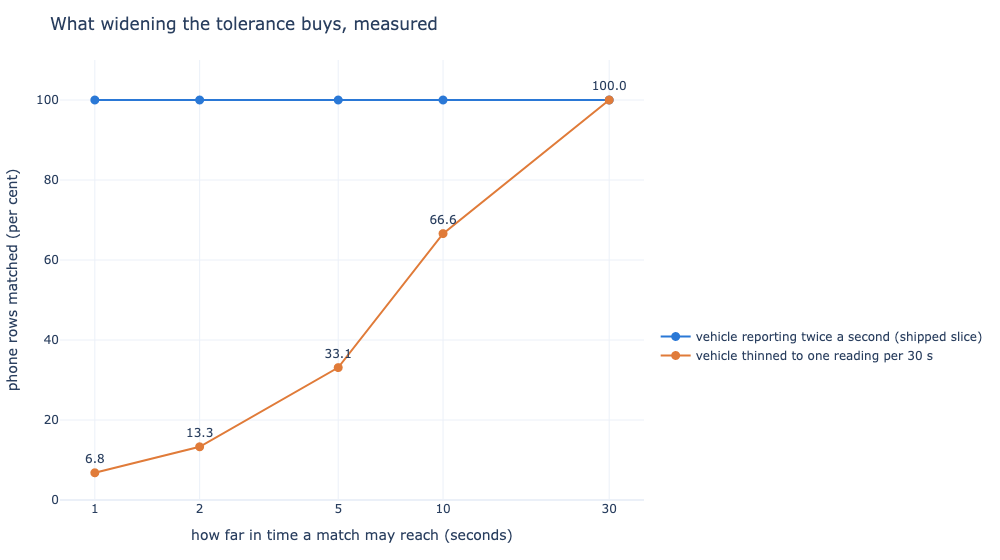

 24.63s  lab 4  figure -> shown here (lab_04_join_cost)


In [141]:
# Source: Module 2/exercises/solutions/lab_04.py — demonstration, paragraph 5 of 9, verbatim

fig = go.Figure()
fig.add_scatter(x=list(TOLERANCES), y=[dense[t] for t in TOLERANCES], mode="lines+markers",
                name="vehicle reporting twice a second (shipped slice)",
                line=dict(color="#2A78D6"), marker=dict(size=9))
fig.add_scatter(x=list(TOLERANCES), y=[sparse[t] for t in TOLERANCES],
                mode="lines+markers+text",
                name="vehicle thinned to one reading per 30 s",
                line=dict(color="#E07B39"), marker=dict(size=9),
                text=[f"{sparse[t]:.1f}" for t in TOLERANCES], textposition="top center")
fig.update_xaxes(type="log", tickvals=list(TOLERANCES),
                 title_text="how far in time a match may reach (seconds)")
fig.update_yaxes(title_text="phone rows matched (per cent)", range=[0, 110])
fig.update_layout(title="What widening the tolerance buys, measured", legend=dict(y=0.35))
save_figure(fig, "join_cost", LAB, logger=say)

**Goal.** Import the two sibling labs the hand-off is built from.

**Why.** The hand-off joins the module's labs: Lab 1's alignment and ledger, Lab 3's fitted transform.

**What the code does.** Puts the solution's folder on the import path and imports `align` and `fit_preprocessing`. In this notebook `lab_01` and `lab_03` are the modules registered above, so the imports return the functions on this page.

**So what.** Nothing is read from the files themselves.

In [142]:
# Source: Module 2/exercises/solutions/lab_04.py — demonstration, paragraph 6 of 9, verbatim

# The hand-off. Built from this module's own labs: Lab 1's alignment and
# ledger, Lab 3's fitted transform, and the split from this lab. Written to
# out/handoff/ so that Module 3 has something to open rather than a promise.
sys.path.insert(0, str(pathlib.Path(__file__).resolve().parent))
from lab_01 import align                                   # noqa: E402
from lab_03 import fit_preprocessing                        # noqa: E402

**Goal.** Align, fit the transform, and assemble the hand-off.

**Why.** The fourth deliverable: one table, its masks, its split, its transform and its ledger.

**What the code does.** Aligns the day, sorts it by window, fits `fit_preprocessing` on the first `int(len × 0.7)` rows — 1,503 — and calls `assemble`, which moves the cut back to the start of the window that row falls in and labels 1,500 rows train.

**So what.** The table is the one the split figure above drew. Its constants were fitted on 1,503 rows, three of which `assemble` then puts in the test set — the slip measured beside that figure, where no constant moved by more than a thousandth of its unit.

In [143]:
# Source: Module 2/exercises/solutions/lab_04.py — demonstration, paragraph 7 of 9, verbatim

aligned, ledger = align(bus, phones, 5)
stored_columns = ["phone_speed", "rssi1", "rssi2", "bus_speed"]
in_time_order = aligned.sort_values("window")
training_rows = in_time_order.iloc[:int(len(in_time_order) * TRAIN_FRACTION)]
fitted = fit_preprocessing(training_rows[stored_columns])
table, manifest = assemble(aligned, fitted, ledger, TARGET_COLUMN, TRAIN_FRACTION)

**Goal.** Write the hand-off to `out/handoff/`.

**Why.** A hand-off is a file Module 3 can open, not a variable in a session.

**What the code does.** Writes the table as Parquet and the manifest (split point, transform, ledger) as JSON under the working copy's `out/handoff/`, and shows the first rows.

**So what.** 2,148 rows, masks on the two beacon columns, 1,500 training rows and 648 test rows.

In [144]:
# Source: Module 2/exercises/solutions/lab_04.py — demonstration, paragraph 8 of 9, verbatim

destination = pathlib.Path(__file__).resolve().parent.parent / "out" / "handoff"
destination.mkdir(parents=True, exist_ok=True)
table.to_parquet(destination / "table.parquet", index=False)
(destination / "manifest.json").write_text(json.dumps(manifest, indent=1, default=str))
say.info("hand-off written to out/handoff/: %s rows x %d columns, key %s, masks %s, "
         "split point %s, %s train and %s test rows — the transform and the ledger "
         "are inside manifest.json", f"{manifest['rows']:,}", manifest["columns"],
         manifest["key"], manifest["mask_columns"], manifest["split_point"],
         f"{manifest['train_rows']:,}", f"{manifest['test_rows']:,}")
show_table(table.head(6), "the first rows of the table Module 3 opens", logger=say)

 25.01s  lab 4  hand-off written to out/handoff/: 2,148 rows x 10 columns, key ['phone_id', 'window'], masks ['rssi1_missing', 'rssi2_missing'], split point 2020-01-22 09:10:25+00:00, 1,500 train and 648 test rows — the transform and the ledger are inside manifest.json
 25.01s  lab 4  --- the first rows of the table Module 3 opens (6 rows) ---
 25.01s  lab 4        phone_id                    window  phone_speed   rssi1  rssi1_missing   rssi2  rssi2_missing  bus_speed  aboard  split
 25.02s  lab 4      0      p00 2020-01-22 09:00:00+00:00       -1.009 -0.1146              1 -0.2618              1 -0.0009024       0  train
 25.02s  lab 4      1      p01 2020-01-22 09:00:00+00:00      -0.7053 -0.1146              1  0.3838              0 -0.0009024       0  train
 25.02s  lab 4      2      p02 2020-01-22 09:00:00+00:00       -1.514 -0.1146              1 -0.3216              0 -0.0009024       0  train
 25.02s  lab 4      3      p03 2020-01-22 09:00:00+00:00       -0.861 -0.1146         

**Goal.** Print what the check grades.

**Why.** The demonstration ends by telling the student what `verify/check_04.py` will ask.

**What the code does.** One narrated line.

**So what.** Features, split, join and the hand-off's three clauses — the split graded by ≤, which is why the straddled instant passes.

In [145]:
# Source: Module 2/exercises/solutions/lab_04.py — demonstration, paragraph 9 of 9, verbatim

say.info("what the check grades: the six features against its own arithmetic over exactly "
         "the last width values (r_1 by the Box–Jenkins formula, sd with ddof = 0); a "
         "split whose last training time is at or before the first test time from a "
         "shuffled table; and matched shares that never fall as the tolerance widens and "
         "match the reference within 0.2 points on the thinned vehicle; and the "
         "hand-off table — one row per phone per window, a mask beside what was "
         "filled and beside nothing else, a split point recorded as an instant with "
         "no window straddling it, and the transform and the ledger stored unchanged")

 25.03s  lab 4  what the check grades: the six features against its own arithmetic over exactly the last width values (r_1 by the Box–Jenkins formula, sd with ddof = 0); a split whose last training time is at or before the first test time from a shuffled table; and matched shares that never fall as the tolerance widens and match the reference within 0.2 points on the thinned vehicle; and the hand-off table — one row per phone per window, a mask beside what was filled and beside nothing else, a split point recorded as an instant with no window straddling it, and the transform and the ledger stored unchanged


**Goal.** Read back what the demonstration wrote, and restore `__file__`.

**Why.** A hand-off is only real if it can be opened.

**What the code does.** Reads `out/handoff/manifest.json` and the table from the working copy.

**So what.** The manifest carries the split point, the transform and the ledger — the four objects the closing slide lists.

In [146]:
__file__ = str(Path.cwd() / "lab_support.py")
written = json.loads((Path.cwd() / "out" / "handoff" / "manifest.json").read_text())
table_back = pd.read_parquet(Path.cwd() / "out" / "handoff" / "table.parquet")
print("manifest keys:", sorted(written))
print("table read back:", table_back.shape, "  split point:", written["split_point"])
assert (written["rows"], written["train_rows"], written["test_rows"]) == (
    manifest["rows"], manifest["train_rows"], manifest["test_rows"]), "the two hand-offs differ"
print("the file on disk and the table built in the split figure agree:",
      written["rows"], "rows,", written["train_rows"], "train,", written["test_rows"], "test")

manifest keys: ['columns', 'feature_columns', 'key', 'ledger', 'mask_columns', 'rows', 'schema_version', 'split_point', 'target', 'test_rows', 'train_fraction', 'train_rows', 'transform']
table read back: (2148, 10)   split point: 2020-01-22 09:10:25+00:00
the file on disk and the table built in the split figure agree: 2148 rows, 1500 train, 648 test


---
# What the module measured, and what it hands on

*Slides: "Four of Module 1's ten flavours of bias were measured in this module",
"Article 10 requires an examination for bias, and this module performed one", "The
hand-off is four objects, built by Lab 4 and graded by its check" and "What you can
now do".*

**Goal.** Recompute the numbers the bias slide gathers, and label the archive's.

**Why.** The slide ties four of Module 1's ten flavours of bias to this module's measurements: measurement and labelling, missing-data related, leakage and peeking, and time-related.

**What the code does.** Prints each number from the cell that measured it above, or from the archive's record where only the archive has it.

**So what.** Every number on the slide has a line here; the archive's are labelled as such.

In [147]:
beside("beacons silent, per cent of rows", f"{min(generated_absence.values())} to {max(generated_absence.values())} (generated)",
       "57 to 86.3 (archive)", "the generator matches the archive's heard rates per aboard state")
agrees("mean fill: decibels invented", biases["mean"], 13.6, 1)
agrees("mean fill: spread kept", ratios["mean"], 0.36, 2)
beside("BusID empty, per cent of rows", round(100 * float(phones["bus_id"].isna().mean()), 2),
       f"{archive('busid_absent_share')} (archive)", "the archive's share covers its unlabelled second day")
agrees("lag-1 autocorrelation of speed, 22 January", lag_one(slice_day_one["speed"]), 0.9967, 4)

  beacons silent, per cent of rows: computed here 69.3 to 96.4 (generated); stated 57 to 86.3 (archive) — the generator matches the archive's heard rates per aboard state
  mean fill: decibels invented                                       deck 13.6      computed 13.6
  mean fill: spread kept                                             deck 0.36      computed 0.36
  BusID empty, per cent of rows: computed here 43.67; stated 84.74 (archive) — the archive's share covers its unlabelled second day
  lag-1 autocorrelation of speed, 22 January                         deck 0.9967    computed 0.9967


### What the law asks

The Artificial Intelligence Act (Regulation (EU) 2024/1689), Article 10:

- **10(2)(f)** — training, validation and testing data are examined in view of
  possible biases.
- **10(2)(g)** — appropriate measures detect, prevent and mitigate the biases the
  examination finds.
- **10(5)** — special categories of personal data may be processed for bias
  detection and correction only where strictly necessary, and under safeguards.

Simpson's paradox in Block 1 is such an examination, and it makes the slide's
point by itself: the pooled comparison and the profile check on the pool both
report nothing, and the per-group ones do not. The deck adds that the Digital
Omnibus sets 2 December 2027 for the Annex III high-risk obligations
(Regulation (EU) 2026/1744). *This is the text of the Regulation, not legal advice.*

### The hand-off, and what you can now do

The table (one row per phone per window, masks beside the filled values, the
target), the split recorded as an instant, the fitted transform, and the ledger —
four objects, one manifest, written by Lab 4 to `out/handoff/`. One fact is carried
forward on purpose: in the archive, labels exist for the first day and not the
second, and Module 5 begins there.

Put two sources on one grain and prove no row went missing unnoticed; ask why a
value is absent before filling it, and report what the fill invented and what it
flattened; fit a transform on the training rows and apply it unchanged; recognise a
column that already contains the answer; build window features, split by time, and
measure what a join costs instead of estimating it.

**Goal.** Record the deck's source lines that name the wrong script.

**Why.** Eleven shown slides carry the source line "Numbers: the archive — data/passengers.csv and data/bus.csv … Measured by Module 2/slides/make_figs.py" (the two alignment slides, the distribution and theorem slides, the absence, beacon and BusID slides, the window-feature and split slides, the join slide and the bias summary). The convolution slide's says "Numbers: the course generator — make_phones.py". The scripts can be read.

**What the code does.** Reads `slides/make_figs.py` and `slides/measure.py` from the repository and asks which of them opens a CSV file, and whether the convolution figure's function touches the generator.

**So what.** `measure.py` measures the archive; `make_figs.py` never opens it — it reads `measured.json` and the generator — and the convolution figure uses no data at all, as its own caption says. The footers should name `measure.py`, and the convolution slide's should say no data.

In [148]:
figs_code = (MODULE / "slides" / "make_figs.py").read_text()
measure_code = (MODULE / "slides" / "measure.py").read_text()
convolution_code = figs_code.split("def figure_convolution")[1].split("\ndef ")[0]
beside("script that measured the archive numbers",
       f"make_figs.py opens a CSV: {'read_csv' in figs_code}; measure.py opens a CSV: {'read_csv' in measure_code}",
       "\"Measured by Module 2/slides/make_figs.py\" (slides 10, 13, 14, 22, 34, 35, 56, 66, 81, 83, 88)",
       "make_figs.py reads measured.json and the generator; the archive is measured by measure.py")
beside("data behind the convolution figure",
       f"figure_convolution calls the generator or a loader: {any(call in convolution_code for call in ('generate(', 'load_phones(', 'read_csv('))}",
       "\"Numbers: the course generator — make_phones.py\" (slide 77)",
       "the figure draws the theorem from closed forms; its own caption on the slide says it uses no data")

  script that measured the archive numbers: computed here make_figs.py opens a CSV: False; measure.py opens a CSV: True; stated "Measured by Module 2/slides/make_figs.py" (slides 10, 13, 14, 22, 34, 35, 56, 66, 81, 83, 88) — make_figs.py reads measured.json and the generator; the archive is measured by measure.py
  data behind the convolution figure: computed here figure_convolution calls the generator or a loader: False; stated "Numbers: the course generator — make_phones.py" (slide 77) — the figure draws the theorem from closed forms; its own caption on the slide says it uses no data


---
## Practice

Four questions, each a few lines, each with a definite answer. Answers follow.

1. **Can any beacon beat the base rate by its value?** Block 2 showed that "heard"
   does not. Among the rows where a beacon *was* heard, does the signal strength
   separate aboard from not aboard?
2. **What does the grain cost?** Count the distinct 1-second, 5-second and
   30-second windows the first day's phone rows fall into. What is thrown away at
   each step?
3. **Is `label` safe to use as a feature?** `label2` is the target. Cross-tabulate
   and decide, and say what class of leak it is.
4. **Which comparison did you make?** The aboard share moves one way on each shuttle
   and the other way pooled. Which should a transport authority publish, which should
   an engineer act on, and what would settle the disagreement?

**Goal.** Answer question 1: compare the signal strength of heard readings, aboard against not aboard.

**Why.** A column whose presence carries nothing may still carry something in its value.

**What the code does.** For each beacon, among the rows where it was heard on the generated first day: the mean signal strength aboard and not aboard, the spread of the heard readings, and the area under the ROC curve of the signal strength as a score for "aboard" (0.5 is a coin; 1 separates perfectly).

**So what.** Four beacons give areas between about 0.4 and 0.6 — little better than a coin. `rssi2` is the exception: 0.26, or 0.74 read the other way, because in the generated day its heard readings are weaker when the passenger is aboard. A value can carry what presence does not; but the generator was calibrated on the archive's presence rates, not its signal values, so this is a lead to test on the archive, not a finding.

In [149]:
from sklearn.metrics import roc_auc_score
for b in ["rssiA", "rssiB", "rssiC", "rssi1", "rssi2"]:
    heard_rows = labelled[labelled[b].notna()]
    on = heard_rows.loc[heard_rows["label2"] == "IN", b].mean()
    off = heard_rows.loc[heard_rows["label2"] == "OUT", b].mean()
    area = roc_auc_score(heard_rows["label2"] == "IN", heard_rows[b])
    print(f"  {b:7} aboard {on:7.1f} dBm   not aboard {off:7.1f} dBm   difference {on - off:+5.1f}"
          f"   spread {heard_rows[b].std(ddof=0):4.1f}   area under the ROC curve {area:.2f}")

  rssiA   aboard   -68.5 dBm   not aboard   -67.9 dBm   difference  -0.6   spread  8.9   area under the ROC curve 0.48
  rssiB   aboard   -67.7 dBm   not aboard   -65.1 dBm   difference  -2.6   spread  9.8   area under the ROC curve 0.41
  rssiC   aboard   -76.6 dBm   not aboard   -75.6 dBm   difference  -1.0   spread  7.1   area under the ROC curve 0.45
  rssi1   aboard   -69.0 dBm   not aboard   -71.8 dBm   difference  +2.8   spread  8.5   area under the ROC curve 0.61
  rssi2   aboard   -78.2 dBm   not aboard   -72.0 dBm   difference  -6.1   spread  8.0   area under the ROC curve 0.26


**Goal.** Answer question 2: count the windows at three grains.

**Why.** Every grain is a choice, and the ledger records it because every later number depends on it.

**What the code does.** Floors the first day's phone timestamps (UTC) to 1, 5 and 30 seconds and counts distinct windows and phone rows per window.

**So what.** At one second a window holds about one reading per phone; at thirty seconds, about thirty, and everything that happened inside them is averaged away. Coarser grains keep more rows per window and less of what happened.

In [150]:
stamps = pd.to_datetime(phones["timestamp_utc"], utc=True)
for grain in ("1s", "5s", "30s"):
    count = stamps.dt.floor(grain).nunique()
    print(f"  {grain:>4}: {count:6,} windows, {len(stamps) / count:6.1f} phone rows per window")

    1s:    893 windows,   12.1 phone rows per window
    5s:    179 windows,   60.3 phone rows per window
   30s:     30 windows,  360.0 phone rows per window


**Goal.** Answer question 3: cross-tabulate `label` against the target.

**Why.** A column written by the same process that writes the target is the target under another name (Kaufman et al., 2012).

**What the code does.** Cross-tabulates the generated first day's `label` against `label2`, and asks the Lab 3 detector.

**So what.** Every value of `label` maps to exactly one value of the target: it is the target's own source, the same class of leak as `bus_id`, and `find_leaks` names it.

In [151]:
print(pd.crosstab(phones["label"], phones["label2"]).to_string())
print("\nfind_leaks names label:", "label" in find_leaks(phones, TARGET))

label2    IN   OUT
label             
Bus 1   1444     0
Bus 2   4640     0
Stop C     0  4716

find_leaks names label: True


**Answer to question 4.** Both numbers are right, and they answer different
questions. The pooled share is what the fleet delivered on each day, which is what a
transport authority is accountable for. The per-shuttle share is what a shuttle does
to the people on it, which is what an engineer changes. What settles the
disagreement is knowing whether the day caused the fleet mix to change: if it did,
the pooled comparison is the effect of the day; if the mix changed for an unrelated
reason, the pooled comparison is an artefact of composition (Pearl, 2014).

**The module's exam question** (from `exercises/READING.md`): *you are given a table
someone else cleaned; it has no missing values — what do you ask, and why? Then
describe one defect that would survive every question you just asked.* Every block
of this notebook is part of an answer: the ledger and the masks for the first half,
leakage and the pooled-versus-grouped comparison for the second.

*Every output above is the author's own, computed by this notebook from
`exercises/data/bus_slice.csv.gz` and from the course's generator
(`exercises/data/make_phones.py`, seed 20200122); numbers labelled "archive" are read
from `slides/measured.json` and `Module 1/slides/measured.json`, where
`slides/measure.py` and Module 1's scripts recorded them from the archive, in
aggregate only.*

---
## Where this notebook and the slides differ, and why

The slides are the master and are not changed. Where a number computed here does
not match the number a slide prints, the notebook printed both at that point, with
the reason. The table gathers every one of them, as they were printed in this run.

Differences in wording and labels, which the table cannot hold:

- **Slide 20** (the normal-distribution figure): the density formula lacks σ under
  the root and its exponent is garbled; the axis ticks read μ−3σ, μ−σ, μ, μ+σ, μ+2σ,
  which is not symmetric. The notebook draws the density from `scipy.stats.norm`.
- **Slide 32** (the MCAR/MAR/MNAR picture): "the vehicle beacon is silent on 57 % to
  86 %" is the range over all five beacons; the vehicle beacon alone is 57.0 % on
  the archive.
- **Slide 42**: "preserves 87 % of the original variance" — 0.87 is a ratio of
  standard deviations, so the variance kept is 0.87² ≈ 0.76; likewise 0.36 keeps
  0.13 of the variance.
- **Source lines** on several slides credit `make_figs.py` for archive numbers that
  `slides/measure.py` produces; `make_figs.py` never opens the archive.
- **Slide 67** spells "diffierent" and "Whatch".
- **Slide 4** (the case): the stops on the route map are lettered A, B, C by the
  notebook, from where the vehicle's doors opened; the slice does not name its stops,
  so the letters need not match the archive's "Stop A", "Stop B", "Stop C".
- **Slide 33** (two causes of absence): the slide's diagram draws the phone against
  two shuttles; the lab slice holds one, so the notebook's redrawing measures the
  phone's second distance to a stop, and places the phone by hand.
- **Slide 39** and the Lab 2 files: the masked moving average is the causal recursion
  s_t = α·x_t + (1 − α)·s_{t−1}; Servizi et al. (2023), Appendix B, to which the lab's
  docstrings attribute it, describe a window average weighted towards the window's
  centre. Same family, different filter; the lab's docstrings are quoted unchanged.
- **Slide 83**: "costs accuracy on all of them" — a nearest match never changes the
  partner of a row that was already matched, so widening the tolerance does not make
  those rows worse; it removes the guarantee that any matched row is within one
  second. Measured beside the slide's figure, with the accuracy the added rows lose.
- **Slides 81 and 85, and Labs 3 and 4**: the split by row puts one instant on both
  sides (eleven rows train, one tests), and the Lab 4 solution fits the hand-off's
  transform on three rows that `assemble` then sends to test. Both are in the lab
  files, which are delivered and not changed; both are counted in the table, and
  the notebook's own hand-off is fitted on the training rows.
- **Citations inside the lab stubs**, quoted verbatim and not changed: Wang and
  Strong (1996) is cited for the conservation ledger, which the paper does not state
  (it defines data quality as fitness for use, which fits the profile check); McKinney
  (2022) is cited for the nearest match, whose `merge_asof` the book does not cover.
- **Lab 3's typed evidence**: `phone_speed`'s purity, cardinality and gap and the gaps
  of the row counter and `rssi1` are typed into the solution; the notebook recomputes
  all five with a stated recipe and they agree.
- **The stubs' slide titles** are checked against the deck in the cell below; each
  one that is not a shown slide's title is a row of the table.

**Goal.** Check every slide title the lab stubs quote against the deck's own titles.

**Why.** The stubs send the student to slides by title. A title that is not in the deck, or is on a hidden slide, sends them nowhere; the slides are not changed, so the notebook says where each one actually is.

**What the code does.** Reads the slide titles and the hidden flags from `slides/Module2.pptx` (the file's XML, read-only); takes from each stub's docstrings the block title after "Where it sits" and every quoted "Definition — …"; looks each up among the titles. A title found on a shown slide is printed with its number; any other is printed beside the deck's slide that makes its point — a mapping the notebook states, checked to be a real title — and recorded for the table.

**So what.** Every quoted title either names a shown slide or has its row in the table below.

In [152]:
import ast
import re
import zipfile
from xml.etree import ElementTree

DRAWING = "http://schemas.openxmlformats.org/drawingml/2006/main"
PRESENTATION = "http://schemas.openxmlformats.org/presentationml/2006/main"
RELATION = "http://schemas.openxmlformats.org/officeDocument/2006/relationships"
tidy = lambda text: re.sub(r"\s+", " ", text).strip()


def deck_titles(path):
    """{title: (slide number, hidden)} for every slide of a .pptx, read from its XML."""
    titles = {}
    with zipfile.ZipFile(path) as deck:
        presentation = ElementTree.fromstring(deck.read("ppt/presentation.xml"))
        targets = {r.get("Id"): r.get("Target")
                   for r in ElementTree.fromstring(deck.read("ppt/_rels/presentation.xml.rels"))}
        for number, slide_id in enumerate(presentation.find(f"{{{PRESENTATION}}}sldIdLst"), start=1):
            slide = ElementTree.fromstring(deck.read("ppt/" + targets[slide_id.get(f"{{{RELATION}}}id")]))
            for shape in slide.iter(f"{{{PRESENTATION}}}sp"):
                placeholder = shape.find(f".//{{{PRESENTATION}}}nvPr/{{{PRESENTATION}}}ph")
                if placeholder is not None and placeholder.get("type") in ("title", "ctrTitle"):
                    text = " ".join("".join(t.text or "" for t in paragraph.iter(f"{{{DRAWING}}}t"))
                                    for paragraph in shape.iter(f"{{{DRAWING}}}p"))
                    titles[tidy(text)] = (number, slide.get("show") == "0")
    return titles


def quoted_titles(stub):
    """The block title and every "Definition — …" a stub's docstrings quote."""
    tree = ast.parse(stub.read_text(encoding="utf-8"))
    text = tidy(" ".join(ast.get_docstring(node) or "" for node in [tree] + [
        node for node in tree.body if isinstance(node, ast.FunctionDef)]))
    found = re.findall(r'Where it sits: Block \w+ — "([^"]+)"', text) + re.findall(r'"(Definition — [^"]+)"', text)
    return list(dict.fromkeys(found))


titles = deck_titles(MODULE / "slides" / "Module2.pptx")
# The notebook's reading of which slide makes each missing title's point.
CLOSEST = {
    "Bronze to silver — what changes, and what must not": "Silver is derived and rebuildable, and bronze must never be modified",
    "The mask, and why it must survive": "A fill must be recorded, because a filled value and a measured value look alike",
    "The leak in this archive": "BusID is not correlated with the target, it is the target under another name",
    "What the join costs": "Widening the tolerance thirtyfold buys few rows and costs accuracy on all of them",
    "Definition — the six window features": "Definition — six window features",
    "Definition — a split by time, never at random": "Definition — a split by time, never at random for timeseries",
    "Definition — a nearest match within a tolerance": "Definition — a nearest match within a tolerance (fuzzy time-based join)",
    "Definition — the table this module hands to the next three": "Definition — the table this module hands to the next steps",
}
for stub in sorted((Path.cwd() / "labs").glob("0*.py")):
    for title in quoted_titles(stub):
        if title in titles and not titles[title][1]:
            print(f"  {stub.name}: \"{title}\" is slide {titles[title][0]}")
        elif title in titles:
            beside(f"{stub.name}: slide title", f"slide {titles[title][0]}, hidden in the deck",
                   f"\"{title}\" (the stub)", "the slide exists but is not shown in the lecture; "
                   "the stub states the definition in full")
        else:
            deck_title = CLOSEST[title]
            number, hidden = titles[deck_title]           # a KeyError here would mean a wrong mapping
            assert not hidden
            beside(f"{stub.name}: slide title", f"slide {number}, \"{deck_title}\"",
                   f"\"{title}\" (the stub)", "no slide has the stub's title; this is the slide that makes its point")

  01_audit_and_align.py: slide title: computed here slide 31, "Silver is derived and rebuildable, and bronze must never be modified"; stated "Bronze to silver — what changes, and what must not" (the stub) — no slide has the stub's title; this is the slide that makes its point
  01_audit_and_align.py: "Definition — a tumbling window on the coordinated universal time grain" is slide 23
  01_audit_and_align.py: "Definition — the conservation ledger" is slide 25
  01_audit_and_align.py: "Definition — Simpson's paradox" is slide 27
  01_audit_and_align.py: "Definition — the upstream profile, and checking a frame against it" is slide 26
  02_the_mechanism.py: slide title: computed here slide 38, "A fill must be recorded, because a filled value and a measured value look alike"; stated "The mask, and why it must survive" (the stub) — no slide has the stub's title; this is the slide that makes its point
  02_the_mechanism.py: "Definition — the three missing-data mechanisms" is slide 32
  02_the

**Goal.** Gather every number this notebook printed beside a slide's number.

**Why.** A reader should find every difference between the notebook and the slides in one place, with its reason, without searching the notebook.

**What the code does.** Tabulates what each `beside()` call recorded during this run: the quantity, the value computed here, the value on the slide or in the archive, and why they differ.

**So what.** Every row is explained where it first appears; none of them is a change to the slides.

In [153]:
with pd.option_context("display.max_colwidth", None):     # the reasons, in full
    display(pd.DataFrame(DIFFERENCES, columns=["quantity", "computed here",
                                               "the slide or the archive", "why they differ"]))

,quantity,computed here,the slide or the archive,why they differ
0,vehicle file,"48,290 rows, 22 columns, 1 vehicle","53,155 rows, 22 columns, 2 vehicles (archive)","the slide counts the archive's bus file, both shuttles; the lab slice keeps the one that ran on both days"
1,the fifth phone tick on the slide's drawing,3.972 s,2.973 s,the generated poster labels the fifth tick 2.973 s; four steps of 0.993 s are 3.972 s
2,phone file,"18 columns (generated), 12 + 8 phones on the two days","40 columns, 16 volunteers (12 + 8) (archive)",the generator keeps the per-day phone counts and only the columns the labs use
3,"label coverage by day, per cent","{'2020-01-22': 100.0, '2020-01-23': 100.0}","{'2020-01-22': 100.0, '2020-01-23': 0.0} (archive)",the generator labels both days so that Lab 1's two-day comparison exists; in the archive only 22 January was labelled
4,"rssi1 heard: shape, and what the two rules flag","skewness 0.56, excess kurtosis 0.0; z-score flags 8, Tukey 4 (generated)","""Signal strength here is neither [symmetric nor light-tailed], so the interquartile range is the correct instrument"" (slide 13)","the slide describes the archive's signal strength, which this notebook does not open; the generator draws each heard reading from a log-distance law plus 2 dB of normal noise, which is mildly skewed and light-tailed, so on the lab data the rules nearly agree"
5,axis labels on the slide's drawing,"μ − 3σ, μ − 2σ, μ − σ, μ, μ + σ, μ + 2σ, μ + 3σ","μ − 3σ, μ − σ, μ, μ + σ, μ + 2σ","the generated drawing omits μ − 2σ and μ + 3σ, and its density formula lacks the σ under the root and has a garbled exponent; the slide's own formula image is correct"
6,rows with negative speed,4429,"4,434 (archive, Module 1)",Module 1 counted both vehicles in the archive's bus file; the slice holds one
7,unparseable phone timestamps,0,"0 when told the formats are mixed, 6 when one format is inferred (archive)",the generated timestamps are all well formed; the archive's six are a property of how its file is read
8,"absence of the vehicle beacon (rssi1), archive",57.0 %,"""the vehicle beacon is silent on 57% to 86% of rows"" (the slide's poster)",the range 57 to 86.3 per cent spans all five beacons; the vehicle beacon alone is silent on 57.0 per cent
9,"absent per cent, per beacon","{'rssiA': 94.8, 'rssiB': 96.4, 'rssiC': 69.3, 'rssi1': 88.7, 'rssi2': 75.0}","{'rssiA': 86.3, 'rssiB': 73.2, 'rssiC': 70.7, 'rssi1': 57.0, 'rssi2': 83.8} (archive)","the generator matches the archive's heard rates per aboard state, not its marginal shares"


**Goal.** Delete the temporary copy of the exercises.

**Why.** The notebook worked in a copy so as never to write into the student's folder; the copy, with the Parquet files, the hand-off and the figures' data it generated, should not outlive the run.

**What the code does.** Steps back to the folder the notebook started in (`STARTED_IN`), removes the temporary folder with everything in it, and confirms that it is gone. The student's `exercises/` was only ever read.

**So what.** Running the notebook leaves nothing behind but its own outputs.

In [154]:
os.chdir(STARTED_IN)
shutil.rmtree(WORK.parent)
print("temporary copy of exercises/ removed:", not WORK.parent.exists())

temporary copy of exercises/ removed: True


## References

- Akidau, T., Bradshaw, R., Chambers, C. et al. (2015). The dataflow model: a practical approach to balancing correctness, latency, and cost in massive-scale, unbounded, out-of-order data processing. Proceedings of the VLDB Endowment 8(12), 1792–1803. https://doi.org/10.14778/2824032.2824076 — *checked against* `Module 2/literature/p1792-Akidau.pdf (.pdf`, § 1.2 Windowing: fixed windows, "sometimes called tumbling windows", are defined by a static window size
- Bayley, G. V. & Hammersley, J. M. (1946). The "effective" number of independent observations in an autocorrelated time series. Supplement to the Journal of the Royal Statistical Society 8(2), 184–197. https://doi.org/10.2307/2983560 — *checked against* `Module 4/literature/bayley1946.pdf`, the effective number of observations in an autocorrelated series, §§ 1–10; the first-order factor (1 − ρ)/(1 + ρ) used here is the one Modules 1 and 4 derive from it
- Bergmeir, C. & Benítez, J. M. (2012). On the use of cross-validation for time series predictor evaluation. Information Sciences 191, 192–213. https://doi.org/10.1016/j.ins.2011.12.028 — *checked against* `Module 2/literature/1-s2.0-S0020025511006773-main.pdf`, § 1: last block evaluation, the test set taken from the end of the series, and the dependencies that trouble cross-validation
- Blyth, C. R. (1972). On Simpson's paradox and the sure-thing principle. Journal of the American Statistical Association 67(338), 364–366. https://doi.org/10.1080/01621459.1972.10482387 — *checked against* `Module 2/literature/Blyth-SimpsonsParadoxSureThing-1972.pdf`, § 1, a treatment example called Simpson's paradox; § 2 states the reversal mathematically, P(A|B) < P(A|B') while both conditional comparisons go the other way
- Box, G. E. P., Jenkins, G. M., Reinsel, G. C. & Ljung, G. M. (2015). Time Series Analysis: Forecasting and Control, 5th ed. Wiley. § 2.1.4 is the sample autocorrelation the course grades. — *not in the course's literature folders; cited as the deck cites it*
- Casella, G. & Berger, R. L. (2002). Statistical Inference, 2nd ed. Duxbury. — *checked against* `Module 2/literature/Pages from casella_berger_statistical_inference1.pdf`, the extract holds the front matter and contents only: § 5.5 Convergence Concepts, § 5.5.3 Convergence in Distribution (p. 235), the section the deck cites; the theorem's own pages are not in the extract
- Cooley, J. W. & Tukey, J. W. (1965). An algorithm for the machine calculation of complex Fourier series. Mathematics of Computation. — *not in the course's literature folders; cited as the deck cites it*
- Dabiri, S. (2018). Credited by the deck ("Image Credits: S. Dabiri (2018)") for the figure of the four GPS channels; the deck gives no fuller reference. — *not in the course's literature folders; cited as the deck cites it*
- Elvik, R. (2025). Simpson's paradox: a collection of examples from road safety studies and emergency medicine. Transportation Research Interdisciplinary Perspectives 31, 101471. https://doi.org/10.1016/j.trip.2025.101471 — *checked against* `Module 2/literature/1-s2.0-S2590198225001502-main.pdf`, abstract: a reversal of a difference or ratio when data for several groups are added up, illustrated by road-safety studies
- Feller, W. (1971). An Introduction to Probability Theory and Its Applications, vol. 2, 2nd ed. Wiley. Chapter 15 proves the central limit theorem through the Fourier transform (the deck's description). — *not in the course's literature folders; cited as the deck cites it*
- Harris, F. J. (1978). On the use of windows for harmonic analysis with the discrete Fourier transform. Proceedings of the IEEE. — *not in the course's literature folders; cited as the deck cites it*
- Huyen, C. (2022). Designing Machine Learning Systems. O'Reilly. — *checked against* `Module 1/literature/Huyen-2022-Designing-ML-Systems-EarlyRelease.pdf`, early release, ch. 4 Feature Engineering, section "Data Leakage": split time-correlated data by time, not at random (Figure 4-7); scaling with global statistics is a common source of leakage
- Kapoor, S. & Narayanan, A. (2023). Leakage and the reproducibility crisis in machine-learning-based science. Patterns 4(9), 100804. https://doi.org/10.1016/j.patter.2023.100804 — *checked against* `Module 2/literature/1-s2.0-S2666389923001599-main.pdf`, highlights and summary: leakage found in at least 294 papers across 17 fields; a taxonomy of eight types
- Kaufman, S., Rosset, S., Perlich, C. & Stitelman, O. (2012). Leakage in data mining: formulation, detection, and avoidance. ACM Transactions on Knowledge Discovery from Data 6(4), article 15. https://doi.org/10.1145/2382577.2382579 — *checked against* `Module 2/literature/2382577.2382579.pdf`, abstract and § 1: leakage is information about the target that should not be legitimately available to mine from
- Kuhn, M. & Johnson, K. (2019). Feature Engineering and Selection: a Practical Approach for Predictive Models. Chapman and Hall/CRC Press. http://www.feat.engineering/ (encoding and window features, ch. 5; imputation and the fitted transform, ch. 8, as the deck cites them). — *not in the course's literature folders; cited as the deck cites it*
- Little, R. J. A. & Rubin, D. B. (2019). Statistical Analysis with Missing Data, 3rd ed. Wiley. https://doi.org/10.1002/9781119482260 — *checked against* `Module 2/literature/little2019.pdf`, § 4.2.1 Unconditional mean imputation: under MCAR the filled-in variance underestimates the true variance by the factor (n_obs − 1)/(n − 1)
- McKinney, W. (2022). Python for Data Analysis, 3rd ed. O'Reilly. https://wesmckinney.com/book/ — *checked against* `Module 2/literature/McKinney-2022-Python-for-Data-Analysis.pdf`, § 7.2 "Computing Indicator/Dummy Variables" (pandas.get_dummies); § 8.2 "Combining and Merging Datasets"; ch. 11, time series. pandas.merge_asof, which the labs' nearest match uses, is not in the book's text
- Micci-Barreca, D. (2001). A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems. SIGKDD Explorations 3(1), 27–32. https://doi.org/10.1145/507533.507538 — *checked against* `Module 2/literature/507533.507538.pdf`, abstract: each value of a high-cardinality attribute is mapped to an estimate of the target, by an empirical-Bayes method
- Nielsen, A. (2019). Practical Time Series Analysis. O'Reilly. — *not in the course's literature folders; cited as the deck cites it*
- Oppenheim, A. V. & Schafer, R. W. (2010). Discrete-Time Signal Processing, 3rd ed. Pearson. The discrete Fourier transform is chapter 8 (the deck's description). — *not in the course's literature folders; cited as the deck cites it*
- Pearl, J. (2014). Comment: understanding Simpson's paradox. The American Statistician 68(1), 8–13. https://doi.org/10.1080/00031305.2014.876829 — *checked against* `Module 2/literature/Pearl-CommentUnderstandingSimpsons-2014.pdf`, opening sections: why causal, rather than statistical, considerations decide which comparison to trust
- Regulation (EU) 2024/1689 of the European Parliament and of the Council laying down harmonised rules on artificial intelligence (Artificial Intelligence Act). Official Journal L, 12.7.2024. https://eur-lex.europa.eu/eli/reg/2024/1689/oj — *checked against* `Module 2/literature/OJ%3AL_202401689%3AEN%3ATXT.pdf`, Article 10(2)(f) and (g), and 10(5)
- Regulation (EU) 2026/1744 (the Digital Omnibus on artificial intelligence), amending Regulation (EU) 2024/1689. Official Journal of the European Union. — *checked against* `Module 2/literature/OJ%3AL_202601744%3AEN%3ATXT.pdf`, sets 2 December 2027 for AI systems classified as high-risk under Article 6(2) and Annex III
- Roberts, D. R., Bahn, V., Ciuti, S. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical, or phylogenetic structure. Ecography 40(8), 913–929. https://doi.org/10.1111/ecog.02881 — *checked against* `Module 2/literature/Ecography - 2016 - Roberts - Cross%E2%80%90validation strategies for data with temporal  spatial  hierarchical  or phylogenetic.pdf`, abstract: block cross-validation is nearly universally more appropriate than random cross-validation for structured data
- Rubin, D. B. (1976). Inference and missing data. Biometrika 63(3), 581–592. https://doi.org/10.1093/biomet/63.3.581 — *checked against* `Module 2/literature/Rubin-InferenceMissingData-1976.pdf`, Definitions 1 and 2: missing at random, and observed at random
- Rubin, D. B. (1987). Multiple Imputation for Nonresponse in Surveys. Wiley. — *not in the course's literature folders; cited as the deck cites it*
- Servizi, V., Persson, D. R., Pereira, F. C., Villadsen, H., Bækgaard, P., Peled, I. & Nielsen, O. A. (2023). "Is Not the Truth the Truth?": analyzing the impact of user validations for bus in/out detection in smartphone-based surveys. IEEE Transactions on Intelligent Transportation Systems 24(11), 11905–11920. https://doi.org/10.1109/TITS.2023.3291493 — *checked against* `Module 2/literature/Is_Not_the_Truth_the_Truth_Analyzing_the_Impact_of_User_Validations_for_Bus_In_Out_Detection_in_Smartphone-Based_Surveys.pdf`, Appendix B, Imputation: BLE gaps filled with an exponentially weighted moving average, and the classifier informed where the imputation could not fill them
- Servizi, V., Persson, D. R., Pereira, F. C., Villadsen, H., Bækgaard, P., Rich, J. & Nielsen, O. A. (2026). Scalable passenger detection using smartphone–bus implicit interactions. IEEE Intelligent Transportation Systems Magazine 18(1), 65–78. https://doi.org/10.1109/MITS.2025.3611306 — *checked against* `Module 2/literature/Scalable_Passenger_Detection_Using_SmartphoneBus_Implicit_Interactions.pdf`, Table 1, "Observation imputation": imputation with an exponential weighted moving average, and masking
- Shannon, C. E. (1949). Communication in the presence of noise. Proceedings of the IRE 37(1), 10–21. — *checked against* `Module 2/literature/Shannon1949.pdf`, Theorem 1: a function containing no frequencies higher than W cycles per second is completely determined by its ordinates at points spaced 1/(2W) seconds apart
- Simpson, E. H. (1951). The interpretation of interaction in contingency tables. Journal of the Royal Statistical Society, Series B 13(2), 238–241. https://doi.org/10.1111/j.2517-6161.1951.tb00088.x — *checked against* `Module 2/literature/Simpson-InterpretationInteractionContingency-1951.pdf`, pp. 238–241: an association present in every subtable absent from the combined table (the reversal itself is Blyth's example); no combination of the tables preserves the association
- van Buuren, S. (2018). Flexible Imputation of Missing Data, 2nd ed. Chapman and Hall/CRC Press. https://doi.org/10.1201/9780429492259 — *checked against* `Module 2/literature/9780429492259_previewpdf.pdf`, the publisher's preview: § 1.2 MCAR, MAR and MNAR; § 1.3.3 mean imputation "will underestimate the variance"; § 1.3.6 LOCF; § 1.3.7 the indicator method; R, the 0–1 response indicator
- Wang, R. Y. & Strong, D. M. (1996). Beyond accuracy: what data quality means to data consumers. Journal of Management Information Systems 12(4), 5–33. https://doi.org/10.1080/07421222.1996.11518099 — *checked against* `Module 2/literature/wang1996.pdf`, the framework's four categories: completeness is a dimension of contextual data quality
- Wasserman, L. (2004). All of Statistics. Springer. — *checked against* `Module 4/literature/Wasserman-2004-All-of-Statistics.pdf`, § 5.4 The Central Limit Theorem